# Appellian Neural Networks

Derivation of the Appell acceleration energy of a double pendulum, training of the Appellian Neural Network (ANNet), and its evaluation in inverse and forward dynamics.


Fast movements cannot be controlled by sensory feedback alone, because feedback arrives with a delay. The central nervous system (CNS) is therefore thought to use internal models, that is, neural representations of the body's physics, to predict and plan movements.

These models are traditionally divided into two mathematical types.

* **Forward models** predict the future state of the body, such as its position and velocity, from the current motor commands. They serve to anticipate movement and to estimate the state of the body.
* **Inverse models** compute the motor commands needed to reach a desired future state. They serve to plan movement paths.

The two functions are commonly assigned to separate neural circuits. Here, we ask whether this separation is biologically necessary, or whether it follows from the mathematical formulations in common use, such as Newton-Euler mechanics, which treat forward and inverse dynamics as distinct problems.

We use the Gibbs-Appell formulation of motion, which follows from Gauss's principle of least constraint. In this formulation a single scalar function, the Appell acceleration energy $S$ (the Gibbs-Appell function), determines the equations of motion once the applied generalized forces are given. A single neural network, the Appellian Neural Network (ANNet), learns this function for a simulated double pendulum and then performs both inverse and forward dynamics without being trained on them separately. The gradient of the learned energy with respect to the accelerations gives the joint torques, and the minimization of an objective that contains the learned energy gives the accelerations.

The separation of forward and inverse models can therefore be a consequence of the mathematical formulation and need not be a biological necessity. We do not claim that the brain avoids functional separation. Our results show that a single neural substrate could in theory support both directions of the dynamic transformation, which challenges the idea that forward and inverse models must be separate computational entities.

The notebook has 13 sections.

* Section 1 derives the kinematics and the Gibbs-Appell function of the double pendulum.
* Section 2 sets the constants and defines the generator of the training data.
* Section 3 defines the network and the physics-informed loss and trains ANNet on datasets of nine sizes, from 1,000 to 256,000 samples.
* Section 4 evaluates the inverse dynamics of the trained networks on a fixed test set of 50 trajectories.
* Section 5 compares ANNet with a direct torque regressor of the same architecture (Fig. 4).
* Section 6 solves the forward dynamics with the network trained on 16,000 samples, without retraining.
* Section 7 repeats the forward simulation with the analytical Gibbs-Appell function in place of the learned energy (Supplementary Fig. 3).
* Section 8 reports how much of the evaluation trajectories lies outside the training sampling ranges.
* Section 9 evaluates the hyperparameters of the forward solver on a full grid.
* Section 10 records the hardware.
* Section 11 adds measurement noise to the inputs of the inverse model (Fig. 7).
* Section 12 adds noise to the gravitational torques that enter the forward solver (Fig. 8).
* Section 13 tests whether adaptation of the inverse dynamics to a changed pendulum transfers to the forward dynamics (Fig. 9).

Sections 1 to 4 define the functions that the later sections use and are run first. Sections 5, 7, 8 and 11 to 13 read the models and results that the earlier sections saved, and skip their long computations when their own output files exist. The hyperparameter search that selected the network architecture is in `HYPERPARAMETERS_RUN_ME.ipynb`.


In [1]:
# Install all third-party libraries used in this notebook for local Jupyter execution.
# google.colab is handled later as an optional Colab-only helper for browser downloads.
import importlib.util
import subprocess
import sys

PIP_DEPENDENCIES = {
    'psutil': 'psutil',
    'sympy': 'sympy',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'scipy': 'scipy',
    'statsmodels': 'statsmodels',
    'torch': 'torch',
    'matplotlib': 'matplotlib',
}

missing_packages = [
    package_name
    for module_name, package_name in PIP_DEPENDENCIES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing pip packages: {', '.join(missing_packages)}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])
    print('If any packages were installed, rerun this cell or restart the kernel and run the notebook from the top.')
else:
    print('All third-party notebook dependencies are already installed.')


All third-party notebook dependencies are already installed.


### Libraries import

In [2]:
# System & environment utilities
import os
import time
import psutil

# Core numerics, statistics, and symbolic computation
import sympy as sp
import pandas as pd
import numpy as np
import scipy.stats as scipy_stats
from statsmodels.stats.multitest import multipletests

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.utils.data import Dataset, DataLoader, Subset

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors


### Style setup

The code below sets Matplotlib parameters to match the figure style of Nature Portfolio journals, including fonts, line widths, colors, and recommended figure sizes.

In [3]:
def set_nature_style():
    """
    Configure matplotlib for the figure style of the manuscript:
    - Sans-serif font (Helvetica/Arial preferred)
    - Font size 5–7 pt for axes/legends, 7 pt for panel labels
    - Figure widths: 89 mm (single) or 183 mm (double column)
    - Line widths: 0.5–1 pt
    - Use high-res (600 dpi) for raster exports
    """

    # 1. Figure widths in inches (Nature standard)
    NATURE_SINGLE_COL_WIDTH = 3.50  # 89 mm
    NATURE_DOUBLE_COL_WIDTH = 7.20  # 183 mm

    # Golden ratio for height if not specified
    GOLDEN_RATIO = (5**0.5 - 1) / 2

    # 2. Update rcParams for fonts, lines, ticks, saving, and aesthetics
    nature_rc = {
        # Fonts
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,            # Base font size
        'axes.labelsize': 7,       # Axis labels
        'axes.titlesize': 7,       # Subplot titles
        'xtick.labelsize': 6,      # Tick labels
        'ytick.labelsize': 6,
        'legend.fontsize': 6,      # Legend text

        # === FIX FOR ADOBE ILLUSTRATOR TEXT EDITING ===
        'pdf.fonttype': 42,        # Output Type 42 (TrueType) fonts for PDF
        'ps.fonttype': 42,         # Output Type 42 (TrueType) fonts for PostScript
        'svg.fonttype': 'none',    # Export text as text elements, not paths for SVG
        # ==============================================

        # Lines & ticks
        'axes.linewidth': 0.5,     # Axes edge lines
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,    # Plot lines
        'lines.markersize': 3,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.minor.width': 0.4,
        'ytick.minor.width': 0.4,

        # Saving
        'savefig.dpi': 600,        # High-res
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.05,

        # Aesthetics
        'axes.prop_cycle': plt.cycler(
            color=['#E64B35', '#4DBBD5', '#00A087', '#3C5488',
                   '#F39B7F', '#8491B4', '#91D1C2', '#DC0000', '#7E6148']
        ),  # Nature-ish palette
    }

    mpl.rcParams.update(nature_rc)
    return NATURE_SINGLE_COL_WIDTH, NATURE_DOUBLE_COL_WIDTH, GOLDEN_RATIO

# Apply the settings globally
single_col, double_col, golden_ratio = set_nature_style()

print("Figure style applied.")
print("Text will now remain editable in Adobe Illustrator (TrueType 42 / SVG text).")

Figure style applied.
Text will now remain editable in Adobe Illustrator (TrueType 42 / SVG text).


# Section 1: Derivations

In this section, we derive the kinematics of the double-pendulum system and compute the corresponding Gibbs-Appell function, S. The derivation is carried out symbolically in SymPy.

In [4]:
# Initialize pretty printing for clearer mathematical output
sp.init_printing(use_unicode=True)

First, we need to define the symbolic variables and functions that describe the system and its motion over time.

In [5]:
# Define time
t = sp.symbols('t')

# Define system parameters
m1, m2 = sp.symbols('m1 m2')
l1, l2 = sp.symbols('l1 l2')
g      = sp.symbols('g')

# Define generalized coordinates as functions of time
theta1 = sp.Function('theta1')(t)
theta2 = sp.Function('theta2')(t)

# Define substitution symbols for positions, velocities, and accelerations
q1, q2     = sp.symbols('q1 q2')
dq1, dq2   = sp.symbols('dq1 dq2')
ddq1, ddq2 = sp.symbols('ddq1 ddq2')

print("Symbols and coordinates defined.")


# Compute position of mass 1
x1 = l1 * sp.sin(theta1)
y1 = -l1 * sp.cos(theta1)

# Compute position of mass 2 relative to link 1
x2 = x1 + l2 * sp.sin(theta1 + theta2)
y2 = y1 - l2 * sp.cos(theta1 + theta2)

print("Position vectors defined.")


# Compute velocities as first derivatives of positions
vx1 = sp.diff(x1, t)
vy1 = sp.diff(y1, t)
vx2 = sp.diff(x2, t)
vy2 = sp.diff(y2, t)

# Compute accelerations as second derivatives of positions
ax1 = sp.diff(vx1, t)
ay1 = sp.diff(vy1, t)
ax2 = sp.diff(vx2, t)
ay2 = sp.diff(vy2, t)

print("Velocity and acceleration vectors defined.")


# Compute squared magnitudes of accelerations
accel_mag_sq_1 = ax1**2 + ay1**2
accel_mag_sq_2 = ax2**2 + ay2**2

# Compute Gibbs-Appell function S = 0.5 * sum(m_i * a_i^2)
S_symbolic = 0.5 * m1 * accel_mag_sq_1 + 0.5 * m2 * accel_mag_sq_2

print("Gibbs-Appell function derived.")


Symbols and coordinates defined.
Position vectors defined.
Velocity and acceleration vectors defined.
Gibbs-Appell function derived.


Second, we replace time-dependent derivatives and generalized coordinates with static symbols to make the final expressions easier to read and work with.

In [6]:
# Create a mapping from dynamic functions to static symbols
# Derivatives must be substituted before the base functions
subs_map = {
    theta1.diff(t, t): ddq1,  # acceleration of joint1
    theta2.diff(t, t): ddq2,  # acceleration of joint2
    theta1.diff(t):    dq1,   # velocity of joint1
    theta2.diff(t):    dq2,   # velocity of joint2
    theta1:             q1,   # angle of joint1
    theta2:             q2    # angle of joint2
}

# Apply the substitutions and simplify the expression
S_clean = S_symbolic.subs(subs_map).simplify()

# Display the simplified Gibbs-Appell function
print("Gibbs-Appell Function:")
sp.pprint(S_clean)


Gibbs-Appell Function:
                                   ⎛                                           ↪
      2    ⎛    2      4⎞          ⎜⎛                     2                    ↪
0.5⋅l₁ ⋅m₁⋅⎝ddq₁  + dq₁ ⎠ + 0.5⋅m₂⋅⎝⎝ddq₁⋅l₁⋅sin(q₁) + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(d ↪

↪                                                         2                    ↪
↪                                          2             ⎞    ⎛                ↪
↪ dq₁ + ddq₂)⋅sin(q₁ + q₂) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + q₂)⎠  + ⎝ddq₁⋅l₁⋅cos(q₁) ↪

↪                                                                              ↪
↪       2                                                            2         ↪
↪  - dq₁ ⋅l₁⋅sin(q₁) + l₂⋅(ddq₁ + ddq₂)⋅cos(q₁ + q₂) - l₂⋅(dq₁ + dq₂) ⋅sin(q₁  ↪

↪       2⎞
↪      ⎞ ⎟
↪ + q₂)⎠ ⎠


Third, we convert the symbolic Gibbs-Appell function into a PyTorch-compatible function so we can evaluate it numerically.

In [7]:
# Pure PyTorch Gibbs-Appell scalar and compile helpers
TORCH_DTYPE = torch.float32
TORCH_EPS = 1e-8
TORCH_COMPILE_MODE = 'max-autotune' if torch.cuda.is_available() else 'reduce-overhead'

# Analytical dataset-generation kernels are intentionally eager by default.
# On some PyTorch/CPU backends, torch.compile can segfault for vectorized
# physics expressions before Python can raise an exception.
USE_COMPILED_ANALYTICAL_KERNELS_FOR_NEW_DATA = False

# Compile the trainable MLP separately from the analytical data kernels.
# CUDA usually benefits; CPU/MPS backends are kept eager unless you opt in.
USE_TORCH_COMPILE_FOR_MODEL = torch.cuda.is_available()

def as_f32_tensor(value, *, device=None):
    return torch.as_tensor(value, dtype=TORCH_DTYPE, device=device)

def compile_torch_function(fn, *, fullgraph=True):
    return torch.compile(
        fn,
        dynamic=False,
        fullgraph=fullgraph,
        mode=TORCH_COMPILE_MODE,
    )

def _compute_S_ground_truth(q1, q2, dq1, dq2, ddq1, ddq2, m1, m2, l1, l2):
    q12 = q1 + q2
    omega12 = dq1 + dq2
    alpha12 = ddq1 + ddq2

    sin_q1 = torch.sin(q1)
    cos_q1 = torch.cos(q1)
    sin_q12 = torch.sin(q12)
    cos_q12 = torch.cos(q12)

    ax1 = l1 * (ddq1 * sin_q1 + dq1.square() * cos_q1)
    ay1 = l1 * (ddq1 * cos_q1 - dq1.square() * sin_q1)

    ax2 = ax1 + l2 * (alpha12 * sin_q12 + omega12.square() * cos_q12)
    ay2 = ay1 + l2 * (alpha12 * cos_q12 - omega12.square() * sin_q12)

    accel_sq_1 = ax1.square() + ay1.square()
    accel_sq_2 = ax2.square() + ay2.square()
    return 0.5 * m1 * accel_sq_1 + 0.5 * m2 * accel_sq_2

compute_S_ground_truth_eager = _compute_S_ground_truth
compute_S_ground_truth_compiled = (
    compile_torch_function(_compute_S_ground_truth, fullgraph=True)
    if USE_COMPILED_ANALYTICAL_KERNELS_FOR_NEW_DATA
    else None
)
compute_S_ground_truth = compute_S_ground_truth_eager

_test_s = compute_S_ground_truth(
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
)

print(f"Test S value: {_test_s.item():.1f}")


Test S value: 5.0


Next, we derive expressions for the generalized forces acting on the system by taking the partial derivatives of the Gibbs-Appell function with respect to the accelerations.

In [8]:
# Compute generalized forces as derivatives of the Gibbs-Appell function
tau1_sym = sp.diff(S_clean, ddq1)  # force corresponding to q1
tau2_sym = sp.diff(S_clean, ddq2)  # force corresponding to q2

# Display generalized force tau1
print("Generalized force τ1:")
sp.pprint(tau1_sym)

print("\n")

# Display generalized force tau2
print("Generalized force τ2:")
sp.pprint(tau2_sym)


Generalized force τ1:
           2             ⎛                                   ⎛                 ↪
1.0⋅ddq₁⋅l₁ ⋅m₁ + 0.5⋅m₂⋅⎝(2⋅l₁⋅sin(q₁) + 2⋅l₂⋅sin(q₁ + q₂))⋅⎝ddq₁⋅l₁⋅sin(q₁)  ↪

↪      2                                                            2          ↪
↪ + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(ddq₁ + ddq₂)⋅sin(q₁ + q₂) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + ↪

↪     ⎞                                      ⎛                     2           ↪
↪  q₂)⎠ + (2⋅l₁⋅cos(q₁) + 2⋅l₂⋅cos(q₁ + q₂))⋅⎝ddq₁⋅l₁⋅cos(q₁) - dq₁ ⋅l₁⋅sin(q₁ ↪

↪                                                   2             ⎞⎞
↪ ) + l₂⋅(ddq₁ + ddq₂)⋅cos(q₁ + q₂) - l₂⋅(dq₁ + dq₂) ⋅sin(q₁ + q₂)⎠⎠


Generalized force τ2:
       ⎛     ⎛                     2                                           ↪
0.5⋅m₂⋅⎝2⋅l₂⋅⎝ddq₁⋅l₁⋅sin(q₁) + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(ddq₁ + ddq₂)⋅sin(q₁ + q₂ ↪

↪                   2             ⎞                     ⎛                      ↪
↪ ) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + q₂)⎠⋅sin(q₁ + q₂) + 2⋅l₂⋅⎝ddq₁⋅l₁⋅cos(q₁) - dq₁ ↪

↪

Lastly, we convert the symbolic generalized forces into a PyTorch-compatible function so we can evaluate them numerically with tensors.

In [9]:
# Pure PyTorch generalized inertial forces: tau = M(q) @ ddq + C(q, dq)
def _compute_tau_ground_truth(q1, q2, dq1, dq2, ddq1, ddq2, m1, m2, l1, l2):
    sin_q2 = torch.sin(q2)
    cos_q2 = torch.cos(q2)

    m11 = l1.square() * (m1 + m2) + 2.0 * l1 * l2 * m2 * cos_q2 + l2.square() * m2
    m12 = l2 * m2 * (l1 * cos_q2 + l2)
    m22 = l2.square() * m2

    c1 = -l1 * l2 * m2 * sin_q2 * (2.0 * dq1 * dq2 + dq2.square())
    c2 = l1 * l2 * m2 * sin_q2 * dq1.square()

    tau1 = m11 * ddq1 + m12 * ddq2 + c1
    tau2 = m12 * ddq1 + m22 * ddq2 + c2
    return tau1, tau2

compute_tau_ground_truth_eager = _compute_tau_ground_truth
compute_tau_ground_truth_compiled = (
    compile_torch_function(_compute_tau_ground_truth, fullgraph=True)
    if USE_COMPILED_ANALYTICAL_KERNELS_FOR_NEW_DATA
    else None
)
compute_tau_ground_truth = compute_tau_ground_truth_eager

_test_tau = compute_tau_ground_truth(
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
)

print(f"Test tau values: ({_test_tau[0].item():.1f}, {_test_tau[1].item():.1f})")


Test tau values: (7.0, 3.0)


# Section 2: Initial setup


In this section, we handle the initial configuration and data preparation for a deep learning model designed to simulate a double-pendulum system.

### Constants

In [10]:
# Define physical parameters of the double-pendulum system
PARAMS = {
    'm1': 1.0,
    'm2': 1.0,
    'l1': 1.0,
    'l2': 1.0,
}

# Set the training batch size
BATCH_SIZE = 64

# Set the random seed for reproducibility
SEED = 27
torch.manual_seed(SEED)


In [11]:
# Select GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print the selected device
print(f"Running on device: {device}")


Running on device: cpu


The class below generates a synthetic double-pendulum dataset, computes the corresponding Gibbs-Appell function and generalized forces, and adapts everything for PyTorch training.

In [12]:
class MechanicsDataset(Dataset):
    def __init__(self, n_samples, *, S_fn=compute_S_ground_truth_eager, tau_fn=compute_tau_ground_truth_eager):
        q = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=device).uniform_(-torch.pi / 2, torch.pi / 2)
        dq = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=device).uniform_(-5.0, 5.0)
        ddq = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=device).uniform_(-20.0, 20.0)

        params = [as_f32_tensor(PARAMS[k], device=device) for k in ('m1', 'm2', 'l1', 'l2')]

        tau1, tau2 = tau_fn(
            q[:, 0], q[:, 1], dq[:, 0], dq[:, 1], ddq[:, 0], ddq[:, 1], *params
        )
        self.tau = torch.stack((tau1, tau2), dim=1)

        S = S_fn(
            q[:, 0], q[:, 1], dq[:, 0], dq[:, 1], ddq[:, 0], ddq[:, 1], *params
        ).reshape(-1, 1)

        self.X = torch.cat((q, dq, ddq), dim=1)
        self.X_mean = self.X.mean(dim=0)
        self.X_std = self.X.std(dim=0)
        self.S_mean = S.mean()
        self.S_std = S.std()

        self.X = (self.X - self.X_mean) / (self.X_std + TORCH_EPS)
        self.chain_scale = self.S_std / (self.X_std[4:6] + TORCH_EPS)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.tau[idx]


# Section 3: Physics-informed training

In this section, we define the feedforward network architecture and set up the training pipeline using the functions created earlier.

### Constants

In [13]:
# Training hyperparameters
EPOCHS = 3000
LR     = 0.0011316535454287552

# Network architecture (number of nodes per hidden layer)
NUM_NODE_L1 = 225
NUM_NODE_L2 = 61
NUM_NODE_L3 = 91
NUM_NODE_L4 = 99

# Dataset sizes to experiment with
dataset_sizes = [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000]

# Create output directory if it does not exist
output_dir = "."
os.makedirs(output_dir, exist_ok=True)

# File paths for saving the trained model and training history
MODEL_PATH   = "gibbs_appell_net.pth"
HISTORY_PATH = MODEL_PATH + "_history.pt"


In the class below, we define a multi-layer perceptron that maps the six input features (angle x 2, velocity x 2, and acceleration x 2) of the double-pendulum system to a single output representing the Gibbs-Appell function.

In [14]:
# Network architecture
class GibbsAppellNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Standard feedforward MLP with four hidden layers
        self.net = nn.Sequential(
            nn.Linear(6, NUM_NODE_L1),
            nn.GELU(),
            nn.Linear(NUM_NODE_L1, NUM_NODE_L2),
            nn.GELU(),
            nn.Linear(NUM_NODE_L2, NUM_NODE_L3),
            nn.GELU(),
            nn.Linear(NUM_NODE_L3, NUM_NODE_L4),
            nn.GELU(),
            nn.Linear(NUM_NODE_L4, 1),  # Output layer
        )

    def forward(self, x):
        # Forward pass through the network
        return self.net(x)


def maybe_compile_model(model):
    if not USE_TORCH_COMPILE_FOR_MODEL:
        return model
    print(f"Compiling neural network with torch.compile mode='{TORCH_COMPILE_MODE}'...")
    return torch.compile(model, dynamic=False, fullgraph=False, mode=TORCH_COMPILE_MODE)


def checkpoint_model(model):
    return getattr(model, '_orig_mod', model)


Since the network above predicts the Gibbs-Appell function, S, its automatic differentiation with respect to the input accelerations gives estimates of the generalized forces.

The loss below compares these predicted generalized forces to the ground truth, letting the network learn from physics directly without needing to compute S explicitly.


In [15]:
# Physics-informed loss function
def compute_force_loss(model, X_batch, tau_real_batch, chain_scale):
    """
    Computes the physics-informed loss using automatic differentiation.

    Args:
        model: The neural network.
        X_batch: Normalized inputs [N, 6] (requires_grad=True).
        tau_real_batch: Ground-truth forces [N, 2] in real units.
        chain_scale: Precomputed scaling factor for chain-rule correction [2].
    """

    # Predict normalized S from the network
    S_pred_norm = model(X_batch)

    # Compute gradients of S with respect to inputs
    grads_norm = autograd.grad(
        outputs=S_pred_norm.sum(),
        inputs=X_batch,
        create_graph=True
    )[0]

    # Extract acceleration gradients (columns 4 and 5 correspond to ddq1 and ddq2)
    dS_dddq_norm = grads_norm[:, 4:6]

    # Apply chain-rule scaling to convert from normalized to real units
    tau_pred_real = dS_dddq_norm * chain_scale

    # Return mean squared error between predicted and ground-truth forces
    return torch.mean((tau_pred_real - tau_real_batch) ** 2)


Next, to determine how much data the network needs to learn accurate force predictions, we train it on datasets of varying sizes. For each dataset, we generate trajectories, validate periodically, and save the models, statistics, and training history.

In [16]:
# Check if running in Google Colab for browser-based downloads
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab. Files will be saved locally but not downloaded via browser.")

def select_data_generation_kernels(model_path):
    if os.path.exists(model_path):
        return None, None, 'cached'
    if (
        USE_COMPILED_ANALYTICAL_KERNELS_FOR_NEW_DATA
        and compute_S_ground_truth_compiled is not None
        and compute_tau_ground_truth_compiled is not None
    ):
        return compute_S_ground_truth_compiled, compute_tau_ground_truth_compiled, 'compiled'
    return compute_S_ground_truth_eager, compute_tau_ground_truth_eager, 'eager'


# Loop over dataset sizes to train or skip existing models
for n_samples in dataset_sizes:
    print(f"\n{'='*50}")
    print(f"Processing dataset size: {n_samples}")
    print(f"{'='*50}")

    # Construct unique file paths for model, history, stats, and timing
    model_path = os.path.join(output_dir, f"model_{n_samples}.pth")
    hist_path  = os.path.join(output_dir, f"history_{n_samples}.pt")
    stats_path = os.path.join(output_dir, f"stats_{n_samples}.pt")
    time_path  = os.path.join(output_dir, f"time_{n_samples}.txt")

    print(f"Model path: {model_path}")

    # Skip training if a model already exists for this dataset size
    if os.path.exists(model_path):
        print(f"Found existing model: '{model_path}'")
        print(f"Skipping training for dataset size {n_samples}...")
        continue

    # Generate a fresh dataset. Missing-cache generation uses eager analytical
    # kernels by default to avoid torch.compile/Inductor native segfaults.
    S_data_fn, tau_data_fn, kernel_mode = select_data_generation_kernels(model_path)
    print(f"Generating dataset with {n_samples} samples using {kernel_mode} analytical kernels...")
    full_dataset = MechanicsDataset(n_samples=n_samples, S_fn=S_data_fn, tau_fn=tau_data_fn)

    # Save normalization statistics for later inference
    print(f"Saving statistics to '{stats_path}'...")
    norm_stats = {
        'n_samples':   n_samples,
        'X_mean':      full_dataset.X_mean,
        'X_std':       full_dataset.X_std,
        'S_mean':      full_dataset.S_mean,
        'S_std':       full_dataset.S_std,
        'chain_scale': full_dataset.chain_scale
    }
    torch.save(norm_stats, stats_path)
    if IN_COLAB: files.download(stats_path)

    # Split dataset: 80% training, 20% testing
    split_idx     = int(0.8 * len(full_dataset))
    train_dataset = Subset(full_dataset, range(0, split_idx))
    test_dataset  = Subset(full_dataset, range(split_idx, len(full_dataset)))

    # The dataset is already precomputed in memory, so single-process loading is
    # typically faster on CPU than spawning worker processes or adding prefetching.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Re-initialize the network and optimizer for a fresh start
    model = maybe_compile_model(GibbsAppellNet().to(device))
    optimizer = optim.Adam(model.parameters(), lr=LR)

    # Move scaling factors to GPU for efficiency
    chain_scale_gpu = full_dataset.chain_scale.to(device, dtype=torch.float32)

    train_history = []
    test_history  = []
    best_val_loss = float("inf")
    best_epoch    = -1

    print(f"Starting training on {device}...")

    # Synchronize CUDA for accurate timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    # Training loop
    for epoch in range(EPOCHS):
        model.train()           # Enable training mode
        total_loss = 0.0

        for X_batch, tau_batch in train_loader:
            X_batch   = X_batch.to(device).requires_grad_(True)  # Needed for physics-informed loss
            tau_batch = tau_batch.to(device)

            optimizer.zero_grad()

            # Compute physics-informed loss
            loss = compute_force_loss(model, X_batch, tau_batch, chain_scale_gpu)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_history.append(avg_train_loss)

        # Periodic validation every 100 epochs
        if epoch % 100 == 0:
            model.eval()
            total_val_loss = 0.0

            for X_test, tau_test in test_loader:
                X_test   = X_test.to(device).requires_grad_(True)
                tau_test = tau_test.to(device)

                loss_val = compute_force_loss(model, X_test, tau_test, chain_scale_gpu)
                total_val_loss += loss_val.item()

            avg_val_loss = total_val_loss / len(test_loader)
            test_history.append((epoch, avg_val_loss))

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_epoch = epoch
                torch.save(checkpoint_model(model).state_dict(), model_path)
                print(f"Epoch {epoch:4d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | Saved new best model")
            else:
                print(f"Epoch {epoch:4d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | Best: {best_val_loss:.6f}")

    # Synchronize CUDA and record elapsed time
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - start_time
    print(f"Training finished in {elapsed_seconds:.2f} seconds.")

    # Save training duration
    with open(time_path, "w") as f:
        f.write(str(elapsed_seconds))
    if IN_COLAB: files.download(time_path)

    if best_epoch >= 0:
        print(f"Best model already saved to '{model_path}' from epoch {best_epoch} with validation loss {best_val_loss:.6f}.")
        if IN_COLAB: files.download(model_path)
    else:
        print("Warning: no validation checkpoint was saved.")

    # Save training history
    print(f"Saving history to '{hist_path}'...")
    torch.save({'train': train_history, 'test': test_history}, hist_path)
    if IN_COLAB: files.download(hist_path)

print("\nAll experiments completed.")


Not running in Google Colab. Files will be saved locally but not downloaded via browser.

Processing dataset size: 1000
Model path: ./model_1000.pth
Found existing model: './model_1000.pth'
Skipping training for dataset size 1000...

Processing dataset size: 2000
Model path: ./model_2000.pth
Found existing model: './model_2000.pth'
Skipping training for dataset size 2000...

Processing dataset size: 4000
Model path: ./model_4000.pth
Found existing model: './model_4000.pth'
Skipping training for dataset size 4000...

Processing dataset size: 8000
Model path: ./model_8000.pth
Found existing model: './model_8000.pth'
Skipping training for dataset size 8000...

Processing dataset size: 16000
Model path: ./model_16000.pth
Found existing model: './model_16000.pth'
Skipping training for dataset size 16000...

Processing dataset size: 32000
Model path: ./model_32000.pth
Found existing model: './model_32000.pth'
Skipping training for dataset size 32000...

Processing dataset size: 64000
Model p

Lastly, we plot the RMSE of test loss over epochs for different dataset sizes and training time (in the labels).

Figure saved to: ./nature_loss_comparison.svg
Also saved as: ./nature_loss_comparison.pdf and ./nature_loss_comparison.png


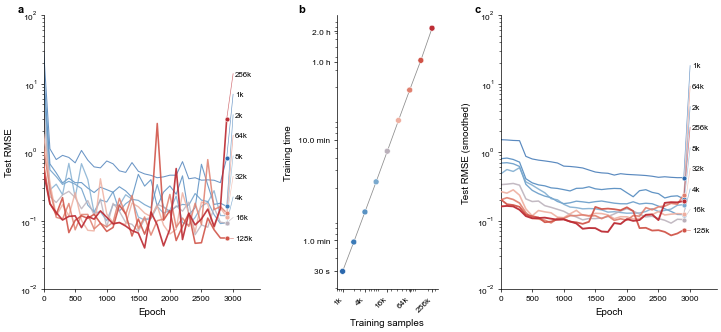

In [17]:
import os
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogFormatterMathtext, LogLocator
from matplotlib.lines import Line2D


def format_sample_count(value):
    value = int(value)
    if value >= 1000:
        return f"{value // 1000}k"
    return str(value)


def format_duration(seconds):
    if seconds is None or not np.isfinite(seconds):
        return 'n/a'
    if seconds >= 3600:
        return f"{seconds / 3600:.1f} h"
    if seconds >= 60:
        return f"{seconds / 60:.1f} min"
    return f"{seconds:.0f} s"


def duration_tick_formatter(seconds, _):
    return format_duration(seconds)


def load_loss_records(dataset_sizes, output_dir):
    records = []

    for n_samples in dataset_sizes:
        hist_path = os.path.join(output_dir, f"history_{n_samples}.pt")
        time_path = os.path.join(output_dir, f"time_{n_samples}.txt")

        if not os.path.exists(hist_path):
            print(f"Skipping {n_samples:,}: no training history found.")
            continue

        data = torch.load(hist_path, map_location='cpu')
        test_history = data.get('test', [])
        if not test_history:
            print(f"Skipping {n_samples:,}: empty test history.")
            continue

        epochs, mse = zip(*test_history)
        epochs = np.asarray(epochs, dtype=float)
        rmse = np.sqrt(np.asarray(mse, dtype=float))
        best_idx = int(np.argmin(rmse))
        best_epoch = epochs[best_idx]
        best_rmse = rmse[best_idx]

        elapsed_seconds = None
        if os.path.exists(time_path):
            with open(time_path, 'r') as f:
                elapsed_seconds = float(f.read().strip())

        records.append({
            'samples': int(n_samples),
            'epochs': epochs,
            'rmse': rmse,
            'best_idx': best_idx,
            'best_epoch': best_epoch,
            'best_rmse': best_rmse,
            'elapsed_seconds': elapsed_seconds,
            'hist_path': hist_path,
        })

    return sorted(records, key=lambda item: item['samples'])


def spread_endpoint_labels(records, log_y_min, log_y_max, minimum_gap_fraction=0.075, series_key='rmse'):
    endpoints = sorted(
        [{'record': record, 'log_y': np.log10(record[series_key][-1])} for record in records],
        key=lambda item: item['log_y'],
    )
    min_gap = (log_y_max - log_y_min) * minimum_gap_fraction
    previous = -np.inf

    for item in endpoints:
        item['label_log_y'] = max(item['log_y'], previous + min_gap)
        previous = item['label_log_y']

    overflow = endpoints[-1]['label_log_y'] - log_y_max if endpoints else 0
    if overflow > 0:
        for item in endpoints:
            item['label_log_y'] -= overflow

    return {item['record']['samples']: 10 ** item['label_log_y'] for item in endpoints}


def smooth_log_series(values, window=7):
    values = np.asarray(values, dtype=float)
    if values.size < 3:
        return values.copy()

    log_values = np.log10(np.where(values > 0, values, np.nan))
    finite = np.isfinite(log_values)
    if finite.sum() < 3:
        return values.copy()
    if not finite.all():
        positions = np.arange(values.size)
        log_values = np.interp(positions, positions[finite], log_values[finite])

    window = min(int(window), values.size)
    if window % 2 == 0:
        window -= 1
    if window < 3:
        return values.copy()

    weights = np.ones(window) / window
    padded = np.pad(log_values, window // 2, mode='reflect')
    return 10 ** np.convolve(padded, weights, mode='valid')


loss_records = load_loss_records(dataset_sizes, output_dir)

if not loss_records:
    print('No valid training histories found.')
else:
    for record in loss_records:
        record['rmse_smooth'] = smooth_log_series(record['rmse'], window=7)

    sample_values = np.asarray([record['samples'] for record in loss_records], dtype=float)
    all_rmse = np.concatenate([record['rmse'] for record in loss_records])
    all_epochs = np.concatenate([record['epochs'] for record in loss_records])
    finite_rmse = all_rmse[np.isfinite(all_rmse) & (all_rmse > 0)]

    y_min = 10 ** np.floor(np.log10(finite_rmse.min()))
    y_max = 10 ** np.ceil(np.log10(finite_rmse.max()))
    max_epoch = all_epochs.max()

    sample_size_palette = [
        '#440154', '#482878', '#3E4989', '#31688E', '#26828E',
        '#1F9E89', '#35B779', '#6DCD59', '#B4DE2C'
    ]
    cmap = mpl.colors.LinearSegmentedColormap.from_list('sample_size_viridis', sample_size_palette)
    norm = mpl.colors.LogNorm(vmin=sample_values.min(), vmax=sample_values.max())

    fig_width = double_col if 'double_col' in globals() else 7.20
    fig_height = fig_width * 0.50

    with mpl.rc_context({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,
        'axes.labelsize': 7,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'legend.fontsize': 6,
        'axes.linewidth': 0.5,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.minor.width': 0.4,
        'ytick.minor.width': 0.4,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
    }):
        fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
        grid = fig.add_gridspec(1, 3, width_ratios=(2.45, 1.15, 2.45), wspace=0.10)
        ax_loss = fig.add_subplot(grid[0, 0])
        ax_time = fig.add_subplot(grid[0, 1])
        ax_loss_smooth = fig.add_subplot(grid[0, 2], sharey=ax_loss)

        sample_color_handles = []
        for record in loss_records:
            sample_count = record['samples']
            color_position = float(norm(sample_count))
            color = cmap(0.08 + 0.86 * color_position)
            sample_color_handles.append(
                Line2D([0], [0], color=color, linewidth=1.4, label=format_sample_count(sample_count))
            )

        for record in loss_records:
            sample_count = record['samples']
            color_position = float(norm(sample_count))
            color = cmap(0.08 + 0.86 * color_position)
            line_width = 0.75 + 0.45 * color_position
            alpha = 0.70 + 0.22 * color_position

            ax_loss.plot(
                record['epochs'],
                record['rmse'],
                color=color,
                linewidth=line_width,
                alpha=alpha,
                solid_capstyle='round',
                zorder=2 + color_position,
            )
            ax_loss.scatter(
                record['epochs'][-1],
                record['rmse'][-1],
                s=12,
                color=color,
                edgecolor='white',
                linewidth=0.35,
                zorder=5,
            )
            ax_loss.scatter(
                record['best_epoch'],
                record['best_rmse'],
                s=24,
                marker='o',
                facecolor='white',
                edgecolor='black',
                linewidth=0.65,
                zorder=8,
            )

        ax_loss.set_yscale('log')
        ax_loss.set_xlim(0, max_epoch * 1.04)
        ax_loss.set_ylim(y_min, y_max)
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Test RMSE')
        ax_loss.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
        ax_loss.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax_loss.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
        ax_loss.spines['top'].set_visible(False)
        ax_loss.spines['right'].set_visible(False)
        ax_loss.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
        ax_loss.tick_params(axis='both', which='minor', direction='out', length=1.6, width=0.4)
        ax_loss.text(-0.12, 1.04, 'a', transform=ax_loss.transAxes, fontsize=8, fontweight='bold', va='top')
        selected_checkpoint_handle = Line2D(
            [0], [0], marker='o', linestyle='none', markerfacecolor='white',
            markeredgecolor='black', markeredgewidth=0.65, markersize=4.2,
            label='Minimum validation RMSE checkpoint'
        )
        ax_loss.legend(handles=[selected_checkpoint_handle], loc='upper right', frameon=False, handlelength=1.0)

        for record in loss_records:
            sample_count = record['samples']
            color_position = float(norm(sample_count))
            color = cmap(0.08 + 0.86 * color_position)
            line_width = 0.85 + 0.50 * color_position
            alpha = 0.78 + 0.18 * color_position
            smoothed_rmse = record['rmse_smooth']

            ax_loss_smooth.plot(
                record['epochs'],
                smoothed_rmse,
                color=color,
                linewidth=line_width,
                alpha=alpha,
                solid_capstyle='round',
                zorder=2 + color_position,
            )
            ax_loss_smooth.scatter(
                record['epochs'][-1],
                smoothed_rmse[-1],
                s=12,
                color=color,
                edgecolor='white',
                linewidth=0.35,
                zorder=5,
            )
            ax_loss_smooth.scatter(
                record['best_epoch'],
                smoothed_rmse[record['best_idx']],
                s=24,
                marker='o',
                facecolor='white',
                edgecolor='black',
                linewidth=0.65,
                zorder=8,
            )

        ax_loss_smooth.set_yscale('log')
        ax_loss_smooth.set_xlim(0, max_epoch * 1.04)
        ax_loss_smooth.set_ylim(y_min, y_max)
        ax_loss_smooth.set_xlabel('Epoch')
        ax_loss_smooth.set_ylabel('Test RMSE (smoothed)')
        ax_loss_smooth.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
        ax_loss_smooth.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax_loss_smooth.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
        ax_loss_smooth.spines['top'].set_visible(False)
        ax_loss_smooth.spines['right'].set_visible(False)
        ax_loss_smooth.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
        ax_loss_smooth.tick_params(axis='both', which='minor', direction='out', length=1.6, width=0.4)
        ax_loss_smooth.text(-0.12, 1.04, 'c', transform=ax_loss_smooth.transAxes, fontsize=8, fontweight='bold', va='top')

        timed_records = [record for record in loss_records if record['elapsed_seconds'] is not None]
        if timed_records:
            time_samples = np.asarray([record['samples'] for record in timed_records], dtype=float)
            time_seconds = np.asarray([record['elapsed_seconds'] for record in timed_records], dtype=float)
            time_colors = [cmap(0.08 + 0.86 * float(norm(record['samples']))) for record in timed_records]

            ax_time.plot(
                time_samples,
                time_seconds,
                color='0.55',
                linewidth=0.55,
                zorder=1,
            )
            ax_time.scatter(
                time_samples,
                time_seconds,
                c=time_colors,
                s=18,
                edgecolor='white',
                linewidth=0.35,
                zorder=3,
            )
            ax_time.set_xscale('log')
            ax_time.set_yscale('log')
            ax_time.set_xlim(sample_values.min() / 1.45, sample_values.max() * 1.45)
            ax_time.set_ylim(time_seconds.min() / 1.5, time_seconds.max() * 1.35)
            ax_time.set_xlabel('Training samples')
            ax_time.set_ylabel('Training time')
            ax_time.set_xticks([value for value in [1_000, 4_000, 16_000, 64_000, 256_000] if value in sample_values])
            ax_time.set_xticklabels([format_sample_count(value) for value in ax_time.get_xticks()], rotation=45, ha='right')
            time_tick_candidates = np.asarray([30, 60, 600, 3600, 7200], dtype=float)
            time_ticks = time_tick_candidates[
                (time_tick_candidates >= time_seconds.min() / 1.5)
                & (time_tick_candidates <= time_seconds.max() * 1.35)
            ]
            ax_time.set_yticks(time_ticks)
            ax_time.set_yticklabels([format_duration(value) for value in time_ticks])
            ax_time.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
        else:
            ax_time.text(0.5, 0.5, 'Training time\nnot available', ha='center', va='center', fontsize=6)
            ax_time.set_xticks([])
            ax_time.set_yticks([])

        ax_time.spines['top'].set_visible(False)
        ax_time.spines['right'].set_visible(False)
        ax_time.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
        ax_time.tick_params(axis='both', which='minor', direction='out', length=1.6, width=0.4)
        ax_time.text(-0.38, 1.04, 'b', transform=ax_time.transAxes, fontsize=8, fontweight='bold', va='top')
        fig.legend(
            handles=sample_color_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.075),
            ncol=len(sample_color_handles),
            frameon=False,
            handlelength=1.4,
            columnspacing=0.9,
        )

        save_base = os.path.join(output_dir, 'nature_loss_comparison')
        fig.savefig(f'{save_base}.svg', format='svg', bbox_inches='tight', pad_inches=0.03)
        fig.savefig(f'{save_base}.pdf', bbox_inches='tight', pad_inches=0.03)
        fig.savefig(f'{save_base}.png', dpi=600, bbox_inches='tight', pad_inches=0.03)

        print(f"Figure saved to: {save_base}.svg")
        print(f"Also saved as: {save_base}.pdf and {save_base}.png")
        plt.show()


# Section 4: Neural Inverse Dynamics
In this section we derive equations of motion and solve the inverse dynamics problem numerically; the same problem is then solved with the pre-trained neural network. We then compare numerical and neural solutions.

In [18]:
# Random seed for reproducible results
SEED = 23
torch.manual_seed(SEED)

# Number of simulated trajectories
NUM_TRAJECTORIES = 50

# Path for saving the generated dataset
SAVE_PATH = "double_pendulum_dataset.pt"

# Index of the trajectory to visualize
ID_TRAJ = 1

# Dataset sizes (number of samples)
MODEL_NUMS = dataset_sizes

# Base directory for inverse dynamics results
BASE_PATH = output_dir

# Fixed integration time step (seconds)
FIXED_STEP_SIZE = 1e-4

# Test trajectory duration, s
DURATION = 5

# Number of function evaluations (used for statistical testing)
n_repeats = 10000

First, we derive closed-form expressions for the double-pendulum accelerations using the Gibbs-Appell formulation, largely repeating procedures from one of the previous sections.

In [19]:
# Build compile-ready pure PyTorch dynamics kernels.
# The symbolic derivation above remains useful for exposition, but all numerical
# execution below is now performed by native Torch code only.

print('Building pure PyTorch forward-dynamics kernels...')

def _mass_matrix_torch(q1, q2, m1, m2, l1, l2):
    cos_q2 = torch.cos(q2)
    m11 = l1.square() * (m1 + m2) + 2.0 * l1 * l2 * m2 * cos_q2 + l2.square() * m2
    m12 = l2 * m2 * (l1 * cos_q2 + l2)
    m22 = l2.square() * m2

    row_1 = torch.stack((m11, m12), dim=-1)
    row_2 = torch.stack((m12, m22), dim=-1)
    return torch.stack((row_1, row_2), dim=-2)

def _bias_vector_torch(q1, q2, dq1, dq2, m1, m2, l1, l2):
    del q1, m1
    sin_q2 = torch.sin(q2)
    c1 = -l1 * l2 * m2 * sin_q2 * (2.0 * dq1 * dq2 + dq2.square())
    c2 = l1 * l2 * m2 * sin_q2 * dq1.square()
    return torch.stack((c1, c2), dim=-1)

def _gravity_vector_torch(q1, q2, m1, m2, l1, l2, g):
    q12 = q1 + q2
    sin_q1 = torch.sin(q1)
    sin_q12 = torch.sin(q12)
    g1 = g * (l1 * (m1 + m2) * sin_q1 + l2 * m2 * sin_q12)
    g2 = g * l2 * m2 * sin_q12
    return torch.stack((g1, g2), dim=-1)

def _compute_accelerations_torch(q1, q2, dq1, dq2, m1, m2, l1, l2, g):
    M = _mass_matrix_torch(q1, q2, m1, m2, l1, l2)
    C = _bias_vector_torch(q1, q2, dq1, dq2, m1, m2, l1, l2)
    G = _gravity_vector_torch(q1, q2, m1, m2, l1, l2, g)
    rhs = -(C + G)
    ddq = torch.linalg.solve(M, rhs.unsqueeze(-1)).squeeze(-1)
    return ddq[..., 0], ddq[..., 1]

calc_M_robust = compile_torch_function(_mass_matrix_torch, fullgraph=True)
calc_C_robust = compile_torch_function(_bias_vector_torch, fullgraph=True)
calc_G_robust = compile_torch_function(_gravity_vector_torch, fullgraph=True)
compute_accelerations = compile_torch_function(_compute_accelerations_torch, fullgraph=True)

print('Pure PyTorch forward-dynamics kernels are ready.')


Building pure PyTorch forward-dynamics kernels...
Pure PyTorch forward-dynamics kernels are ready.


Second, we rewrite the double-pendulum equations in first-order form so they can be integrated numerically, returning time derivatives of angles and velocities at each step.

In [20]:
# Numerical ODE solvers require the dynamics to be written
# as a first-order system of the form d/dt [q, dq] = f(q, dq).

@torch.compile(dynamic=False, fullgraph=True, mode=TORCH_COMPILE_MODE)
def derive_double_pendulum_ode(t, state, m1_t, m2_t, l1_t, l2_t, g_t):
    del t
    q1_v, q2_v, dq1_v, dq2_v = state.unbind()
    accel_1, accel_2 = _compute_accelerations_torch(
        q1_v, q2_v, dq1_v, dq2_v, m1_t, m2_t, l1_t, l2_t, g_t
    )
    return torch.stack((dq1_v, dq2_v, accel_1, accel_2))


Third, we define a function that generates double-pendulum trajectories by integrating the system's ODEs, recording angles, velocities, and accelerations at each timestep to serve as ground-truth data for later analyses.

In [21]:
# Generate a single double-pendulum trajectory using fixed-step RK4.
def generate_trajectory(duration=5.0, dt=0.001):
    t_axis = torch.arange(0.0, duration + dt, dt, dtype=TORCH_DTYPE, device=device)

    q_init = torch.empty(2, dtype=TORCH_DTYPE, device=device).uniform_(-torch.pi / 3, torch.pi / 3)
    dq_init = torch.zeros(2, dtype=TORCH_DTYPE, device=device)
    state = torch.cat((q_init, dq_init))

    m1_t = as_f32_tensor(PARAMS['m1'], device=device)
    m2_t = as_f32_tensor(PARAMS['m2'], device=device)
    l1_t = as_f32_tensor(PARAMS['l1'], device=device)
    l2_t = as_f32_tensor(PARAMS['l2'], device=device)
    g_t = as_f32_tensor(9.81, device=device)

    traj = []
    for t in t_axis:
        d_state = derive_double_pendulum_ode(t, state, m1_t, m2_t, l1_t, l2_t, g_t)
        ddq = d_state[2:]
        traj.append(torch.cat((state, ddq)))

        k1 = d_state
        k2 = derive_double_pendulum_ode(t + 0.5 * dt, state + 0.5 * dt * k1, m1_t, m2_t, l1_t, l2_t, g_t)
        k3 = derive_double_pendulum_ode(t + 0.5 * dt, state + 0.5 * dt * k2, m1_t, m2_t, l1_t, l2_t, g_t)
        k4 = derive_double_pendulum_ode(t + dt, state + dt * k3, m1_t, m2_t, l1_t, l2_t, g_t)

        state = state + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    return torch.stack(traj), t_axis


Next, we define a function that uses a trained neural network to compute generalized forces by differentiating the learned Gibbs-Appell function with respect to accelerations.

In [22]:
def get_neural_torques(model, state_vector_norm, y_std, x_std):
    state_input = state_vector_norm.detach().clone().requires_grad_(True)
    s_pred_norm = model(state_input)
    grads = autograd.grad(
        outputs=s_pred_norm.sum(),
        inputs=state_input,
        create_graph=False,
    )[0]

    scale_factor = y_std / (x_std[4:6] + TORCH_EPS)
    return grads[:, 4:6] * scale_factor


Subsequently, we create a fixed test set to evaluate all networks consistently, either by loading a cached (previously generated and stored in file) dataset or generating new trajectories.

In [23]:
# Setup file path for the fixed test set
TEST_SET_FILENAME = f"test_set_{NUM_TRAJECTORIES}_traj_{DURATION}s.pt"
test_set_path = os.path.join(BASE_PATH, TEST_SET_FILENAME)

m1_t = as_f32_tensor(PARAMS['m1'], device=device)
m2_t = as_f32_tensor(PARAMS['m2'], device=device)
l1_t = as_f32_tensor(PARAMS['l1'], device=device)
l2_t = as_f32_tensor(PARAMS['l2'], device=device)

if os.path.exists(test_set_path):
    print(f"Found cached test set at: {test_set_path}")
    print('Loading test set from file...')

    cached_data = torch.load(test_set_path, map_location='cpu')
    FIXED_INPUTS = cached_data['inputs']
    FIXED_TARGETS = cached_data['targets']
    fixed_time_axis = cached_data['time_axis']

    print(f"Loaded successfully. Shape: {FIXED_INPUTS.shape}")
else:
    print(f"Cache not found. Generating fixed test set with {NUM_TRAJECTORIES} trajectories...")

    fixed_inputs_list = []
    fixed_targets_list = []
    fixed_time_axis = None

    for i in range(NUM_TRAJECTORIES):
        print(f"Generating Trajectory {i + 1}/{NUM_TRAJECTORIES}")

        traj_data, time_axis = generate_trajectory(duration=DURATION, dt=FIXED_STEP_SIZE)

        if fixed_time_axis is None:
            fixed_time_axis = time_axis.cpu()

        traj_data = traj_data.to(device=device, dtype=TORCH_DTYPE)
        tau1_true, tau2_true = compute_tau_ground_truth_eager(
            traj_data[:, 0], traj_data[:, 1],
            traj_data[:, 2], traj_data[:, 3],
            traj_data[:, 4], traj_data[:, 5],
            m1_t, m2_t, l1_t, l2_t,
        )
        traj_true = torch.stack((tau1_true, tau2_true), dim=1)

        fixed_inputs_list.append(traj_data.cpu())
        fixed_targets_list.append(traj_true.cpu())

    FIXED_INPUTS = torch.stack(fixed_inputs_list)
    FIXED_TARGETS = torch.stack(fixed_targets_list)

    print(f"Saving generated test set to: {test_set_path}")
    torch.save({
        'inputs': FIXED_INPUTS,
        'targets': FIXED_TARGETS,
        'time_axis': fixed_time_axis,
    }, test_set_path)

    if IN_COLAB:
        files.download(test_set_path)

    print(f"Test set ready. Shape: {FIXED_INPUTS.shape}")


Found cached test set at: ./test_set_50_traj_5s.pt
Loading test set from file...
Loaded successfully. Shape: torch.Size([50, 50001, 6])


Following that, we evaluate each trained model on the fixed test set by predicting torques, timing inference, and computing RMSE for both joints.

In [24]:
# Instantiate the network once for evaluation
model = GibbsAppellNet().to(device)

# We only need gradients with respect to the inputs during torque inference.
for param in model.parameters():
    param.requires_grad_(False)

fixed_inputs_device = FIXED_INPUTS.to(device=device, dtype=torch.float32)
fixed_targets_device = FIXED_TARGETS.to(device=device, dtype=torch.float32)
perf_counter = time.perf_counter

# Evaluation loop for models trained on different dataset sizes
for num in MODEL_NUMS:
    print(f"\n{'='*40}")
    print(f"Processing Model: {num} samples")
    print(f"{'='*40}")

    model_path = os.path.join(BASE_PATH, f"model_{num}.pth")
    stats_path = os.path.join(BASE_PATH, f"stats_{num}.pt")
    save_name  = f"results_model_{num}.pt"
    full_save_path = os.path.join(BASE_PATH, save_name)

    # Skip if results already exist
    if os.path.exists(full_save_path):
        print(f"Skipping Model {num}: Results already exist ({save_name})")
        continue

    # Load normalization statistics once and precompute reusable scale factors.
    model_stats = torch.load(stats_path, map_location=device)
    stats_mean  = model_stats['X_mean'].to(device=device, dtype=torch.float32)
    stats_X_std = model_stats['X_std'].to(device=device, dtype=torch.float32)
    stats_S_std = model_stats['S_std'].to(device=device, dtype=torch.float32)
    inv_X_std   = 1.0 / (stats_X_std + 1e-8)
    torque_scale = stats_S_std / (stats_X_std[4:6] + 1e-8)

    # Load trained weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Preallocate outputs to avoid repeated Python list growth in the hot loop.
    all_pred_tau = torch.empty_like(fixed_targets_device)
    inference_times = torch.empty(NUM_TRAJECTORIES, dtype=torch.float64)

    # Loop over fixed test trajectories
    for i in range(NUM_TRAJECTORIES):
        if (i + 1) % 10 == 0:
            print(f"Evaluating Trajectory {i + 1}/{NUM_TRAJECTORIES}")

        # Normalize once, then take gradients directly with respect to the input.
        input_norm = (fixed_inputs_device[i] - stats_mean) * inv_X_std
        input_norm.requires_grad_(True)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        t_start = perf_counter()

        s_pred_norm = model(input_norm)
        grads = autograd.grad(
            outputs=s_pred_norm.sum(),
            inputs=input_norm,
            create_graph=False
        )[0]
        t_pred = grads[:, 4:6] * torque_scale

        if device.type == 'cuda':
            torch.cuda.synchronize()
        inference_times[i] = perf_counter() - t_start

        all_pred_tau[i].copy_(t_pred.detach())

    # Compute RMSE after the loop in one vectorized pass.
    rmse = torch.sqrt(torch.mean((fixed_targets_device - all_pred_tau) ** 2, dim=1))
    rmse_j1_list = rmse[:, 0].cpu().tolist()
    rmse_j2_list = rmse[:, 1].cpu().tolist()

    # Save results for this model
    print(f"Saving results for model_{num}...")

    model_results = {
        str(FIXED_STEP_SIZE): {
            "inputs":        FIXED_INPUTS,
            "torques_true":  FIXED_TARGETS,
            "torques_pred":  all_pred_tau.cpu(),
            "time_axis":     fixed_time_axis,
            "rmse_j1":       rmse_j1_list,
            "rmse_j2":       rmse_j2_list,
            "inference_times": inference_times.tolist(),
            "dt":            FIXED_STEP_SIZE
        }
    }
    torch.save(model_results, full_save_path)

print("\nAll models processed on the same trajectories.")



Processing Model: 1000 samples
Skipping Model 1000: Results already exist (results_model_1000.pt)

Processing Model: 2000 samples
Skipping Model 2000: Results already exist (results_model_2000.pt)

Processing Model: 4000 samples
Skipping Model 4000: Results already exist (results_model_4000.pt)

Processing Model: 8000 samples
Skipping Model 8000: Results already exist (results_model_8000.pt)

Processing Model: 16000 samples
Skipping Model 16000: Results already exist (results_model_16000.pt)

Processing Model: 32000 samples
Skipping Model 32000: Results already exist (results_model_32000.pt)

Processing Model: 64000 samples
Skipping Model 64000: Results already exist (results_model_64000.pt)

Processing Model: 128000 samples
Skipping Model 128000: Results already exist (results_model_128000.pt)

Processing Model: 256000 samples
Skipping Model 256000: Results already exist (results_model_256000.pt)

All models processed on the same trajectories.


Afterward, we benchmark the inference timing of models trained on different dataset sizes using repeated interleaved evaluation.

In [25]:
# Output file for benchmark results
save_path = os.path.join(output_dir, "timing_benchmark_interleaved.pt")

# Flag to decide whether to run the benchmark
run_simulation = True

# Check if benchmark file exists and is valid
if os.path.exists(save_path):
    print(f"Found existing benchmark file at: {save_path}")
    try:
        checkpoint = torch.load(save_path)
        temp_data = checkpoint['benchmark_data']

        # Only use if data is already in dictionary format
        if isinstance(temp_data, dict):
            final_data = temp_data
            sizes_to_test = checkpoint['sizes_to_test']
            print("Data in correct format. Loading complete.")
            run_simulation = False
        else:
            print("WARNING: Old format detected. Re-running simulation...")
    except Exception as e:
        print(f"Error reading file ({e}). Re-running...")
else:
    print("No existing benchmark found. Starting new simulation...")

# Run benchmark if needed
if run_simulation:
    sizes_to_test = dataset_sizes
    benchmark_data = {size: [] for size in sizes_to_test}

    # Fix random seeds for reproducibility
    print(f"Setting random seed: {SEED}")
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Prepare dummy input for timing evaluation
    dummy_input = torch.rand(1, 6, dtype=TORCH_DTYPE, device=device)
    dummy_input.requires_grad_(True)

    # Load all model weights and normalization stats into memory
    print("Loading models and stats...")
    model_pool = {}
    stats_pool = {}
    for size in sizes_to_test:
        model_pool[size] = torch.load(os.path.join(BASE_PATH, f"model_{size}.pth"), map_location=device)
        loaded_stats = torch.load(os.path.join(BASE_PATH, f"stats_{size}.pt"), map_location=device)
        stats_pool[size] = {'S_std': loaded_stats['S_std'].to(device),
                            'X_std': loaded_stats['X_std'].to(device)}

    # Instantiate network structure
    model = GibbsAppellNet().to(device)

    print(f"Running interleaved benchmark on {device}...")

    # Repeat timing measurements
    for i in range(n_repeats):
        if (i+1) % 500 == 0:
            print(f"Batch {i+1}/{n_repeats}")

        # Random order of dataset sizes each iteration
        indices = torch.randperm(len(sizes_to_test))
        for idx in indices:
            size = sizes_to_test[idx]

            # Load weights and set model to evaluation
            model.load_state_dict(model_pool[size])
            model.eval()

            stats_S_std = stats_pool[size]['S_std']
            stats_X_std = stats_pool[size]['X_std']

            # Measure inference time
            if device.type == 'cuda': torch.cuda.synchronize()
            t_start = time.perf_counter()
            _ = get_neural_torques(model, dummy_input, stats_S_std, stats_X_std)
            if device.type == 'cuda': torch.cuda.synchronize()
            t_end = time.perf_counter()

            benchmark_data[size].append((t_end - t_start) * 1000.0)  # ms

    # Convert timing lists to tensors
    final_data = {size: torch.tensor(benchmark_data[size], dtype=TORCH_DTYPE) for size in sizes_to_test}

    # Save benchmark results
    print(f"Saving benchmark results to: {save_path}")
    torch.save({'benchmark_data': final_data, 'sizes_to_test': sizes_to_test}, save_path)

    print("Benchmarking complete.")


Found existing benchmark file at: ./timing_benchmark_interleaved.pt
Data in correct format. Loading complete.


### Measuring inference time

Next, we load or generate forward passes of the models with a dummy input to  measure inference time for each dataset size.

In [26]:
# Check for existing data
run_simulation = True
if os.path.exists(save_path):
    print(f"Found existing benchmark file at: {save_path}")
    try:
        checkpoint = torch.load(save_path)
        temp_data = checkpoint['benchmark_data']

        # Validate that data is a dictionary
        if isinstance(temp_data, dict):
            final_data = temp_data
            sizes_to_test = checkpoint['sizes_to_test']
            print("Data is in correct format. Loading complete.")
            run_simulation = False
        else:
            print("Warning: existing data is in old format (list). Discarding and re-running...")
    except Exception as e:
        print(f"Error reading existing file ({e}). Re-running...")
else:
    print("No existing benchmark found. Starting new simulation...")

# Run simulation if needed
if run_simulation:
    sizes_to_test = dataset_sizes
    benchmark_data = {size: [] for size in sizes_to_test}

    # Set random seeds
    print(f"Setting random seed to: {SEED}")
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Create dummy input for benchmarking
    dummy_input = torch.rand(1, 6, dtype=TORCH_DTYPE, device=device)
    dummy_input.requires_grad_(True)

    # Pre-load model weights and statistics
    print("Pre-loading models and stats into memory...")
    model_pool = {}
    stats_pool = {}

    for size in sizes_to_test:
        # Load model weights
        path_model = os.path.join(BASE_PATH, f"model_{size}.pth")
        model_pool[size] = torch.load(path_model, map_location=device)

        # Load normalization statistics
        path_stats = os.path.join(BASE_PATH, f"stats_{size}.pt")
        loaded_stats = torch.load(path_stats, map_location=device)

        stats_pool[size] = {
            'S_std': loaded_stats['S_std'].to(device),
            'X_std': loaded_stats['X_std'].to(device)
        }

    # Instantiate model once
    model = GibbsAppellNet().to(device)

    print(f"Starting interleaved benchmark on device: {device}...")

    for i in range(n_repeats):
        if (i + 1) % 500 == 0:
            print(f"Batch {i + 1}/{n_repeats}...")

        # Shuffle sizes to avoid ordering bias
        indices = torch.randperm(len(sizes_to_test))

        for idx in indices:
            size = sizes_to_test[idx]

            # Hot-swap model weights
            model.load_state_dict(model_pool[size])
            model.eval()

            # Select stats for this size
            stats_S_std = stats_pool[size]['S_std']
            stats_X_std = stats_pool[size]['X_std']

            # Measure inference time
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t_start = time.perf_counter()

            # Forward pass through model
            _ = get_neural_torques(model, dummy_input, stats_S_std, stats_X_std)

            if device.type == 'cuda':
                torch.cuda.synchronize()
            t_end = time.perf_counter()

            benchmark_data[size].append((t_end - t_start) * 1000.0)

    # Convert benchmark data to tensors
    final_data = {size: torch.tensor(benchmark_data[size], dtype=TORCH_DTYPE) for size in sizes_to_test}

    # Save benchmark results
    print(f"Saving new benchmark results to: {save_path}")
    torch.save({
        'benchmark_data': final_data,
        'sizes_to_test': sizes_to_test
    }, save_path)

    print("Benchmarking complete.")


Found existing benchmark file at: ./timing_benchmark_interleaved.pt
Data is in correct format. Loading complete.


Following this, we perform statistical analysis.

In [27]:
import scipy.stats as scipy_stats

# Prepare a dataframe
data_records = []
for size, timings in final_data.items():
    timing_values = timings.to(dtype=TORCH_DTYPE).cpu().tolist()
    for value in timing_values:
        data_records.append({'Dataset_Size': str(size), 'Time_ms': value})

df = pd.DataFrame(data_records)

print("\n" + '=' * 50)
print('Statistical analysis')
print('=' * 50)

print(f"\n{'Dataset Size':<15} | {'Shapiro-Wilk p-value':<20} | {'Result'}")
print('-' * 55)

is_normal = True
grouped_data = []
sorted_sizes = sorted(sizes_to_test)

for size in sorted_sizes:
    times = df[df['Dataset_Size'] == str(size)]['Time_ms']
    grouped_data.append(times)

    stat, p_value = scipy_stats.shapiro(times)
    is_distribution_normal = p_value > 0.05
    if not is_distribution_normal:
        is_normal = False

    res_str = 'Normal' if is_distribution_normal else 'Not normal'
    print(f"{str(size):<15} | {p_value:.4e}{' ' * 10} | {res_str}")

print('\n--- Hypothesis testing ---')
if is_normal:
    stat, p_val = scipy_stats.f_oneway(*grouped_data)
    test_name = 'One-way ANOVA'
else:
    stat, p_val = scipy_stats.kruskal(*grouped_data)
    test_name = 'Kruskal-Wallis H-test'

print(f"Test performed: {test_name}")
print(f"Statistic: {stat:.4f} | P-Value: {p_val:.4e}")

if p_val < 0.05:
    print('>> Result: Significant difference detected (reject H0).')
else:
    print('>> Result: No significant difference (fail to reject H0).')

print('\n--- Descriptive statistics ---')
print(f"{'Dataset Size':<15} | {'N':<6} | {'Mean +/- Std (ms)':<20} | {'Median [IQR] (ms)':<20} | {'Min / Max'}")
print('-' * 95)

for size in sorted_sizes:
    group_data = df[df['Dataset_Size'] == str(size)]['Time_ms']

    n = len(group_data)
    mean = group_data.mean()
    std = group_data.std()
    q1 = group_data.quantile(0.25)
    median = group_data.median()
    q3 = group_data.quantile(0.75)
    iqr = q3 - q1
    min_val = group_data.min()
    max_val = group_data.max()

    mean_std_str = f"{mean:.3f} +/- {std:.3f}"
    median_iqr_str = f"{median:.3f} [{iqr:.3f}]"
    min_max_str = f"{min_val:.3f} / {max_val:.3f}"

    print(f"{str(size):<15} | {n:<6} | {mean_std_str:<20} | {median_iqr_str:<20} | {min_max_str}")

print('-' * 95)

all_times = df['Time_ms']
global_mean = all_times.mean()
global_std = all_times.std()
global_median = all_times.median()

print('Overall (all sizes combined):')
print(f"Mean +/- Std:    {global_mean:.4f} +/- {global_std:.4f} ms")
print(f"Median:          {global_median:.4f} ms")
print('-' * 95 + '\n')



Statistical analysis

Dataset Size    | Shapiro-Wilk p-value | Result
-------------------------------------------------------
1000            | 3.2486e-111           | Not normal
2000            | 4.4214e-111           | Not normal
4000            | 2.4223e-108           | Not normal
8000            | 3.6148e-115           | Not normal
16000           | 9.4140e-111           | Not normal
32000           | 8.7918e-107           | Not normal
64000           | 4.5702e-112           | Not normal
128000          | 3.6725e-110           | Not normal
256000          | 6.1021e-110           | Not normal

--- Hypothesis testing ---
Test performed: Kruskal-Wallis H-test
Statistic: 28.6616 | P-Value: 3.6349e-04
>> Result: Significant difference detected (reject H0).

--- Descriptive statistics ---
Dataset Size    | N      | Mean +/- Std (ms)    | Median [IQR] (ms)    | Min / Max
-----------------------------------------------------------------------------------------------
1000            | 1000

Finally, we generate a figure of inference speed across dataset sizes using Nature style settings.


Figure saved to: ./nature_inference_speed_benchmark.svg
Also saved as: ./nature_inference_speed_benchmark.pdf and ./nature_inference_speed_benchmark.png


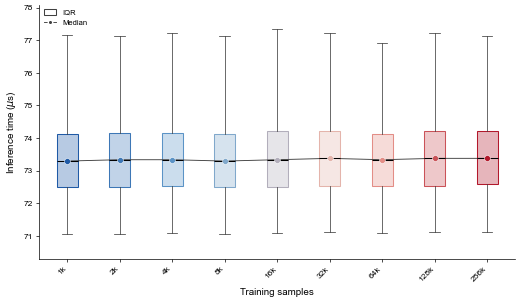

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

save_path        = os.path.join(output_dir, "timing_benchmark_interleaved.pt")
figure_save_path = os.path.join(output_dir, "nature_inference_speed_benchmark.svg")

BLUE = '#1F5AA6'
RED  = '#B2182B'
blue_red_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'sample_size_blue_red',
    [BLUE, '#6FA6D1', '#F4B6A6', RED]
)


def format_sample_count(value):
    value = int(value)
    if value >= 1000:
        return f"{value // 1000}k"
    return str(value)


def blend_with_white(color, amount):
    rgb = np.array(mpl.colors.to_rgb(color))
    return tuple(rgb * (1.0 - amount) + amount)


# Rebuild the timing table if this cell is run independently after loading benchmark data.
if 'df' not in globals() and 'final_data' in globals():
    timing_records = []
    for size, timings in final_data.items():
        for value in timings.cpu().tolist():
            timing_records.append({'Dataset_Size': str(size), 'Time_ms': value})
    df = pd.DataFrame(timing_records)

if 'sorted_sizes' not in globals():
    sorted_sizes = sorted(int(size) for size in df['Dataset_Size'].unique())

plot_sizes = [int(size) for size in sorted_sizes if str(size) in set(df['Dataset_Size'].astype(str))]
timing_df = df.copy()
timing_df['Dataset_Size'] = timing_df['Dataset_Size'].astype(str)
timing_df['Time_us'] = timing_df['Time_ms'].astype(float) * 1000.0

data_by_size = [
    timing_df.loc[timing_df['Dataset_Size'] == str(size), 'Time_us'].to_numpy()
    for size in plot_sizes
]
positions = np.log10(np.asarray(plot_sizes, dtype=float))
pooled = np.concatenate([values[np.isfinite(values)] for values in data_by_size if len(values) > 0])
median_us = np.asarray([np.median(values) for values in data_by_size], dtype=float)

lower = min(np.percentile(values, 5) for values in data_by_size if len(values) > 0)
upper = max(np.percentile(values, 95) for values in data_by_size if len(values) > 0)
y_pad = max((upper - lower) * 0.12, 0.5)

auto_single_col = globals().get('single_col', 3.50)
auto_double_col = globals().get('double_col', 7.20)
fig_width  = auto_double_col * 0.72
fig_height = fig_width * 0.58

with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}):
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    norm = mpl.colors.LogNorm(vmin=min(plot_sizes), vmax=max(plot_sizes))

    box = ax.boxplot(
        data_by_size,
        positions=positions,
        widths=0.12,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        manage_ticks=False,
        medianprops={'color': 'black', 'linewidth': 0.75},
        whiskerprops={'color': '0.25', 'linewidth': 0.55},
        capprops={'color': '0.25', 'linewidth': 0.55},
    )

    for idx, (patch, size) in enumerate(zip(box['boxes'], plot_sizes)):
        color = blue_red_cmap(norm(size))
        patch.set_facecolor(blend_with_white(color, 0.68))
        patch.set_edgecolor(color)
        patch.set_linewidth(0.75)

    ax.plot(
        positions,
        median_us,
        color='0.25',
        linewidth=0.65,
        zorder=2,
    )
    for size, x_pos, y_val in zip(plot_sizes, positions, median_us):
        color = blue_red_cmap(norm(size))
        ax.scatter(
            x_pos,
            y_val,
            s=18,
            color=color,
            edgecolor='white',
            linewidth=0.35,
            zorder=4,
        )

    ax.set_xlim(positions.min() - 0.16, positions.max() + 0.16)
    ax.set_ylim(max(0, lower - y_pad), upper + y_pad)
    ax.set_xticks(positions)
    ax.set_xticklabels([format_sample_count(size) for size in plot_sizes], rotation=45, ha='right')
    ax.set_xlabel('Training samples')
    ax.set_ylabel(r'Inference time ($\mu$s)')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
    ax.tick_params(axis='both', which='minor', direction='out', length=1.6, width=0.4)

    ax.legend(
        handles=[
            Patch(facecolor='white', edgecolor='0.25', linewidth=0.75, label='IQR'),
            Line2D([0], [0], color='0.25', marker='o', markerfacecolor='0.25', markeredgecolor='white',
                   linewidth=0.65, markersize=3.2, label='Median'),
        ],
        loc='upper left',
        frameon=False,
        handlelength=1.6,
        borderaxespad=0.2,
    )

    save_base = os.path.splitext(figure_save_path)[0]
    fig.savefig(f'{save_base}.svg', format='svg', bbox_inches='tight', pad_inches=0.03)
    fig.savefig(f'{save_base}.pdf', bbox_inches='tight', pad_inches=0.03)
    fig.savefig(f'{save_base}.png', dpi=600, bbox_inches='tight', pad_inches=0.03)

    print(f"Figure saved to: {save_base}.svg")
    print(f"Also saved as: {save_base}.pdf and {save_base}.png")
    plt.show()


### Measuring prediction accuracy

First, we load RMSE results from saved model outputs and organize them into a DataFrame.


In [29]:
# Configuration
results_path  = BASE_PATH
sorted_sizes  = sorted(MODEL_NUMS)  # Ensure dataset sizes are processed in ascending order

print(f"Loading RMSE results from: {results_path}")
records = []

for size in sorted_sizes:
    filename  = f"results_model_{size}.pt"
    full_path = os.path.join(results_path, filename)

    # Skip if file does not exist
    if not os.path.exists(full_path):
        print(f"Warning: {filename} not found.")
        continue

    # Load the saved results
    data = torch.load(full_path)

    # Extract the inner dict (grab the first available key, e.g., step size)
    key = list(data.keys())[0]
    res = data[key]

    # Unpack RMSE lists for each joint
    rmse_j1 = res['rmse_j1']
    rmse_j2 = res['rmse_j2']

    # Append each value to records for the DataFrame
    for val in rmse_j1:
        records.append({'Dataset_Size': size, 'Joint': 'J1', 'RMSE': val})
    for val in rmse_j2:
        records.append({'Dataset_Size': size, 'Joint': 'J2', 'RMSE': val})

# Create a pandas DataFrame from all records
df_rmse = pd.DataFrame(records)
print(f"Data loaded. DataFrame shape: {df_rmse.shape}")


Loading RMSE results from: .
Data loaded. DataFrame shape: (900, 3)


Second, we perform a Shapiro-Wilk normality test on RMSE values for each joint and dataset size

In [30]:
import scipy.stats as scipy_stats

print(f"\n{'='*20} Normality Test (Shapiro-Wilk) {'='*20}")
print(f"{'Joint':<6} | {'Dataset Size':<12} | {'P-Value':<12} | {'Distribution'}")
print("-" * 60)

# Dictionary to store normality results
normality_results = {}

for joint in ['J1', 'J2']:
    for size in sorted_sizes:

        # Extract RMSE values for this joint and dataset size
        subset = df_rmse[(df_rmse['Dataset_Size'] == size) & (df_rmse['Joint'] == joint)]['RMSE']

        # Perform Shapiro-Wilk test
        stat, p = scipy_stats.shapiro(subset)
        is_normal = p > 0.05
        normality_results[(joint, size)] = is_normal

        # Prepare distribution label
        dist_str = "Normal" if is_normal else "Not Normal"

        # Highlight significant deviations with asterisk
        p_str = f"{p:.2e}"
        if not is_normal:
            p_str = f"*{p_str}"

        # Print results in a table-like format
        print(f"{joint:<6} | {str(size):<12} | {p_str:<12} | {dist_str}")

print("-" * 60)
print("* p < 0.05 indicates data is not normally distributed.")


==================== Normality Test (Shapiro-Wilk) ====================
Joint  | Dataset Size | P-Value      | Distribution
------------------------------------------------------------
J1     | 1000         | *1.89e-03    | Not Normal
J1     | 2000         | *1.35e-04    | Not Normal
J1     | 4000         | *1.34e-10    | Not Normal
J1     | 8000         | *4.76e-11    | Not Normal
J1     | 16000        | *3.41e-12    | Not Normal
J1     | 32000        | *5.26e-14    | Not Normal
J1     | 64000        | *1.46e-11    | Not Normal
J1     | 128000       | *7.07e-05    | Not Normal
J1     | 256000       | *2.97e-10    | Not Normal
J2     | 1000         | *1.09e-04    | Not Normal
J2     | 2000         | *5.57e-09    | Not Normal
J2     | 4000         | *3.76e-13    | Not Normal
J2     | 8000         | *2.81e-13    | Not Normal
J2     | 16000        | *6.31e-15    | Not Normal
J2     | 32000        | *1.79e-13    | Not Normal
J2     | 64000        | *2.07e-12    | Not Normal
J2     | 12800

Third, we calculate and plot pairwise significance matrices (p-values) for RMSE comparisons across dataset sizes.



==================== Pairwise Statistical Chord Diagrams ====================
Chord diagram saved to: ./significance_chord_j1.pdf and ./significance_chord_j1.png


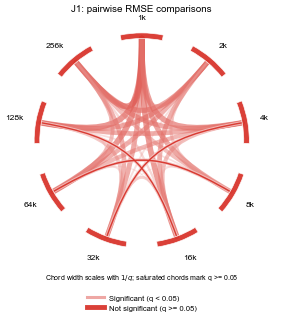


--- Statistical Summary for Joint J1 ---
To assess the impact of dataset size on model performance for joint J1, pairwise Mann-Whitney U tests were performed on the RMSE distributions.
To control the false discovery rate associated with multiple comparisons (36 tests), p-values were adjusted using the Benjamini-Hochberg procedure with a significance threshold of alpha = 0.05.
Statistically significant differences in RMSE (FDR-adjusted p < 0.05) were found for the following comparisons: 1000 vs 2000, 1000 vs 4000, 1000 vs 8000, 1000 vs 16000, 1000 vs 32000, 1000 vs 64000, 1000 vs 128000, 1000 vs 256000, 2000 vs 4000, 2000 vs 8000, 2000 vs 16000, 2000 vs 32000, 2000 vs 64000, 2000 vs 128000, 2000 vs 256000, 4000 vs 8000, 4000 vs 16000, 4000 vs 64000, 4000 vs 128000, 4000 vs 256000, 8000 vs 16000, 8000 vs 32000, 8000 vs 128000, 8000 vs 256000, 16000 vs 32000, 16000 vs 64000, 16000 vs 256000, 32000 vs 64000, 32000 vs 128000, 32000 vs 256000, 64000 vs 128000, 64000 vs 256000, 128000 vs 256

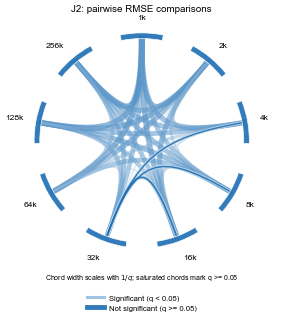


--- Statistical Summary for Joint J2 ---
To assess the impact of dataset size on model performance for joint J2, pairwise Mann-Whitney U tests were performed on the RMSE distributions.
To control the false discovery rate associated with multiple comparisons (36 tests), p-values were adjusted using the Benjamini-Hochberg procedure with a significance threshold of alpha = 0.05.
Statistically significant differences in RMSE (FDR-adjusted p < 0.05) were found for the following comparisons: 1000 vs 2000, 1000 vs 4000, 1000 vs 8000, 1000 vs 16000, 1000 vs 32000, 1000 vs 64000, 1000 vs 128000, 1000 vs 256000, 2000 vs 4000, 2000 vs 8000, 2000 vs 16000, 2000 vs 32000, 2000 vs 64000, 2000 vs 128000, 2000 vs 256000, 4000 vs 8000, 4000 vs 16000, 4000 vs 64000, 4000 vs 128000, 4000 vs 256000, 8000 vs 16000, 8000 vs 64000, 8000 vs 128000, 8000 vs 256000, 16000 vs 64000, 16000 vs 128000, 16000 vs 256000, 32000 vs 64000, 32000 vs 128000, 32000 vs 256000, 64000 vs 128000, 64000 vs 256000, 128000 vs 25

In [31]:
import os
import numpy as np
import pandas as pd
import scipy.stats as scipy_stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Wedge
from matplotlib.lines import Line2D
from statsmodels.stats.multitest import multipletests


def format_dataset_size_label(size):
    size_int = int(size)
    if size_int >= 1000:
        return f"{size_int // 1000}k"
    return str(size_int)


def blend_with_white(color, amount):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb * (1.0 - amount) + amount)


def scale_inverse_p_values(adjusted_p_values, min_width=0.45, max_width=4.2):
    safe_p = np.clip(np.asarray(adjusted_p_values, dtype=float), np.finfo(float).tiny, 1.0)
    inverse_p = 1.0 / safe_p
    compressed_inverse_p = np.log10(inverse_p)

    if np.isclose(compressed_inverse_p.max(), compressed_inverse_p.min()):
        normalized = np.full_like(compressed_inverse_p, 0.5, dtype=float)
    else:
        low, high = np.percentile(compressed_inverse_p, [2, 98])
        if np.isclose(low, high):
            low, high = compressed_inverse_p.min(), compressed_inverse_p.max()
        normalized = np.clip((compressed_inverse_p - low) / (high - low), 0, 1)

    linewidth = min_width + normalized * (max_width - min_width)
    return inverse_p, normalized, linewidth


def build_pairwise_p_matrix(joint_name, df, sizes, correction='fdr_bh', alpha=0.05):
    n = len(sizes)
    p_matrix = np.full((n, n), np.nan, dtype=float)

    raw_p_values = []
    indices = []
    for i in range(n):
        for j in range(i + 1, n):
            size_a = sizes[i]
            size_b = sizes[j]

            data_a = df[(df['Dataset_Size'] == size_a) & (df['Joint'] == joint_name)]['RMSE']
            data_b = df[(df['Dataset_Size'] == size_b) & (df['Joint'] == joint_name)]['RMSE']

            _, p = scipy_stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
            raw_p_values.append(p)
            indices.append((i, j))

    reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=alpha, method=correction)
    pairwise_results = {}

    for k, (i, j) in enumerate(indices):
        corrected_p = float(corrected_p_values[k])
        p_matrix[i, j] = corrected_p
        p_matrix[j, i] = corrected_p
        pairwise_results[(sizes[i], sizes[j])] = {
            'p_adj': corrected_p,
            'reject': bool(reject[k]),
            'correction': correction,
            'alpha': alpha,
        }

    p_matrix_df = pd.DataFrame(p_matrix, index=sizes, columns=sizes)
    return p_matrix_df, pairwise_results, indices, reject, raw_p_values


def pairwise_p_matrix_to_chord_edges(p_matrix_df, pairwise_results, sizes, alpha=0.05):
    edge_rows = []

    for i in range(len(sizes)):
        for j in range(i + 1, len(sizes)):
            size_a = sizes[i]
            size_b = sizes[j]
            adjusted_p = float(p_matrix_df.loc[size_a, size_b])

            if not np.isfinite(adjusted_p):
                continue

            pair_result = pairwise_results.get((size_a, size_b), pairwise_results.get((size_b, size_a), {}))
            is_significant = bool(pair_result.get('reject', adjusted_p < alpha))

            edge_rows.append({
                'source': i,
                'target': j,
                'adjusted_p': adjusted_p,
                'significance': 'Significant' if is_significant else 'Not significant',
                'is_significant': is_significant,
                'comparison': f"{format_dataset_size_label(size_a)} vs {format_dataset_size_label(size_b)}",
            })

    edge_df = pd.DataFrame(
        edge_rows,
        columns=['source', 'target', 'adjusted_p', 'significance', 'is_significant', 'comparison']
    )

    if edge_df.empty:
        edge_df['inverse_adjusted_p'] = []
        edge_df['strength_norm'] = []
        edge_df['linewidth'] = []
        return edge_df

    inverse_p, strength_norm, linewidth = scale_inverse_p_values(edge_df['adjusted_p'].to_numpy())
    edge_df['inverse_adjusted_p'] = inverse_p
    edge_df['strength_norm'] = strength_norm
    edge_df['linewidth'] = linewidth
    return edge_df


def draw_pairwise_chord_diagram(ax, edge_df, sizes, joint_name, base_color, alpha=0.05):
    n = len(sizes)
    radius = 1.0
    label_radius = 1.18
    angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n, endpoint=False)
    xy = np.column_stack((np.cos(angles), np.sin(angles))) * radius

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-1.33, 1.33)
    ax.set_ylim(-1.38, 1.30)

    significant_edges = edge_df[edge_df['is_significant']].sort_values('linewidth', ascending=False)
    nonsignificant_edges = edge_df[~edge_df['is_significant']].sort_values('linewidth', ascending=True)

    def draw_edge(row, color, alpha_value, zorder, linewidth_boost=0.0, control_scale=0.18):
        start = xy[int(row['source'])]
        end = xy[int(row['target'])]
        path = Path(
            [start, start * control_scale, end * control_scale, end],
            [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4],
        )
        patch = PathPatch(
            path,
            facecolor='none',
            edgecolor=color,
            lw=float(row['linewidth']) + linewidth_boost,
            alpha=alpha_value,
            capstyle='round',
            joinstyle='round',
            zorder=zorder,
        )
        ax.add_patch(patch)

    # Significant links form the background network; darker/thicker links have smaller adjusted p-values.
    for _, row in significant_edges.iterrows():
        color = blend_with_white(base_color, 0.62 - 0.42 * float(row['strength_norm']))
        alpha_value = 0.22 + 0.40 * float(row['strength_norm'])
        draw_edge(row, color=color, alpha_value=alpha_value, zorder=1)

    # Non-significant links are drawn last with a soft halo and saturated stroke so plateaus are easy to find.
    for _, row in nonsignificant_edges.iterrows():
        halo_color = blend_with_white(base_color, 0.72)
        draw_edge(row, color=halo_color, alpha_value=0.82, zorder=3, linewidth_boost=2.0)
        draw_edge(row, color=base_color, alpha_value=0.92, zorder=4, linewidth_boost=0.55)

    node_span = 360 / n * 0.58
    for idx, angle in enumerate(angles):
        theta = np.degrees(angle)
        node = Wedge(
            (0, 0),
            1.055,
            theta - node_span / 2,
            theta + node_span / 2,
            width=0.055,
            facecolor=base_color,
            edgecolor='white',
            linewidth=0.5,
            alpha=0.92,
            zorder=6,
        )
        ax.add_patch(node)

        x_text = label_radius * np.cos(angle)
        y_text = label_radius * np.sin(angle)
        ha = 'left' if x_text > 0.08 else 'right' if x_text < -0.08 else 'center'
        va = 'bottom' if y_text > 0.08 else 'top' if y_text < -0.08 else 'center'
        ax.text(
            x_text,
            y_text,
            format_dataset_size_label(sizes[idx]),
            ha=ha,
            va=va,
            fontsize=6,
            color='black',
            zorder=7,
        )

    ax.text(
        0,
        1.25,
        f'{joint_name}: pairwise RMSE comparisons',
        ha='center',
        va='bottom',
        fontsize=7,
        color='black',
    )
    ax.text(
        0,
        -1.29,
        r'Chord width scales with $1/q$; saturated chords mark q >= 0.05',
        ha='center',
        va='top',
        fontsize=5,
        color='black',
    )

    legend_handles = [
        Line2D([0], [0], color=blend_with_white(base_color, 0.35), lw=2.2, alpha=0.65, label=f'Significant (q < {alpha})'),
        Line2D([0], [0], color=base_color, lw=3.5, alpha=0.92, label=f'Not significant (q >= {alpha})'),
    ]
    ax.legend(
        handles=legend_handles,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=1,
        frameon=False,
        fontsize=5.5,
        handlelength=2.2,
        handletextpad=0.6,
        borderaxespad=0,
    )


def plot_significance_chord(joint_name, df, sizes, save_path=None, correction='fdr_bh', alpha=0.05, base_color='#D73027'):
    p_matrix_df, pairwise_results, indices, reject, raw_p_values = build_pairwise_p_matrix(
        joint_name,
        df,
        sizes,
        correction=correction,
        alpha=alpha,
    )
    edge_df = pairwise_p_matrix_to_chord_edges(p_matrix_df, pairwise_results, sizes, alpha=alpha)

    with mpl.rc_context({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
    }):
        fig, ax = plt.subplots(figsize=(single_col, single_col * 1.05))
        draw_pairwise_chord_diagram(ax, edge_df, sizes, joint_name, base_color, alpha=alpha)

        saved_paths = {}
        if save_path:
            save_root, _ = os.path.splitext(save_path)
            pdf_path = f'{save_root}.pdf'
            png_path = f'{save_root}.png'
            fig.savefig(pdf_path, bbox_inches='tight', pad_inches=0.03, facecolor='white')
            fig.savefig(png_path, dpi=600, bbox_inches='tight', pad_inches=0.03, facecolor='white')
            saved_paths = {'pdf': pdf_path, 'png': png_path}
            print(f"Chord diagram saved to: {pdf_path} and {png_path}")

        plt.show()

    print(f"\n--- Statistical Summary for Joint {joint_name} ---")
    print(
        f"To assess the impact of dataset size on model performance for joint {joint_name}, "
        f"pairwise Mann-Whitney U tests were performed on the RMSE distributions."
    )
    print(
        f"To control the false discovery rate associated with multiple comparisons ({len(raw_p_values)} tests), "
        f"p-values were adjusted using the Benjamini-Hochberg procedure with a significance threshold of alpha = {alpha}."
    )

    sig_pairs = []
    nonsig_pairs = []
    for k, (i, j) in enumerate(indices):
        pair_str = f"{sizes[i]} vs {sizes[j]}"
        if reject[k]:
            sig_pairs.append(pair_str)
        else:
            nonsig_pairs.append(pair_str)

    if len(nonsig_pairs) == 0:
        print(
            'The analysis revealed that all pairwise comparisons between different dataset sizes '
            f'yielded statistically significant differences in RMSE (FDR-adjusted p < {alpha}). '
            'This indicates that every tested increase in dataset size resulted in a measurable '
            'change in model performance.'
        )
    elif len(sig_pairs) == 0:
        print(
            'The analysis revealed no statistically significant differences in RMSE between any of '
            f'the dataset sizes (FDR-adjusted p >= {alpha}).'
        )
    else:
        print(
            f"Statistically significant differences in RMSE (FDR-adjusted p < {alpha}) were found for "
            f"the following comparisons: {', '.join(sig_pairs)}."
        )
        print(f"However, no significant differences were observed between: {', '.join(nonsig_pairs)}.")
    print('-' * 50 + '\n')

    return {
        'joint': joint_name,
        'sizes': list(sizes),
        'p_matrix': p_matrix_df,
        'edge_table': edge_df,
        'pairs': pairwise_results,
        'figure_paths': saved_paths,
        'correction': correction,
        'alpha': alpha,
    }


print(f"\n{'=' * 20} Pairwise Statistical Chord Diagrams {'=' * 20}")

rmse_pairwise_results = {}

path_j1 = os.path.join(results_path, 'significance_chord_j1.pdf')
rmse_pairwise_results['J1'] = plot_significance_chord(
    'J1',
    df_rmse,
    sorted_sizes,
    save_path=path_j1,
    base_color='#D73027',
)

path_j2 = os.path.join(results_path, 'significance_chord_j2.pdf')
rmse_pairwise_results['J2'] = plot_significance_chord(
    'J2',
    df_rmse,
    sorted_sizes,
    save_path=path_j2,
    base_color='#2171B5',
)


Lastly, we create box plots to visualize RMSE distribution across dataset sizes for each joint.


==================== Descriptive Statistics (RMSE) ====================
Joint  | Dataset Size | Mean +/- Std         | Median [IQR]        
----------------------------------------------------------------------
J1     | 1000         | 0.1630 +/- 0.0673    | 0.1523 [0.1018]     
J1     | 2000         | 0.0748 +/- 0.0359    | 0.0628 [0.0585]     
J1     | 4000         | 0.0506 +/- 0.0249    | 0.0431 [0.0182]     
J1     | 8000         | 0.0452 +/- 0.0366    | 0.0376 [0.0186]     
J1     | 16000        | 0.0322 +/- 0.0263    | 0.0242 [0.0138]     
J1     | 32000        | 0.0775 +/- 0.1536    | 0.0417 [0.0252]     
J1     | 64000        | 0.0347 +/- 0.0151    | 0.0313 [0.0060]     
J1     | 128000       | 0.0283 +/- 0.0090    | 0.0263 [0.0080]     
J1     | 256000       | 0.0221 +/- 0.0166    | 0.0189 [0.0093]     
J2     | 1000         | 0.0856 +/- 0.0345    | 0.0800 [0.0412]     
J2     | 2000         | 0.0474 +/- 0.0157    | 0.0436 [0.0114]     
J2     | 4000         | 0.0427 +/- 0.052

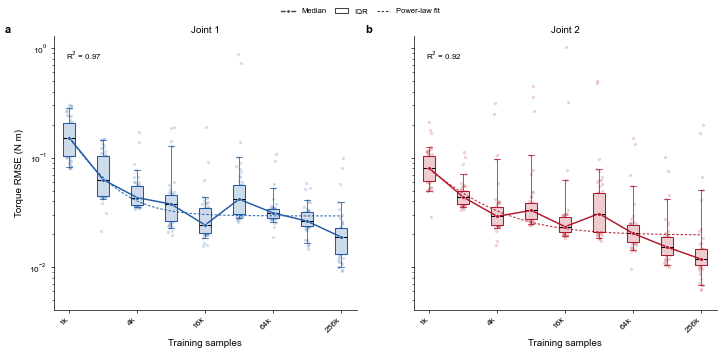

In [32]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import curve_fit

print(f"\n{'='*20} Descriptive Statistics (RMSE) {'='*20}")
print(f"{'Joint':<6} | {'Dataset Size':<12} | {'Mean +/- Std':<20} | {'Median [IQR]':<20}")
print("-" * 70)

joints = sorted(df_rmse['Joint'].unique())
sizes  = sorted(df_rmse['Dataset_Size'].unique(), key=int)

for joint in joints:
    for size in sizes:
        subset = df_rmse[(df_rmse['Dataset_Size'] == size) & (df_rmse['Joint'] == joint)]['RMSE'].astype(float)
        if len(subset) == 0:
            continue

        mean_val = subset.mean()
        std_val  = subset.std()
        median   = subset.median()
        q1       = subset.quantile(0.25)
        q3       = subset.quantile(0.75)
        iqr      = q3 - q1

        mean_std = f"{mean_val:.4f} +/- {std_val:.4f}"
        med_iqr  = f"{median:.4f} [{iqr:.4f}]"
        print(f"{joint:<6} | {str(size):<12} | {mean_std:<20} | {med_iqr:<20}")

print("-" * 70 + "\n")

fig_name = "nature_rmse_distribution_boxplot.svg"
save_fig_path = os.path.join(results_path, fig_name)

BLUE = '#1F5AA6'
RED  = '#B2182B'
joint_palette = {
    'J1': BLUE,
    'J2': RED,
}
joint_names = {
    'J1': 'Joint 1',
    'J2': 'Joint 2',
}


def format_sample_count(value):
    value = int(value)
    if value >= 1000:
        return f"{value // 1000}k"
    return str(value)


def blend_with_white(color, amount):
    rgb = np.array(mpl.colors.to_rgb(color))
    return tuple(rgb * (1.0 - amount) + amount)


def power_law_decay(x, a, b, c):
    return a * np.power(x, -b) + c


def calculate_r_squared(y_observed, y_predicted):
    residual_sum_squares = np.sum((y_observed - y_predicted) ** 2)
    total_sum_squares = np.sum((y_observed - np.mean(y_observed)) ** 2)
    if total_sum_squares == 0:
        return np.nan
    return 1 - residual_sum_squares / total_sum_squares


def fit_power_law_to_medians(joint_name, df, sizes):
    medians = []
    valid_sizes = []
    for size in sizes:
        values = df[(df['Dataset_Size'] == size) & (df['Joint'] == joint_name)]['RMSE'].astype(float)
        if len(values) == 0:
            continue
        valid_sizes.append(float(size))
        medians.append(float(values.median()))

    x_data = np.asarray(valid_sizes, dtype=float)
    y_data = np.asarray(medians, dtype=float)
    if len(x_data) < 3:
        return x_data, y_data, None, np.nan

    c0 = max(np.min(y_data) * 0.8, 0)
    a0 = max((np.max(y_data) - c0) * np.sqrt(np.min(x_data)), 1e-12)
    coeffs, _ = curve_fit(
        power_law_decay,
        x_data,
        y_data,
        p0=[a0, 0.5, c0],
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
        maxfev=10000,
    )
    r_squared = calculate_r_squared(y_data, power_law_decay(x_data, *coeffs))
    return x_data, y_data, coeffs, r_squared


print(f"\n{'='*20} Power-Law Fits to Median RMSE {'='*20}")
print("Model: RMSE = a * Dataset_Size^(-b) + c")
print(f"{'Joint':<6} | {'a':>12} | {'b':>12} | {'c':>12} | {'R^2':>8}")
print("-" * 63)

fit_results = {}
for joint in joints:
    _, _, coeffs, r_squared = fit_power_law_to_medians(joint, df_rmse, sizes)
    if coeffs is None:
        print(f"{joint:<6} | {'Insufficient data for 3-parameter fit':>51}")
        continue
    a, b, c = coeffs
    fit_results[joint] = {'a': a, 'b': b, 'c': c, 'r_squared': r_squared}
    print(f"{joint:<6} | {a:>12.6g} | {b:>12.6g} | {c:>12.6g} | {r_squared:>8.4f}")
print("-" * 63 + "\n")

positions = np.log10(np.asarray(sizes, dtype=float))
tick_sizes = [size for size in [1000, 4000, 16000, 64000, 256000] if size in sizes]
if len(tick_sizes) < 3:
    tick_sizes = sizes

y_values = df_rmse['RMSE'].astype(float).to_numpy()
y_values = y_values[np.isfinite(y_values) & (y_values > 0)]
y_min = max(y_values.min() * 0.65, 1e-4)
y_max = y_values.max() * 1.25

fig_width  = globals().get('double_col', 7.20)
fig_height = fig_width * 0.46

with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}):
    fig, axes = plt.subplots(1, len(joints), figsize=(fig_width, fig_height), sharey=True, constrained_layout=True)
    if len(joints) == 1:
        axes = np.asarray([axes])

    rng = np.random.default_rng(23)

    for panel_idx, (ax, joint) in enumerate(zip(axes, joints)):
        color = joint_palette.get(joint, BLUE if panel_idx == 0 else RED)
        data_by_size = [
            df_rmse[(df_rmse['Dataset_Size'] == size) & (df_rmse['Joint'] == joint)]['RMSE'].astype(float).to_numpy()
            for size in sizes
        ]

        for x_pos, values in zip(positions, data_by_size):
            if len(values) == 0:
                continue
            jitter = rng.uniform(-0.026, 0.026, size=len(values))
            ax.scatter(
                np.full(len(values), x_pos) + jitter,
                values,
                s=5.5,
                color=blend_with_white(color, 0.28),
                alpha=0.28,
                linewidths=0,
                zorder=1,
            )

        box = ax.boxplot(
            data_by_size,
            positions=positions,
            widths=0.11,
            whis=(5, 95),
            showfliers=False,
            patch_artist=True,
            manage_ticks=False,
            medianprops={'color': 'black', 'linewidth': 0.75},
            whiskerprops={'color': color, 'linewidth': 0.55},
            capprops={'color': color, 'linewidth': 0.55},
        )
        for patch in box['boxes']:
            patch.set_facecolor(blend_with_white(color, 0.78))
            patch.set_edgecolor(color)
            patch.set_linewidth(0.75)

        x_data, medians, coeffs, r_squared = fit_power_law_to_medians(joint, df_rmse, sizes)
        if len(x_data):
            ax.plot(
                np.log10(x_data),
                medians,
                color=color,
                linewidth=1.05,
                marker='o',
                markersize=2.7,
                markerfacecolor=color,
                markeredgecolor='white',
                markeredgewidth=0.35,
                zorder=4,
            )
        if coeffs is not None:
            x_fit = np.geomspace(min(sizes), max(sizes), 300)
            y_fit = power_law_decay(x_fit, *coeffs)
            ax.plot(
                np.log10(x_fit),
                y_fit,
                color=color,
                linewidth=0.8,
                linestyle=(0, (2.2, 1.6)),
                alpha=0.9,
                zorder=3,
            )
            ax.text(
                0.04,
                0.95,
                f"R$^2$ = {r_squared:.2f}",
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=5.8,
                color='black',
            )

        ax.set_yscale('log')
        ax.set_xlim(positions.min() - 0.14, positions.max() + 0.14)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(np.log10(np.asarray(tick_sizes, dtype=float)))
        ax.set_xticklabels([format_sample_count(size) for size in tick_sizes], rotation=45, ha='right')
        ax.set_xlabel('Training samples')
        ax.set_title(joint_names.get(joint, joint), fontsize=7, color='black', pad=2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
        ax.tick_params(axis='both', which='minor', direction='out', length=1.6, width=0.4)
        ax.text(-0.16, 1.04, chr(ord('a') + panel_idx), transform=ax.transAxes,
                fontsize=8, fontweight='bold', va='top', color='black')

    axes[0].set_ylabel('Torque RMSE (N m)')

    fig.legend(
        handles=[
            Line2D([0], [0], marker='o', color='0.25', markerfacecolor='0.25', markeredgecolor='white',
                   linewidth=1.0, markersize=3.0, label='Median'),
            Patch(facecolor='white', edgecolor='0.25', linewidth=0.75, label='IQR'),
            Line2D([0], [0], color='0.25', linewidth=0.8, linestyle=(0, (2.2, 1.6)), label='Power-law fit'),
        ],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.06),
        ncol=3,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.1,
    )

    save_base = os.path.splitext(save_fig_path)[0]
    fig.savefig(f'{save_base}.svg', format='svg', bbox_inches='tight', pad_inches=0.03)
    fig.savefig(f'{save_base}.pdf', bbox_inches='tight', pad_inches=0.03)
    fig.savefig(f'{save_base}.png', dpi=600, bbox_inches='tight', pad_inches=0.03)

    print(f"Figure saved to: {save_base}.svg")
    print(f"Also saved as: {save_base}.pdf and {save_base}.png")
    plt.show()


### Supplementary

Here, we load saved model predictions for a fixed test trajectory and compare predicted joint torques across training dataset sizes against the same ground truth over time.

Loading data for trial #0...
Loaded: N=1,000
Loaded: N=2,000
Loaded: N=4,000
Loaded: N=8,000
Loaded: N=16,000
Loaded: N=32,000
Loaded: N=64,000
Loaded: N=128,000
Loaded: N=256,000
Plotting results for Nature Supplementary Information...


Figures saved as ./nature_si_torque_trajectory_comparison.pdf and ./nature_si_torque_trajectory_comparison.png


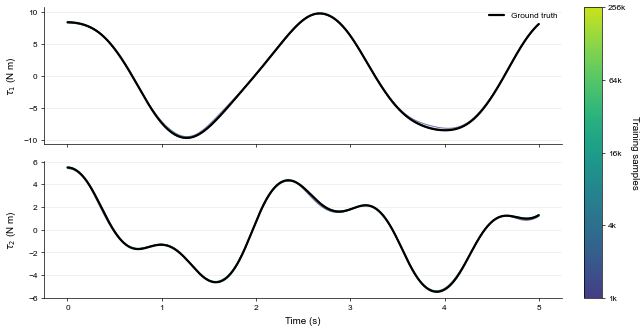

In [33]:
# Configuration
import numpy as np

MODEL_FOLDER = BASE_PATH
RESULT_FILES = [
    'results_model_1000.pt',
    'results_model_2000.pt',
    'results_model_4000.pt',
    'results_model_8000.pt',
    'results_model_16000.pt',
    'results_model_32000.pt',
    'results_model_64000.pt',
    'results_model_128000.pt',
    'results_model_256000.pt'
]
STEP_SIZE_KEY = "0.0001"
TRIAL_IDX     = 0


def to_numpy(array_like):
    if isinstance(array_like, torch.Tensor):
        return array_like.detach().cpu().numpy()
    return np.asarray(array_like)


def format_sample_count(value):
    value = int(value)
    if value >= 1000:
        return f"{value // 1000}k"
    return str(value)


# Initialize containers
ground_truth      = None
time_axis         = None
model_predictions = {}

print(f"Loading data for trial #{TRIAL_IDX}...")

# Load prediction and ground-truth data for each trained model
for res_file in RESULT_FILES:
    load_path = os.path.join(MODEL_FOLDER, res_file)

    if not os.path.exists(load_path):
        print(f"Skipping {res_file}, file not found.")
        continue

    try:
        checkpoint = torch.load(load_path, map_location='cpu')

        # Extract results for the selected integration step size
        if 'results_by_step_size' in checkpoint:
            data = checkpoint['results_by_step_size'][STEP_SIZE_KEY]
        else:
            data = checkpoint[STEP_SIZE_KEY]

        # Use dataset size as the key so the plotted color progression is ordered
        dataset_size = int(res_file.replace('results_model_', '').replace('.pt', '').replace('.pth', ''))

        # Extract predictions, ground truth, and time axis
        curr_pred = data['torques_pred'][TRIAL_IDX]
        curr_true = data['torques_true'][TRIAL_IDX]
        curr_time = data['time_axis']

        # Sanity check consistency of ground truth across models
        if ground_truth is not None:
            if not np.allclose(to_numpy(curr_true), to_numpy(ground_truth), atol=1e-4):
                print(f"Warning: Ground truth mismatch in {res_file}.")
            if not np.allclose(to_numpy(curr_time), to_numpy(time_axis), atol=1e-10):
                print(f"Warning: Time axis mismatch in {res_file}.")

        model_predictions[dataset_size] = curr_pred

        # Store ground truth and time axis once
        if ground_truth is None:
            ground_truth = curr_true
            time_axis    = curr_time

        print(f"Loaded: N={dataset_size:,}")

    except Exception as e:
        print(f"Error loading {res_file}: {e}")

# Plot results using publication formatting for Nature Supplementary Information
if ground_truth is None or not model_predictions:
    print("No valid data found.")
else:
    print("Plotting results for Nature Supplementary Information...")

    loaded_sizes = sorted(model_predictions)
    time_array   = to_numpy(time_axis)
    truth_array  = to_numpy(ground_truth)

    # Double-column width keeps nine model trajectories and the colorbar legible.
    fig_width  = double_col
    fig_height = double_col * golden_ratio * 0.85

    with mpl.rc_context({
        'font.size': 7,
        'axes.labelsize': 7,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'legend.fontsize': 6,
        'axes.linewidth': 0.5,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
    }):
        fig = plt.figure(figsize=(fig_width, fig_height))
        grid = fig.add_gridspec(
            2,
            2,
            width_ratios=(1, 0.035),
            height_ratios=(1, 1),
            wspace=0.08,
            hspace=0.12,
        )
        ax_top = fig.add_subplot(grid[0, 0])
        ax_bottom = fig.add_subplot(grid[1, 0], sharex=ax_top)
        cax = fig.add_subplot(grid[:, 1])
        axes = np.array([ax_top, ax_bottom])

        base_cmap = plt.get_cmap('viridis')
        pred_cmap = mpl.colors.LinearSegmentedColormap.from_list(
            'prediction_dataset_size',
            base_cmap(np.linspace(0.18, 0.92, 256)),
        )
        if len(loaded_sizes) > 1:
            pred_norm = mpl.colors.LogNorm(vmin=min(loaded_sizes), vmax=max(loaded_sizes))
        else:
            pred_norm = mpl.colors.Normalize(vmin=loaded_sizes[0] * 0.9, vmax=loaded_sizes[0] * 1.1)

        for ax, torque_idx, ylabel in zip(
            axes,
            (0, 1),
            (r'$\tau_1$ (N m)', r'$\tau_2$ (N m)'),
        ):
            for dataset_size in loaded_sizes:
                pred_array = to_numpy(model_predictions[dataset_size])
                ax.plot(
                    time_array,
                    pred_array[:, torque_idx],
                    color=pred_cmap(pred_norm(dataset_size)),
                    linewidth=0.75,
                    alpha=0.72,
                    solid_capstyle='round',
                    zorder=2,
                )

            truth_line, = ax.plot(
                time_array,
                truth_array[:, torque_idx],
                color='black',
                linewidth=1.6,
                alpha=1.0,
                solid_capstyle='round',
                label='Ground truth',
                zorder=5,
            )

            ax.set_ylabel(ylabel)
            ax.grid(axis='y', color='0.90', linewidth=0.4, zorder=0)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='both', direction='out', length=2.5, width=0.5, pad=2)

        axes[0].legend(
            handles=[truth_line],
            loc='upper right',
            frameon=False,
            handlelength=1.8,
            borderaxespad=0.2,
        )
        axes[0].tick_params(labelbottom=False)
        axes[1].set_xlabel('Time (s)')

        scalar_mappable = mpl.cm.ScalarMappable(norm=pred_norm, cmap=pred_cmap)
        scalar_mappable.set_array([])
        colorbar = fig.colorbar(scalar_mappable, cax=cax)
        tick_indices = np.unique(
            np.round(np.linspace(0, len(loaded_sizes) - 1, min(5, len(loaded_sizes)))).astype(int)
        )
        colorbar.set_ticks([loaded_sizes[idx] for idx in tick_indices])
        colorbar.set_ticklabels([format_sample_count(loaded_sizes[idx]) for idx in tick_indices])
        colorbar.set_label('Training samples', rotation=270, labelpad=9)
        colorbar.ax.tick_params(direction='out', length=2.5, width=0.5, pad=2)
        colorbar.outline.set_linewidth(0.5)
        colorbar.minorticks_off()

        fig.align_ylabels(axes)
        fig.tight_layout(pad=0.4)

        save_filename = os.path.join(MODEL_FOLDER, 'nature_si_torque_trajectory_comparison')
        fig.savefig(f"{save_filename}.pdf")
        fig.savefig(f"{save_filename}.png", dpi=600)

        print(f"Figures saved as {save_filename}.pdf and {save_filename}.png")
        plt.show()


# Section 5: Direct torque-regression baseline

ANNet obtains the joint torques as the gradient of a learned scalar energy, whereas a multilayer perceptron (MLP) can be trained directly on $(\mathbf{q}, \dot{\mathbf{q}}, \ddot{\mathbf{q}}) \rightarrow \boldsymbol{\tau}$. A comparison of the two shows whether the inverse-dynamics accuracy of ANNet reflects the Appell-energy parameterization rather than network capacity. This section therefore trains a **direct torque regressor**, that is, the same network as ANNet in every respect except the output layer, which has two linear units that return the joint torques directly instead of the single unit that returns the scalar Appell acceleration energy. The training-data distribution, dataset size (16,000 samples, i.e. the ANNet used for all downstream analyses), optimizer, learning rate, batch size, number of epochs, validation schedule and checkpoint selection are identical to Section 3, and the loss is the mean squared torque error in physical units, i.e. the same quantity that the physics-informed loss minimizes through the acceleration gradient. Both models are then evaluated on the identical fixed test set of 50 reference trajectories from Section 4, and the trajectory-wise torque RMSE distributions are compared statistically. The result is exported as Fig. 4 together with its data package.

The section requires the library imports and the definition cells of Sections 1 to 3 and reads the cached files `test_set_50_traj_5s.pt` and `results_model_16000.pt`. Every expensive step is skipped when its output files already exist.

### Constants

In [34]:
# Direct torque-regression baseline: dependencies, constants and file paths.

_mlp_required_names = [
    # imports (Libraries import cell)
    'os', 'time', 'np', 'pd', 'torch', 'nn', 'optim', 'Subset', 'DataLoader',
    'scipy_stats', 'multipletests', 'mpl', 'plt', 'Line2D',
    # analytical kernels and numeric helpers (Section 1)
    'TORCH_DTYPE', 'TORCH_EPS', 'compute_S_ground_truth_eager', 'compute_tau_ground_truth_eager',
    # constants and dataset (Section 2)
    'PARAMS', 'BATCH_SIZE', 'device', 'MechanicsDataset',
    # training constants and network helpers (Section 3)
    'EPOCHS', 'LR', 'NUM_NODE_L1', 'NUM_NODE_L2', 'NUM_NODE_L3', 'NUM_NODE_L4',
    'GibbsAppellNet', 'maybe_compile_model', 'checkpoint_model',
]
_mlp_missing_names = [name for name in _mlp_required_names if name not in globals()]
if _mlp_missing_names:
    raise RuntimeError(
        "Run the definition cells of Sections 1-3 first (library imports, analytical "
        "kernels, constants, MechanicsDataset, training hyperparameters and network "
        f"helpers). Missing names: {_mlp_missing_names}"
    )

# Training-set size of the ANNet used for all downstream analyses (Sections 4 and 6-9)
MLP_N_SAMPLES = 16000

# Same seed as the ANNet training pipeline (Section 2)
MLP_SEED = 27

# Files are stored next to the ANNet artifacts, following the same naming scheme
MLP_BASE_PATH = output_dir if 'output_dir' in globals() else '.'
MLP_TAG = f"mlp_{MLP_N_SAMPLES}"
MLP_MODEL_PATH     = os.path.join(MLP_BASE_PATH, f"model_{MLP_TAG}.pth")
MLP_STATS_PATH     = os.path.join(MLP_BASE_PATH, f"stats_{MLP_TAG}.pt")
MLP_HISTORY_PATH   = os.path.join(MLP_BASE_PATH, f"history_{MLP_TAG}.pt")
MLP_TIME_PATH      = os.path.join(MLP_BASE_PATH, f"time_{MLP_TAG}.txt")
MLP_RESULTS_PATH   = os.path.join(MLP_BASE_PATH, f"results_model_{MLP_TAG}.pt")
MLP_STATS_CSV_PATH = os.path.join(MLP_BASE_PATH, f"baseline_torque_rmse_statistics_{MLP_TAG}.csv")

# ANNet artifacts for the same training-set size (produced in Sections 3 and 4)
ANNET_MODEL_PATH   = os.path.join(MLP_BASE_PATH, f"model_{MLP_N_SAMPLES}.pth")
ANNET_STATS_PATH   = os.path.join(MLP_BASE_PATH, f"stats_{MLP_N_SAMPLES}.pt")
ANNET_HISTORY_PATH = os.path.join(MLP_BASE_PATH, f"history_{MLP_N_SAMPLES}.pt")
ANNET_TIME_PATH    = os.path.join(MLP_BASE_PATH, f"time_{MLP_N_SAMPLES}.txt")
ANNET_RESULTS_PATH = os.path.join(MLP_BASE_PATH, f"results_model_{MLP_N_SAMPLES}.pt")

# Fixed test set of Section 4 (50 RK4 reference trajectories, 5 s, 0.1 ms step)
MLP_TEST_SET_PATH = os.path.join(MLP_BASE_PATH, "test_set_50_traj_5s.pt")
MLP_TEST_STEP_KEY = "0.0001"   # key of the results dictionaries in results_model_*.pt

# Destinations of the figure and its data package (SUBMISSION tree).
# The notebook is expected to run from SIMULATIONS/; if the tree is not found,
# the files are written next to the notebook instead.
MLP_FIGURE_NAME = 'FIG4'
_mlp_repo_root = os.path.normpath(os.path.join(MLP_BASE_PATH, os.pardir))
MLP_FIGURE_DIR  = os.path.join(_mlp_repo_root, 'SUBMISSION', 'FIGURES', 'PDF AND PNG')
MLP_PACKAGE_DIR = os.path.join(_mlp_repo_root, 'SUBMISSION', 'FIGURES', 'DATA AND SCRIPTS')
for _mlp_dir_name in ('MLP_FIGURE_DIR', 'MLP_PACKAGE_DIR'):
    if not os.path.isdir(globals()[_mlp_dir_name]):
        print(f"Warning: {globals()[_mlp_dir_name]} not found; {_mlp_dir_name} falls back to '{MLP_BASE_PATH}'.")
        globals()[_mlp_dir_name] = MLP_BASE_PATH

print(f"Baseline model file:   {MLP_MODEL_PATH}")
print(f"Baseline results file: {MLP_RESULTS_PATH}")
print(f"ANNet results file:    {ANNET_RESULTS_PATH}")
print(f"Figure directory:      {MLP_FIGURE_DIR}")
print(f"Data-package directory: {MLP_PACKAGE_DIR}")

Baseline model file:   ./model_mlp_16000.pth
Baseline results file: ./results_model_mlp_16000.pt
ANNet results file:    ./results_model_16000.pt
Figure directory:      ../SUBMISSION/FIGURES/PDF AND PNG
Data-package directory: ../SUBMISSION/FIGURES/DATA AND SCRIPTS


### Direct torque regressor

The baseline keeps the hidden architecture of `GibbsAppellNet` (four GELU layers with 225, 61, 91 and 99 nodes, standardized six-dimensional input) and replaces the single output unit with two linear units that return the joint torques directly. The network output is standardized per joint with dataset-level statistics, in the same way the Appell energy is standardized for ANNet, and the loss is the mean squared error between the de-standardized prediction and the ground-truth torques in physical units. This is the same quantity that `compute_force_loss` minimizes for ANNet; the only difference is where the torque comes from (the output layer instead of the input-gradient of the scalar energy). Consequently, the baseline does not need the input-gradient computation during training or inference.

In [35]:
# Direct torque regressor: same hidden layers as GibbsAppellNet, two-unit torque output
class DirectTorqueNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Identical hidden architecture to GibbsAppellNet
        self.net = nn.Sequential(
            nn.Linear(6, NUM_NODE_L1),
            nn.GELU(),
            nn.Linear(NUM_NODE_L1, NUM_NODE_L2),
            nn.GELU(),
            nn.Linear(NUM_NODE_L2, NUM_NODE_L3),
            nn.GELU(),
            nn.Linear(NUM_NODE_L3, NUM_NODE_L4),
            nn.GELU(),
            nn.Linear(NUM_NODE_L4, 2),  # Output layer: standardized joint torques (tau1, tau2)
        )

    def forward(self, x):
        # Forward pass through the network
        return self.net(x)


def compute_direct_torque_loss(model, X_batch, tau_real_batch, tau_mean, tau_std):
    """
    Computes the mean squared torque error in physical units for the direct regressor.

    Mirrors compute_force_loss: the loss is the MSE between predicted and ground-truth
    torques in real units. The only difference is that the torque is read from the
    output layer (de-standardized) instead of being obtained as the scaled
    input-gradient of the predicted acceleration energy.

    Args:
        model: The direct torque regressor.
        X_batch: Normalized inputs [N, 6].
        tau_real_batch: Ground-truth torques [N, 2] in real units.
        tau_mean: Per-joint torque mean used for output standardization [2].
        tau_std: Per-joint torque standard deviation used for output standardization [2].
    """
    tau_pred_real = model(X_batch) * tau_std + tau_mean
    return torch.mean((tau_pred_real - tau_real_batch) ** 2)


def count_trainable_parameters(module):
    return sum(param.numel() for param in module.parameters() if param.requires_grad)


_mlp_num_params_annet = count_trainable_parameters(GibbsAppellNet())
_mlp_num_params_direct = count_trainable_parameters(DirectTorqueNet())
print(f"Trainable parameters | ANNet (1 output): {_mlp_num_params_annet:,} | "
      f"direct torque regressor (2 outputs): {_mlp_num_params_direct:,} | "
      f"difference: {_mlp_num_params_direct - _mlp_num_params_annet:+,} (output layer only)")

Trainable parameters | ANNet (1 output): 30,211 | direct torque regressor (2 outputs): 30,311 | difference: +100 (output layer only)


### Training

The training loop below replicates the ANNet loop of Section 3 step by step: a fresh 16,000-sample dataset from `MechanicsDataset` (same sampling ranges and analytical labels), an 80/20 split, mini-batches of 64, the Adam optimizer with the learning rate found by the hyperparameter search, 3,000 epochs, validation every 100 epochs and selection of the checkpoint with the lowest validation loss. Because the loss is expressed in physical torque units for both models, their training and validation losses are directly comparable. The dataset is drawn with the same seed as the ANNet pipeline; the specific random draw seen by the 16,000-sample ANNet cannot be reproduced (the generator state at that point depended on the preceding training runs), so the comparison is between two models trained on independent samples of the same distribution. Training is skipped when the model file already exists.

In [36]:
import platform


def train_direct_torque_regressor():
    """
    Trains the direct torque regressor with the protocol of the ANNet training cell
    (Section 3) and saves model, normalization statistics, history and training time.
    """
    # Same seed as the ANNet pipeline (Section 2)
    torch.manual_seed(MLP_SEED)

    # Generate a fresh dataset with the eager analytical kernels (same as the ANNet
    # data-generation path on CPU)
    print(f"Generating dataset with {MLP_N_SAMPLES} samples using eager analytical kernels...")
    full_dataset = MechanicsDataset(
        n_samples=MLP_N_SAMPLES,
        S_fn=compute_S_ground_truth_eager,
        tau_fn=compute_tau_ground_truth_eager,
    )

    # Output standardization for the two torque targets, computed on the full dataset
    # in the same way as the input and energy statistics
    tau_mean = full_dataset.tau.mean(dim=0)
    tau_std  = full_dataset.tau.std(dim=0)

    # Save normalization statistics for later inference
    print(f"Saving statistics to '{MLP_STATS_PATH}'...")
    norm_stats = {
        'n_samples': MLP_N_SAMPLES,
        'X_mean':    full_dataset.X_mean,
        'X_std':     full_dataset.X_std,
        'tau_mean':  tau_mean,
        'tau_std':   tau_std,
        'S_mean':    full_dataset.S_mean,   # stored for reference only; not used by this model
        'S_std':     full_dataset.S_std,
        # Run environment, for the provenance of the recorded training time
        'device':         str(device),
        'torch_version':  str(torch.__version__),   # plain str so the file loads with weights_only=True
        'platform':       platform.platform(),
        'processor':      platform.processor() or platform.machine(),
        'model_compiled': bool(USE_TORCH_COMPILE_FOR_MODEL),
    }
    torch.save(norm_stats, MLP_STATS_PATH)

    # Split dataset: 80% training, 20% validation
    split_idx     = int(0.8 * len(full_dataset))
    train_dataset = Subset(full_dataset, range(0, split_idx))
    test_dataset  = Subset(full_dataset, range(split_idx, len(full_dataset)))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Fresh network and optimizer
    model = maybe_compile_model(DirectTorqueNet().to(device))
    optimizer = optim.Adam(model.parameters(), lr=LR)

    tau_mean_dev = tau_mean.to(device, dtype=TORCH_DTYPE)
    tau_std_dev  = tau_std.to(device, dtype=TORCH_DTYPE)

    train_history = []
    test_history  = []
    best_val_loss = float('inf')
    best_epoch    = -1

    print(f"Starting training on {device}...")

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    # Training loop
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for X_batch, tau_batch in train_loader:
            X_batch   = X_batch.to(device)   # No input gradients needed: torque is read from the output layer
            tau_batch = tau_batch.to(device)

            optimizer.zero_grad()

            loss = compute_direct_torque_loss(model, X_batch, tau_batch, tau_mean_dev, tau_std_dev)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_history.append(avg_train_loss)

        # Periodic validation every 100 epochs
        if epoch % 100 == 0:
            model.eval()
            total_val_loss = 0.0

            with torch.no_grad():
                for X_test, tau_test in test_loader:
                    X_test   = X_test.to(device)
                    tau_test = tau_test.to(device)

                    loss_val = compute_direct_torque_loss(model, X_test, tau_test, tau_mean_dev, tau_std_dev)
                    total_val_loss += loss_val.item()

            avg_val_loss = total_val_loss / len(test_loader)
            test_history.append((epoch, avg_val_loss))

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_epoch = epoch
                torch.save(checkpoint_model(model).state_dict(), MLP_MODEL_PATH)
                print(f"Epoch {epoch:4d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | Saved new best model")
            else:
                print(f"Epoch {epoch:4d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | Best: {best_val_loss:.6f}")

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - start_time
    print(f"Training finished in {elapsed_seconds:.2f} seconds.")

    # Save training duration
    with open(MLP_TIME_PATH, 'w') as f:
        f.write(str(elapsed_seconds))

    if best_epoch >= 0:
        print(f"Best model already saved to '{MLP_MODEL_PATH}' from epoch {best_epoch} with validation loss {best_val_loss:.6f}.")
    else:
        print("Warning: no validation checkpoint was saved.")

    # Save training history
    print(f"Saving history to '{MLP_HISTORY_PATH}'...")
    torch.save({'train': train_history, 'test': test_history}, MLP_HISTORY_PATH)


print(f"{'='*50}")
print(f"Direct torque regressor, dataset size: {MLP_N_SAMPLES}")
print(f"{'='*50}")
# The checkpoint is written at the first validation pass and updated on every improvement,
# so training is only considered complete when the history and timing files (written after
# the last epoch) exist as well.
_mlp_completion_files = (MLP_MODEL_PATH, MLP_STATS_PATH, MLP_HISTORY_PATH, MLP_TIME_PATH)
if all(os.path.exists(path) for path in _mlp_completion_files):
    print(f"Found existing model: '{MLP_MODEL_PATH}' (with statistics, history and timing files)")
    print("Skipping training of the direct torque regressor...")
else:
    if os.path.exists(MLP_MODEL_PATH):
        print(f"Found '{MLP_MODEL_PATH}' but not all of {[os.path.basename(p) for p in _mlp_completion_files]};")
        print("the previous training run did not complete. Retraining from scratch...")
    train_direct_torque_regressor()

Direct torque regressor, dataset size: 16000
Generating dataset with 16000 samples using eager analytical kernels...
Saving statistics to './stats_mlp_16000.pt'...


Starting training on cpu...

Epoch    0 | Train: 202.319176 | Val: 19.900666 | Saved new best model


Epoch  100 | Train: 0.098688 | Val: 0.161772 | Saved new best model


Epoch  200 | Train: 0.076362 | Val: 0.145063 | Saved new best model


...

Epoch 2600 | Train: 0.041214 | Val: 0.040290 | Best: 0.009506


Epoch 2700 | Train: 0.016515 | Val: 0.009813 | Best: 0.009506


Epoch 2800 | Train: 0.023236 | Val: 0.021730 | Best: 0.009506


Epoch 2900 | Train: 0.022833 | Val: 0.029626 | Best: 0.009506


Training finished in 324.12 seconds.
Best model already saved to './model_mlp_16000.pth' from epoch 1800 with validation loss 0.009506.
Saving history to './history_mlp_16000.pt'...


### Inverse-dynamics accuracy on the fixed test set

Both models are scored on the fixed test set of Section 4: 50 reference trajectories of 5 s generated with the fourth-order Runge-Kutta integrator at a 0.1 ms step, with ground-truth torques from the analytical inertial forces. For the direct regressor the torque is a single forward pass; for ANNet it is the scaled input-gradient of the predicted acceleration energy, and its per-trajectory RMSEs are read from the results file produced in Section 4 (`results_model_16000.pt`) so that the comparison is against the values reported in the manuscript. The cell verifies that the ANNet results were computed against exactly the same ground-truth torques before assembling both sets of trajectory-wise RMSE values into one table.

In [37]:
import hashlib


def sha256_of_file(path, chunk_size=1 << 20):
    digest = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


def load_fixed_test_set():
    """Reuses the fixed test set if Section 4 was executed in this kernel, otherwise loads the cached file."""
    if all(name in globals() for name in ('FIXED_INPUTS', 'FIXED_TARGETS', 'fixed_time_axis')):
        return FIXED_INPUTS, FIXED_TARGETS, fixed_time_axis
    if not os.path.exists(MLP_TEST_SET_PATH):
        raise FileNotFoundError(
            f"Fixed test set not found at '{MLP_TEST_SET_PATH}'. Run the test-set cell of Section 4 first."
        )
    cached_data = torch.load(MLP_TEST_SET_PATH, map_location='cpu')
    return cached_data['inputs'], cached_data['targets'], cached_data['time_axis']


def evaluate_direct_torque_regressor(inputs, targets, time_axis):
    """
    Predicts torques on every test trajectory and returns per-trajectory RMSEs,
    mirroring the ANNet evaluation loop of Section 4.
    """
    model_stats = torch.load(MLP_STATS_PATH, map_location=device)
    stats_mean  = model_stats['X_mean'].to(device=device, dtype=torch.float32)
    stats_X_std = model_stats['X_std'].to(device=device, dtype=torch.float32)
    inv_X_std   = 1.0 / (stats_X_std + 1e-8)
    tau_mean    = model_stats['tau_mean'].to(device=device, dtype=torch.float32)
    tau_std     = model_stats['tau_std'].to(device=device, dtype=torch.float32)

    model = DirectTorqueNet().to(device)
    model.load_state_dict(torch.load(MLP_MODEL_PATH, map_location=device))
    model.eval()
    for param in model.parameters():
        param.requires_grad_(False)

    inputs_device  = inputs.to(device=device, dtype=torch.float32)
    targets_device = targets.to(device=device, dtype=torch.float32)
    num_trajectories = inputs_device.shape[0]
    perf_counter = time.perf_counter

    all_pred_tau = torch.empty_like(targets_device)
    inference_times = torch.empty(num_trajectories, dtype=torch.float64)

    for i in range(num_trajectories):
        if (i + 1) % 10 == 0:
            print(f"Evaluating Trajectory {i + 1}/{num_trajectories}")

        input_norm = (inputs_device[i] - stats_mean) * inv_X_std

        if device.type == 'cuda':
            torch.cuda.synchronize()
        t_start = perf_counter()

        with torch.no_grad():
            t_pred = model(input_norm) * tau_std + tau_mean

        if device.type == 'cuda':
            torch.cuda.synchronize()
        inference_times[i] = perf_counter() - t_start

        all_pred_tau[i].copy_(t_pred)

    rmse = torch.sqrt(torch.mean((targets_device - all_pred_tau) ** 2, dim=1))

    return {
        'torques_pred':    all_pred_tau.cpu(),
        'time_axis':       time_axis,
        'rmse_j1':         rmse[:, 0].cpu().tolist(),
        'rmse_j2':         rmse[:, 1].cpu().tolist(),
        'inference_times': inference_times.tolist(),
        'dt':              float(MLP_TEST_STEP_KEY),
        'test_set_file':   os.path.basename(MLP_TEST_SET_PATH),
        'model_file':      os.path.basename(MLP_MODEL_PATH),
        'model_sha256':    sha256_of_file(MLP_MODEL_PATH),
        'stats_file':      os.path.basename(MLP_STATS_PATH),
        'stats_sha256':    sha256_of_file(MLP_STATS_PATH),
        'test_set_sha256': sha256_of_file(MLP_TEST_SET_PATH) if os.path.exists(MLP_TEST_SET_PATH) else None,
        'note': ('Inputs and ground-truth torques are those of the fixed test set '
                 '(identical to results_model_16000.pt) and are not duplicated here.'),
    }


def load_cached_baseline_results():
    """Returns the cached results only if they were computed from the current model, statistics and test-set files."""
    if not os.path.exists(MLP_RESULTS_PATH):
        return None
    cached = torch.load(MLP_RESULTS_PATH, map_location='cpu')[MLP_TEST_STEP_KEY]
    current_hashes = {
        'model_sha256': sha256_of_file(MLP_MODEL_PATH),
        'stats_sha256': sha256_of_file(MLP_STATS_PATH),
        'test_set_sha256': sha256_of_file(MLP_TEST_SET_PATH) if os.path.exists(MLP_TEST_SET_PATH) else None,
    }
    if all(cached.get(key) == value for key, value in current_hashes.items()):
        return cached
    print(f"Existing results '{MLP_RESULTS_PATH}' were computed from a different model, statistics or test-set file; re-evaluating.")
    return None


mlp_fixed_inputs, mlp_fixed_targets, mlp_time_axis = load_fixed_test_set()
print(f"Fixed test set: {tuple(mlp_fixed_inputs.shape)} (trajectories x samples x [q1, q2, dq1, dq2, ddq1, ddq2])")

mlp_results = load_cached_baseline_results()
if mlp_results is not None:
    print(f"Found existing results: '{MLP_RESULTS_PATH}' (matching the current model) -- loading instead of re-evaluating.")
else:
    print("Evaluating the direct torque regressor on the fixed test set...")
    mlp_results = evaluate_direct_torque_regressor(mlp_fixed_inputs, mlp_fixed_targets, mlp_time_axis)
    torch.save({MLP_TEST_STEP_KEY: mlp_results}, MLP_RESULTS_PATH)
    print(f"Saved results to '{MLP_RESULTS_PATH}'.")

# ANNet results for the same training-set size, produced in Section 4 on the same fixed test set
print(f"Loading ANNet results from '{ANNET_RESULTS_PATH}'...")
mlp_annet_results = torch.load(ANNET_RESULTS_PATH, map_location='cpu')[MLP_TEST_STEP_KEY]

# Both models must have been scored against the identical ground-truth torques
if not torch.equal(mlp_annet_results['torques_true'].to(torch.float32), mlp_fixed_targets.to(torch.float32)):
    raise RuntimeError("The ANNet results file and the fixed test set contain different ground-truth torques.")
if not (len(mlp_annet_results['rmse_j1']) == len(mlp_results['rmse_j1']) == mlp_fixed_inputs.shape[0]):
    raise RuntimeError("The number of evaluated trajectories differs between the two models.")
print("Verified: ANNet and the direct regressor were evaluated on identical trajectories and torque targets.")

# Long-form table of trajectory-wise torque RMSEs for both models
mlp_rmse_records = []
for model_name, results in (('ANNet', mlp_annet_results), ('MLP', mlp_results)):
    for joint, rmse_key in (('J1', 'rmse_j1'), ('J2', 'rmse_j2')):
        for trajectory_idx, value in enumerate(results[rmse_key]):
            mlp_rmse_records.append({
                'model': model_name,
                'joint': joint,
                'trajectory': trajectory_idx,
                'rmse_nm': float(value),
            })
mlp_rmse_df = pd.DataFrame(mlp_rmse_records)

# Training-side comparison: best validation loss (MSE in (Nm)^2) and training time
def _mlp_best_validation_mse(history_path):
    if not os.path.exists(history_path):
        raise FileNotFoundError(f"Training history '{history_path}' not found; the training run did not complete.")
    history = torch.load(history_path, map_location='cpu')
    return min(value for _, value in history['test'])

def _mlp_training_time_s(time_path):
    if not os.path.exists(time_path):
        raise FileNotFoundError(f"Training time file '{time_path}' not found; the training run did not complete.")
    with open(time_path) as f:
        return float(f.read().strip())

mlp_training_summary = pd.DataFrame([
    {'model': 'ANNet', 'best_validation_mse_nm2': _mlp_best_validation_mse(ANNET_HISTORY_PATH),
     'training_time_s': _mlp_training_time_s(ANNET_TIME_PATH)},
    {'model': 'MLP', 'best_validation_mse_nm2': _mlp_best_validation_mse(MLP_HISTORY_PATH),
     'training_time_s': _mlp_training_time_s(MLP_TIME_PATH)},
])
mlp_training_summary['best_validation_rmse_nm'] = np.sqrt(mlp_training_summary['best_validation_mse_nm2'])

print("\n--- Training summary (validation split of the training data) ---")
print(mlp_training_summary.to_string(index=False, float_format=lambda v: f"{v:.5g}"))
print("Training times are the wall-clock durations of the archived runs (see Hardware specifications in the")
print("manuscript for ANNet and stats_mlp_16000.pt for the direct regressor); they are not a controlled comparison.")


def print_rmse_descriptives(rmse_df):
    print("\n--- Descriptive statistics of trajectory-wise torque RMSE on the fixed test set ---")
    print(f"{'Model':<7} | {'Joint':<5} | {'N':<4} | {'Mean +/- SD (Nm)':<22} | {'Median [IQR] (Nm)':<22} | {'Min / Max (Nm)'}")
    print('-' * 95)
    for model_name in ('ANNet', 'MLP'):
        for joint in ('J1', 'J2'):
            values = rmse_df[(rmse_df['model'] == model_name) & (rmse_df['joint'] == joint)]['rmse_nm']
            q1, median, q3 = values.quantile([0.25, 0.5, 0.75])
            print(f"{model_name:<7} | {joint:<5} | {len(values):<4} | "
                  f"{values.mean():.4f} +/- {values.std():.4f}      | "
                  f"{median:.4f} [{q3 - q1:.4f}]        | "
                  f"{values.min():.4f} / {values.max():.4f}")
    print('-' * 95)


print_rmse_descriptives(mlp_rmse_df)

Fixed test set: (50, 50001, 6) (trajectories x samples x [q1, q2, dq1, dq2, ddq1, ddq2])
Evaluating the direct torque regressor on the fixed test set...


Evaluating Trajectory 10/50


Evaluating Trajectory 20/50


Evaluating Trajectory 30/50


Evaluating Trajectory 40/50


Evaluating Trajectory 50/50
Saved results to './results_model_mlp_16000.pt'.
Loading ANNet results from './results_model_16000.pt'...
Verified: ANNet and the direct regressor were evaluated on identical trajectories and torque targets.

--- Training summary (validation split of the training data) ---
model  best_validation_mse_nm2  training_time_s  best_validation_rmse_nm
ANNet                0.0038544           463.66                 0.062084
  MLP                0.0095065           324.12                 0.097501
Training times are the wall-clock durations of the archived runs (see Hardware specifications in the
manuscript for ANNet and stats_mlp_16000.pt for the direct regressor); they are not a controlled comparison.

--- Descriptive statistics of trajectory-wise torque RMSE on the fixed test set ---
Model   | Joint | N    | Mean +/- SD (Nm)       | Median [IQR] (Nm)      | Min / Max (Nm)
----------------------------------------------------------------------------------------------

### Statistical comparison

For each joint, the trajectory-wise torque RMSE distributions of the two models are first tested for normality with the Shapiro-Wilk test ($\alpha = 0.05$). If both distributions are normal, the models are compared with a one-way ANOVA; otherwise, with a Kruskal-Wallis H-test, following the convention used elsewhere in this notebook. The resulting p-values are corrected across joints with the Benjamini-Hochberg false discovery rate procedure. Because the two models are scored on the same 50 trajectories, a paired Wilcoxon signed-rank test is also reported as a secondary check, together with the two-sided Mann-Whitney U test (asymptotically equivalent to the Kruskal-Wallis test for two groups; SciPy applies a continuity correction, so its p-value differs slightly), the ratio of medians and Cliff's delta as effect sizes. The U statistic, the median ratio and Cliff's delta are all reported in the direction MLP versus ANNet. The full table is saved as a CSV file next to the other artifacts.

In [38]:
MLP_ALPHA = 0.05


def cliffs_delta(values_a, values_b):
    """Cliff's delta = P(a > b) - P(a < b) over all pairs; positive when `values_a` tends to be larger."""
    a = np.asarray(values_a, dtype=float)[:, None]
    b = np.asarray(values_b, dtype=float)[None, :]
    return float(np.mean(np.sign(a - b)))


def compute_baseline_statistics(rmse_df, alpha=MLP_ALPHA):
    """
    Per-joint comparison of the trajectory-wise torque RMSE distributions of ANNet and the
    direct torque regressor: Shapiro-Wilk normality of each group, one-way ANOVA if both
    groups are normal (Kruskal-Wallis H-test otherwise), Benjamini-Hochberg correction
    across joints, secondary Mann-Whitney U and paired Wilcoxon tests, and effect sizes.
    """
    print(f"\n{'='*20} Normality Test (Shapiro-Wilk) {'='*20}")
    print(f"{'Joint':<6} | {'Model':<6} | {'P-Value':<12} | {'Distribution'}")
    print('-' * 60)

    rows = []
    for joint in ('J1', 'J2'):
        subset = rmse_df[rmse_df['joint'] == joint].sort_values(['model', 'trajectory'])
        annet_values = subset[subset['model'] == 'ANNet']['rmse_nm'].to_numpy(dtype=float)
        mlp_values   = subset[subset['model'] == 'MLP']['rmse_nm'].to_numpy(dtype=float)

        # Normality of each group
        shapiro_annet = scipy_stats.shapiro(annet_values)
        shapiro_mlp   = scipy_stats.shapiro(mlp_values)
        for model_name, shapiro_result in (('ANNet', shapiro_annet), ('MLP', shapiro_mlp)):
            is_normal = shapiro_result.pvalue > alpha
            p_str = f"{shapiro_result.pvalue:.2e}" if is_normal else f"*{shapiro_result.pvalue:.2e}"
            print(f"{joint:<6} | {model_name:<6} | {p_str:<12} | {'Normal' if is_normal else 'Not Normal'}")
        both_normal = (shapiro_annet.pvalue > alpha) and (shapiro_mlp.pvalue > alpha)

        # Primary test: parametric if both groups are normal, non-parametric otherwise
        if both_normal:
            test_name = 'One-way ANOVA'
            primary = scipy_stats.f_oneway(annet_values, mlp_values)
        else:
            test_name = 'Kruskal-Wallis H-test'
            primary = scipy_stats.kruskal(annet_values, mlp_values)

        # Secondary tests: two-sided Mann-Whitney U (unpaired) and Wilcoxon signed-rank (paired by
        # trajectory). Both are evaluated in the direction MLP vs ANNet, like the effect sizes below.
        mann_whitney = scipy_stats.mannwhitneyu(mlp_values, annet_values, alternative='two-sided')
        wilcoxon = scipy_stats.wilcoxon(mlp_values, annet_values, alternative='two-sided')

        annet_q1, annet_median, annet_q3 = np.percentile(annet_values, [25, 50, 75])
        mlp_q1, mlp_median, mlp_q3 = np.percentile(mlp_values, [25, 50, 75])

        rows.append({
            'joint': joint,
            'joint_label': f"Joint {joint[1]}",
            'n_annet': int(annet_values.size),
            'n_mlp': int(mlp_values.size),
            'shapiro_p_annet': float(shapiro_annet.pvalue),
            'shapiro_p_mlp': float(shapiro_mlp.pvalue),
            'both_normal': bool(both_normal),
            'test_name': test_name,
            'statistic': float(primary.statistic),
            'p_value': float(primary.pvalue),
            'mann_whitney_u_mlp_vs_annet': float(mann_whitney.statistic),
            'mann_whitney_p_two_sided': float(mann_whitney.pvalue),
            'wilcoxon_paired_statistic': float(wilcoxon.statistic),
            'wilcoxon_paired_p_two_sided': float(wilcoxon.pvalue),
            'mean_annet_nm': float(annet_values.mean()),
            'sd_annet_nm': float(annet_values.std(ddof=1)),
            'median_annet_nm': float(annet_median),
            'iqr_annet_nm': float(annet_q3 - annet_q1),
            'mean_mlp_nm': float(mlp_values.mean()),
            'sd_mlp_nm': float(mlp_values.std(ddof=1)),
            'median_mlp_nm': float(mlp_median),
            'iqr_mlp_nm': float(mlp_q3 - mlp_q1),
            'median_ratio_mlp_over_annet': float(mlp_median / annet_median),
            'cliffs_delta_mlp_vs_annet': cliffs_delta(mlp_values, annet_values),
        })

    print('-' * 60)
    print("* p < 0.05 indicates data is not normally distributed.")

    stats_df = pd.DataFrame(rows)

    # Benjamini-Hochberg correction of the primary p-values across the two joints
    stats_df['fdr_q_value'] = multipletests(stats_df['p_value'].to_numpy(), method='fdr_bh')[1]
    stats_df['significant_fdr_0_05'] = stats_df['fdr_q_value'] < alpha
    return stats_df[[
        'joint', 'joint_label', 'n_annet', 'n_mlp', 'shapiro_p_annet', 'shapiro_p_mlp', 'both_normal',
        'test_name', 'statistic', 'p_value', 'fdr_q_value', 'significant_fdr_0_05',
        'mann_whitney_u_mlp_vs_annet', 'mann_whitney_p_two_sided',
        'wilcoxon_paired_statistic', 'wilcoxon_paired_p_two_sided',
        'mean_annet_nm', 'sd_annet_nm', 'median_annet_nm', 'iqr_annet_nm',
        'mean_mlp_nm', 'sd_mlp_nm', 'median_mlp_nm', 'iqr_mlp_nm',
        'median_ratio_mlp_over_annet', 'cliffs_delta_mlp_vs_annet',
    ]]


def print_baseline_statistics(stats_df, alpha=MLP_ALPHA):
    print(f"\n{'='*20} Hypothesis testing: ANNet vs direct torque regressor {'='*20}")
    for _, row in stats_df.iterrows():
        verdict = 'significant' if row['significant_fdr_0_05'] else 'not significant'
        print(f"{row['joint_label']}: {row['test_name']} | statistic = {row['statistic']:.4f} | "
              f"p = {row['p_value']:.3e} | FDR q = {row['fdr_q_value']:.3e} -> {verdict} at alpha = {alpha}")
        print(f"   secondary: Mann-Whitney U (MLP vs ANNet) = {row['mann_whitney_u_mlp_vs_annet']:.1f} "
              f"(p = {row['mann_whitney_p_two_sided']:.3e}); paired Wilcoxon W = {row['wilcoxon_paired_statistic']:.1f} "
              f"(p = {row['wilcoxon_paired_p_two_sided']:.3e})")
        print(f"   medians: ANNet {row['median_annet_nm']:.4f} Nm vs MLP {row['median_mlp_nm']:.4f} Nm "
              f"(ratio MLP/ANNet = {row['median_ratio_mlp_over_annet']:.2f}); "
              f"Cliff's delta (MLP vs ANNet) = {row['cliffs_delta_mlp_vs_annet']:+.2f}")


mlp_stats_df = compute_baseline_statistics(mlp_rmse_df)
print_baseline_statistics(mlp_stats_df)

mlp_stats_df.to_csv(MLP_STATS_CSV_PATH, index=False)
print(f"\nStatistics table saved to '{MLP_STATS_CSV_PATH}'.")


==================== Normality Test (Shapiro-Wilk) ====================
Joint  | Model  | P-Value      | Distribution
------------------------------------------------------------
J1     | ANNet  | *3.41e-12    | Not Normal
J1     | MLP    | *1.22e-03    | Not Normal
J2     | ANNet  | *6.31e-15    | Not Normal
J2     | MLP    | *4.44e-06    | Not Normal
------------------------------------------------------------
* p < 0.05 indicates data is not normally distributed.

==================== Hypothesis testing: ANNet vs direct torque regressor ====================
Joint 1: Kruskal-Wallis H-test | statistic = 66.3980 | p = 3.685e-16 | FDR q = 7.370e-16 -> significant at alpha = 0.05
   secondary: Mann-Whitney U (MLP vs ANNet) = 2432.0 (p = 3.791e-16); paired Wilcoxon W = 32.0 (p = 4.912e-12)
   medians: ANNet 0.0242 Nm vs MLP 0.0934 Nm (ratio MLP/ANNet = 3.85); Cliff's delta (MLP vs ANNet) = +0.95
Joint 2: Kruskal-Wallis H-test | statistic = 10.8586 | p = 9.834e-04 | FDR q = 9.834e-04 -> s

### Fig. 4

The figure compares the two models trajectory by trajectory. Both were scored on the same 50 held-out trajectories, so each trajectory is drawn, in the panel of its joint, as one line from its ANNet error (filled marker) to its error with the direct torque regressor (open marker). A line takes the joint colour where the direct regressor has the higher error and is grey where it has the lower error, and the number of trajectories on which the direct regressor is worse is printed beneath each panel. Heavy bars mark the medians. Because the per-trajectory RMSE spans about two decades within a single group (one ANNet trajectory reaches 1 Nm while the medians are near 0.02 Nm), torque RMSE is drawn on a logarithmic axis, as in Fig. 3, whose limits are the tightest labelled 1-2-5 values that enclose all data, so that the axis ends on a labelled tick and no value is clipped. The outcome of the primary test after Benjamini-Hochberg correction is marked above each pair with an asterisk (q < 0.05; ns otherwise); the exact statistics are in the CSV table of the previous cell. The drawing is the same as in the standalone `FIG4.ipynb`. The PDF and PNG are written to `SUBMISSION/FIGURES/PDF AND PNG/`.

Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG4.pdf
Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG4.png


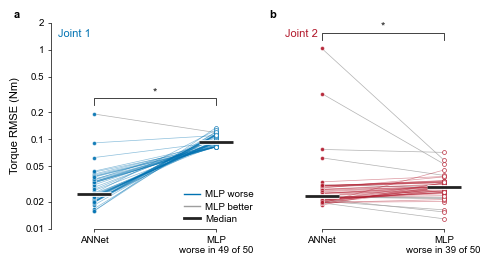

In [39]:
import matplotlib.patheffects as pe
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator

# -----------------------------------------------------------------------------
# Fig. 4 plotting code (the same drawing as in the standalone FIG4.ipynb).
# Paired comparison of ANNet and the direct torque-regression MLP. Both models were
# scored on the same 50 held-out trajectories, so each trajectory is one line from its
# ANNet error (filled marker) to its MLP error (open marker), drawn in the joint colour
# when the MLP is worse and in grey when it is better. Heavy black bars are medians.
# A single asterisk marks a Benjamini-Hochberg-adjusted q value of the primary test
# below 0.05 (ns otherwise). Torque RMSE is shown on a logarithmic axis, as in Fig. 3.
# The axis limits enclose every value.
# -----------------------------------------------------------------------------
FIG4_BLUE = '#0072B2'
FIG4_RED = '#B2182B'
FIG4_NEUTRAL = '#222222'
FIG4_GREY = '0.62'
FIG4_JOINTS = ['J1', 'J2']
FIG4_MODELS = ['ANNet', 'MLP']
FIG4_JOINT_LABELS = {'J1': 'Joint 1', 'J2': 'Joint 2'}
FIG4_JOINT_COLORS = {'J1': FIG4_BLUE, 'J2': FIG4_RED}
# Labelled axis values (1-2-5 x 10^k, in Nm); the axis ends on the tightest pair that encloses all data
FIG4_TICKS = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
FIG4_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def fig4_significance_label(q_value):
    # Benjamini-Hochberg-adjusted q value of the primary test: '*' if significant, 'ns' otherwise
    return '*' if q_value < 0.05 else 'ns'


def draw_fig4(rmse_table, stats_table):
    """
    rmse_table:  long-form table with columns model, joint, trajectory, rmse_nm.
    stats_table: one row per joint with at least the columns joint and fdr_q_value.
    Returns the matplotlib figure (two panels, one per joint, on a shared logarithmic axis).
    """
    values = {}
    for joint in FIG4_JOINTS:
        for model_name in FIG4_MODELS:
            mask = (rmse_table['model'] == model_name) & (rmse_table['joint'] == joint)
            values[(joint, model_name)] = (
                rmse_table.loc[mask].sort_values('trajectory')['rmse_nm'].to_numpy(dtype=float)
            )
    all_values = np.concatenate(list(values.values()))
    y_low = max(tick for tick in FIG4_TICKS if tick <= all_values.min())
    y_high = min(tick for tick in FIG4_TICKS if tick >= all_values.max())
    # Every plotted value must lie inside the axis
    assert ((all_values >= y_low) & (all_values <= y_high)).all()

    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.9), sharey=True)
    fig.subplots_adjust(left=0.115, right=0.985, top=0.90, bottom=0.19, wspace=0.10)
    x_annet, x_mlp = 0.0, 1.0
    for ax, joint in zip(axes, FIG4_JOINTS):
        color = FIG4_JOINT_COLORS[joint]
        annet, mlp = values[(joint, 'ANNet')], values[(joint, 'MLP')]
        worse = mlp > annet
        for i in np.argsort(worse):   # grey (MLP better) drawn first, coloured on top
            ax.plot([x_annet, x_mlp], [annet[i], mlp[i]], color=color if worse[i] else FIG4_GREY,
                    lw=0.5, alpha=0.45 if worse[i] else 0.8, zorder=2)
        ax.scatter(np.full(annet.size, x_annet), annet, s=8, color=color, edgecolors='white',
                   linewidths=0.3, alpha=0.9, zorder=3)
        ax.scatter(np.full(mlp.size, x_mlp), mlp, s=8, facecolors='white', edgecolors=color,
                   linewidths=0.5, alpha=0.9, zorder=3)
        for x_position, median in ((x_annet, np.median(annet)), (x_mlp, np.median(mlp))):
            ax.plot([x_position - 0.14, x_position + 0.14], [median, median], color=FIG4_NEUTRAL, lw=2.0,
                    solid_capstyle='butt', zorder=6,
                    path_effects=[pe.withStroke(linewidth=3.4, foreground='white')])
        top = max(annet.max(), mlp.max())
        ax.plot([x_annet, x_annet, x_mlp, x_mlp], [top * 1.25, top * 1.5, top * 1.5, top * 1.25],
                color=FIG4_NEUTRAL, lw=0.6, zorder=6)
        q_value = float(stats_table.loc[stats_table['joint'] == joint, 'fdr_q_value'].iloc[0])
        ax.text(0.5, top * 1.55, fig4_significance_label(q_value), ha='center', va='bottom',
                fontsize=8, color=FIG4_NEUTRAL)
        ax.text(0.03, 0.97, FIG4_JOINT_LABELS[joint], transform=ax.transAxes, ha='left', va='top',
                fontsize=8, color=color)
        ax.set_yscale('log')
        ax.set_ylim(y_low, y_high)
        ax.set_xlim(-0.35, 1.35)
        ax.set_xticks([x_annet, x_mlp])
        ax.set_xticklabels(['ANNet', f"MLP\nworse in {int(worse.sum())} of {annet.size}"])
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['bottom'].set_bounds(x_annet, x_mlp)
    axes[0].yaxis.set_major_locator(FixedLocator([tick for tick in FIG4_TICKS if y_low <= tick <= y_high]))
    axes[0].yaxis.set_minor_locator(NullLocator())
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}"))
    axes[0].set_ylabel('Torque RMSE (Nm)')
    axes[1].tick_params(axis='y', length=0)
    axes[1].spines['left'].set_visible(False)
    axes[0].legend(handles=[Line2D([0], [0], color=FIG4_BLUE, lw=1.0, label='MLP worse'),
                            Line2D([0], [0], color=FIG4_GREY, lw=1.0, label='MLP better'),
                            Line2D([0], [0], color=FIG4_NEUTRAL, lw=2.0, label='Median')],
                   loc='lower right', frameon=False, handlelength=1.6, handletextpad=0.5,
                   borderaxespad=0.1, labelspacing=0.35)
    for panel_letter, ax in zip('ab', axes):
        x0, y0, width, height = ax.get_position().bounds
        fig.text(x0 - 0.075 if ax is axes[0] else x0 - 0.02, y0 + height + 0.01, panel_letter,
                 fontsize=8, fontweight='bold', ha='left', va='bottom')
    return fig


def save_fig4(fig, directory, name):
    # PDF (vector, editable text) and 600-dpi PNG at the canvas size, as in FIG4.ipynb
    for ext in ('pdf', 'png'):
        figure_path = os.path.join(directory, f"{name}.{ext}")
        fig.savefig(figure_path, facecolor='white')
        print(f"Saved {figure_path}")


# Draw Fig. 4 and save the PDF and PNG to the submission folder
with mpl.rc_context():
    mpl.rc_file_defaults()        # same starting point as the standalone notebook, whatever this kernel has set
    mpl.rcParams.update(FIG4_RC)
    mlp_fig = draw_fig4(mlp_rmse_df, mlp_stats_df)
    save_fig4(mlp_fig, MLP_FIGURE_DIR, MLP_FIGURE_NAME)
    plt.show()

### Data package for Fig. 4

Following the packaging used for the other figures, the trajectory-wise RMSE values, the statistics table, provenance metadata (source-file hashes, model and training configuration, test-set description, statistical settings) and a README are written into `FIG4.zip` in `SUBMISSION/FIGURES/DATA AND SCRIPTS/`. The standalone notebook `FIG4.ipynb` in the same folder regenerates the figure from this archive alone.

In [40]:
import json
import zipfile
from datetime import datetime, timezone

# sha256_of_file is defined in the evaluation cell above
mlp_package_path = os.path.join(MLP_PACKAGE_DIR, f"{MLP_FIGURE_NAME}.zip")

# Provenance: hashes of every artifact the figure and statistics were derived from
mlp_source_paths = [
    ANNET_RESULTS_PATH, MLP_RESULTS_PATH, MLP_TEST_SET_PATH,
    ANNET_MODEL_PATH, ANNET_STATS_PATH, ANNET_HISTORY_PATH, ANNET_TIME_PATH,
    MLP_MODEL_PATH, MLP_STATS_PATH, MLP_HISTORY_PATH, MLP_TIME_PATH,
    MLP_STATS_CSV_PATH,
]
mlp_source_files = {
    os.path.basename(path): {'sha256': sha256_of_file(path), 'bytes': os.path.getsize(path)}
    for path in mlp_source_paths if os.path.exists(path)
}

# Run environment recorded by the training cell in the statistics file
_mlp_saved_stats = torch.load(MLP_STATS_PATH, map_location='cpu')
mlp_run_environment = {
    key: _mlp_saved_stats.get(key) for key in ('device', 'torch_version', 'platform', 'processor', 'model_compiled')
}

mlp_hidden_layers = [NUM_NODE_L1, NUM_NODE_L2, NUM_NODE_L3, NUM_NODE_L4]
mlp_metadata = {
    'created_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'description': ('Data package for manuscript Figure 4: inverse-dynamics torque accuracy of ANNet '
                    'versus a direct torque-regression MLP with the same architecture.'),
    'purpose': ('Tests whether a multilayer perceptron with the same hidden layers, trained to return the joint '
                'torques directly, matches the inverse-dynamics accuracy of ANNet on the same test trajectories.'),
    'data_derivation': (
        'Trajectory-wise torque RMSE values were read from results_model_16000.pt (ANNet) and '
        'results_model_mlp_16000.pt (direct torque regressor). Both models were scored on the identical '
        'fixed test set test_set_50_traj_5s.pt (50 RK4 reference trajectories, 5 s, 0.1 ms step) with the '
        'analytical inertial torques as ground truth. Statistics were computed from the archived RMSE values '
        'in MAIN_RUN_ME_NEW.ipynb (Section 5).'
    ),
    'source_files': mlp_source_files,
    'models': {
        'ANNet': {
            'input': 'standardized [q1, q2, dq1, dq2, ddq1, ddq2]',
            'hidden_layers': mlp_hidden_layers,
            'activation': 'GELU',
            'output': 'one linear unit: standardized Appell acceleration energy; torques obtained as the '
                      'scaled input-gradient with respect to the accelerations (automatic differentiation)',
            'trainable_parameters': int(_mlp_num_params_annet),
            'model_file': os.path.basename(ANNET_MODEL_PATH),
        },
        'MLP': {
            'input': 'standardized [q1, q2, dq1, dq2, ddq1, ddq2]',
            'hidden_layers': mlp_hidden_layers,
            'activation': 'GELU',
            'output': 'two linear units: standardized joint torques (tau1, tau2), de-standardized with '
                      'dataset-level per-joint mean and standard deviation',
            'trainable_parameters': int(_mlp_num_params_direct),
            'model_file': os.path.basename(MLP_MODEL_PATH),
        },
    },
    'training_configuration': {
        'training_samples': MLP_N_SAMPLES,
        'sampling_ranges': {'q_rad': [-float(np.pi / 2), float(np.pi / 2)], 'dq_rad_s': [-5.0, 5.0], 'ddq_rad_s2': [-20.0, 20.0]},
        'physical_parameters': {key: float(value) for key, value in PARAMS.items()},
        'train_fraction': 0.8,
        'epochs': int(EPOCHS),
        'learning_rate': float(LR),
        'batch_size': int(BATCH_SIZE),
        'optimizer': 'Adam',
        'seed': MLP_SEED,
        'validation_interval_epochs': 100,
        'checkpoint_selection': 'lowest validation loss',
        'loss': 'mean squared torque error in physical units (Nm^2) for both models',
        'best_validation_mse_nm2': {
            row['model']: float(row['best_validation_mse_nm2']) for _, row in mlp_training_summary.iterrows()
        },
        'training_time_s': {
            row['model']: float(row['training_time_s']) for _, row in mlp_training_summary.iterrows()
        },
        'training_time_note': ('Wall-clock seconds of each archived training run, recorded on the machine and '
                               'date of that run (ANNet: archived run, see the manuscript Hardware '
                               'specifications; MLP: run_environment below). Not a controlled timing '
                               'comparison; the validation-MSE comparison is hardware independent.'),
        'run_environment': {
            'MLP': mlp_run_environment,
            'ANNet': 'archived run; see manuscript Hardware specifications (Apple M4 system-on-a-chip, CPU only)',
        },
        'note': ('The direct regressor was trained on an independent draw from the same distribution as '
                 'the ANNet training set; the exact ANNet draw is not reproducible because the generator '
                 'state at that point depended on the preceding training runs. Hyperparameters were not '
                 're-tuned for the direct regressor.'),
    },
    'test_set': {
        'file': os.path.basename(MLP_TEST_SET_PATH),
        'num_trajectories': int(mlp_fixed_inputs.shape[0]),
        'samples_per_trajectory': int(mlp_fixed_inputs.shape[1]),
        'duration_s': 5.0,
        'reference_integrator': 'fixed-step RK4',
        'step_s': float(MLP_TEST_STEP_KEY),
        'initial_conditions': 'angles uniform in [-pi/3, pi/3], zero initial velocities',
    },
    'statistics': {
        'alpha': MLP_ALPHA,
        'normality_test': 'Shapiro-Wilk on each group',
        'primary_test_rule': 'one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test',
        'multiple_comparison_correction': 'Benjamini-Hochberg FDR across the two joints',
        'secondary_tests': ['two-sided Mann-Whitney U (unpaired; U statistic reported for MLP vs ANNet)',
                            'two-sided Wilcoxon signed-rank (paired by trajectory; MLP vs ANNet)'],
        'effect_sizes': ['median ratio MLP/ANNet', "Cliff's delta (MLP vs ANNet)"],
        'primary_test_used': {row['joint']: row['test_name'] for _, row in mlp_stats_df.iterrows()},
        'fdr_q_values': {row['joint']: float(row['fdr_q_value']) for _, row in mlp_stats_df.iterrows()},
    },
    'figure': {
        'content': ('two panels (joint 1 and joint 2) on a shared logarithmic y axis: paired comparison of the '
                    'trajectory-wise torque RMSE, one line per test trajectory from its ANNet error (filled marker) '
                    'to its MLP error (open marker), drawn in the joint colour where the MLP error is higher and in '
                    'grey where it is lower; heavy bars mark the medians'),
        'axis_scale': ('log10; chosen because the per-trajectory RMSE spans about two decades within one '
                       'group, which would hide the medians on a linear axis (cf. Fig. 3)'),
        'axis_limits': 'tightest labelled 1-2-5 x 10^k values that enclose all data, so that the axis ends on a labelled tick',
        'significance_marks': ('asterisk above each pair when the Benjamini-Hochberg-adjusted q value of the '
                               'primary test is below 0.05; ns otherwise'),
        'count_annotation': 'number of trajectories on which the MLP error is higher, printed beneath each panel',
    },
    'num_rmse_rows': int(len(mlp_rmse_df)),
}

mlp_readme_text = f"""{MLP_FIGURE_NAME} data package
=================

This archive contains the data required by {MLP_FIGURE_NAME}.ipynb to regenerate manuscript Figure 4.

Files:
- fig4_rmse_values.csv: trajectory-wise torque RMSE values for ANNet and for the direct torque-regression MLP with the same architecture (both trained on 16,000 samples), per joint, on the identical 50-trajectory fixed test set.
- fig4_statistics.csv: per-joint Shapiro-Wilk normality tests, primary group comparison (one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test) with Benjamini-Hochberg FDR correction, secondary two-sided Mann-Whitney U (U statistic for MLP versus ANNet) and paired Wilcoxon signed-rank tests, descriptive statistics and effect sizes (median ratio and Cliff's delta, MLP versus ANNet).
- fig4_metadata.json: source hashes, model and training configuration, run environment, test-set description, statistical settings, figure conventions, and provenance metadata.

The figure shows torque RMSE on a shared logarithmic axis, one panel per joint. Each line joins the ANNet error (filled marker) and the MLP error (open marker) of one test trajectory and is drawn in the joint colour where the MLP error is higher and in grey where it is lower; heavy bars mark the medians. An asterisk above a pair marks a Benjamini-Hochberg-adjusted q value of the primary test below 0.05 (ns otherwise).
"""


def write_fig4_package(package_path):
    with zipfile.ZipFile(package_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
        archive.writestr('fig4_rmse_values.csv', mlp_rmse_df.to_csv(index=False))
        archive.writestr('fig4_statistics.csv', mlp_stats_df.to_csv(index=False))
        archive.writestr('fig4_metadata.json', json.dumps(mlp_metadata, indent=2, allow_nan=False))
        archive.writestr(f'{MLP_FIGURE_NAME}_README.txt', mlp_readme_text)
    print(f"Saved data package to {package_path}")
    with zipfile.ZipFile(package_path) as archive:
        for info in archive.infolist():
            print(f"  {info.filename:<28} {info.file_size:>9,} bytes")


write_fig4_package(mlp_package_path)

Saved data package to ../SUBMISSION/FIGURES/DATA AND SCRIPTS/FIG4.zip
  fig4_rmse_values.csv             6,253 bytes
  fig4_statistics.csv              1,200 bytes
  fig4_metadata.json               7,400 bytes
  FIG4_README.txt                  1,367 bytes


# Section 6: Neural Forward Dynamics

In Section 4, we solved the inverse dynamics problem with networks trained on datasets of different sizes and selected one network as the best suited for the task. In this section, we show that the same network solves the forward dynamics problem without retraining.

### Constants

In [41]:
# Dataset size the network was trained on
N_SAMPLES = 16000

# Base directory for loading/saving files
BASE_PATH = "."

# Fix random seed for reproducibility
SEED = 23
torch.manual_seed(SEED)

# Number of trajectories to simulate
NUM_TRAJS = 50

# Simulation time step
DT_SIM = 0.002

# Total simulation duration
DURATION = 5.0

# Total number of integration steps
STEPS = int(DURATION / DT_SIM)

# Discrete time vector for simulation
T_SPAN = torch.linspace(0, DURATION, STEPS)

# Best real-time-accuracy solver configuration from the full grid search
BEST_REALTIME_SAMPLED_ACCELERATION_VECTORS = 16
BEST_REALTIME_BOUND = 15.0
BEST_REALTIME_ADAM_STEPS = 10
SIM_CONFIG_TAG = (
    f"N{BEST_REALTIME_SAMPLED_ACCELERATION_VECTORS}_"
    f"B{BEST_REALTIME_BOUND:g}_"
    f"A{BEST_REALTIME_ADAM_STEPS}"
)

# Filename for saving the full simulation dataset
save_filename = f'simulation_results_50trials_{SIM_CONFIG_TAG}.pt'

# File where timing statistics will be stored
timing_filename = f'timing_stats_{SIM_CONFIG_TAG}.pt'


### Derivations

First, to avoid propagation of numeric variables from the previous sections, we redefine the symbolic variables and functions that describe the system and its motion over time.

In [42]:
# Define time
t = sp.symbols('t')

# Define system parameters
m1, m2 = sp.symbols('m1 m2')
l1, l2 = sp.symbols('l1 l2')
g      = sp.symbols('g')

# Define generalized coordinates as functions of time
theta1 = sp.Function('theta1')(t)
theta2 = sp.Function('theta2')(t)

# Define substitution symbols for positions, velocities, and accelerations
q1, q2     = sp.symbols('q1 q2')
dq1, dq2   = sp.symbols('dq1 dq2')
ddq1, ddq2 = sp.symbols('ddq1 ddq2')

print("Symbols and coordinates defined.")


# Compute position of mass 1
x1 = l1 * sp.sin(theta1)
y1 = -l1 * sp.cos(theta1)

# Compute position of mass 2 relative to link 1
x2 = x1 + l2 * sp.sin(theta1 + theta2)
y2 = y1 - l2 * sp.cos(theta1 + theta2)

print("Position vectors defined.")


# Compute velocities as first derivatives of positions
vx1 = sp.diff(x1, t)
vy1 = sp.diff(y1, t)
vx2 = sp.diff(x2, t)
vy2 = sp.diff(y2, t)

# Compute accelerations as second derivatives of positions
ax1 = sp.diff(vx1, t)
ay1 = sp.diff(vy1, t)
ax2 = sp.diff(vx2, t)
ay2 = sp.diff(vy2, t)

print("Velocity and acceleration vectors defined.")


# Compute squared magnitudes of accelerations
accel_mag_sq_1 = ax1**2 + ay1**2
accel_mag_sq_2 = ax2**2 + ay2**2

# Compute Gibbs-Appell function S = 0.5 * sum(m_i * a_i^2)
S_symbolic = 0.5 * m1 * accel_mag_sq_1 + 0.5 * m2 * accel_mag_sq_2

print("Gibbs-Appell function derived.")


Symbols and coordinates defined.
Position vectors defined.
Velocity and acceleration vectors defined.
Gibbs-Appell function derived.


Second, we again replace time-dependent derivatives and generalized coordinates with static symbols to make the final expressions easier to read and work with.

In [43]:
# Create a mapping from dynamic functions to static symbols
# Derivatives must be substituted before the base functions
subs_map = {
    theta1.diff(t, t): ddq1,  # acceleration of joint1
    theta2.diff(t, t): ddq2,  # acceleration of joint2
    theta1.diff(t):    dq1,   # velocity of joint1
    theta2.diff(t):    dq2,   # velocity of joint2
    theta1:             q1,   # angle of joint1
    theta2:             q2    # angle of joint2
}

# Apply the substitutions and simplify the expression
S_clean = S_symbolic.subs(subs_map).simplify()

# Display the simplified Gibbs-Appell function
print("Gibbs-Appell Function:")
sp.pprint(S_clean)


Gibbs-Appell Function:
                                   ⎛                                           ↪
      2    ⎛    2      4⎞          ⎜⎛                     2                    ↪
0.5⋅l₁ ⋅m₁⋅⎝ddq₁  + dq₁ ⎠ + 0.5⋅m₂⋅⎝⎝ddq₁⋅l₁⋅sin(q₁) + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(d ↪

↪                                                         2                    ↪
↪                                          2             ⎞    ⎛                ↪
↪ dq₁ + ddq₂)⋅sin(q₁ + q₂) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + q₂)⎠  + ⎝ddq₁⋅l₁⋅cos(q₁) ↪

↪                                                                              ↪
↪       2                                                            2         ↪
↪  - dq₁ ⋅l₁⋅sin(q₁) + l₂⋅(ddq₁ + ddq₂)⋅cos(q₁ + q₂) - l₂⋅(dq₁ + dq₂) ⋅sin(q₁  ↪

↪       2⎞
↪      ⎞ ⎟
↪ + q₂)⎠ ⎠


Third, we symbolically derive the exact equations of motion and convert them into differentiable numerical functions.

In [44]:
# Reuse the pure PyTorch kernels defined earlier in the notebook.
# This section intentionally avoids redefining calc_M_robust/calc_C_robust/calc_G_robust
# with sympy.lambdify so the compiled Torch versions remain active.
print('Reusing previously defined pure PyTorch mass, bias, and gravity kernels.')


Reusing previously defined pure PyTorch mass, bias, and gravity kernels.


Fourth, we define the system's ODE for solving the resulting equations of motion for joint accelerations.

In [45]:
@torch.compile(dynamic=False, fullgraph=True, mode=TORCH_COMPILE_MODE)
def derive_ode_robust(y, t, m1, m2, l1, l2, g_val):
    del t
    theta1_val, theta2_val, dtheta1_val, dtheta2_val = y.unbind()
    ddq1_val, ddq2_val = _compute_accelerations_torch(
        theta1_val, theta2_val, dtheta1_val, dtheta2_val, m1, m2, l1, l2, g_val
    )
    return torch.stack((dtheta1_val, dtheta2_val, ddq1_val, ddq2_val))

print('Torch numerical function created.')


Torch numerical function created.



Next, we load statistics of the dataset used to train the model.

In [46]:
# Construct the path to the saved normalization statistics file
stats_path = os.path.join(BASE_PATH, f"stats_{N_SAMPLES}.pt")

# Load statistics and map all tensors to CPU
stats_data = torch.load(stats_path, map_location='cpu')

def ensure_tensor(val):
    """
    Ensure the input is a torch.Tensor.
    """
    if torch.is_tensor(val):
        return val
    # Convert standard Python types to torch.Tensor
    return torch.tensor(val)

# Extract scalar normalization statistics
# Keeping these as 0-d tensors (scalars) allows for easy broadcasting later
S_mean = ensure_tensor(stats_data['S_mean'])
S_std  = ensure_tensor(stats_data['S_std'])

# Extract vector-valued normalization statistics
X_mean           = ensure_tensor(stats_data['X_mean'])
X_std            = ensure_tensor(stats_data['X_std'])
chain_rule_scale = ensure_tensor(stats_data['chain_scale'])

# Print loaded statistics for verification
print(f"Stats loaded from: {stats_path}")
print("-" * 30)

# Print scalar values using .item() for readability
print(f"S_mean:           {S_mean.item():.6f} (Type: {type(S_mean)})")
print(f"S_std:            {S_std.item():.6f} (Type: {type(S_std)})")

# Print vector/tensor statistics
print(f"Chain rule scale: {chain_rule_scale} (Shape: {chain_rule_scale.shape})")
print(f"X_mean shape:     {X_mean.shape}")
print(f"X_std shape:      {X_std.shape}")


Stats loaded from: ./stats_16000.pt
------------------------------
S_mean:           936.922363 (Type: <class 'torch.Tensor'>)
S_std:            1050.204468 (Type: <class 'torch.Tensor'>)
Chain rule scale: tensor([90.6129, 90.9667]) (Shape: torch.Size([2]))
X_mean shape:     torch.Size([6])
X_std shape:      torch.Size([6])


### Optimization

Following this, we code up a function that solves for the joint accelerations $\ddot{\mathbf{q}} \in \mathbb{R}^2$ by minimizing a discretized formulation of Gauss's principle of least constraint. The objective function $J(\ddot{\mathbf{q}})$ combines the learned Gibbs-Appell function $S_{\text{net}}$, the virtual work done by gravity $\mathbf{G}(\mathbf{q})$, and a Tikhonov-style regularization term:

$$
\ddot{\mathbf{q}}^* = \operatorname*{argmin}_{\ddot{\mathbf{q}}} \left( S_{\text{net}}(\mathbf{q}, \dot{\mathbf{q}}, \ddot{\mathbf{q}}) + \mathbf{G}(\mathbf{q})^\top \ddot{\mathbf{q}} + \lambda \|\ddot{\mathbf{q}} - \ddot{\mathbf{q}}_{\text{prev}}\|^2 \right)
$$

We perform the optimization in two stages using the best real-time-accuracy configuration from the full grid search: (1) a coarse global search using $N=16$ sampled acceleration vectors bounded by $\pm 15$ rad/s$^2$ to identify a robust initial guess, followed by (2) 10 Adam refinement steps to converge on the local minimizer while staying within the real-time budget.

In [47]:
def neural_optimizer(
    q_in, dq_in, model, x_mean, x_std, s_mean, s_std, chain_scale, prev_ddq_guess=None
):
    del chain_scale

    q_t = torch.as_tensor(q_in, dtype=TORCH_DTYPE)
    dq_t = torch.as_tensor(dq_in, dtype=TORCH_DTYPE)
    x_mean_t = torch.as_tensor(x_mean, dtype=TORCH_DTYPE, device=q_t.device)
    x_std_t = torch.as_tensor(x_std, dtype=TORCH_DTYPE, device=q_t.device)
    s_mean_t = torch.as_tensor(s_mean, dtype=TORCH_DTYPE, device=q_t.device)
    s_std_t = torch.as_tensor(s_std, dtype=TORCH_DTYPE, device=q_t.device)

    if prev_ddq_guess is None:
        prev_ddq_t = torch.zeros(2, dtype=TORCH_DTYPE, device=q_t.device)
    else:
        prev_ddq_t = torch.as_tensor(prev_ddq_guess, dtype=TORCH_DTYPE, device=q_t.device)

    g_vec_t = calc_G_robust(
        q_t[0], q_t[1],
        as_f32_tensor(PARAMS['m1'], device=q_t.device),
        as_f32_tensor(PARAMS['m2'], device=q_t.device),
        as_f32_tensor(PARAMS['l1'], device=q_t.device),
        as_f32_tensor(PARAMS['l2'], device=q_t.device),
        as_f32_tensor(9.81, device=q_t.device),
    )

    n_samples = BEST_REALTIME_SAMPLED_ACCELERATION_VECTORS
    bounds_val = BEST_REALTIME_BOUND
    lambda_reg = 0.1
    inv_x_std_t = 1.0 / (x_std_t + TORCH_EPS)

    candidates = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=q_t.device).uniform_(-bounds_val, bounds_val)
    candidates[0].zero_()
    candidates[1].copy_(prev_ddq_t)

    q_batch = q_t.unsqueeze(0).expand(n_samples, -1)
    dq_batch = dq_t.unsqueeze(0).expand(n_samples, -1)
    x_batch = torch.cat((q_batch, dq_batch, candidates), dim=1)
    x_batch_norm = (x_batch - x_mean_t) * inv_x_std_t

    with torch.no_grad():
        s_pred_norm = model(x_batch_norm).squeeze(-1)

    s_real = s_pred_norm * s_std_t + s_mean_t
    work_term = torch.sum(candidates * g_vec_t.unsqueeze(0), dim=1)
    reg_term = lambda_reg * torch.sum((candidates - prev_ddq_t.unsqueeze(0)).square(), dim=1)
    best_guess = candidates[torch.argmin(s_real + work_term + reg_term)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([ddq_opt], lr=0.1)

    for _ in range(BEST_REALTIME_ADAM_STEPS):
        optimizer.zero_grad(set_to_none=True)
        x_in = torch.cat((q_t, dq_t, ddq_opt))
        x_norm = (x_in - x_mean_t) * inv_x_std_t
        s_val_real = model(x_norm.unsqueeze(0)).squeeze() * s_std_t + s_mean_t
        phys_loss = s_val_real + torch.dot(g_vec_t, ddq_opt)
        smooth_loss = lambda_reg * torch.sum((ddq_opt - prev_ddq_t).square())
        loss = phys_loss + smooth_loss
        loss.backward()
        optimizer.step()

    return ddq_opt.detach()


Next, we initialize the model on the selected device, set it to evaluation mode for inference, and load the pretrained weights if available.

In [48]:
# Define model path and select device
model_path = os.path.join(BASE_PATH, f"model_{N_SAMPLES}.pth")
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model structure
print("Initializing model structure...")
model = GibbsAppellNet().to(device)

# Load pretrained weights if the file exists
if os.path.exists(model_path):
    print(f"Loading weights from: {model_path}")

    # Load state dictionary and map to the appropriate device
    state_dict = torch.load(model_path, map_location=device)

    # Apply the weights to the model
    model.load_state_dict(state_dict)

    # Set the model to evaluation mode for inference
    model.eval()  # Ensures layers like Dropout/BatchNorm behave correctly
    print("Model loaded successfully.")

else:
    print(f"ERROR: Model file not found at {model_path}")


Initializing model structure...
Loading weights from: ./model_16000.pth
Model loaded successfully.


### Closed-loop simulation

First, to avoid using integrator functions that depend on NumPy, we implemented custom ones here.

In [49]:
@torch.compile(dynamic=False, fullgraph=True, mode=TORCH_COMPILE_MODE)
def integrate_semi_implicit(q, dq, ddq, dt):
    dq_next = dq + dt * ddq
    q_next = q + dt * dq_next
    return q_next, dq_next


In [50]:
def odeint(func, y0, t, args=()):
    """
    Solves a system of ODEs using the Runge-Kutta 4 (RK4) method.
    Designed to be a drop-in replacement for scipy.integrate.odeint
    but for PyTorch Tensors.

    Args:
        func: Function func(y, t, *args) that returns dy/dt (Tensor).
        y0: Initial state (Tensor).
        t: Time steps (Tensor).
        args: Tuple of additional arguments to pass to func.

    Returns:
        Tensor of shape (len(t), len(y0)) containing the state trajectory.
    """
    # Ensure inputs are tensors on the correct device
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0)

    # We infer device/dtype from the initial state
    device = y0.device
    dtype = y0.dtype

    if not torch.is_tensor(t):
        t = torch.tensor(t, device=device, dtype=dtype)
    else:
        t = t.to(device=device, dtype=dtype)

    n_steps = len(t)
    solution = torch.empty((n_steps, *y0.shape), device=device, dtype=dtype)
    solution[0] = y0

    curr_y = y0

    # Main Integration Loop
    for i in range(n_steps - 1):
        t_curr = t[i]
        dt = t[i+1] - t_curr

        # k1 = f(y, t)
        k1 = func(curr_y, t_curr, *args)

        # k2 = f(y + 0.5*dt*k1, t + 0.5*dt)
        k2 = func(curr_y + 0.5 * dt * k1, t_curr + 0.5 * dt, *args)

        # k3 = f(y + 0.5*dt*k2, t + 0.5*dt)
        k3 = func(curr_y + 0.5 * dt * k2, t_curr + 0.5 * dt, *args)

        # k4 = f(y + dt*k3, t + dt)
        k4 = func(curr_y + dt * k3, t_curr + dt, *args)

        # Update state
        curr_y = curr_y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        solution[i+1] = curr_y

    return solution


Second, we implement a closed-loop forward dynamics simulation that uses the neural optimizer to predict the acceleration.


In [51]:
perf_counter = time.perf_counter
use_cuda = (device.type == 'cuda')

model.eval()
for param in model.parameters():
    param.requires_grad_(False)

x_mean_t = torch.as_tensor(X_mean, dtype=TORCH_DTYPE, device=device)
x_std_t = torch.as_tensor(X_std, dtype=TORCH_DTYPE, device=device)
s_mean_t = torch.as_tensor(S_mean, dtype=TORCH_DTYPE, device=device)
s_std_t = torch.as_tensor(S_std, dtype=TORCH_DTYPE, device=device)
inv_x_std = 1.0 / (x_std_t + TORCH_EPS)

COARSE_SAMPLES = BEST_REALTIME_SAMPLED_ACCELERATION_VECTORS
BOUNDS_VAL = BEST_REALTIME_BOUND
LAMBDA_REG = 0.1
FINE_STEPS = BEST_REALTIME_ADAM_STEPS
WARMUP_STEPS = 5

candidate_buffer = torch.empty(COARSE_SAMPLES, 2, dtype=TORCH_DTYPE, device=device)
zero_ddq = torch.zeros(2, dtype=TORCH_DTYPE, device=device)
zero_scalar = torch.tensor(0.0, dtype=TORCH_DTYPE, device=device)

m1_t = as_f32_tensor(PARAMS['m1'], device=device)
m2_t = as_f32_tensor(PARAMS['m2'], device=device)
l1_t = as_f32_tensor(PARAMS['l1'], device=device)
l2_t = as_f32_tensor(PARAMS['l2'], device=device)
g_t = as_f32_tensor(9.81, device=device)

def score_candidate_batch(q_t, dq_t, candidates, prev_ddq_t, g_vec_t):
    q_batch = q_t.unsqueeze(0).expand(candidates.shape[0], -1)
    dq_batch = dq_t.unsqueeze(0).expand(candidates.shape[0], -1)
    x_batch = torch.cat((q_batch, dq_batch, candidates), dim=1)
    x_batch_norm = (x_batch - x_mean_t) * inv_x_std
    s_pred_norm = model(x_batch_norm).squeeze(-1)
    s_real = s_pred_norm * s_std_t + s_mean_t
    work_term = torch.sum(candidates * g_vec_t.unsqueeze(0), dim=1)
    reg_term = LAMBDA_REG * torch.sum((candidates - prev_ddq_t.unsqueeze(0)).square(), dim=1)
    return s_real + work_term + reg_term

def gauss_objective(q_t, dq_t, ddq_t, prev_ddq_t, g_vec_t):
    x_in = torch.cat((q_t, dq_t, ddq_t))
    x_norm = (x_in - x_mean_t) * inv_x_std
    s_val_real = model(x_norm.unsqueeze(0)).squeeze() * s_std_t + s_mean_t
    work_term = torch.dot(g_vec_t, ddq_t)
    reg_term = LAMBDA_REG * torch.sum((ddq_t - prev_ddq_t).square())
    return s_val_real + work_term + reg_term

derive_ode = derive_ode_robust
integrate_step = integrate_semi_implicit

def neural_optimizer_fast(q_t, dq_t, prev_ddq_t):
    g_vec_t = calc_G_robust(q_t[0], q_t[1], m1_t, m2_t, l1_t, l2_t, g_t)

    with torch.no_grad():
        candidate_buffer.uniform_(-BOUNDS_VAL, BOUNDS_VAL)
        candidate_buffer[0].zero_()
        candidate_buffer[1].copy_(prev_ddq_t)
        costs = score_candidate_batch(q_t, dq_t, candidate_buffer, prev_ddq_t, g_vec_t)
        best_guess = candidate_buffer[torch.argmin(costs)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([ddq_opt], lr=0.1)

    for _ in range(FINE_STEPS):
        optimizer.zero_grad(set_to_none=True)
        loss = gauss_objective(q_t, dq_t, ddq_opt, prev_ddq_t, g_vec_t)
        loss.backward()
        optimizer.step()

    return ddq_opt.detach()

if os.path.exists(save_filename):
    print(f"Found existing simulation file: {save_filename}")
    print('Skipping simulations and loading data...')

    data = torch.load(save_filename, map_location='cpu')
    rmse_pos_list = data['rmse_pos']
    rmse_vel_list = data['rmse_vel']
    rmse_acc_list = data['rmse_acc']

    save_needed = False
else:
    print(f"File {save_filename} not found. Starting fresh simulations...")
    save_needed = True

    all_init_states = torch.rand(NUM_TRAJS, 4, dtype=TORCH_DTYPE, device=device) - 0.5

    rmse_pos_tensor = torch.empty(NUM_TRAJS, 2, dtype=TORCH_DTYPE)
    rmse_vel_tensor = torch.empty(NUM_TRAJS, 2, dtype=TORCH_DTYPE)
    rmse_acc_tensor = torch.empty(NUM_TRAJS, 2, dtype=TORCH_DTYPE)
    all_true_q_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_true_dq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_true_ddq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_pred_q_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_pred_dq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_pred_ddq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    t_gen_true_tensor = torch.empty(NUM_TRAJS, dtype=torch.float64)
    t_gen_sim_tensor = torch.empty(NUM_TRAJS, dtype=torch.float64)
    t_neural_call_tensor = torch.empty(NUM_TRAJS * STEPS, dtype=torch.float64)
    call_time_idx = 0

    args_torch = (m1_t, m2_t, l1_t, l2_t, g_t)

    print(f"Starting Evaluation on {NUM_TRAJS} Trajectories... (Timing GPU: {use_cuda})")
    global_start = perf_counter()

    for k in range(NUM_TRAJS):
        print(f"Processing trajectory #{k + 1} ...")

        init_state = all_init_states[k]
        q_init = init_state[:2].clone()
        dq_init = init_state[2:].clone()

        tic_true = perf_counter()
        sol_true = odeint(derive_ode, init_state, T_SPAN, args=args_torch)
        q_true = sol_true[:, :2]
        dq_true = sol_true[:, 2:]

        ddq_true = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)
        for t_idx in range(STEPS):
            ddq_true[t_idx].copy_(derive_ode(sol_true[t_idx], zero_scalar, *args_torch)[2:])

        t_gen_true_tensor[k] = perf_counter() - tic_true

        q_sim = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)
        dq_sim = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)
        ddq_sim = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)

        q_curr = q_init
        dq_curr = dq_init
        prev_acc = zero_ddq.clone()
        q_sim[0].copy_(q_curr)
        dq_sim[0].copy_(dq_curr)

        if use_cuda:
            torch.cuda.synchronize()
        tic_sim = perf_counter()

        for i in range(STEPS):
            if use_cuda:
                torch.cuda.synchronize()
            tic_opt = perf_counter()

            if i == 0:
                for _ in range(WARMUP_STEPS):
                    prev_acc = neural_optimizer_fast(q_curr, dq_curr, prev_acc)

            ddq_curr = neural_optimizer_fast(q_curr, dq_curr, prev_acc)

            if use_cuda:
                torch.cuda.synchronize()
            t_neural_call_tensor[call_time_idx] = perf_counter() - tic_opt
            call_time_idx += 1

            ddq_sim[i].copy_(ddq_curr)
            prev_acc = ddq_curr

            q_curr, dq_curr = integrate_step(q_curr, dq_curr, ddq_curr, DT_SIM)

            if i + 1 < STEPS:
                q_sim[i + 1].copy_(q_curr)
                dq_sim[i + 1].copy_(dq_curr)

        if use_cuda:
            torch.cuda.synchronize()
        t_gen_sim_tensor[k] = perf_counter() - tic_sim

        rmse_pos_tensor[k].copy_(torch.sqrt(torch.mean((q_true - q_sim).square(), dim=0)))
        rmse_vel_tensor[k].copy_(torch.sqrt(torch.mean((dq_true - dq_sim).square(), dim=0)))
        rmse_acc_tensor[k].copy_(torch.sqrt(torch.mean((ddq_true - ddq_sim).square(), dim=0)))

        all_true_q_tensor[k].copy_(q_true)
        all_true_dq_tensor[k].copy_(dq_true)
        all_true_ddq_tensor[k].copy_(ddq_true)
        all_pred_q_tensor[k].copy_(q_sim)
        all_pred_dq_tensor[k].copy_(dq_sim)
        all_pred_ddq_tensor[k].copy_(ddq_sim)

    print(f"Evaluation Complete. Total time: {perf_counter() - global_start:.2f}s")

if save_needed:
    print('Saving full dataset to disk...')
    save_dict = {
        'rmse_pos': rmse_pos_tensor.cpu(),
        'rmse_vel': rmse_vel_tensor.cpu(),
        'rmse_acc': rmse_acc_tensor.cpu(),
        'trial_time': T_SPAN.cpu(),
        'all_true_q': all_true_q_tensor.cpu(),
        'all_true_dq': all_true_dq_tensor.cpu(),
        'all_true_ddq': all_true_ddq_tensor.cpu(),
        'all_pred_q': all_pred_q_tensor.cpu(),
        'all_pred_dq': all_pred_dq_tensor.cpu(),
        'all_pred_ddq': all_pred_ddq_tensor.cpu(),
    }
    torch.save(save_dict, save_filename)
    print(f"Saved successfully to: {save_filename}")

    print('Saving timing statistics to disk...')
    timing_dict = {
        't_gen_true_per_traj': t_gen_true_tensor.cpu(),
        't_gen_sim_per_traj': t_gen_sim_tensor.cpu(),
        't_neural_calls_all': t_neural_call_tensor.cpu(),
    }
    torch.save(timing_dict, timing_filename)
    print(f"Timing stats saved successfully to: {timing_filename}")
else:
    print('Skipped saving (using existing file).')


Found existing simulation file: simulation_results_50trials_N16_B15_A10.pt
Skipping simulations and loading data...
Skipped saving (using existing file).


Third, we demonstrate that our predictions accurately approximate the numerical solution of the forward dynamics problem.

Loading results from simulation_results_50trials_N16_B15_A10.pt...
Saved to FIG_full_kinematics.svg and FIG_full_kinematics.pdf with size (7.20, 3.95) inches.


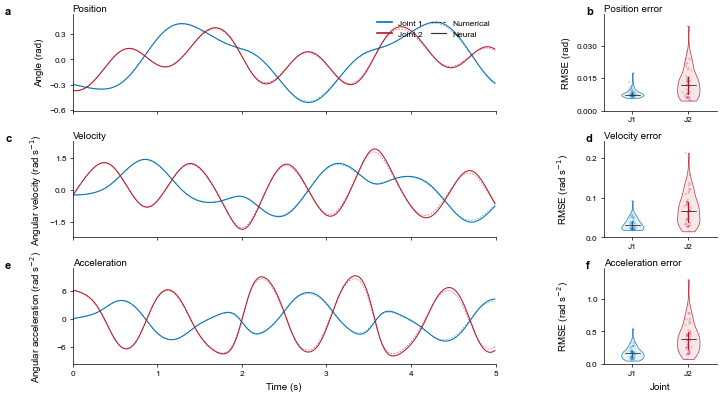

In [52]:
import os
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


filename = save_filename if 'save_filename' in globals() else 'simulation_results_50trials_N16_B15_A10.pt'

# Apply Nature-style figure settings globally.
single_col, double_col, golden_ratio = set_nature_style()

print(f"Loading results from {filename}...")
data = torch.load(filename, map_location='cpu')


def to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


t = to_numpy(data['trial_time'])
rmse_pos = to_numpy(data['rmse_pos'])
rmse_vel = to_numpy(data['rmse_vel'])
rmse_acc = to_numpy(data['rmse_acc'])
pred_q = to_numpy(data['all_pred_q'])
true_q = to_numpy(data['all_true_q'])
pred_dq = to_numpy(data['all_pred_dq'])
true_dq = to_numpy(data['all_true_dq'])
pred_ddq = to_numpy(data['all_pred_ddq'])
true_ddq = to_numpy(data['all_true_ddq'])

BLUE = '#0072B2'
RED = '#B2182B'
NEUTRAL = '#333333'
LIGHT_NEUTRAL = '#777777'
JOINT_COLORS = [BLUE, RED]
JOINT_LABELS = ['Joint 1', 'Joint 2']
rng = np.random.default_rng(23)

normalized_rmse = np.concatenate([
    rmse_pos / np.median(rmse_pos, axis=0),
    rmse_vel / np.median(rmse_vel, axis=0),
    rmse_acc / np.median(rmse_acc, axis=0),
], axis=1)
trajectory_score = normalized_rmse.mean(axis=1)
demo_idx = int(np.argmin(np.abs(trajectory_score - np.median(trajectory_score))))
trace_slice = slice(None, None, 4)


def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
    ax.tick_params(axis='both', which='minor', direction='out', length=1.5, width=0.4)
    ax.grid(False)


def add_panel_label(ax, label):
    ax.text(-0.16, 1.08, label, transform=ax.transAxes, ha='left', va='top',
            fontsize=8, fontweight='bold', color='black', clip_on=False)


def padded_ylim(ax, *arrays, pad_fraction=0.10):
    values = np.concatenate([np.ravel(array) for array in arrays])
    values = values[np.isfinite(values)]
    lower, upper = values.min(), values.max()
    pad = (upper - lower) * pad_fraction if upper > lower else max(abs(upper), 1.0) * pad_fraction
    ax.set_ylim(lower - pad, upper + pad)


def plot_editable_points(ax, x_values, y_values, color, markersize=1.6, alpha=0.25, zorder=2):
    for x_value, y_value in zip(np.asarray(x_values), np.asarray(y_values)):
        ax.plot(
            [float(x_value)], [float(y_value)],
            marker='o', markersize=markersize,
            markerfacecolor=color, markeredgecolor='none', markeredgewidth=0,
            linestyle='None', alpha=alpha, zorder=zorder,
            rasterized=False,
        )


def plot_trajectory_panel(ax, true_values, pred_values, title, ylabel, panel_label):
    tt = t[trace_slice]
    for joint_idx, color in enumerate(JOINT_COLORS):
        ax.plot(tt, true_values[trace_slice, joint_idx], color=color, linewidth=0.58,
                linestyle=(0, (2.2, 1.6)), alpha=0.58, solid_capstyle='round')
        ax.plot(tt, pred_values[trace_slice, joint_idx], color=color, linewidth=0.78,
                linestyle='-', alpha=0.96, solid_capstyle='round')
    ax.set_title(title, loc='left', fontsize=7, fontweight='normal', pad=2, color='black')
    ax.set_ylabel(ylabel)
    ax.set_xlim(float(t.min()), float(t.max()))
    padded_ylim(ax, true_values, pred_values)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    style_axis(ax)
    add_panel_label(ax, panel_label)


def plot_rmse_panel(ax, rmse_values, title, ylabel, panel_label):
    positions = np.asarray([1.0, 1.55])
    data_by_joint = [rmse_values[:, 0], rmse_values[:, 1]]
    violins = ax.violinplot(
        data_by_joint,
        positions=positions,
        widths=0.22,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body, color in zip(violins['bodies'], JOINT_COLORS):
        body.set_facecolor(mpl.colors.to_rgba(color, 0.10))
        body.set_edgecolor(mpl.colors.to_rgba(color, 0.82))
        body.set_linewidth(0.55)
        body.set_alpha(None)
        body.set_zorder(1)
        body.set_rasterized(False)

    for joint_idx, (values, color) in enumerate(zip(data_by_joint, JOINT_COLORS)):
        x = positions[joint_idx] + rng.normal(0, 0.014, size=values.size)
        q1, median, q3 = np.percentile(values, [25, 50, 75])
        plot_editable_points(ax, x, values, color, markersize=1.45, alpha=0.22, zorder=2)
        ax.plot([positions[joint_idx], positions[joint_idx]], [q1, q3],
                color=color, linewidth=0.88, solid_capstyle='round', zorder=3)
        ax.plot([positions[joint_idx] - 0.075, positions[joint_idx] + 0.075], [median, median],
                color=NEUTRAL, linewidth=0.62, solid_capstyle='round', zorder=4)

    ax.set_title(title, loc='left', fontsize=7, fontweight='normal', pad=2, color='black')
    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(['J1', 'J2'])
    ax.set_xlim(0.72, 1.83)
    ax.set_ylim(0, float(np.nanmax(rmse_values)) * 1.14)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    style_axis(ax)
    add_panel_label(ax, panel_label)


with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}):
    fig_width = double_col
    fig_height = 3.95
    fig, axs = plt.subplots(
        3, 2,
        figsize=(fig_width, fig_height),
        constrained_layout=True,
        gridspec_kw={'width_ratios': [2.70, 0.72], 'height_ratios': [1, 1, 1], 'wspace': 0.16},
    )
    fig.patch.set_facecolor('white')

    plot_trajectory_panel(axs[0, 0], true_q[demo_idx], pred_q[demo_idx], 'Position', 'Angle (rad)', 'a')
    plot_rmse_panel(axs[0, 1], rmse_pos, 'Position error', 'RMSE (rad)', 'b')
    plot_trajectory_panel(axs[1, 0], true_dq[demo_idx], pred_dq[demo_idx], 'Velocity', 'Angular velocity (rad s$^{-1}$)', 'c')
    plot_rmse_panel(axs[1, 1], rmse_vel, 'Velocity error', 'RMSE (rad s$^{-1}$)', 'd')
    plot_trajectory_panel(axs[2, 0], true_ddq[demo_idx], pred_ddq[demo_idx], 'Acceleration', 'Angular acceleration (rad s$^{-2}$)', 'e')
    plot_rmse_panel(axs[2, 1], rmse_acc, 'Acceleration error', 'RMSE (rad s$^{-2}$)', 'f')

    for ax in axs[:2, 0]:
        ax.tick_params(labelbottom=False)
    axs[2, 0].set_xlabel('Time (s)')
    axs[2, 1].set_xlabel('Joint')

    legend_handles = [
        Line2D([0], [0], color=BLUE, linewidth=1.2, label='Joint 1'),
        Line2D([0], [0], color=RED, linewidth=1.2, label='Joint 2'),
        Line2D([0], [0], color=NEUTRAL, linewidth=0.75, linestyle=(0, (2.2, 1.6)), label='Numerical'),
        Line2D([0], [0], color=NEUTRAL, linewidth=0.85, linestyle='-', label='Neural'),
    ]
    axs[0, 0].legend(
        handles=legend_handles,
        loc='upper right',
        frameon=False,
        ncol=2,
        handlelength=1.8,
        columnspacing=1.0,
        borderaxespad=0.2,
    )
    fig.align_ylabels(axs[:, 0])
    fig.align_ylabels(axs[:, 1])

    fig.savefig('FIG_full_kinematics.svg', format='svg', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    fig.savefig('FIG_full_kinematics.pdf', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    print(f"Saved to FIG_full_kinematics.svg and FIG_full_kinematics.pdf with size ({fig_width:.2f}, {fig_height:.2f}) inches.")
    plt.show()


We then quantify the computational overhead of our optimization pipeline relative to a regularly used forward dynamics solver.

In [53]:
print(f"Loading statistical data from {timing_filename}...")
data = torch.load(timing_filename, map_location='cpu')

import scipy.stats as scipy_stats

times_true = data['t_gen_true_per_traj'].to(dtype=TORCH_DTYPE)
times_sim = data['t_gen_sim_per_traj'].to(dtype=TORCH_DTYPE)
times_true_list = times_true.tolist()
times_sim_list = times_sim.tolist()

print(f"Data loaded: {len(times_true)} trajectories.")
mean_true_time_s = times_true.mean().item()
mean_sim_time_s = times_sim.mean().item()
mean_true_update_ms = (mean_true_time_s / STEPS) * 1000.0
mean_sim_update_ms = (mean_sim_time_s / STEPS) * 1000.0
real_time_update_ms = DT_SIM * 1000.0

print(f"Mean Time (Ground Truth, full {DURATION:g}s trajectory): {mean_true_time_s:.4f} s")
print(f"Mean Time (Neural Sim, full {DURATION:g}s trajectory):   {mean_sim_time_s:.4f} s")
print(f"Mean Time (Ground Truth, per update): {mean_true_update_ms:.4f} ms")
print(f"Mean Time (Neural Sim, per update):   {mean_sim_update_ms:.4f} ms")
print(f"Real-time update budget:              {real_time_update_ms:.4f} ms")
print(f"Neural Sim is real-time capable:      {mean_sim_update_ms <= real_time_update_ms}")

print("\n" + '=' * 40)
print('1. NORMALITY CHECK (Shapiro-Wilk)')
print('=' * 40)

stat_true, p_true = scipy_stats.shapiro(times_true_list)
stat_sim, p_sim = scipy_stats.shapiro(times_sim_list)

is_normal_true = p_true > 0.05
is_normal_sim = p_sim > 0.05

print(f"Ground Truth Dist: p={p_true:.4e} [{'Normal' if is_normal_true else 'Not Normal'}]")
print(f"Neural Sim Dist:   p={p_sim:.4e} [{'Normal' if is_normal_sim else 'Not Normal'}]")

print("\n" + '=' * 40)
print('2. SIGNIFICANCE TEST (Sim > True?)')
print('=' * 40)

if is_normal_true and is_normal_sim:
    print('Using Independent T-Test (Parametric)...')
    test_type = 'T-Test'
    stat, p_val = scipy_stats.ttest_ind(times_sim_list, times_true_list, alternative='greater')
else:
    print('Using Mann-Whitney U Test (Non-Parametric)...')
    test_type = 'Mann-Whitney U'
    stat, p_val = scipy_stats.mannwhitneyu(times_sim_list, times_true_list, alternative='greater')

print(f"Test Statistic: {stat:.4f}")
print(f"P-Value:        {p_val:.4e}")

if p_val < 0.05:
    print('\nRESULT: SIGNIFICANT. The Neural Simulation takes significantly more time than Ground Truth generation.')
else:
    print('\nRESULT: NOT SIGNIFICANT. No statistical difference found.')

p_value_result = p_val
test_name_result = test_type


Loading statistical data from timing_stats_N16_B15_A10.pt...
Data loaded: 50 trajectories.
Mean Time (Ground Truth, full 5s trajectory): 0.5491 s
Mean Time (Neural Sim, full 5s trajectory):   4.0604 s
Mean Time (Ground Truth, per update): 0.2197 ms
Mean Time (Neural Sim, per update):   1.6242 ms
Real-time update budget:              2.0000 ms
Neural Sim is real-time capable:      True

1. NORMALITY CHECK (Shapiro-Wilk)
Ground Truth Dist: p=3.5821e-09 [Not Normal]
Neural Sim Dist:   p=1.4106e-11 [Not Normal]

2. SIGNIFICANCE TEST (Sim > True?)
Using Mann-Whitney U Test (Non-Parametric)...
Test Statistic: 2500.0000
P-Value:        3.5330e-18

RESULT: SIGNIFICANT. The Neural Simulation takes significantly more time than Ground Truth generation.


Following the calculation of the delays, we visualize them.

Figure saved to FIG_timing_comparison.svg


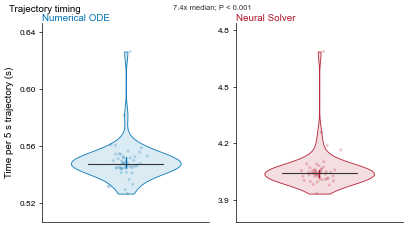

In [54]:
import os
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


timing_path = globals().get('timing_filename', 'timing_stats_N16_B15_A10.pt')

data = torch.load(timing_path, map_location='cpu')
times_true = data['t_gen_true_per_traj'].detach().cpu().numpy().astype(float)
times_sim = data['t_gen_sim_per_traj'].detach().cpu().numpy().astype(float)
duration_s = float(globals().get('DURATION', 5.0))

BLUE = '#0072B2'
RED = '#B2182B'
NEUTRAL = '#333333'
single_col = float(globals().get('single_col', 3.35))
times_true = times_true[np.isfinite(times_true) & (times_true > 0)]
times_sim = times_sim[np.isfinite(times_sim) & (times_sim > 0)]

p_value = globals().get('p_value_result', None)
if p_value is None:
    try:
        from scipy import stats as scipy_stats
        _, p_value = scipy_stats.mannwhitneyu(times_sim, times_true, alternative='greater')
    except Exception:
        p_value = None


def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
    ax.tick_params(axis='both', which='minor', direction='out', length=1.5, width=0.4)
    ax.grid(False)


def plot_editable_points(ax, x_values, y_values, color, markersize=2.2, alpha=0.25, zorder=2):
    for x_value, y_value in zip(np.asarray(x_values), np.asarray(y_values)):
        ax.plot(
            [float(x_value)], [float(y_value)],
            marker='o', markersize=markersize,
            markerfacecolor=color, markeredgecolor='none', markeredgewidth=0,
            linestyle='None', alpha=alpha, zorder=zorder,
            rasterized=False,
        )


def draw_violin(ax, values, color, title):
    values = values[np.isfinite(values) & (values > 0)]
    violin = ax.violinplot(
        [values],
        positions=[1.0],
        widths=0.50,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    body = violin['bodies'][0]
    body.set_facecolor(mpl.colors.to_rgba(color, 0.14))
    body.set_edgecolor(mpl.colors.to_rgba(color, 0.90))
    body.set_linewidth(0.65)
    body.set_alpha(None)
    body.set_rasterized(False)

    rng = np.random.default_rng(23)
    x = 1.0 + rng.normal(0, 0.035, size=values.size)
    q1, median, q3 = np.percentile(values, [25, 50, 75])
    plot_editable_points(ax, x, values, color, markersize=2.2, alpha=0.23, zorder=2)
    ax.plot([1.0, 1.0], [q1, q3], color=color, linewidth=1.0, solid_capstyle='round', zorder=3)
    ax.plot([0.83, 1.17], [median, median], color=NEUTRAL, linewidth=0.8,
            solid_capstyle='round', zorder=4)

    pad = max((values.max() - values.min()) * 0.20, median * 0.015)
    ax.set_ylim(values.min() - pad, values.max() + pad)
    ax.set_xlim(0.62, 1.38)
    ax.set_xticks([])
    ax.set_title(title, loc='left', fontsize=7, fontweight='normal', pad=2, color=color)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    style_axis(ax)
    return median


with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}):
    fig, axes = plt.subplots(1, 2, figsize=(single_col * 1.16, single_col * 0.62),
                             constrained_layout=True)
    median_true = draw_violin(axes[0], times_true, BLUE, 'Numerical ODE')
    median_sim = draw_violin(axes[1], times_sim, RED, 'Neural Solver')
    axes[0].set_ylabel(f'Time per {duration_s:g} s trajectory (s)')
    axes[1].set_ylabel('')

    label = f'{median_sim / median_true:.1f}x median'
    if p_value is not None:
        p_label = 'P < 0.001' if p_value < 0.001 else f'P = {p_value:.2g}'
        label = f'{label}; {p_label}'
    fig.suptitle('Trajectory timing', x=0.02, y=1.02, ha='left', fontsize=7, fontweight='normal')
    fig.text(0.52, 1.02, label, ha='center', va='top', fontsize=5.5, color=NEUTRAL)

    save_path = 'FIG_timing_comparison.svg'
    fig.savefig(save_path, format='svg', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    fig.savefig('FIG_timing_comparison.pdf', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    print(f"Figure saved to {save_path}")
    plt.show()


Finally, we measure the per-step computational cost of the optimization procedure.

Figure saved to FIG_neural_latency_boxplot_clean.svg


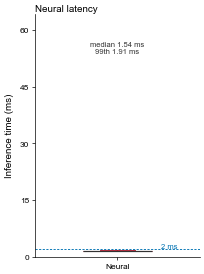

In [55]:
import os
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


timing_path = globals().get('timing_filename', 'timing_stats_N16_B15_A10.pt')

data = torch.load(timing_path, map_location='cpu')
times_ms = data['t_neural_calls_all'].detach().cpu().numpy().astype(float) * 1000.0
times_ms = times_ms[np.isfinite(times_ms) & (times_ms > 0)]

BLUE = '#0072B2'
RED = '#B2182B'
NEUTRAL = '#333333'
single_col = float(globals().get('single_col', 3.35))

q1, median_val, q3, p99 = np.percentile(times_ms, [25, 50, 75, 99])
max_val = times_ms.max()
real_time_ms = globals().get('DT_SIM', None)
if real_time_ms is not None:
    real_time_ms = float(real_time_ms) * 1000.0
elif 'T_SPAN' in globals() and len(T_SPAN) > 1:
    t_span_np = T_SPAN.detach().cpu().numpy() if torch.is_tensor(T_SPAN) else np.asarray(T_SPAN)
    real_time_ms = float(np.median(np.diff(t_span_np))) * 1000.0
elif 'real_time_update_ms' in globals():
    real_time_ms = float(real_time_update_ms)
else:
    real_time_ms = 2.0


def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
    ax.tick_params(axis='both', which='minor', direction='out', length=1.5, width=0.4)
    ax.grid(False)


with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}):
    fig, ax = plt.subplots(figsize=(single_col * 0.58, single_col * 0.78), constrained_layout=True)
    ax.boxplot(
        [times_ms],
        positions=[1.0],
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        whis=1.5,
        manage_ticks=False,
        boxprops={'facecolor': mpl.colors.to_rgba(RED, 0.14), 'edgecolor': RED, 'linewidth': 0.75},
        medianprops={'color': NEUTRAL, 'linewidth': 0.85},
        whiskerprops={'color': RED, 'linewidth': 0.65},
        capprops={'color': RED, 'linewidth': 0.65},
    )

    if real_time_ms is not None and real_time_ms > 0:
        ax.axhline(real_time_ms, color=BLUE, linewidth=0.65, linestyle=(0, (2.4, 1.6)), zorder=1)
        ax.text(1.19, real_time_ms * 1.04, f'{real_time_ms:g} ms', ha='left', va='bottom',
                fontsize=5.5, color=BLUE)

    ax.text(1.0, max_val * 0.94, f'median {median_val:.2f} ms\n99th {p99:.2f} ms',
            ha='center', va='top', fontsize=5.5, color=NEUTRAL)
    ax.set_xlim(0.64, 1.36)
    ax.set_ylim(0, max_val * 1.06)
    ax.set_xticks([1.0])
    ax.set_xticklabels(['Neural'])
    ax.set_ylabel('Inference time (ms)')
    ax.set_title('Neural latency', loc='left', fontsize=7, fontweight='normal', pad=2)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    style_axis(ax)

    save_path = 'FIG_neural_latency_boxplot_clean.svg'
    fig.savefig(save_path, format='svg', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    fig.savefig('FIG_neural_latency_boxplot_clean.pdf', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    print(f"Figure saved to {save_path}")
    plt.show()


In addition, we compare the per-step latency of the forward solver with the inference latency of the inverse model (network trained on 16,000 samples) in a separate box plot.

Figure saved to FIG_neural_latency_forward_inverse_boxplot_clean.svg


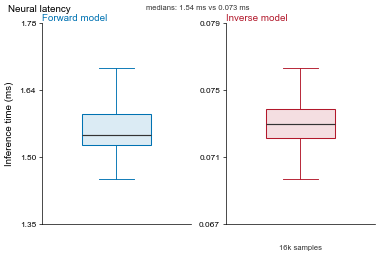

In [56]:
import os
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


timing_path = globals().get('timing_filename', 'timing_stats_N16_B15_A10.pt')

forward_data = torch.load(timing_path, map_location='cpu')
forward_times_ms = forward_data['t_neural_calls_all'].detach().cpu().numpy().astype(float) * 1000.0
forward_times_ms = forward_times_ms[np.isfinite(forward_times_ms) & (forward_times_ms > 0)]

benchmark_size = 16000
benchmark_path = 'timing_benchmark_interleaved.pt'
if os.path.exists(benchmark_path):
    benchmark_checkpoint = torch.load(benchmark_path, map_location='cpu')
    benchmark_data = benchmark_checkpoint['benchmark_data']
    benchmark_key = benchmark_size if benchmark_size in benchmark_data else str(benchmark_size)
    inverse_times_ms = benchmark_data[benchmark_key].detach().cpu().numpy().astype(float)
elif 'final_data' in globals() and benchmark_size in final_data:
    inverse_times_ms = final_data[benchmark_size].detach().cpu().numpy().astype(float)
elif 'df' in globals():
    inverse_times_ms = df.loc[df['Dataset_Size'].astype(str) == str(benchmark_size), 'Time_ms'].to_numpy(dtype=float)
else:
    raise FileNotFoundError('Could not find timing_benchmark_interleaved.pt or in-memory 16k benchmark data.')
inverse_times_ms = inverse_times_ms[np.isfinite(inverse_times_ms) & (inverse_times_ms > 0)]

BLUE = '#0072B2'
RED = '#B2182B'
NEUTRAL = '#333333'
single_col = float(globals().get('single_col', 3.35))


def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='out', length=2.5, width=0.5, pad=2)
    ax.tick_params(axis='both', which='minor', direction='out', length=1.5, width=0.4)
    ax.grid(False)


def draw_clean_boxplot(ax, values, color, title):
    values = values[np.isfinite(values) & (values > 0)]
    ax.boxplot(
        [values],
        positions=[1.0],
        widths=0.32,
        patch_artist=True,
        showfliers=False,
        whis=1.5,
        manage_ticks=False,
        boxprops={'facecolor': mpl.colors.to_rgba(color, 0.14), 'edgecolor': color, 'linewidth': 0.75},
        medianprops={'color': NEUTRAL, 'linewidth': 0.85},
        whiskerprops={'color': color, 'linewidth': 0.65},
        capprops={'color': color, 'linewidth': 0.65},
    )
    q1, median, q3 = np.percentile(values, [25, 50, 75])
    iqr = q3 - q1
    lower_whisker = values[values >= q1 - 1.5 * iqr].min()
    upper_whisker = values[values <= q3 + 1.5 * iqr].max()
    pad = max((upper_whisker - lower_whisker) * 0.40, median * 0.015)
    y_lower = max(0, lower_whisker - pad)
    y_upper = upper_whisker + pad
    y_ticks = np.linspace(y_lower, y_upper, 4)
    tick_decimals = 3 if y_upper < 0.2 else 2
    ax.set_ylim(y_lower, y_upper)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{tick:.{tick_decimals}f}' for tick in y_ticks])
    ax.set_xlim(0.66, 1.34)
    ax.set_xticks([])
    ax.set_title(title, loc='left', fontsize=7, fontweight='normal', pad=2, color=color)
    style_axis(ax)
    return median


with mpl.rc_context({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}):
    fig, axes = plt.subplots(1, 2, figsize=(single_col * 1.08, single_col * 0.70), constrained_layout=True)
    forward_median = draw_clean_boxplot(axes[0], forward_times_ms, BLUE, 'Forward model')
    inverse_median = draw_clean_boxplot(axes[1], inverse_times_ms, RED, 'Inverse model')
    axes[0].set_ylabel('Inference time (ms)')
    axes[1].set_ylabel('')
    axes[1].text(0.5, -0.10, '16k samples', transform=axes[1].transAxes,
                 ha='center', va='top', fontsize=5.5, color=NEUTRAL)
    fig.suptitle('Neural latency', x=0.02, y=1.02, ha='left', fontsize=7, fontweight='normal')
    fig.text(0.52, 1.02, f'medians: {forward_median:.2f} ms vs {inverse_median:.3f} ms',
             ha='center', va='top', fontsize=5.5, color=NEUTRAL)

    save_path = 'FIG_neural_latency_forward_inverse_boxplot_clean.svg'
    fig.savefig(save_path, format='svg', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    fig.savefig('FIG_neural_latency_forward_inverse_boxplot_clean.pdf', bbox_inches='tight', pad_inches=0.03, facecolor='white')
    print(f"Figure saved to {save_path}")
    plt.show()


# Section 7: Analytical-S control for the forward solver

The closed-loop forward-dynamics errors reported in Section 6 combine three sources, namely the learned Appell energy $S_{\text{net}}$, the two-stage optimizer that minimizes the objective at every time step, and the first-order semi-implicit Euler integrator that is compared against a fourth-order Runge-Kutta reference. To isolate the contribution of the network, this section repeats the simulation with the analytical Gibbs-Appell function $S$ in place of $S_{\text{net}}$, keeping the candidate search, the Adam refinement, the temporal regularizer and the integrator unchanged. The difference between this control and the learned-S pipeline is the error attributable to the learned energy; the remainder is attributable to the solver and the integrator.

The control uses the solver configuration selected for the learned energy ($N = 16$ candidate acceleration vectors within $\pm 15$ rad/s$^2$, $A = 10$ Adam refinement steps, learning rate 0.1, $\lambda = 0.1$, five-step stabilization at $t = 0$, semi-implicit Euler with $\Delta t = 2$ ms over 5 s), from the same 50 initial states and against the same Runge-Kutta reference trajectories as the learned-S run (both are read from the saved results of Section 6), and compares the trajectory-wise RMSE of angle, velocity and acceleration between the two objectives. The result is exported as Supplementary Fig. 3 together with its data package.

The section requires the library imports and the definition cells of Sections 1, 2 and 4 and reads the cached file `simulation_results_50trials_N16_B15_A10.pt`. The simulation is skipped when its output file already exists and was produced from the current learned-S results and solver configuration.

### Constants

In [57]:
# Analytical-S control for the forward solver: dependencies, constants and file paths.

_exs_required_names = [
    # imports (Libraries import cell)
    'os', 'time', 'np', 'pd', 'torch', 'scipy_stats', 'multipletests', 'mpl', 'plt', 'Line2D',
    # analytical kernels and numeric helpers (Sections 1 and 4)
    'TORCH_DTYPE', 'TORCH_EPS', 'as_f32_tensor', 'compute_S_ground_truth_eager', '_gravity_vector_torch',
    # physical parameters and device (Section 2)
    'PARAMS', 'device',
]
_exs_missing_names = [name for name in _exs_required_names if name not in globals()]
if _exs_missing_names:
    raise RuntimeError(
        "Run the definition cells of Sections 1, 2 and 4 first (library imports, analytical "
        f"kernels, physical parameters, forward-dynamics kernels). Missing names: {_exs_missing_names}"
    )

# Simulation protocol of Section 6 (closed-loop simulation with the learned energy)
EXS_SEED = 23
EXS_NUM_TRAJS = 50
EXS_DT_SIM = 0.002
EXS_DURATION = 5.0
EXS_STEPS = int(EXS_DURATION / EXS_DT_SIM)
EXS_GRAVITY = 9.81

# Solver configuration selected for the learned energy (Section 6 / Fig. 6)
EXS_SAMPLED_ACCELERATION_VECTORS = 16
EXS_BOUND = 15.0
EXS_ADAM_STEPS = 10
EXS_ADAM_LR = 0.1
EXS_LAMBDA_REG = 0.1
EXS_WARMUP_STEPS = 5
EXS_CONFIG_TAG = f"N{EXS_SAMPLED_ACCELERATION_VECTORS}_B{EXS_BOUND:g}_A{EXS_ADAM_STEPS}"

# Guard against silent divergence from Section 6 if its constants are defined in this kernel
for _exs_name, _exs_value in (
    ('BEST_REALTIME_SAMPLED_ACCELERATION_VECTORS', EXS_SAMPLED_ACCELERATION_VECTORS),
    ('BEST_REALTIME_BOUND', EXS_BOUND),
    ('BEST_REALTIME_ADAM_STEPS', EXS_ADAM_STEPS),
    ('DT_SIM', EXS_DT_SIM),
    ('NUM_TRAJS', EXS_NUM_TRAJS),
    ('LAMBDA_REG', EXS_LAMBDA_REG),
    ('WARMUP_STEPS', EXS_WARMUP_STEPS),
    ('DURATION', EXS_DURATION),
    ('STEPS', EXS_STEPS),
):
    if _exs_name in globals() and globals()[_exs_name] != _exs_value:
        raise RuntimeError(f"{_exs_name} = {globals()[_exs_name]} in this kernel, but the control uses {_exs_value}.")

# Files: the learned-S results of Section 6 (input) and the analytical-S control (output)
EXS_BASE_PATH = output_dir if 'output_dir' in globals() else '.'
EXS_LEARNED_RESULTS_PATH = os.path.join(EXS_BASE_PATH, f"simulation_results_50trials_{EXS_CONFIG_TAG}.pt")
EXS_RESULTS_PATH = os.path.join(EXS_BASE_PATH, f"simulation_results_50trials_analyticalS_{EXS_CONFIG_TAG}.pt")
EXS_STATS_CSV_PATH = os.path.join(EXS_BASE_PATH, f"forward_solver_analyticalS_statistics_{EXS_CONFIG_TAG}.csv")

# Destinations of the supplementary figure and its data package (SUBMISSION tree)
EXS_FIGURE_NAME = 'FIGS3'
_exs_repo_root = os.path.normpath(os.path.join(EXS_BASE_PATH, os.pardir))
EXS_FIGURE_DIR = os.path.join(_exs_repo_root, 'SUBMISSION', 'FIGURES', 'PDF AND PNG')
EXS_PACKAGE_DIR = os.path.join(_exs_repo_root, 'SUBMISSION', 'FIGURES', 'DATA AND SCRIPTS')
for _exs_dir_name in ('EXS_FIGURE_DIR', 'EXS_PACKAGE_DIR'):
    if not os.path.isdir(globals()[_exs_dir_name]):
        print(f"Warning: {globals()[_exs_dir_name]} not found; {_exs_dir_name} falls back to '{EXS_BASE_PATH}'.")
        globals()[_exs_dir_name] = EXS_BASE_PATH

print(f"Learned-S results (input): {EXS_LEARNED_RESULTS_PATH}")
print(f"Analytical-S results:      {EXS_RESULTS_PATH}")
print(f"Solver configuration:      {EXS_CONFIG_TAG}, lr {EXS_ADAM_LR}, lambda {EXS_LAMBDA_REG}, "
      f"warm-up {EXS_WARMUP_STEPS}, dt {EXS_DT_SIM} s, {EXS_STEPS} steps")

Learned-S results (input): ./simulation_results_50trials_N16_B15_A10.pt
Analytical-S results:      ./simulation_results_50trials_analyticalS_N16_B15_A10.pt
Solver configuration:      N16_B15_A10, lr 0.1, lambda 0.1, warm-up 5, dt 0.002 s, 2500 steps


### Forward solver with the analytical Appell energy

The functions below reproduce the two-stage solver of Section 6 step by step, with the analytical Gibbs-Appell function $S(\mathbf{q}, \dot{\mathbf{q}}, \ddot{\mathbf{q}})$ (Section 1, evaluated in physical units) replacing the de-standardized network output in the objective

$$
J(\ddot{\mathbf{q}}) = S(\mathbf{q}, \dot{\mathbf{q}}, \ddot{\mathbf{q}}) + \mathbf{G}(\mathbf{q})^\top \ddot{\mathbf{q}} + \lambda \|\ddot{\mathbf{q}} - \ddot{\mathbf{q}}_{\text{prev}}\|^2 .
$$

At every time step the objective is evaluated for $N = 16$ candidate accelerations (the zero vector, the previous acceleration and 14 vectors drawn uniformly within $\pm 15$ rad/s$^2$), the best candidate is refined with 10 Adam steps (learning rate 0.1) using the exact gradient of $J$, and the state is advanced with the same semi-implicit Euler update. Because $S$ is analytical, the objective and its gradient are exact; any remaining error therefore comes from the candidate search, the finite refinement, the regularizer and the integrator, not from a learned model.

In [58]:
_exs_m1 = as_f32_tensor(PARAMS['m1'], device=device)
_exs_m2 = as_f32_tensor(PARAMS['m2'], device=device)
_exs_l1 = as_f32_tensor(PARAMS['l1'], device=device)
_exs_l2 = as_f32_tensor(PARAMS['l2'], device=device)
_exs_g = as_f32_tensor(EXS_GRAVITY, device=device)


def exs_analytical_S(q_t, dq_t, ddq):
    """Analytical Gibbs-Appell function for one state and one or many acceleration vectors (ddq: [..., 2])."""
    return compute_S_ground_truth_eager(
        q_t[0], q_t[1], dq_t[0], dq_t[1], ddq[..., 0], ddq[..., 1],
        _exs_m1, _exs_m2, _exs_l1, _exs_l2,
    )


def exs_objective(q_t, dq_t, ddq, prev_ddq_t, g_vec_t):
    """J = S + G . ddq + lambda ||ddq - ddq_prev||^2, batched over the leading dimension of ddq."""
    work_term = (ddq * g_vec_t).sum(dim=-1)
    reg_term = EXS_LAMBDA_REG * ((ddq - prev_ddq_t) ** 2).sum(dim=-1)
    return exs_analytical_S(q_t, dq_t, ddq) + work_term + reg_term


def exs_solve_acceleration(q_t, dq_t, prev_ddq_t, candidate_buffer):
    """Two-stage solver of Section 6 (coarse candidate search, then Adam refinement) with the analytical S."""
    g_vec_t = _gravity_vector_torch(q_t[0], q_t[1], _exs_m1, _exs_m2, _exs_l1, _exs_l2, _exs_g)

    with torch.no_grad():
        candidate_buffer.uniform_(-EXS_BOUND, EXS_BOUND)
        candidate_buffer[0].zero_()
        candidate_buffer[1].copy_(prev_ddq_t)
        costs = exs_objective(q_t, dq_t, candidate_buffer, prev_ddq_t, g_vec_t)
        best_guess = candidate_buffer[torch.argmin(costs)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([ddq_opt], lr=EXS_ADAM_LR)
    for _ in range(EXS_ADAM_STEPS):
        optimizer.zero_grad(set_to_none=True)
        loss = exs_objective(q_t, dq_t, ddq_opt, prev_ddq_t, g_vec_t)
        loss.backward()
        optimizer.step()
    return ddq_opt.detach()


def exs_integrate_semi_implicit(q, dq, ddq, dt):
    dq_next = dq + dt * ddq
    q_next = q + dt * dq_next
    return q_next, dq_next


def exs_rollout(q_init, dq_init):
    """Closed-loop rollout from one initial state; returns q, dq, ddq [EXS_STEPS, 2] and the wall-clock time."""
    candidate_buffer = torch.empty(EXS_SAMPLED_ACCELERATION_VECTORS, 2, dtype=TORCH_DTYPE, device=device)
    q_sim = torch.empty(EXS_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    dq_sim = torch.empty(EXS_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    ddq_sim = torch.empty(EXS_STEPS, 2, dtype=TORCH_DTYPE, device=device)

    q_curr = q_init.clone()
    dq_curr = dq_init.clone()
    prev_acc = torch.zeros(2, dtype=TORCH_DTYPE, device=device)
    q_sim[0].copy_(q_curr)
    dq_sim[0].copy_(dq_curr)

    tic = time.perf_counter()
    for i in range(EXS_STEPS):
        if i == 0:
            # Stabilization loop for the temporal regularizer at t = 0 (as in Section 6)
            for _ in range(EXS_WARMUP_STEPS):
                prev_acc = exs_solve_acceleration(q_curr, dq_curr, prev_acc, candidate_buffer)

        ddq_curr = exs_solve_acceleration(q_curr, dq_curr, prev_acc, candidate_buffer)
        ddq_sim[i].copy_(ddq_curr)
        prev_acc = ddq_curr

        q_curr, dq_curr = exs_integrate_semi_implicit(q_curr, dq_curr, ddq_curr, EXS_DT_SIM)
        if i + 1 < EXS_STEPS:
            q_sim[i + 1].copy_(q_curr)
            dq_sim[i + 1].copy_(dq_curr)
    return q_sim, dq_sim, ddq_sim, time.perf_counter() - tic


# Sanity check of the analytical objective: at the true acceleration of a state, the
# gradient of S + G . ddq must vanish (Gibbs-Appell equation), so the refinement has
# nothing to correct when started at the exact solution.
_exs_q = torch.tensor([0.3, -0.4], dtype=TORCH_DTYPE, device=device)
_exs_dq = torch.tensor([0.5, -0.2], dtype=TORCH_DTYPE, device=device)
_exs_g_vec = _gravity_vector_torch(_exs_q[0], _exs_q[1], _exs_m1, _exs_m2, _exs_l1, _exs_l2, _exs_g)
_exs_ddq_true = torch.stack(_compute_accelerations_torch(
    _exs_q[0], _exs_q[1], _exs_dq[0], _exs_dq[1], _exs_m1, _exs_m2, _exs_l1, _exs_l2, _exs_g)).detach()
_exs_ddq_var = _exs_ddq_true.clone().requires_grad_(True)
(exs_analytical_S(_exs_q, _exs_dq, _exs_ddq_var) + torch.dot(_exs_g_vec, _exs_ddq_var)).backward()
print(f"Gradient of S + G.ddq at the true acceleration: {_exs_ddq_var.grad.abs().max().item():.2e} "
      f"(should be ~0; true ddq = {_exs_ddq_true.tolist()})")

Gradient of S + G.ddq at the true acceleration: 4.77e-07 (should be ~0; true ddq = [-5.926192283630371, 12.461297988891602])


### Closed-loop simulation from the same initial states

The initial states and the Runge-Kutta reference trajectories are read from the saved learned-S results of Section 6, so that both objectives are evaluated on the identical 50 trajectories and against the identical reference. The RMSE of angle, velocity and acceleration is then computed over the 2,500 states of each trajectory, exactly as in Section 6. The run is skipped when the output file already exists and records the same source file and solver configuration.

In [59]:
import hashlib


def exs_sha256_of_file(path, chunk_size=1 << 20):
    digest = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


if not os.path.exists(EXS_LEARNED_RESULTS_PATH):
    raise FileNotFoundError(
        f"Learned-S results '{EXS_LEARNED_RESULTS_PATH}' not found. Run the closed-loop simulation of Section 6 first."
    )
print(f"Loading learned-S results from '{EXS_LEARNED_RESULTS_PATH}'...")
exs_learned = torch.load(EXS_LEARNED_RESULTS_PATH, map_location='cpu')
exs_learned_sha256 = exs_sha256_of_file(EXS_LEARNED_RESULTS_PATH)

# Reference trajectories (RK4) and initial states shared with the learned-S run
exs_true_q = exs_learned['all_true_q'].to(dtype=TORCH_DTYPE)
exs_true_dq = exs_learned['all_true_dq'].to(dtype=TORCH_DTYPE)
exs_true_ddq = exs_learned['all_true_ddq'].to(dtype=TORCH_DTYPE)
if tuple(exs_true_q.shape) != (EXS_NUM_TRAJS, EXS_STEPS, 2):
    raise RuntimeError(f"Unexpected reference shape {tuple(exs_true_q.shape)}; expected {(EXS_NUM_TRAJS, EXS_STEPS, 2)}.")
exs_init_q = exs_true_q[:, 0, :].clone()
exs_init_dq = exs_true_dq[:, 0, :].clone()
if not (torch.equal(exs_learned['all_pred_q'][:, 0, :].to(TORCH_DTYPE), exs_init_q)
        and torch.equal(exs_learned['all_pred_dq'][:, 0, :].to(TORCH_DTYPE), exs_init_dq)):
    raise RuntimeError("The learned-S rollouts do not start from the stored reference initial states.")
print(f"Reference trajectories: {tuple(exs_true_q.shape)}; initial states taken from the same file.")

exs_config = {
    'sampled_acceleration_vectors_N': EXS_SAMPLED_ACCELERATION_VECTORS,
    'uniform_acceleration_bound_B_rad_s2': float(EXS_BOUND),
    'adam_refinement_steps_A': EXS_ADAM_STEPS,
    'adam_learning_rate': float(EXS_ADAM_LR),
    'lambda_regularization': float(EXS_LAMBDA_REG),
    'warmup_steps': EXS_WARMUP_STEPS,
    'simulation_dt_s': float(EXS_DT_SIM),
    'steps': EXS_STEPS,
    'num_trajectories': EXS_NUM_TRAJS,
    'seed': EXS_SEED,
    'gravity_m_s2': float(EXS_GRAVITY),
    'params': {key: float(value) for key, value in PARAMS.items()},
    'objective': 'analytical Gibbs-Appell S + G(q).ddq + lambda ||ddq - ddq_prev||^2',
    'integrator': 'semi-implicit Euler',
}


def exs_load_cached_results():
    """Returns the cached control results only if they were produced from the current learned-S file and configuration."""
    if not os.path.exists(EXS_RESULTS_PATH):
        return None
    cached = torch.load(EXS_RESULTS_PATH, map_location='cpu')
    if cached.get('learned_results_sha256') == exs_learned_sha256 and cached.get('config') == exs_config:
        return cached
    print(f"Existing results '{EXS_RESULTS_PATH}' were produced from a different source file or configuration; re-running.")
    return None


def exs_run_control(init_q, init_dq, true_q, true_dq, true_ddq):
    """Runs the analytical-S rollout from every initial state and returns the results dictionary."""
    torch.manual_seed(EXS_SEED)
    n = init_q.shape[0]
    rmse_pos = torch.empty(n, 2, dtype=TORCH_DTYPE)
    rmse_vel = torch.empty(n, 2, dtype=TORCH_DTYPE)
    rmse_acc = torch.empty(n, 2, dtype=TORCH_DTYPE)
    pred_q = torch.empty(n, EXS_STEPS, 2, dtype=TORCH_DTYPE)
    pred_dq = torch.empty(n, EXS_STEPS, 2, dtype=TORCH_DTYPE)
    pred_ddq = torch.empty(n, EXS_STEPS, 2, dtype=TORCH_DTYPE)
    rollout_time = torch.empty(n, dtype=torch.float64)

    global_start = time.perf_counter()
    for k in range(n):
        q_sim, dq_sim, ddq_sim, elapsed = exs_rollout(init_q[k].to(device), init_dq[k].to(device))
        q_true, dq_true, ddq_true = true_q[k].to(device), true_dq[k].to(device), true_ddq[k].to(device)
        rmse_pos[k].copy_(torch.sqrt(torch.mean((q_true - q_sim).square(), dim=0)))
        rmse_vel[k].copy_(torch.sqrt(torch.mean((dq_true - dq_sim).square(), dim=0)))
        rmse_acc[k].copy_(torch.sqrt(torch.mean((ddq_true - ddq_sim).square(), dim=0)))
        pred_q[k].copy_(q_sim)
        pred_dq[k].copy_(dq_sim)
        pred_ddq[k].copy_(ddq_sim)
        rollout_time[k] = elapsed
        if (k + 1) % 10 == 0:
            print(f"  trajectory {k + 1}/{n} done ({time.perf_counter() - global_start:.1f} s elapsed)")
    print(f"Simulation complete in {time.perf_counter() - global_start:.1f} s.")

    return {
        'rmse_pos': rmse_pos.cpu(),
        'rmse_vel': rmse_vel.cpu(),
        'rmse_acc': rmse_acc.cpu(),
        'trial_time': exs_learned['trial_time'],
        'all_true_q': true_q.cpu(),
        'all_true_dq': true_dq.cpu(),
        'all_true_ddq': true_ddq.cpu(),
        'all_pred_q': pred_q.cpu(),
        'all_pred_dq': pred_dq.cpu(),
        'all_pred_ddq': pred_ddq.cpu(),
        'rollout_time_s': rollout_time.cpu(),
        'config': exs_config,
        'learned_results_file': os.path.basename(EXS_LEARNED_RESULTS_PATH),
        'learned_results_sha256': exs_learned_sha256,
        'note': ('Initial states and RK4 reference trajectories are those of the learned-S run '
                 '(learned_results_file); only the objective differs (analytical S instead of the network).'),
    }


exs_results = exs_load_cached_results()
if exs_results is not None:
    print(f"Found existing analytical-S results: '{EXS_RESULTS_PATH}' -- loading instead of re-simulating.")
else:
    print(f"Running the analytical-S control on {EXS_NUM_TRAJS} trajectories ({EXS_STEPS} steps each)...")
    exs_results = exs_run_control(exs_init_q, exs_init_dq, exs_true_q, exs_true_dq, exs_true_ddq)
    torch.save(exs_results, EXS_RESULTS_PATH)
    print(f"Saved analytical-S results to '{EXS_RESULTS_PATH}'.")

# Long-form table of trajectory-wise RMSEs for both objectives
EXS_QUANTITIES = (('position', 'rmse_pos', 'rad'), ('velocity', 'rmse_vel', 'rad/s'), ('acceleration', 'rmse_acc', 'rad/s^2'))


def exs_build_rmse_table(learned, analytical):
    records = []
    for model_name, results in (('learned_S', learned), ('analytical_S', analytical)):
        for quantity, key, unit in EXS_QUANTITIES:
            values = results[key].to(dtype=torch.float64).cpu().numpy()
            for joint_idx, joint in enumerate(('J1', 'J2')):
                for trajectory_idx in range(values.shape[0]):
                    records.append({
                        'model': model_name, 'quantity': quantity, 'unit': unit, 'joint': joint,
                        'trajectory': trajectory_idx, 'rmse': float(values[trajectory_idx, joint_idx]),
                    })
    return pd.DataFrame(records)


exs_rmse_df = exs_build_rmse_table(exs_learned, exs_results)


def exs_print_descriptives(rmse_df):
    print("\n--- Trajectory-wise RMSE of the closed-loop simulation (50 trajectories, identical initial states and reference) ---")
    print(f"{'Quantity':<13} | {'Joint':<5} | {'Learned S median [IQR]':<26} | {'Analytical S median [IQR]':<26} | {'ratio (analytical / learned)'}")
    print('-' * 110)
    for quantity, _, unit in EXS_QUANTITIES:
        for joint in ('J1', 'J2'):
            sel = rmse_df[(rmse_df['quantity'] == quantity) & (rmse_df['joint'] == joint)]
            learned = sel[sel['model'] == 'learned_S']['rmse']
            analytical = sel[sel['model'] == 'analytical_S']['rmse']
            lq1, lmed, lq3 = learned.quantile([0.25, 0.5, 0.75])
            aq1, amed, aq3 = analytical.quantile([0.25, 0.5, 0.75])
            print(f"{quantity:<13} | {joint:<5} | {lmed:.5f} [{lq3 - lq1:.5f}] {unit:<8} | "
                  f"{amed:.5f} [{aq3 - aq1:.5f}] {unit:<8} | {amed / lmed:.3f}")
    print('-' * 110)


exs_print_descriptives(exs_rmse_df)
print(f"Analytical-S rollout time per trajectory: median {np.median(exs_results['rollout_time_s'].numpy()):.2f} s "
      f"(for reference only; not a timing comparison).")

Loading learned-S results from './simulation_results_50trials_N16_B15_A10.pt'...
Reference trajectories: (50, 2500, 2); initial states taken from the same file.
Running the analytical-S control on 50 trajectories (2500 steps each)...


  trajectory 10/50 done (63.1 s elapsed)


  trajectory 20/50 done (114.5 s elapsed)


  trajectory 30/50 done (164.4 s elapsed)


  trajectory 40/50 done (215.1 s elapsed)


  trajectory 50/50 done (262.7 s elapsed)
Simulation complete in 262.7 s.
Saved analytical-S results to './simulation_results_50trials_analyticalS_N16_B15_A10.pt'.

--- Trajectory-wise RMSE of the closed-loop simulation (50 trajectories, identical initial states and reference) ---
Quantity      | Joint | Learned S median [IQR]     | Analytical S median [IQR]  | ratio (analytical / learned)
--------------------------------------------------------------------------------------------------------------
position      | J1    | 0.00737 [0.00151] rad      | 0.00728 [0.00193] rad      | 0.987
position      | J2    | 0.01188 [0.00780] rad      | 0.01184 [0.01028] rad      | 0.997
velocity      | J1    | 0.03090 [0.01878] rad/s    | 0.02851 [0.02221] rad/s    | 0.922
velocity      | J2    | 0.06771 [0.05114] rad/s    | 0.06605 [0.06359] rad/s    | 0.975
acceleration  | J1    | 0.16534 [0.10431] rad/s^2  | 0.16463 [0.13178] rad/s^2  | 0.996
acceleration  | J2    | 0.38210 [0.27121] rad/s^2  | 0.3

### Statistical comparison

For each quantity (angle, velocity, acceleration) and joint, the trajectory-wise RMSE distributions of the two objectives are tested for normality with the Shapiro-Wilk test ($\alpha = 0.05$) and compared with a one-way ANOVA when both are normal and with a Kruskal-Wallis H-test otherwise, following the convention used elsewhere in this notebook; the six p values are corrected with the Benjamini-Hochberg procedure. Because both objectives are evaluated on the same 50 trajectories, a paired Wilcoxon signed-rank test is reported as a secondary check, together with the ratio of medians and Cliff's delta (both in the direction analytical S versus learned S). The table is saved as a CSV file next to the other artifacts.

In [60]:
EXS_ALPHA = 0.05


def exs_cliffs_delta(values_a, values_b):
    """Cliff's delta = P(a > b) - P(a < b) over all pairs; positive when `values_a` tends to be larger."""
    a = np.asarray(values_a, dtype=float)[:, None]
    b = np.asarray(values_b, dtype=float)[None, :]
    return float(np.mean(np.sign(a - b)))


def exs_compute_statistics(rmse_df, alpha=EXS_ALPHA):
    """Per quantity and joint: normality, primary test (ANOVA or Kruskal-Wallis), FDR, paired Wilcoxon, effect sizes."""
    print(f"\n{'='*20} Normality Test (Shapiro-Wilk) {'='*20}")
    print(f"{'Quantity':<13} | {'Joint':<5} | {'Objective':<13} | {'P-Value':<12} | {'Distribution'}")
    print('-' * 70)
    rows = []
    for quantity, _, unit in EXS_QUANTITIES:
        for joint in ('J1', 'J2'):
            sel = rmse_df[(rmse_df['quantity'] == quantity) & (rmse_df['joint'] == joint)].sort_values(['model', 'trajectory'])
            learned = sel[sel['model'] == 'learned_S']['rmse'].to_numpy(dtype=float)
            analytical = sel[sel['model'] == 'analytical_S']['rmse'].to_numpy(dtype=float)

            shapiro_learned = scipy_stats.shapiro(learned)
            shapiro_analytical = scipy_stats.shapiro(analytical)
            for name, result in (('learned S', shapiro_learned), ('analytical S', shapiro_analytical)):
                is_normal = result.pvalue > alpha
                p_str = f"{result.pvalue:.2e}" if is_normal else f"*{result.pvalue:.2e}"
                print(f"{quantity:<13} | {joint:<5} | {name:<13} | {p_str:<12} | {'Normal' if is_normal else 'Not Normal'}")
            both_normal = (shapiro_learned.pvalue > alpha) and (shapiro_analytical.pvalue > alpha)

            if both_normal:
                test_name = 'One-way ANOVA'
                primary = scipy_stats.f_oneway(learned, analytical)
            else:
                test_name = 'Kruskal-Wallis H-test'
                primary = scipy_stats.kruskal(learned, analytical)

            # Secondary tests in the direction analytical S vs learned S (paired by trajectory for Wilcoxon)
            mann_whitney = scipy_stats.mannwhitneyu(analytical, learned, alternative='two-sided')
            wilcoxon = scipy_stats.wilcoxon(analytical, learned, alternative='two-sided')

            lq1, lmed, lq3 = np.percentile(learned, [25, 50, 75])
            aq1, amed, aq3 = np.percentile(analytical, [25, 50, 75])
            rows.append({
                'quantity': quantity, 'unit': unit, 'joint': joint, 'joint_label': f"Joint {joint[1]}",
                'n_learned': int(learned.size), 'n_analytical': int(analytical.size),
                'shapiro_p_learned': float(shapiro_learned.pvalue), 'shapiro_p_analytical': float(shapiro_analytical.pvalue),
                'both_normal': bool(both_normal), 'test_name': test_name,
                'statistic': float(primary.statistic), 'p_value': float(primary.pvalue),
                'mann_whitney_u_analytical_vs_learned': float(mann_whitney.statistic),
                'mann_whitney_p_two_sided': float(mann_whitney.pvalue),
                'wilcoxon_paired_statistic': float(wilcoxon.statistic),
                'wilcoxon_paired_p_two_sided': float(wilcoxon.pvalue),
                'mean_learned': float(learned.mean()), 'sd_learned': float(learned.std(ddof=1)),
                'median_learned': float(lmed), 'iqr_learned': float(lq3 - lq1),
                'mean_analytical': float(analytical.mean()), 'sd_analytical': float(analytical.std(ddof=1)),
                'median_analytical': float(amed), 'iqr_analytical': float(aq3 - aq1),
                'median_ratio_analytical_over_learned': float(amed / lmed),
                'cliffs_delta_analytical_vs_learned': exs_cliffs_delta(analytical, learned),
            })
    print('-' * 70)
    print("* p < 0.05 indicates data is not normally distributed.")

    stats_df = pd.DataFrame(rows)
    stats_df['fdr_q_value'] = multipletests(stats_df['p_value'].to_numpy(), method='fdr_bh')[1]
    stats_df['significant_fdr_0_05'] = stats_df['fdr_q_value'] < alpha
    ordered = ['quantity', 'unit', 'joint', 'joint_label', 'n_learned', 'n_analytical',
               'shapiro_p_learned', 'shapiro_p_analytical', 'both_normal', 'test_name', 'statistic', 'p_value',
               'fdr_q_value', 'significant_fdr_0_05',
               'mann_whitney_u_analytical_vs_learned', 'mann_whitney_p_two_sided',
               'wilcoxon_paired_statistic', 'wilcoxon_paired_p_two_sided',
               'mean_learned', 'sd_learned', 'median_learned', 'iqr_learned',
               'mean_analytical', 'sd_analytical', 'median_analytical', 'iqr_analytical',
               'median_ratio_analytical_over_learned', 'cliffs_delta_analytical_vs_learned']
    return stats_df[ordered]


def exs_print_statistics(stats_df, alpha=EXS_ALPHA):
    print(f"\n{'='*20} Hypothesis testing: analytical S vs learned S {'='*20}")
    for _, row in stats_df.iterrows():
        verdict = 'significant' if row['significant_fdr_0_05'] else 'not significant'
        print(f"{row['quantity']:<13} {row['joint_label']}: {row['test_name']} | statistic = {row['statistic']:.4f} | "
              f"p = {row['p_value']:.3e} | FDR q = {row['fdr_q_value']:.3e} -> {verdict} at alpha = {alpha}")
        print(f"   medians: learned {row['median_learned']:.5f} vs analytical {row['median_analytical']:.5f} {row['unit']} "
              f"(ratio analytical/learned = {row['median_ratio_analytical_over_learned']:.3f}); "
              f"Cliff's delta = {row['cliffs_delta_analytical_vs_learned']:+.2f}; "
              f"paired Wilcoxon p = {row['wilcoxon_paired_p_two_sided']:.3e}")


exs_stats_df = exs_compute_statistics(exs_rmse_df)
exs_print_statistics(exs_stats_df)
exs_stats_df.to_csv(EXS_STATS_CSV_PATH, index=False)
print(f"\nStatistics table saved to '{EXS_STATS_CSV_PATH}'.")


==================== Normality Test (Shapiro-Wilk) ====================
Quantity      | Joint | Objective     | P-Value      | Distribution
----------------------------------------------------------------------
position      | J1    | learned S     | *5.44e-08    | Not Normal
position      | J1    | analytical S  | *2.24e-07    | Not Normal
position      | J2    | learned S     | *2.62e-04    | Not Normal
position      | J2    | analytical S  | *4.90e-04    | Not Normal
velocity      | J1    | learned S     | *1.99e-05    | Not Normal
velocity      | J1    | analytical S  | *6.50e-05    | Not Normal
velocity      | J2    | learned S     | *2.78e-03    | Not Normal
velocity      | J2    | analytical S  | *2.55e-03    | Not Normal
acceleration  | J1    | learned S     | *1.46e-04    | Not Normal
acceleration  | J1    | analytical S  | *3.31e-04    | Not Normal
acceleration  | J2    | learned S     | *7.45e-04    | Not Normal
acceleration  | J2    | analytical S  | *1.89e-03    | Not Nor

### Supplementary Fig. 3

The figure compares the two objectives trajectory by trajectory, with one panel per joint (rows) and per quantity (columns: angle, velocity and acceleration). Both runs used the same 50 initial states and reference trajectories, so each trajectory is drawn as one line from its RMSE with the learned energy (filled marker) to its RMSE with the analytical-S control (open marker), and the number of trajectories on which the analytical-S error is lower is printed beneath each panel. Heavy bars mark the medians. Because the errors span more than a decade, RMSE is drawn on logarithmic axes whose limits and ticks are labelled 1-2-5 values (logarithmic RMSE axes as in Fig. 3); the limits enclose all data, so no value is clipped. An asterisk above a pair marks a Benjamini-Hochberg-adjusted q value of the primary test below 0.05 (ns otherwise); the exact statistics are in the CSV table of the previous cell. The drawing is the same as in the standalone `FIGS3.ipynb`. The PDF and PNG are written to `SUBMISSION/FIGURES/PDF AND PNG/`.

Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIGS3.pdf


Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIGS3.png


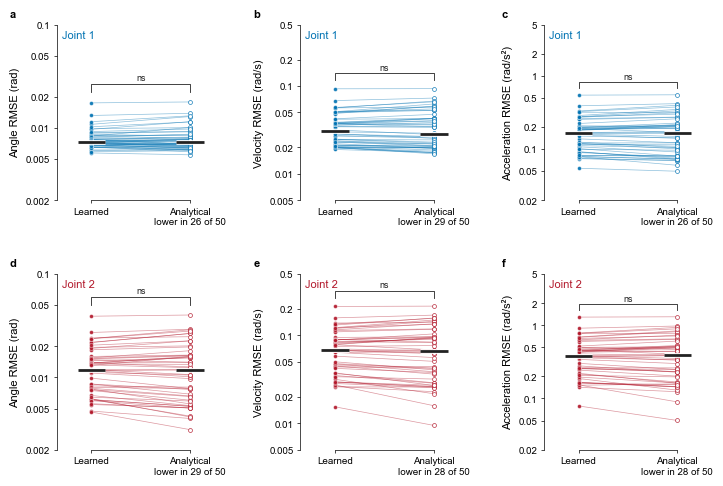

In [61]:
import matplotlib.patheffects as pe
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator

# -----------------------------------------------------------------------------
# Supplementary Fig. 3 plotting code (the same drawing as in the standalone FIGS3.ipynb).
# Paired comparison of the closed-loop forward simulation with the learned Appell energy
# and with the analytical Gibbs-Appell function in the same solver. Both runs used the
# same 50 initial states and reference trajectories, so each trajectory is one line from
# its error with the learned energy (filled marker) to its error with the analytical
# function (open marker); one panel per joint (rows) and quantity (columns). Heavy black
# bars are medians. 'ns' marks a Benjamini-Hochberg-adjusted q value of the primary test
# at or above 0.05, a single asterisk one below it. RMSE is drawn on logarithmic axes
# whose limits and ticks are labelled 1-2-5 x 10^k values. The axis limits
# enclose all plotted values.
# -----------------------------------------------------------------------------
FIGS3_BLUE = '#0072B2'
FIGS3_RED = '#B2182B'
FIGS3_NEUTRAL = '#222222'
FIGS3_JOINTS = ['J1', 'J2']
FIGS3_MODELS = ['learned_S', 'analytical_S']
FIGS3_JOINT_LABELS = {'J1': 'Joint 1', 'J2': 'Joint 2'}
FIGS3_JOINT_COLORS = {'J1': FIGS3_BLUE, 'J2': FIGS3_RED}
FIGS3_QUANTITIES = [('position', 'Angle RMSE (rad)'), ('velocity', 'Velocity RMSE (rad/s)'),
                    ('acceleration', 'Acceleration RMSE (rad/s²)')]
# Labelled axis values (1-2-5 x 10^k)
FIGS3_TICKS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
FIGS3_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def figs3_significance_label(q_value):
    # Benjamini-Hochberg-adjusted q value of the primary test: 'ns' at or above 0.05, '*' below it
    return 'ns' if q_value >= 0.05 else '*'


def figs3_tight_limits(values):
    # Tightest labelled ticks enclosing all values, with headroom above the maximum for the bracket
    return (max(tick for tick in FIGS3_TICKS if tick <= np.min(values)),
            min(tick for tick in FIGS3_TICKS if tick >= np.max(values) * 1.7))


def draw_figs3(rmse_table, stats_table):
    """
    rmse_table:  long-form table with columns model, quantity, joint, trajectory, rmse.
    stats_table: one row per (quantity, joint) with at least the column fdr_q_value.
    Returns the matplotlib figure (two rows of three panels, double-column width, exported at canvas size).
    """
    values = {}
    for quantity, _ in FIGS3_QUANTITIES:
        for joint in FIGS3_JOINTS:
            for model_name in FIGS3_MODELS:
                mask = ((rmse_table['quantity'] == quantity) & (rmse_table['joint'] == joint)
                        & (rmse_table['model'] == model_name))
                values[(quantity, joint, model_name)] = (
                    rmse_table.loc[mask].sort_values('trajectory')['rmse'].to_numpy(dtype=float)
                )

    x_learned, x_analytical = 0.0, 1.0
    fig, axes = plt.subplots(2, 3, figsize=(7.2, 5.0), sharey='col')
    fig.subplots_adjust(left=0.075, right=0.985, top=0.95, bottom=0.10, wspace=0.45, hspace=0.42)
    limits = {}
    for column, (quantity, ylabel) in enumerate(FIGS3_QUANTITIES):
        y_low, y_high = figs3_tight_limits(np.r_[values[(quantity, 'J1', 'learned_S')], values[(quantity, 'J1', 'analytical_S')],
                                                 values[(quantity, 'J2', 'learned_S')], values[(quantity, 'J2', 'analytical_S')]])
        limits[quantity] = (y_low, y_high)
        for row, joint in enumerate(FIGS3_JOINTS):
            ax = axes[row, column]
            color = FIGS3_JOINT_COLORS[joint]
            learned, analytical = values[(quantity, joint, 'learned_S')], values[(quantity, joint, 'analytical_S')]
            lower = analytical < learned
            for i in range(learned.size):
                ax.plot([x_learned, x_analytical], [learned[i], analytical[i]], color=color, lw=0.5, alpha=0.45, zorder=2)
            ax.scatter(np.full(learned.size, x_learned), learned, s=8, color=color, edgecolors='white',
                       linewidths=0.3, alpha=0.9, zorder=3)
            ax.scatter(np.full(analytical.size, x_analytical), analytical, s=8, facecolors='white', edgecolors=color,
                       linewidths=0.5, alpha=0.9, zorder=3)
            for x_position, median in ((x_learned, np.median(learned)), (x_analytical, np.median(analytical))):
                ax.plot([x_position - 0.14, x_position + 0.14], [median, median], color=FIGS3_NEUTRAL, lw=2.0,
                        solid_capstyle='butt', zorder=6,
                        path_effects=[pe.withStroke(linewidth=3.4, foreground='white')])
            top = max(learned.max(), analytical.max())
            ax.plot([x_learned, x_learned, x_analytical, x_analytical], [top * 1.25, top * 1.5, top * 1.5, top * 1.25],
                    color=FIGS3_NEUTRAL, lw=0.6, zorder=6)
            stats_row = stats_table.loc[(stats_table['quantity'] == quantity) & (stats_table['joint'] == joint)]
            mark = figs3_significance_label(float(stats_row['fdr_q_value'].iloc[0]))
            ax.text(0.5, top * 1.55, mark, ha='center', va='bottom', fontsize=8 if mark == '*' else 6.5,
                    color=FIGS3_NEUTRAL)
            ax.text(0.03, 0.97, FIGS3_JOINT_LABELS[joint], transform=ax.transAxes, ha='left', va='top',
                    fontsize=8, color=color)
            ax.set_yscale('log')
            ax.set_ylim(y_low, y_high)
            ax.set_xlim(-0.35, 1.35)
            ax.set_xticks([x_learned, x_analytical])
            ax.set_xticklabels(['Learned', f"Analytical\nlower in {int(lower.sum())} of {learned.size}"])
            for side in ('top', 'right'):
                ax.spines[side].set_visible(False)
            ax.spines['bottom'].set_bounds(x_learned, x_analytical)
            if column == 0:
                ax.set_ylabel(ylabel)
        for row in range(2):
            ax = axes[row, column]
            ax.yaxis.set_major_locator(FixedLocator([tick for tick in FIGS3_TICKS if y_low <= tick <= y_high]))
            ax.yaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}"))
            if column > 0:
                ax.set_ylabel(ylabel)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for panel_letter, ax in zip('abcdef', axes.flatten()):
        box = ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
        fig.text(box.x0, box.y1 + 0.004, panel_letter, fontsize=8, fontweight='bold', ha='left', va='bottom')

    # Every plotted value must lie inside its axis
    for quantity, (y_low, y_high) in limits.items():
        column_values = np.concatenate([values[(quantity, joint, model_name)]
                                        for joint in FIGS3_JOINTS for model_name in FIGS3_MODELS])
        assert ((column_values >= y_low) & (column_values <= y_high)).all(), quantity
    return fig


def save_figs3(fig, directory, name):
    # PDF (vector, editable text) and 600-dpi PNG at the canvas size (183 mm wide), as in FIGS3.ipynb
    for ext in ('pdf', 'png'):
        figure_path = os.path.join(directory, f"{name}.{ext}")
        fig.savefig(figure_path, facecolor='white')
        print(f"Saved {figure_path}")


# Draw Supplementary Fig. 3 and save the PDF and PNG to the submission folder
with mpl.rc_context():
    mpl.rc_file_defaults()        # same starting point as the standalone notebook, whatever this kernel has set
    mpl.rcParams.update(FIGS3_RC)
    exs_fig = draw_figs3(exs_rmse_df, exs_stats_df)
    save_figs3(exs_fig, EXS_FIGURE_DIR, EXS_FIGURE_NAME)
    plt.show()

### Data package for Supplementary Fig. 3

Following the packaging used for the other figures, the trajectory-wise RMSE values of both objectives, the statistics table, provenance metadata (source-file hashes, solver configuration, statistical settings, figure conventions) and a README are written into `FIGS3.zip` in `SUBMISSION/FIGURES/DATA AND SCRIPTS/`. The standalone notebook `FIGS3.ipynb` in the same folder regenerates the figure from this archive alone.

In [62]:
import json
import zipfile
from datetime import datetime, timezone

# exs_sha256_of_file is defined in the simulation cell above
exs_package_path = os.path.join(EXS_PACKAGE_DIR, f"{EXS_FIGURE_NAME}.zip")

exs_source_files = {
    os.path.basename(path): {'sha256': exs_sha256_of_file(path), 'bytes': os.path.getsize(path)}
    for path in (EXS_LEARNED_RESULTS_PATH, EXS_RESULTS_PATH, EXS_STATS_CSV_PATH) if os.path.exists(path)
}

exs_metadata = {
    'created_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'description': ('Data package for Supplementary Figure 3: closed-loop forward simulation with the analytical '
                    'Gibbs-Appell function in the solver objective (control) versus the learned Appell energy.'),
    'purpose': ('Separates the error of the learned Appell energy from the error of the solver and the integrator '
                'by running the same forward solver with the analytical Gibbs-Appell function.'),
    'data_derivation': (
        'Learned-S RMSE values were read from simulation_results_50trials_N16_B15_A10.pt (Section 6 of the '
        'notebook; Fig. 6). Analytical-S RMSE values were produced by MAIN_RUN_ME_NEW.ipynb, Section 7, with the '
        'same solver configuration, the same 50 initial states and the same RK4 reference trajectories read from '
        'that file. Statistics were computed from the archived RMSE values.'
    ),
    'source_files': exs_source_files,
    'solver_configuration': exs_config,
    'objectives': {
        'learned_S': 'de-standardized network output S_net(q, dq, ddq) + G(q).ddq + lambda ||ddq - ddq_prev||^2 (Section 6)',
        'analytical_S': 'analytical Gibbs-Appell S(q, dq, ddq) + G(q).ddq + lambda ||ddq - ddq_prev||^2 (Section 7)',
    },
    'reference': {
        'integrator': 'fixed-step RK4 over the 2,500-point time vector of the learned-S run',
        'num_trajectories': EXS_NUM_TRAJS,
        'states_per_trajectory': EXS_STEPS,
        'duration_s': EXS_DURATION,
        'initial_states': 'identical to the learned-S run (read from its results file)',
    },
    'statistics': {
        'alpha': EXS_ALPHA,
        'normality_test': 'Shapiro-Wilk on each group',
        'primary_test_rule': 'one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test',
        'multiple_comparison_correction': 'Benjamini-Hochberg FDR across the six quantity x joint comparisons',
        'secondary_tests': ['two-sided Mann-Whitney U (unpaired; U statistic for analytical vs learned)',
                            'two-sided Wilcoxon signed-rank (paired by trajectory; analytical vs learned)'],
        'effect_sizes': ['median ratio analytical/learned', "Cliff's delta (analytical vs learned)"],
        'primary_test_used': {f"{row['quantity']}_{row['joint']}": row['test_name'] for _, row in exs_stats_df.iterrows()},
        'fdr_q_values': {f"{row['quantity']}_{row['joint']}": float(row['fdr_q_value']) for _, row in exs_stats_df.iterrows()},
    },
    'figure': {
        'content': ('six panels (rows: joint 1 and joint 2; columns: angle, velocity and acceleration RMSE): paired '
                    'comparison, one line per trajectory from its error with the learned S (filled marker) to its '
                    'error with the analytical S (open marker); heavy bars mark the medians; logarithmic y axes '
                    'shared within each column, with limits and major ticks at labelled 1-2-5 x 10^k values; '
                    'exported at the 183 mm canvas size'),
        'significance_marks': ('asterisk above each pair when the Benjamini-Hochberg-adjusted q value of the '
                               'primary test is below 0.05; ns otherwise'),
        'count_annotation': 'number of trajectories on which the analytical-S error is lower, printed beneath each panel',
    },
    'num_rmse_rows': int(len(exs_rmse_df)),
}

exs_readme_text = f"""{EXS_FIGURE_NAME} data package
==================

This archive contains the data required by {EXS_FIGURE_NAME}.ipynb to regenerate Supplementary Figure 3.

Files:
- figs3_rmse_values.csv: trajectory-wise RMSE of angle, velocity and acceleration for the closed-loop forward simulation with the learned Appell energy (learned_S, Section 6 / Fig. 6) and with the analytical Gibbs-Appell function in the same solver (analytical_S, Section 7), per joint, on the identical 50 trajectories and RK4 reference.
- figs3_statistics.csv: per quantity and joint, Shapiro-Wilk normality tests, primary comparison (one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test) with Benjamini-Hochberg FDR correction across the six comparisons, secondary two-sided Mann-Whitney U (U statistic for analytical versus learned) and paired Wilcoxon signed-rank tests, descriptive statistics and effect sizes (median ratio and Cliff's delta, analytical versus learned).
- figs3_metadata.json: source hashes, solver configuration, objectives, reference description, statistical settings, figure conventions, and provenance metadata.

The figure shows RMSE on logarithmic axes, one panel per joint (rows) and per quantity (columns). Each line joins the error with the learned energy (filled marker) and the error with the analytical function (open marker) of one trajectory; heavy bars mark the medians. An asterisk above a pair marks a Benjamini-Hochberg-adjusted q value of the primary test below 0.05 (ns otherwise).
"""


def exs_write_package(package_path):
    with zipfile.ZipFile(package_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
        archive.writestr('figs3_rmse_values.csv', exs_rmse_df.to_csv(index=False))
        archive.writestr('figs3_statistics.csv', exs_stats_df.to_csv(index=False))
        archive.writestr('figs3_metadata.json', json.dumps(exs_metadata, indent=2, allow_nan=False))
        archive.writestr(f'{EXS_FIGURE_NAME}_README.txt', exs_readme_text)
    print(f"Saved data package to {package_path}")
    with zipfile.ZipFile(package_path) as archive:
        for info in archive.infolist():
            print(f"  {info.filename:<28} {info.file_size:>9,} bytes")


exs_write_package(exs_package_path)

Saved data package to ../SUBMISSION/FIGURES/DATA AND SCRIPTS/FIGS3.zip
  figs3_rmse_values.csv           32,343 bytes
  figs3_statistics.csv             2,919 bytes
  figs3_metadata.json              4,449 bytes
  FIGS3_README.txt                 1,485 bytes


# Section 8: Coverage of the training sampling ranges by the evaluation trajectories

The networks are trained on states sampled independently and uniformly within fixed ranges ($|q_j| \le \pi/2$ rad, $|\dot{q}_j| \le 5$ rad/s, $|\ddot{q}_j| \le 20$ rad/s$^2$; Section 2), whereas the evaluation trajectories evolve freely under gravity for 5 s, so energy transfer between the links can carry states beyond those ranges. The fraction of evaluation states that fall outside the sampled ranges, per coordinate, shows whether the reported accuracy is an interpolation or a generalization result. This section computes that fraction for the fixed inverse-dynamics test set of Section 4 and for the reference trajectories of the closed-loop forward simulations of Section 6, and relates the excursions to the inverse-dynamics error of the 16,000-sample model. Nothing is simulated. All quantities are read from the cached files `test_set_50_traj_5s.pt`, `results_model_16000.pt` and `simulation_results_50trials_N16_B15_A10.pt`, and the tables are saved next to them.

The section requires only the library-import cell and those cached files.

### Coverage of the sampling ranges

In [63]:
# Coverage of the training sampling ranges by the evaluation trajectories.
_cov_missing = [name for name in ('os', 'np', 'pd', 'torch') if name not in globals()]
if _cov_missing:
    raise RuntimeError(f"Run the library-import cell first. Missing names: {_cov_missing}")

COV_BASE_PATH = output_dir if 'output_dir' in globals() else '.'

# Sampling ranges of MechanicsDataset (Section 2): angles, velocities, accelerations
COV_RANGES = {'q': float(np.pi / 2), 'dq': 5.0, 'ddq': 20.0}
COV_COORDINATES = [('q1', 'q'), ('q2', 'q'), ('dq1', 'dq'), ('dq2', 'dq'), ('ddq1', 'ddq'), ('ddq2', 'ddq')]
COV_LIMITS = np.array([COV_RANGES[kind] for _, kind in COV_COORDINATES])

COV_TEST_SET_PATH = os.path.join(COV_BASE_PATH, 'test_set_50_traj_5s.pt')
COV_FORWARD_RESULTS_PATH = os.path.join(COV_BASE_PATH, 'simulation_results_50trials_N16_B15_A10.pt')
COV_INVERSE_RESULTS_PATH = os.path.join(COV_BASE_PATH, 'results_model_16000.pt')
COV_TABLE_PATH = os.path.join(COV_BASE_PATH, 'coverage_of_sampling_ranges.csv')
COV_ERROR_TABLE_PATH = os.path.join(COV_BASE_PATH, 'coverage_error_split_model_16000.csv')


def cov_load_states(path, kind):
    """Returns the evaluation states as an array [trajectories, states, 6] = (q1, q2, dq1, dq2, ddq1, ddq2)."""
    data = torch.load(path, map_location='cpu')
    if kind == 'inverse':
        return data['inputs'].to(torch.float64).numpy()
    return np.concatenate([data['all_true_q'].to(torch.float64).numpy(),
                           data['all_true_dq'].to(torch.float64).numpy(),
                           data['all_true_ddq'].to(torch.float64).numpy()], axis=2)


def cov_coverage_rows(states, dataset_label):
    n_traj, n_states, _ = states.shape
    rows = []
    for j, (name, kind) in enumerate(COV_COORDINATES):
        x = states[:, :, j]
        outside = np.abs(x) > COV_LIMITS[j]
        rows.append({
            'dataset': dataset_label, 'coordinate': name, 'training_range_abs': COV_LIMITS[j],
            'min': float(x.min()), 'max': float(x.max()), 'max_abs_over_limit': float(np.abs(x).max() / COV_LIMITS[j]),
            'percent_states_outside': 100.0 * float(outside.mean()),
            'trajectories_with_excursion': int(outside.any(axis=1).sum()), 'num_trajectories': int(n_traj),
            'num_states_per_trajectory': int(n_states),
        })
    any_outside = (np.abs(states) > COV_LIMITS).any(axis=2)
    rows.append({
        'dataset': dataset_label, 'coordinate': 'any', 'training_range_abs': float('nan'),
        'min': float('nan'), 'max': float('nan'), 'max_abs_over_limit': float('nan'),
        'percent_states_outside': 100.0 * float(any_outside.mean()),
        'trajectories_with_excursion': int(any_outside.any(axis=1).sum()), 'num_trajectories': int(n_traj),
        'num_states_per_trajectory': int(n_states),
    })
    return rows


cov_inverse_states = cov_load_states(COV_TEST_SET_PATH, 'inverse')
cov_forward_states = cov_load_states(COV_FORWARD_RESULTS_PATH, 'forward')
cov_table = pd.DataFrame(cov_coverage_rows(cov_inverse_states, 'inverse-dynamics test set (Section 4)')
                         + cov_coverage_rows(cov_forward_states, 'forward-dynamics reference trajectories (Section 6)'))
cov_table.to_csv(COV_TABLE_PATH, index=False)

for dataset_label, states in (('inverse-dynamics test set (Section 4)', cov_inverse_states),
                              ('forward-dynamics reference trajectories (Section 6)', cov_forward_states)):
    sub = cov_table[cov_table['dataset'] == dataset_label]
    print(f"\n=== {dataset_label}: {states.shape[0]} trajectories x {states.shape[1]} states ===")
    print(f"{'coord':<6} | {'range':>8} | {'min':>8} | {'max':>8} | {'% outside':>10} | {'traj. with excursion':>21}")
    print('-' * 78)
    for _, row in sub.iterrows():
        rng = f"±{row['training_range_abs']:.3g}" if np.isfinite(row['training_range_abs']) else '-'
        mn = f"{row['min']:8.3f}" if np.isfinite(row['min']) else f"{'-':>8}"
        mx = f"{row['max']:8.3f}" if np.isfinite(row['max']) else f"{'-':>8}"
        print(f"{row['coordinate']:<6} | {rng:>8} | {mn} | {mx} | {row['percent_states_outside']:9.3f}% | "
              f"{row['trajectories_with_excursion']:>4} of {row['num_trajectories']:<14}")
    print(f"max |q| = {np.abs(states[:, :, :2]).max():.3f} rad (below pi, so no angle wraps around)")
print(f"\nCoverage table saved to '{COV_TABLE_PATH}'.")


=== inverse-dynamics test set (Section 4): 50 trajectories x 50001 states ===
coord  |    range |      min |      max |  % outside |  traj. with excursion
------------------------------------------------------------------------------
q1     |    ±1.57 |   -1.294 |    1.265 |     0.000% |    0 of 50            
q2     |    ±1.57 |   -1.287 |    1.001 |     0.000% |    0 of 50            
dq1    |       ±5 |   -3.772 |    3.176 |     0.000% |    0 of 50            
dq2    |       ±5 |   -6.215 |    7.411 |     0.949% |    7 of 50            
ddq1   |      ±20 |  -16.967 |   16.720 |     0.000% |    0 of 50            
ddq2   |      ±20 |  -36.076 |   36.321 |     2.667% |    8 of 50            
any    |        - |        - |        - |     3.370% |    9 of 50            
max |q| = 1.294 rad (below pi, so no angle wraps around)

=== forward-dynamics reference trajectories (Section 6): 50 trajectories x 2500 states ===
coord  |    range |      min |      max |  % outside |  traj. with exc

### Inverse-dynamics error inside and outside the sampled ranges

Using the per-state torque predictions of the 16,000-sample model saved in Section 4, the absolute torque error is split between states that lie inside all sampling ranges and states with at least one coordinate outside, and the trajectory-wise RMSE is compared between trajectories that remain inside the ranges and trajectories with excursions.

In [64]:
cov_results = torch.load(COV_INVERSE_RESULTS_PATH, map_location='cpu')
cov_results = cov_results[list(cov_results.keys())[0]]
cov_pred = cov_results['torques_pred'].to(torch.float64).numpy()
cov_true = cov_results['torques_true'].to(torch.float64).numpy()
if not np.array_equal(cov_results['inputs'].to(torch.float64).numpy(), cov_inverse_states):
    raise RuntimeError("The inputs stored in results_model_16000.pt differ from the fixed test set.")

cov_abs_error = np.abs(cov_pred - cov_true)                                   # [trajectories, states, joints]
cov_state_outside = (np.abs(cov_inverse_states) > COV_LIMITS).any(axis=2)     # [trajectories, states]
cov_traj_rmse = np.sqrt((cov_abs_error ** 2).mean(axis=1))                    # [trajectories, joints]
cov_traj_excursion = cov_state_outside.any(axis=1)

cov_error_rows = []
for label, mask in (('states inside all ranges', ~cov_state_outside), ('states outside at least one range', cov_state_outside)):
    errors = cov_abs_error[mask]
    for j in (0, 1):
        cov_error_rows.append({'subset': label, 'joint': f'J{j + 1}', 'num_states': int(mask.sum()),
                               'mean_abs_error_nm': float(errors[:, j].mean()), 'median_abs_error_nm': float(np.median(errors[:, j])),
                               'p95_abs_error_nm': float(np.percentile(errors[:, j], 95))})
for label, mask in (('trajectories fully inside the ranges', ~cov_traj_excursion), ('trajectories with excursions', cov_traj_excursion)):
    for j in (0, 1):
        cov_error_rows.append({'subset': label, 'joint': f'J{j + 1}', 'num_states': int(mask.sum()),
                               'mean_abs_error_nm': float('nan'), 'median_abs_error_nm': float(np.median(cov_traj_rmse[mask, j])),
                               'p95_abs_error_nm': float(cov_traj_rmse[mask, j].max())})
cov_error_table = pd.DataFrame(cov_error_rows)
cov_error_table.to_csv(COV_ERROR_TABLE_PATH, index=False)

print("Per-state absolute torque error of the 16,000-sample model (Nm):")
print(f"{'subset':<36} | {'states':>9} | {'mean J1 / J2':>17} | {'median J1 / J2':>17} | {'95th pct J1 / J2':>18}")
print('-' * 110)
for label, mask in (('states inside all ranges', ~cov_state_outside), ('states outside at least one range', cov_state_outside)):
    e = cov_abs_error[mask]
    print(f"{label:<36} | {mask.sum():9d} | {e[:, 0].mean():.4f} / {e[:, 1].mean():.4f} | "
          f"{np.median(e[:, 0]):.4f} / {np.median(e[:, 1]):.4f} | {np.percentile(e[:, 0], 95):.3f} / {np.percentile(e[:, 1], 95):.3f}")
print("\nTrajectory-wise torque RMSE (Nm):")
print(f"{'subset':<36} | {'traj.':>5} | {'median J1 / J2':>17} | {'max J1 / J2':>15}")
print('-' * 84)
for label, mask in (('trajectories fully inside the ranges', ~cov_traj_excursion), ('trajectories with excursions', cov_traj_excursion)):
    r = cov_traj_rmse[mask]
    print(f"{label:<36} | {mask.sum():5d} | {np.median(r[:, 0]):.4f} / {np.median(r[:, 1]):.4f} | {r[:, 0].max():.3f} / {r[:, 1].max():.3f}")
cov_worst = np.argsort(-cov_traj_rmse[:, 1])[:3]
print("\nThree largest joint-2 RMSEs: trajectory, RMSE, % states outside, max |ddq2|, max |dq2|")
for k in cov_worst:
    print(f"  {k:2d}: {cov_traj_rmse[k, 1]:.3f} Nm, {100 * cov_state_outside[k].mean():5.2f}%, "
          f"{np.abs(cov_inverse_states[k, :, 5]).max():5.1f} rad/s^2, {np.abs(cov_inverse_states[k, :, 3]).max():5.2f} rad/s")
print(f"\nError-split table saved to '{COV_ERROR_TABLE_PATH}'.")

Per-state absolute torque error of the 16,000-sample model (Nm):
subset                               |    states |      mean J1 / J2 |    median J1 / J2 |   95th pct J1 / J2
--------------------------------------------------------------------------------------------------------------
states inside all ranges             |   2415786 | 0.0221 / 0.0201 | 0.0189 / 0.0187 | 0.056 / 0.046
states outside at least one range    |     84264 | 0.0801 / 0.1585 | 0.0555 / 0.0359 | 0.160 / 0.441

Trajectory-wise torque RMSE (Nm):
subset                               | traj. |    median J1 / J2 |     max J1 / J2
------------------------------------------------------------------------------------
trajectories fully inside the ranges |    41 | 0.0229 / 0.0227 | 0.040 / 0.033
trajectories with excursions         |     9 | 0.0428 / 0.0309 | 0.191 / 1.031

Three largest joint-2 RMSEs: trajectory, RMSE, % states outside, max |ddq2|, max |dq2|
  26: 1.031 Nm, 23.00%,  36.3 rad/s^2,  7.41 rad/s
  42: 0.323 

# Section 9: Full Optimizer Grid Search

This section evaluates the solver hyperparameters on a full grid.

Every grid point is tested on 50 trajectories with 200 closed-loop solver updates per trajectory, for a total of 10,000 state updates per parameter configuration. The primary error metric is the mean absolute angular error, averaged across joint 1 and joint 2 over all state updates, reported directly in radians without normalization.

In [65]:
from itertools import product
import math

SWEEP_RESULTS_PATH = os.path.join(BASE_PATH, 'optimizer_grid_search_angle_mae_50traj_10000updates.pt')
SWEEP_CSV_PATH = os.path.join(BASE_PATH, 'optimizer_grid_search_angle_mae_50traj_10000updates.csv')
SWEEP_BEST_CSV_PATH = os.path.join(BASE_PATH, 'optimizer_grid_search_angle_mae_best_configs.csv')

SWEEP_NUM_TRAJS = 50
SWEEP_STEPS = 200
SWEEP_SAMPLE_COUNT = SWEEP_NUM_TRAJS * SWEEP_STEPS
assert SWEEP_SAMPLE_COUNT == 10_000

SWEEP_DT = float(DT_SIM)
SWEEP_DT_T = torch.tensor(SWEEP_DT, dtype=TORCH_DTYPE, device=device)
SWEEP_TSPAN = torch.linspace(
    0.0,
    SWEEP_DT * (SWEEP_STEPS - 1),
    SWEEP_STEPS,
    dtype=TORCH_DTYPE,
    device=device,
)
SWEEP_WARMUP_STEPS = 5
SWEEP_SEED = 20260418
SWEEP_LAMBDA_REG = 0.1
SWEEP_ADAM_LR = 0.1
SWEEP_METRIC_SCHEMA_VERSION = 'angle_mae_v1'
REALTIME_STEP_MS = SWEEP_DT * 1000.0

GRID_SAMPLED_ACCELERATION_VECTORS = [16, 32, 64, 128, 256, 512, 1024]
GRID_UNIFORM_BOUNDS = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]
GRID_ADAM_STEPS = [0, 1, 2, 5, 10, 15]

for param in model.parameters():
    param.requires_grad_(False)
model.eval()
perf_counter = time.perf_counter

x_mean_sweep = torch.as_tensor(X_mean, dtype=TORCH_DTYPE, device=device)
x_std_sweep = torch.as_tensor(X_std, dtype=TORCH_DTYPE, device=device)
s_mean_sweep = torch.as_tensor(S_mean, dtype=TORCH_DTYPE, device=device)
s_std_sweep = torch.as_tensor(S_std, dtype=TORCH_DTYPE, device=device)
inv_x_std_sweep = 1.0 / (x_std_sweep + TORCH_EPS)

sweep_args_torch = (
    as_f32_tensor(PARAMS['m1'], device=device),
    as_f32_tensor(PARAMS['m2'], device=device),
    as_f32_tensor(PARAMS['l1'], device=device),
    as_f32_tensor(PARAMS['l2'], device=device),
    as_f32_tensor(9.81, device=device),
)


def format_bound(bound):
    return f"{bound:g}"


def make_grid_config(candidate_count, bound, adam_steps):
    label = f"N{candidate_count}_B{format_bound(bound)}_A{adam_steps}"
    point_label = f"N={candidate_count}, B=+/-{format_bound(bound)}, A={adam_steps}"
    return {
        'group_key': 'grid_search',
        'group_label': 'Full grid search',
        'label': label,
        'point_label': point_label,
        'candidate_count': int(candidate_count),
        'bound': float(bound),
        'adam_steps': int(adam_steps),
    }


SWEEP_CONFIGS = [
    make_grid_config(candidate_count, bound, adam_steps)
    for candidate_count, bound, adam_steps in product(
        GRID_SAMPLED_ACCELERATION_VECTORS,
        GRID_UNIFORM_BOUNDS,
        GRID_ADAM_STEPS,
    )
]

print(
    f"Full grid: {len(SWEEP_CONFIGS)} configurations "
    f"({len(GRID_SAMPLED_ACCELERATION_VECTORS)} vector levels x "
    f"{len(GRID_UNIFORM_BOUNDS)} bound levels x "
    f"{len(GRID_ADAM_STEPS)} Adam-step levels)."
)



def sync_device():
    if device.type == 'cuda':
        torch.cuda.synchronize()


def set_sweep_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_sweep_initial_states(num_trajs, seed):
    set_sweep_seed(seed)
    return torch.rand(num_trajs, 4, dtype=TORCH_DTYPE, device=device) - 0.5


def build_sweep_truth(init_states):
    q_true_all = torch.empty(SWEEP_NUM_TRAJS, SWEEP_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    dq_true_all = torch.empty_like(q_true_all)
    ddq_true_all = torch.empty_like(q_true_all)
    zero_scalar_local = torch.tensor(0.0, dtype=TORCH_DTYPE, device=device)

    print('Precomputing true trajectories once for the full grid...')
    for traj_idx in range(init_states.shape[0]):
        if (traj_idx + 1) % 10 == 0:
            print(f"  true trajectory {traj_idx + 1}/{init_states.shape[0]}")

        sol_true = odeint(derive_ode_robust, init_states[traj_idx], SWEEP_TSPAN, args=sweep_args_torch)
        q_true_all[traj_idx].copy_(sol_true[:, :2])
        dq_true_all[traj_idx].copy_(sol_true[:, 2:])

        for step_idx in range(SWEEP_STEPS):
            ddq_true_all[traj_idx, step_idx].copy_(
                derive_ode_robust(sol_true[step_idx], zero_scalar_local, *sweep_args_torch)[2:]
            )

    return {
        'q_true': q_true_all,
        'dq_true': dq_true_all,
        'ddq_true': ddq_true_all,
    }


def move_truth_cache(truth_cache, target_device):
    return {
        key: value.to(device=target_device, dtype=TORCH_DTYPE)
        for key, value in truth_cache.items()
    }


def truth_cache_to_cpu(truth_cache):
    return {
        key: value.detach().cpu()
        for key, value in truth_cache.items()
    }


def configurable_neural_optimizer(q_t, dq_t, prev_ddq_t, candidate_count, bound, adam_steps):
    forward_time_s = 0.0

    sync_device()
    total_tic = perf_counter()

    g_vec_t = calc_G_robust(q_t[0], q_t[1], *sweep_args_torch)

    with torch.no_grad():
        candidates = torch.empty(candidate_count, 2, dtype=TORCH_DTYPE, device=device).uniform_(-bound, bound)
        candidates[0].zero_()
        if candidate_count > 1:
            candidates[1].copy_(prev_ddq_t)

        q_batch = q_t.unsqueeze(0).expand(candidate_count, -1)
        dq_batch = dq_t.unsqueeze(0).expand(candidate_count, -1)
        x_batch = torch.cat((q_batch, dq_batch, candidates), dim=1)
        x_batch_norm = (x_batch - x_mean_sweep) * inv_x_std_sweep

        sync_device()
        forward_tic = perf_counter()
        s_pred_norm = model(x_batch_norm).squeeze(-1)
        sync_device()
        forward_time_s += perf_counter() - forward_tic

        s_real = s_pred_norm * s_std_sweep + s_mean_sweep
        work_term = torch.sum(candidates * g_vec_t.unsqueeze(0), dim=1)
        reg_term = SWEEP_LAMBDA_REG * torch.sum((candidates - prev_ddq_t.unsqueeze(0)).square(), dim=1)
        best_guess = candidates[torch.argmin(s_real + work_term + reg_term)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)

    if adam_steps > 0:
        optimizer = torch.optim.Adam([ddq_opt], lr=SWEEP_ADAM_LR)
        for _ in range(adam_steps):
            optimizer.zero_grad(set_to_none=True)
            x_in = torch.cat((q_t, dq_t, ddq_opt))
            x_norm = (x_in - x_mean_sweep) * inv_x_std_sweep

            sync_device()
            forward_tic = perf_counter()
            s_val_real = model(x_norm.unsqueeze(0)).squeeze() * s_std_sweep + s_mean_sweep
            sync_device()
            forward_time_s += perf_counter() - forward_tic

            loss = s_val_real + torch.dot(g_vec_t, ddq_opt)
            loss = loss + SWEEP_LAMBDA_REG * torch.sum((ddq_opt - prev_ddq_t).square())
            loss.backward()
            optimizer.step()

    sync_device()
    total_time_s = perf_counter() - total_tic
    return ddq_opt.detach(), total_time_s, forward_time_s


def evaluate_sweep_config(config, truth_cache, seed, config_idx=None, total_configs=None):
    prefix = '' if config_idx is None else f"[{config_idx + 1}/{total_configs}] "
    print(
        f"{prefix}Evaluating {config['point_label']}: "
        f"sampled vectors={config['candidate_count']}, "
        f"bound=+/-{config['bound']}, Adam={config['adam_steps']}"
    )

    set_sweep_seed(seed)

    q_sq_error = torch.zeros((), dtype=torch.float64, device=device)
    dq_sq_error = torch.zeros((), dtype=torch.float64, device=device)
    ddq_sq_error = torch.zeros((), dtype=torch.float64, device=device)
    q_abs_error_by_joint = torch.zeros(2, dtype=torch.float64, device=device)

    total_times_ms = torch.empty(SWEEP_SAMPLE_COUNT, dtype=torch.float64)
    forward_times_ms = torch.empty(SWEEP_SAMPLE_COUNT, dtype=torch.float64)

    zero_ddq_local = torch.zeros(2, dtype=TORCH_DTYPE, device=device)

    q_true_all = truth_cache['q_true']
    dq_true_all = truth_cache['dq_true']
    ddq_true_all = truth_cache['ddq_true']

    time_idx = 0
    sync_device()
    rollout_tic = perf_counter()

    for traj_idx in range(q_true_all.shape[0]):
        q_true = q_true_all[traj_idx]
        dq_true = dq_true_all[traj_idx]
        ddq_true = ddq_true_all[traj_idx]

        q_sim = torch.empty_like(q_true)
        dq_sim = torch.empty_like(dq_true)
        ddq_sim = torch.empty_like(ddq_true)

        q_curr = q_true[0].clone()
        dq_curr = dq_true[0].clone()
        prev_acc = zero_ddq_local.clone()
        q_sim[0].copy_(q_curr)
        dq_sim[0].copy_(dq_curr)

        for step_idx in range(SWEEP_STEPS):
            if step_idx == 0:
                for _ in range(SWEEP_WARMUP_STEPS):
                    prev_acc, _, _ = configurable_neural_optimizer(
                        q_curr,
                        dq_curr,
                        prev_acc,
                        config['candidate_count'],
                        config['bound'],
                        config['adam_steps'],
                    )

            ddq_pred, total_time_s, forward_time_s = configurable_neural_optimizer(
                q_curr,
                dq_curr,
                prev_acc,
                config['candidate_count'],
                config['bound'],
                config['adam_steps'],
            )

            total_times_ms[time_idx] = total_time_s * 1000.0
            forward_times_ms[time_idx] = forward_time_s * 1000.0
            time_idx += 1

            ddq_sim[step_idx].copy_(ddq_pred)
            prev_acc = ddq_pred
            q_curr, dq_curr = integrate_semi_implicit(q_curr, dq_curr, ddq_pred, SWEEP_DT_T)

            if step_idx + 1 < SWEEP_STEPS:
                q_sim[step_idx + 1].copy_(q_curr)
                dq_sim[step_idx + 1].copy_(dq_curr)

        q_sq_error += (q_true - q_sim).double().square().sum()
        dq_sq_error += (dq_true - dq_sim).double().square().sum()
        ddq_sq_error += (ddq_true - ddq_sim).double().square().sum()
        q_abs_error_by_joint += (q_true - q_sim).double().abs().sum(dim=0)

    sync_device()
    rollout_wall_s = perf_counter() - rollout_tic

    denom = float(SWEEP_SAMPLE_COUNT * 2)
    joint_angle_mae = q_abs_error_by_joint / float(SWEEP_SAMPLE_COUNT)
    mean_abs_angle_error_rad = joint_angle_mae.mean()
    total_times_t = total_times_ms.to(dtype=TORCH_DTYPE)
    forward_times_t = forward_times_ms.to(dtype=TORCH_DTYPE)

    result = {
        **config,
        'sample_count': SWEEP_SAMPLE_COUNT,
        'random_uniform_vectors': max(int(config['candidate_count']) - 2, 0),
        'mean_abs_angle_error_rad': mean_abs_angle_error_rad.item(),
        'mean_abs_angle_error_deg': (mean_abs_angle_error_rad * (180.0 / torch.pi)).item(),
        'mean_abs_angle_error_joint1_rad': joint_angle_mae[0].item(),
        'mean_abs_angle_error_joint2_rad': joint_angle_mae[1].item(),
        'rmse_q': torch.sqrt(q_sq_error / denom).item(),
        'rmse_dq': torch.sqrt(dq_sq_error / denom).item(),
        'rmse_ddq': torch.sqrt(ddq_sq_error / denom).item(),
        'mean_total_ms': total_times_t.mean().item(),
        'median_total_ms': total_times_t.median().item(),
        'p95_total_ms': torch.quantile(total_times_t, torch.tensor(0.95, dtype=TORCH_DTYPE)).item(),
        'mean_forward_ms': forward_times_t.mean().item(),
        'median_forward_ms': forward_times_t.median().item(),
        'p95_forward_ms': torch.quantile(forward_times_t, torch.tensor(0.95, dtype=TORCH_DTYPE)).item(),
        'rollout_wall_s': rollout_wall_s,
    }
    return result


Full grid: 336 configurations (7 vector levels x 8 bound levels x 6 Adam-step levels).


In [66]:
def config_signature(configs):
    return [
        (int(cfg['candidate_count']), float(cfg['bound']), int(cfg['adam_steps']))
        for cfg in configs
    ]


def sweep_cache_matches(payload):
    return (
        payload.get('num_trajs') == SWEEP_NUM_TRAJS
        and payload.get('steps') == SWEEP_STEPS
        and config_signature(payload.get('configs', [])) == config_signature(SWEEP_CONFIGS)
        and payload.get('metric_schema_version') == SWEEP_METRIC_SCHEMA_VERSION
    )


run_sweep = True
sweep_payload = None
sweep_results = []
sweep_init_states = None
truth_cache = None

if os.path.exists(SWEEP_RESULTS_PATH):
    print(f"Found cached grid-search file at {SWEEP_RESULTS_PATH}")
    sweep_payload = torch.load(SWEEP_RESULTS_PATH, map_location='cpu')
    if sweep_cache_matches(sweep_payload):
        sweep_init_states = sweep_payload['init_states'].to(device=device, dtype=TORCH_DTYPE)
        sweep_results = sweep_payload.get('results', [])
        if 'truth_cache' in sweep_payload:
            truth_cache = move_truth_cache(sweep_payload['truth_cache'], device)
        completed_configs = config_signature(sweep_results)
        cache_has_angle_mae = all('mean_abs_angle_error_rad' in row for row in sweep_results)
        if len(completed_configs) == len(SWEEP_CONFIGS) and cache_has_angle_mae:
            print('Cache contains the full current grid. Loading results...')
            run_sweep = False
        else:
            print(
                f"Cache matches but is partial: {len(completed_configs)}/{len(SWEEP_CONFIGS)} "
                'configurations complete. Resuming...'
            )
    else:
        print('Cached grid does not match the current setup. Recomputing from scratch...')

if sweep_init_states is None:
    sweep_init_states = make_sweep_initial_states(SWEEP_NUM_TRAJS, SWEEP_SEED)

if truth_cache is None:
    truth_cache = build_sweep_truth(sweep_init_states)

if run_sweep:
    print('Running full optimizer grid search...')
    results_by_label = {row['label']: row for row in sweep_results if 'mean_abs_angle_error_rad' in row}
    sweep_results = [results_by_label[cfg['label']] for cfg in SWEEP_CONFIGS if cfg['label'] in results_by_label]

    for config_idx, config in enumerate(SWEEP_CONFIGS):
        if config['label'] in results_by_label:
            continue

        result = evaluate_sweep_config(
            config,
            truth_cache,
            SWEEP_SEED + config_idx,
            config_idx=config_idx,
            total_configs=len(SWEEP_CONFIGS),
        )
        sweep_results.append(result)
        results_by_label[config['label']] = result

        torch.save(
            {
                'init_states': sweep_init_states.cpu(),
                'truth_cache': truth_cache_to_cpu(truth_cache),
                'results': sweep_results,
                'num_trajs': SWEEP_NUM_TRAJS,
                'steps': SWEEP_STEPS,
                'configs': SWEEP_CONFIGS,
                'metric_schema_version': SWEEP_METRIC_SCHEMA_VERSION,
            },
            SWEEP_RESULTS_PATH,
        )
        print(f"  saved progress to {SWEEP_RESULTS_PATH}")

    print(f"Full grid-search results saved to {SWEEP_RESULTS_PATH}")

df_sweep = pd.DataFrame(sweep_results)
order_map = {
    (cfg['candidate_count'], cfg['bound'], cfg['adam_steps']): idx
    for idx, cfg in enumerate(SWEEP_CONFIGS)
}
df_sweep['order_idx'] = df_sweep.apply(
    lambda row: order_map[(int(row['candidate_count']), float(row['bound']), int(row['adam_steps']))],
    axis=1,
)
df_sweep = df_sweep.sort_values('order_idx').reset_index(drop=True)
df_sweep['sampled_acceleration_vectors'] = df_sweep['candidate_count']

# The saved search flags one grid point (is_baseline). The analysis treats it
# as an ordinary grid-search point.
legacy_flag_col = 'is_baseline'
legacy_reference_mask = df_sweep.get(legacy_flag_col, pd.Series(False, index=df_sweep.index)).astype(bool)
if legacy_reference_mask.any():
    df_sweep.loc[legacy_reference_mask, 'group_key'] = 'grid_search'
    df_sweep.loc[legacy_reference_mask, 'group_label'] = 'Full grid search'
    df_sweep.loc[legacy_reference_mask, 'label'] = df_sweep.loc[legacy_reference_mask].apply(
        lambda row: f"N{int(row['candidate_count'])}_B{format_bound(row['bound'])}_A{int(row['adam_steps'])}",
        axis=1,
    )
    df_sweep.loc[legacy_reference_mask, 'point_label'] = df_sweep.loc[legacy_reference_mask].apply(
        lambda row: f"N={int(row['candidate_count'])}, B=+/-{format_bound(row['bound'])}, A={int(row['adam_steps'])}",
        axis=1,
    )
    df_sweep.loc[legacy_reference_mask, legacy_flag_col] = False

df_sweep['mean_solver_call_ms'] = df_sweep['mean_total_ms']
df_sweep['mean_network_forward_ms'] = df_sweep['mean_forward_ms']
df_sweep['mean_update_ms'] = (df_sweep['rollout_wall_s'] / df_sweep['sample_count']) * 1000.0
df_sweep['real_time_factor'] = REALTIME_STEP_MS / df_sweep['mean_update_ms']
df_sweep['runs_faster_than_real_time'] = df_sweep['mean_update_ms'] <= REALTIME_STEP_MS
df_sweep['time_angle_error_product'] = df_sweep['mean_update_ms'] * df_sweep['mean_abs_angle_error_rad']

df_sweep_export = df_sweep.drop(columns=[legacy_flag_col], errors='ignore')
df_sweep_export.to_csv(SWEEP_CSV_PATH, index=False)
print(f"Tabular grid-search results saved to {SWEEP_CSV_PATH}")

best_tables = []

def append_best_table(selection_label, frame, sort_col):
    table = frame.nsmallest(10, sort_col).copy()
    table.insert(0, 'selection', selection_label)
    best_tables.append(table)

append_best_table('lowest mean absolute angular error', df_sweep, 'mean_abs_angle_error_rad')
append_best_table('lowest joint 1 absolute angular error', df_sweep, 'mean_abs_angle_error_joint1_rad')
append_best_table('lowest joint 2 absolute angular error', df_sweep, 'mean_abs_angle_error_joint2_rad')
append_best_table('fastest full update time', df_sweep, 'mean_update_ms')
append_best_table('lowest angular error while real-time capable', df_sweep[df_sweep['runs_faster_than_real_time']], 'mean_abs_angle_error_rad')
append_best_table('best time-angle-error product', df_sweep, 'time_angle_error_product')

best_summary_df = pd.concat(best_tables, ignore_index=True)
best_summary_df_export = best_summary_df.drop(columns=[legacy_flag_col], errors='ignore')
best_summary_df_export.to_csv(SWEEP_BEST_CSV_PATH, index=False)
print(f"Best-configuration summary saved to {SWEEP_BEST_CSV_PATH}")

display_cols = [
    'point_label', 'sampled_acceleration_vectors', 'random_uniform_vectors',
    'bound', 'adam_steps', 'mean_abs_angle_error_rad',
    'mean_abs_angle_error_joint1_rad', 'mean_abs_angle_error_joint2_rad',
    'mean_update_ms', 'mean_solver_call_ms', 'mean_network_forward_ms', 'real_time_factor',
    'runs_faster_than_real_time', 'time_angle_error_product',
]

print('\nBest configurations by mean absolute angular error:')
print(df_sweep.nsmallest(15, 'mean_abs_angle_error_rad')[display_cols].to_string(index=False))

print('\nBest real-time-capable configurations by mean absolute angular error:')
print(df_sweep[df_sweep['runs_faster_than_real_time']].nsmallest(15, 'mean_abs_angle_error_rad')[display_cols].to_string(index=False))

print('\nLowest full update times:')
print(df_sweep.nsmallest(15, 'mean_update_ms')[display_cols].to_string(index=False))


Found cached grid-search file at ./optimizer_grid_search_angle_mae_50traj_10000updates.pt
Cache contains the full current grid. Loading results...
Tabular grid-search results saved to ./optimizer_grid_search_angle_mae_50traj_10000updates.csv
Best-configuration summary saved to ./optimizer_grid_search_angle_mae_best_configs.csv

Best configurations by mean absolute angular error:
          point_label  sampled_acceleration_vectors  random_uniform_vectors  bound  adam_steps  mean_abs_angle_error_rad  mean_abs_angle_error_joint1_rad  mean_abs_angle_error_joint2_rad  mean_update_ms  mean_solver_call_ms  mean_network_forward_ms  real_time_factor  runs_faster_than_real_time  time_angle_error_product
  N=16, B=+/-20, A=15                            16                      14   20.0          15                  0.000712                         0.000771                         0.000653        2.366197             2.253782                 0.541157          0.845238                       False   

Saved angular-error-time grid plot to ./optimizer_grid_search_angle_mae_time.pdf
Saved angular-error-time grid plot to ./optimizer_grid_search_angle_mae_time.png


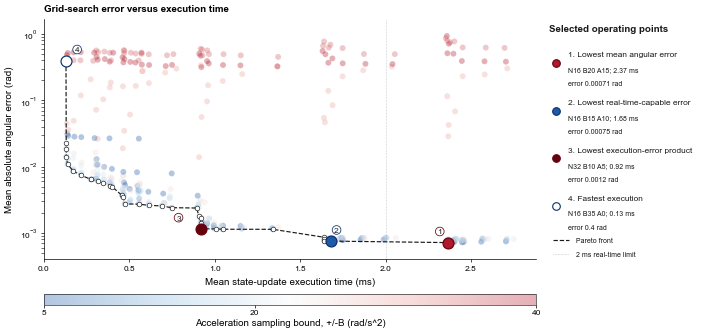

Pareto front contains 34 operating points.
Highlighted angular-error-time operating points:
                        highlight         point_label  sampled_acceleration_vectors  random_uniform_vectors  bound  adam_steps  mean_abs_angle_error_rad  mean_abs_angle_error_joint1_rad  mean_abs_angle_error_joint2_rad  mean_update_ms  mean_solver_call_ms  mean_network_forward_ms  real_time_factor
     1. Lowest mean angular error N=16, B=+/-20, A=15                            16                      14   20.0          15                  0.000712                         0.000771                         0.000653        2.366197             2.253782                 0.541157          0.845238
2. Lowest real-time-capable error N=16, B=+/-15, A=10                            16                      14   15.0          10                  0.000750                         0.000552                         0.000948        1.680996             1.583234                 0.382739          1.189771
3. Lowest e

In [67]:
def pareto_front(df, x_col, y_col):
    ordered = df.sort_values([x_col, y_col])
    best_y = float('inf')
    keep_rows = []
    for _, row in ordered.iterrows():
        if row[y_col] <= best_y:
            keep_rows.append(row)
            best_y = row[y_col]
    return pd.DataFrame(keep_rows)


def compact_config_label(row):
    return f"N{int(row['candidate_count'])} B{row['bound']:g} A{int(row['adam_steps'])}"
plot_df = df_sweep.copy()
pareto_df = pareto_front(plot_df, 'mean_update_ms', 'mean_abs_angle_error_rad')
fastest_row = plot_df.loc[plot_df['mean_update_ms'].idxmin()]
best_accuracy_row = plot_df.loc[plot_df['mean_abs_angle_error_rad'].idxmin()]
realtime_df = plot_df[plot_df['runs_faster_than_real_time']]
best_realtime_accuracy_row = realtime_df.loc[realtime_df['mean_abs_angle_error_rad'].idxmin()]
best_speed_error_row = plot_df.loc[plot_df['time_angle_error_product'].idxmin()]

viridis_purple = '#440154'
viridis_indigo = '#3E4989'
viridis_teal = '#1F9E89'
viridis_green = '#35B779'
viridis_lime = '#B4DE2C'
neutral_dark = '#1A1A1A'
neutral_mid = '#6E6E6E'

mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

solver_palette = [
    '#440154', '#482878', '#3E4989', '#31688E', '#26828E',
    '#1F9E89', '#35B779', '#6DCD59', '#B4DE2C'
]
bound_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'bound_viridis',
    solver_palette,
    N=256,
)
bound_norm = mpl.colors.Normalize(
    vmin=min(GRID_UNIFORM_BOUNDS),
    vmax=max(GRID_UNIFORM_BOUNDS),
)

fig = plt.figure(figsize=(double_col, double_col * 0.46), constrained_layout=True)
grid = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1.0, 0.045],
    width_ratios=[1.0, 0.34],
)
ax = fig.add_subplot(grid[0, 0])
key_ax = fig.add_subplot(grid[0, 1])
cax = fig.add_subplot(grid[1, 0])

background = ax.scatter(
    plot_df['mean_update_ms'],
    plot_df['mean_abs_angle_error_rad'],
    c=plot_df['bound'],
    cmap=bound_cmap,
    norm=bound_norm,
    s=18.0,
    alpha=0.34,
    edgecolors='none',
    zorder=1,
)

ax.plot(
    pareto_df['mean_update_ms'],
    pareto_df['mean_abs_angle_error_rad'],
    color=neutral_dark,
    linewidth=0.85,
    linestyle='--',
    zorder=3,
)
ax.scatter(
    pareto_df['mean_update_ms'],
    pareto_df['mean_abs_angle_error_rad'],
    s=11,
    facecolors='white',
    edgecolors=neutral_dark,
    linewidths=0.45,
    zorder=4,
)

if 'REALTIME_STEP_MS' in globals():
    ax.axvline(
        REALTIME_STEP_MS,
        color=neutral_mid,
        linewidth=0.4,
        linestyle=':',
        alpha=0.65,
        zorder=2,
    )

highlight_specs = [
    ('1', 'Lowest mean angular error', best_accuracy_row, viridis_lime, neutral_dark),
    ('2', 'Lowest real-time-capable error', best_realtime_accuracy_row, viridis_teal, neutral_dark),
    ('3', 'Lowest execution-error product', best_speed_error_row, viridis_indigo, neutral_dark),
    ('4', 'Fastest execution', fastest_row, 'white', neutral_dark),
]
label_offsets = {
    '1': (-6, 8),
    '2': (4, 8),
    '3': (-16, 8),
    '4': (8, 8),
}

seen_labels = set()
for label_number, tag, row, facecolor, edgecolor in highlight_specs:
    if row['label'] in seen_labels:
        continue
    seen_labels.add(row['label'])
    ax.scatter(
        row['mean_update_ms'],
        row['mean_abs_angle_error_rad'],
        marker='o',
        facecolors=facecolor,
        edgecolors=edgecolor,
        linewidths=0.85,
        s=62.0,
        zorder=6,
    )
    ax.annotate(
        label_number,
        (row['mean_update_ms'], row['mean_abs_angle_error_rad']),
        textcoords='offset points',
        xytext=label_offsets[label_number],
        ha='center',
        va='center',
        fontsize=6,
        color=neutral_dark,
        bbox={
            'boxstyle': 'circle,pad=0.16',
            'facecolor': 'white',
            'edgecolor': edgecolor,
            'linewidth': 0.55,
        },
        zorder=7,
    )

ax.set_xlabel('Mean state-update execution time (ms)')
ax.set_ylabel('Mean absolute angular error (rad)')
ax.set_title('Grid-search error versus execution time', loc='left', fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(left=0.0)
ax.margins(x=0.03, y=0.08)
ax.tick_params(axis='both', direction='out', length=2.5, width=0.5, pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

colorbar = fig.colorbar(background, cax=cax, orientation='horizontal')
colorbar.set_label('Acceleration sampling bound, +/-B (rad/s^2)', labelpad=2)
colorbar.set_ticks([min(GRID_UNIFORM_BOUNDS), 20, max(GRID_UNIFORM_BOUNDS)])
colorbar.ax.tick_params(direction='out', length=2.0, width=0.5, pad=1)
colorbar.outline.set_linewidth(0.4)

key_ax.set_xlim(0, 1)
key_ax.set_ylim(0, 1)
key_ax.axis('off')
key_ax.text(
    0.0,
    0.98,
    'Selected operating points',
    transform=key_ax.transAxes,
    ha='left',
    va='top',
    fontsize=7,
    fontweight='bold',
    color=neutral_dark,
)

key_y = [0.82, 0.62, 0.42, 0.22]
for y_pos, (label_number, tag, row, facecolor, edgecolor) in zip(key_y, highlight_specs):
    key_ax.scatter(
        0.04,
        y_pos,
        marker='o',
        s=30,
        facecolors=facecolor,
        edgecolors=edgecolor,
        linewidths=0.8,
        transform=key_ax.transAxes,
        clip_on=False,
    )
    key_ax.text(
        0.11,
        y_pos + 0.035,
        f'{label_number}. {tag}',
        transform=key_ax.transAxes,
        ha='left',
        va='center',
        fontsize=6,
        color=neutral_dark,
    )
    key_ax.text(
        0.11,
        y_pos - 0.03,
        f"{compact_config_label(row)}; {row['mean_update_ms']:.2f} ms",
        transform=key_ax.transAxes,
        ha='left',
        va='center',
        fontsize=5,
        color=neutral_dark,
    )
    key_ax.text(
        0.11,
        y_pos - 0.085,
        f"error {row['mean_abs_angle_error_rad']:.2g} rad",
        transform=key_ax.transAxes,
        ha='left',
        va='center',
        fontsize=5,
        color=neutral_dark,
    )

key_ax.plot([0.02, 0.12], [0.08, 0.08], color=neutral_dark, linewidth=0.85, linestyle='--', transform=key_ax.transAxes)
key_ax.text(0.16, 0.08, 'Pareto front', transform=key_ax.transAxes, ha='left', va='center', fontsize=5, color=neutral_dark)
if 'REALTIME_STEP_MS' in globals():
    key_ax.plot([0.02, 0.12], [0.02, 0.02], color=neutral_mid, linewidth=0.4, linestyle=':', alpha=0.65, transform=key_ax.transAxes)
    key_ax.text(0.16, 0.02, f'{REALTIME_STEP_MS:g} ms real-time limit', transform=key_ax.transAxes, ha='left', va='center', fontsize=5, color=neutral_dark)

save_svg = os.path.join(BASE_PATH, 'optimizer_grid_search_angle_mae_time.svg')
save_pdf = os.path.join(BASE_PATH, 'optimizer_grid_search_angle_mae_time.pdf')
save_png = os.path.join(BASE_PATH, 'optimizer_grid_search_angle_mae_time.png')
fig.savefig(save_svg, format='svg', bbox_inches='tight', pad_inches=0.03)
fig.savefig(save_pdf, bbox_inches='tight', pad_inches=0.03)
fig.savefig(save_png, dpi=600, bbox_inches='tight', pad_inches=0.03)
print(f"Saved angular-error-time grid plot to {save_svg}")
print(f"Saved angular-error-time grid plot to {save_pdf}")
print(f"Saved angular-error-time grid plot to {save_png}")
plt.show()

highlight_rows = []
for label_number, tag, row, *_ in highlight_specs:
    row_with_tag = row.copy()
    row_with_tag['highlight'] = f'{label_number}. {tag}'
    highlight_rows.append(row_with_tag)
highlight_table = pd.DataFrame(highlight_rows).drop_duplicates(subset=['label'])
print(f"Pareto front contains {len(pareto_df)} operating points.")
print('Highlighted angular-error-time operating points:')
print(highlight_table[[
    'highlight', 'point_label', 'sampled_acceleration_vectors', 'random_uniform_vectors',
    'bound', 'adam_steps', 'mean_abs_angle_error_rad',
    'mean_abs_angle_error_joint1_rad', 'mean_abs_angle_error_joint2_rad',
    'mean_update_ms', 'mean_solver_call_ms', 'mean_network_forward_ms', 'real_time_factor'
]].to_string(index=False))


# Section 10: Hardware description

In this brief section, we record the system configuration for reproducibility.

In [68]:
# Hardware and software used to run this notebook
import platform
import scipy
import statsmodels

print(f"Platform:          {platform.platform()}")
print(f"Machine:           {platform.machine()}")
print(f"Processor:         {platform.processor() or 'not reported'}")
print(f"Logical CPU cores: {psutil.cpu_count(logical=True)}")
print(f"System RAM:        {psutil.virtual_memory().total / 1024**3:.1f} GB")
print(f"Compute device:    {device}")
if device.type == 'cuda':
    print(f"GPU:               {torch.cuda.get_device_name(0)} (CUDA {torch.version.cuda})")

print(f"Python:            {platform.python_version()}")
print(f"PyTorch:           {torch.__version__}")
print(f"NumPy:             {np.__version__}")
print(f"SciPy:             {scipy.__version__}")
print(f"statsmodels:       {statsmodels.__version__}")
print(f"SymPy:             {sp.__version__}")
print(f"pandas:            {pd.__version__}")
print(f"Matplotlib:        {mpl.__version__}")

Platform:          macOS-27.0-arm64-arm-64bit-Mach-O
Machine:           arm64
Processor:         arm
Logical CPU cores: 10
System RAM:        32.0 GB
Compute device:    cpu
Python:            3.13.11
PyTorch:           2.11.0
NumPy:             2.3.5
SciPy:             1.16.3
statsmodels:       0.14.6
SymPy:             1.14.0
pandas:            2.3.3
Matplotlib:        3.10.8


# Section 11: Robustness of the inverse dynamics to measurement noise

The simulations of the preceding sections contain no measurement noise, whereas measured kinematics do. This section measures how noise on the inputs of the inverse model affects its torque predictions. Zero-mean Gaussian noise is added independently to each of the six inputs $(q_1, q_2, \dot{q}_1, \dot{q}_2, \ddot{q}_1, \ddot{q}_2)$ at every time point of the fixed test set of Section 4 (50 trajectories, 5 s, 0.1 ms step). Its standard deviation is 1, 2.5, 5, 10 or 25% of the standard deviation of that input over the trajectory. The 16,000-sample ANNet used for all downstream analyses then predicts the torques from the noisy inputs exactly as in Section 4, and the trajectory-wise RMSE is computed against the noise-free torques.

The same noisy inputs are also passed through the analytical inverse dynamics. Its error is the error that an exact model incurs from the noise alone, so the difference between the two is the part that the learned energy adds. A secondary analysis applies the noise to one group of inputs at a time (angles, velocities or accelerations) to identify which measurement the torque error comes from, and tests each condition against the noise-free errors. A third analysis establishes the law by which the error grows with the noise. It compares the measured errors with the first-order propagation of the input noise through the inverse dynamics, which predicts an error proportional to the noise level with a gain set by the sensitivity of the torques to their inputs. A fourth analysis low-pass filters the noisy inputs before they enter the models, as is done with measured kinematics, and measures the error that remains at each cutoff frequency. The torques of one example trajectory are stored over time for illustration. The result is exported as Fig. 7 together with its data package.

The section requires the library import cell and the definition cells of Sections 1 to 3 and reads the cached files `test_set_50_traj_5s.pt`, `model_16000.pth`, `stats_16000.pt` and `results_model_16000.pt`. Each of the two evaluations (noise, and noise followed by filtering) is skipped when its output file already exists and was produced from the current model, statistics, test set and settings.

### Constants

In [69]:
# Noise robustness of the inverse dynamics: dependencies, constants and file paths.

_nse_required_names = [
    # imports (Libraries import cell)
    'os', 'np', 'pd', 'torch', 'autograd', 'scipy_stats', 'multipletests', 'mpl', 'plt', 'Line2D',
    # analytical kernels and numeric helpers (Section 1)
    'as_f32_tensor', 'compute_tau_ground_truth_eager',
    # physical parameters and device (Section 2)
    'PARAMS', 'device',
    # network architecture (Section 3)
    'NUM_NODE_L1', 'NUM_NODE_L2', 'NUM_NODE_L3', 'NUM_NODE_L4', 'GibbsAppellNet',
]
_nse_missing_names = [name for name in _nse_required_names if name not in globals()]
if _nse_missing_names:
    raise RuntimeError(
        "Run the definition cells of Sections 1-3 first (library imports, analytical kernels, "
        f"physical parameters, device and network architecture). Missing names: {_nse_missing_names}"
    )

# Training-set size of the ANNet used for all downstream analyses
NSE_N_SAMPLES = 16000

# Noise levels: standard deviation of the added Gaussian noise as a fraction of the
# standard deviation of each input over the trajectory (1, 2.5, 5, 10 and 25%)
NSE_NOISE_LEVELS = (0.01, 0.025, 0.05, 0.10, 0.25)

# Inputs that receive the noise: all six (main analysis) or one group at a time (secondary analysis).
# Column order of the test set: [q1, q2, dq1, dq2, ddq1, ddq2]
NSE_INPUT_GROUPS = {
    'all': [0, 1, 2, 3, 4, 5],
    'angle': [0, 1],
    'velocity': [2, 3],
    'acceleration': [4, 5],
}

# Seed of the noise; trajectory i uses the generator seeded with NSE_SEED + i
NSE_SEED = 31

# Low-pass filtering of the noisy inputs: zero-phase Butterworth filter (forward and backward passes of the
# stated order), cutoff frequencies given as the -3 dB point of the two passes, mirror extension at both ends
# over the stated number of cutoff periods
NSE_FILTER_ORDER = 2
NSE_FILTER_CUTOFFS_HZ = (1, 2, 5, 10, 20, 50, 100, 200, 500, 1000)
NSE_FILTER_PAD_CYCLES = 3

# Noise level of the example trajectory and of the single-level panels of Fig. 7
NSE_FIGURE_NOISE_LEVEL = 0.05

# Input files (produced in Sections 3 and 4) and output files of this section
NSE_BASE_PATH = output_dir if 'output_dir' in globals() else '.'
NSE_MODEL_PATH         = os.path.join(NSE_BASE_PATH, f"model_{NSE_N_SAMPLES}.pth")
NSE_STATS_PATH         = os.path.join(NSE_BASE_PATH, f"stats_{NSE_N_SAMPLES}.pt")
NSE_TEST_SET_PATH      = os.path.join(NSE_BASE_PATH, "test_set_50_traj_5s.pt")
NSE_CLEAN_RESULTS_PATH = os.path.join(NSE_BASE_PATH, f"results_model_{NSE_N_SAMPLES}.pt")
NSE_TEST_STEP_KEY      = "0.0001"   # key of the results dictionary in results_model_*.pt
NSE_RESULTS_PATH       = os.path.join(NSE_BASE_PATH, f"noise_robustness_results_model_{NSE_N_SAMPLES}.pt")
NSE_RMSE_CSV_PATH      = os.path.join(NSE_BASE_PATH, f"noise_robustness_torque_rmse_model_{NSE_N_SAMPLES}.csv")
NSE_STATS_CSV_PATH     = os.path.join(NSE_BASE_PATH, f"noise_robustness_statistics_model_{NSE_N_SAMPLES}.csv")
NSE_SCALING_CSV_PATH   = os.path.join(NSE_BASE_PATH, f"noise_robustness_scaling_model_{NSE_N_SAMPLES}.csv")
NSE_GROUP_STATS_CSV_PATH = os.path.join(NSE_BASE_PATH, f"noise_robustness_input_group_statistics_model_{NSE_N_SAMPLES}.csv")
NSE_FILTER_RESULTS_PATH   = os.path.join(NSE_BASE_PATH, f"noise_robustness_filter_results_model_{NSE_N_SAMPLES}.pt")
NSE_FILTER_CSV_PATH       = os.path.join(NSE_BASE_PATH, f"noise_robustness_filter_rmse_model_{NSE_N_SAMPLES}.csv")
NSE_FILTER_STATS_CSV_PATH = os.path.join(NSE_BASE_PATH, f"noise_robustness_filter_statistics_model_{NSE_N_SAMPLES}.csv")
NSE_TRACES_CSV_PATH       = os.path.join(NSE_BASE_PATH, f"noise_robustness_example_traces_model_{NSE_N_SAMPLES}.csv")
NSE_SAMPLING_RATE_HZ      = 1.0 / float(NSE_TEST_STEP_KEY)   # sampling rate of the test trajectories

# Destinations of the figure and its data package (SUBMISSION tree).
# The notebook is expected to run from SIMULATIONS/; if the tree is not found,
# the files are written next to the notebook instead.
NSE_FIGURE_NAME = 'FIG7'
_nse_repo_root = os.path.normpath(os.path.join(NSE_BASE_PATH, os.pardir))
NSE_FIGURE_DIR  = os.path.join(_nse_repo_root, 'SUBMISSION', 'FIGURES', 'PDF AND PNG')
NSE_PACKAGE_DIR = os.path.join(_nse_repo_root, 'SUBMISSION', 'FIGURES', 'DATA AND SCRIPTS')
for _nse_dir_name in ('NSE_FIGURE_DIR', 'NSE_PACKAGE_DIR'):
    if not os.path.isdir(globals()[_nse_dir_name]):
        print(f"Warning: {globals()[_nse_dir_name]} not found; {_nse_dir_name} falls back to '{NSE_BASE_PATH}'.")
        globals()[_nse_dir_name] = NSE_BASE_PATH

print(f"ANNet model:            {NSE_MODEL_PATH}")
print(f"Fixed test set:         {NSE_TEST_SET_PATH}")
print(f"Noise levels (% s.d.):  {[100 * level for level in NSE_NOISE_LEVELS]}")
print(f"Noise results:          {NSE_RESULTS_PATH}")
print(f"Filter cutoffs (Hz):    {list(NSE_FILTER_CUTOFFS_HZ)} at a sampling rate of {NSE_SAMPLING_RATE_HZ:g} Hz")
print(f"Filter results:         {NSE_FILTER_RESULTS_PATH}")
print(f"Figure directory:       {NSE_FIGURE_DIR}")
print(f"Data package directory: {NSE_PACKAGE_DIR}")

ANNet model:            ./model_16000.pth
Fixed test set:         ./test_set_50_traj_5s.pt
Noise levels (% s.d.):  [1.0, 2.5, 5.0, 10.0, 25.0]
Noise results:          ./noise_robustness_results_model_16000.pt
Filter cutoffs (Hz):    [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000] at a sampling rate of 10000 Hz
Filter results:         ./noise_robustness_filter_results_model_16000.pt
Figure directory:       ../SUBMISSION/FIGURES/PDF AND PNG
Data package directory: ../SUBMISSION/FIGURES/DATA AND SCRIPTS


### Noise model and evaluation

For each test trajectory, one draw of independent standard-normal values is made for all six inputs and all time points. A noisy input is the clean input plus this draw multiplied by the noise level and by the standard deviation of that input over the trajectory. The same draw is reused for every noise level and input group, so that the conditions differ only in the scale of the noise and in the inputs that receive it. ANNet predicts the torques from the noisy inputs with the computation of Section 4 (gradient of the standardized energy with respect to the standardized accelerations, rescaled to Nm), and the analytical inverse dynamics is the kernel that generated the ground-truth torques. Both are scored against the noise-free torques of the same trajectory. The noise-free ANNet errors are checked against those saved in Section 4.

In [70]:
import hashlib


def nse_sha256_of_file(path, chunk_size=1 << 20):
    digest = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


def nse_current_provenance():
    """Hashes of the input files and the noise settings; cached results are reused only if all of them match."""
    return {
        'model_sha256': nse_sha256_of_file(NSE_MODEL_PATH),
        'stats_sha256': nse_sha256_of_file(NSE_STATS_PATH),
        'test_set_sha256': nse_sha256_of_file(NSE_TEST_SET_PATH),
        'noise_levels': [float(level) for level in NSE_NOISE_LEVELS],
        'input_groups': {name: [int(column) for column in columns] for name, columns in NSE_INPUT_GROUPS.items()},
        'seed': int(NSE_SEED),
    }


def nse_load_annet():
    """Trained ANNet with its input standardization and the factor that rescales its gradient to Nm."""
    model_stats = torch.load(NSE_STATS_PATH, map_location=device)
    stats_mean  = model_stats['X_mean'].to(device=device, dtype=torch.float32)
    stats_X_std = model_stats['X_std'].to(device=device, dtype=torch.float32)
    stats_S_std = model_stats['S_std'].to(device=device, dtype=torch.float32)
    inv_X_std   = 1.0 / (stats_X_std + 1e-8)
    torque_scale = stats_S_std / (stats_X_std[4:6] + 1e-8)

    model = GibbsAppellNet().to(device)
    model.load_state_dict(torch.load(NSE_MODEL_PATH, map_location=device))
    model.eval()
    for param in model.parameters():
        param.requires_grad_(False)
    return model, stats_mean, inv_X_std, torque_scale


def nse_make_annet_predictor():
    """Torque prediction of the trained ANNet, computed as in the evaluation loop of Section 4."""
    model, stats_mean, inv_X_std, torque_scale = nse_load_annet()

    def predict(inputs):
        input_norm = (inputs - stats_mean) * inv_X_std
        input_norm.requires_grad_(True)
        s_pred_norm = model(input_norm)
        grads = autograd.grad(outputs=s_pred_norm.sum(), inputs=input_norm, create_graph=False)[0]
        return (grads[:, 4:6] * torque_scale).detach()

    return predict


def nse_analytical_torques(inputs):
    """Analytical inverse dynamics (the kernel that generated the ground-truth torques) applied to the given inputs."""
    m1_t = as_f32_tensor(PARAMS['m1'], device=device)
    m2_t = as_f32_tensor(PARAMS['m2'], device=device)
    l1_t = as_f32_tensor(PARAMS['l1'], device=device)
    l2_t = as_f32_tensor(PARAMS['l2'], device=device)
    tau1, tau2 = compute_tau_ground_truth_eager(
        inputs[:, 0], inputs[:, 1], inputs[:, 2], inputs[:, 3], inputs[:, 4], inputs[:, 5],
        m1_t, m2_t, l1_t, l2_t,
    )
    return torch.stack((tau1, tau2), dim=1)


def nse_evaluate_noise_robustness():
    """
    Trajectory-wise torque RMSE of ANNet and of the analytical inverse dynamics when both receive
    the same noisy inputs, for every noise level and input group, against the noise-free torques.
    """
    cached_data = torch.load(NSE_TEST_SET_PATH, map_location='cpu')
    inputs = cached_data['inputs'].to(dtype=torch.float32)
    targets = cached_data['targets'].to(dtype=torch.float32)
    num_trajectories, _, num_inputs = inputs.shape
    predict_annet = nse_make_annet_predictor()

    records = []
    for trajectory_idx in range(num_trajectories):
        if (trajectory_idx + 1) % 10 == 0:
            print(f"Evaluating Trajectory {trajectory_idx + 1}/{num_trajectories}")

        clean_inputs = inputs[trajectory_idx]
        true_torques = targets[trajectory_idx].to(device)
        signal_sd = clean_inputs.std(dim=0)             # s.d. of each input over this trajectory
        torque_sd = targets[trajectory_idx].std(dim=0)  # s.d. of each noise-free torque over this trajectory

        # One standard-normal draw per trajectory, reused for every noise level and input group
        generator = torch.Generator().manual_seed(NSE_SEED + trajectory_idx)
        unit_noise = torch.randn(clean_inputs.shape, generator=generator, dtype=torch.float32)

        def add_records(model_name, noise_target, level, predicted_torques):
            rmse = torch.sqrt(torch.mean((predicted_torques - true_torques) ** 2, dim=0)).cpu()
            for joint_idx, joint in enumerate(('J1', 'J2')):
                records.append({
                    'model': model_name,
                    'noise_target': noise_target,
                    'noise_percent': float(100.0 * level),
                    'joint': joint,
                    'trajectory': int(trajectory_idx),
                    'rmse_nm': float(rmse[joint_idx]),
                    'torque_sd_nm': float(torque_sd[joint_idx]),
                })

        # Noise-free reference (the analytical model is exact without noise and is not listed)
        add_records('ANNet', 'none', 0.0, predict_annet(clean_inputs.to(device)))

        for noise_target, columns in NSE_INPUT_GROUPS.items():
            mask = torch.zeros(num_inputs, dtype=torch.float32)
            mask[columns] = 1.0
            for level in NSE_NOISE_LEVELS:
                noisy_inputs = (clean_inputs + level * signal_sd * mask * unit_noise).to(device)
                add_records('ANNet', noise_target, level, predict_annet(noisy_inputs))
                add_records('analytical', noise_target, level, nse_analytical_torques(noisy_inputs))

    return records


def nse_load_cached_results():
    """Returns the cached results only if they were computed from the current input files and noise settings."""
    if not os.path.exists(NSE_RESULTS_PATH):
        return None
    cached = torch.load(NSE_RESULTS_PATH, map_location='cpu')
    if cached.get('provenance') == nse_current_provenance():
        return cached
    print(f"Existing results '{NSE_RESULTS_PATH}' were computed from different input files or noise settings; re-evaluating.")
    return None


nse_results = nse_load_cached_results()
if nse_results is not None:
    print(f"Found existing results: '{NSE_RESULTS_PATH}' (matching the current inputs and settings) -- loading instead of re-evaluating.")
else:
    print("Evaluating ANNet and the analytical inverse dynamics on noisy inputs...")
    nse_results = {
        'records': nse_evaluate_noise_robustness(),
        'provenance': nse_current_provenance(),
        'model_file': os.path.basename(NSE_MODEL_PATH),
        'stats_file': os.path.basename(NSE_STATS_PATH),
        'test_set_file': os.path.basename(NSE_TEST_SET_PATH),
    }
    torch.save(nse_results, NSE_RESULTS_PATH)
    print(f"Saved results to '{NSE_RESULTS_PATH}'.")

# Long-form table of trajectory-wise torque RMSEs
nse_rmse_df = pd.DataFrame(nse_results['records'])

# The noise-free ANNet errors must equal those of Section 4
nse_clean_reference = torch.load(NSE_CLEAN_RESULTS_PATH, map_location='cpu')[NSE_TEST_STEP_KEY]
for _nse_joint, _nse_key in (('J1', 'rmse_j1'), ('J2', 'rmse_j2')):
    _nse_clean = nse_rmse_df[(nse_rmse_df['noise_target'] == 'none') & (nse_rmse_df['joint'] == _nse_joint)]
    _nse_clean = _nse_clean.sort_values('trajectory')['rmse_nm'].to_numpy(dtype=float)
    if not np.allclose(_nse_clean, np.asarray(nse_clean_reference[_nse_key], dtype=float), rtol=1e-5, atol=1e-7):
        raise RuntimeError("The noise-free ANNet errors differ from those saved in Section 4.")
print("Verified: the noise-free ANNet errors equal those of Section 4 (results_model_16000.pt).")

nse_rmse_df.to_csv(NSE_RMSE_CSV_PATH, index=False)
print(f"RMSE table ({len(nse_rmse_df)} rows) saved to '{NSE_RMSE_CSV_PATH}'.")


def nse_print_descriptives(rmse_df):
    print("\n--- Median trajectory-wise torque RMSE (Nm), noise on all inputs ---")
    print(f"{'Noise (%)':<10} | {'Joint':<5} | {'ANNet':<8} | {'Analytical':<10} | {'ANNet, % of torque s.d.'}")
    print('-' * 70)
    for percent in [0.0] + [100.0 * level for level in NSE_NOISE_LEVELS]:
        for joint in ('J1', 'J2'):
            rows = rmse_df[(rmse_df['joint'] == joint) & (rmse_df['noise_percent'] == percent)
                           & (rmse_df['noise_target'].isin(['none', 'all']))]
            annet = rows[rows['model'] == 'ANNet']
            analytical = rows[rows['model'] == 'analytical']
            analytical_text = f"{analytical['rmse_nm'].median():.4f}" if len(analytical) else 'exact'
            relative = float((100.0 * annet['rmse_nm'] / annet['torque_sd_nm']).median())
            print(f"{percent:<10g} | {joint:<5} | {annet['rmse_nm'].median():<8.4f} | {analytical_text:<10} | {relative:.2f}")
    print('-' * 70)


nse_print_descriptives(nse_rmse_df)

Evaluating ANNet and the analytical inverse dynamics on noisy inputs...


Evaluating Trajectory 10/50


Evaluating Trajectory 20/50


Evaluating Trajectory 30/50


Evaluating Trajectory 40/50


Evaluating Trajectory 50/50


Saved results to './noise_robustness_results_model_16000.pt'.
Verified: the noise-free ANNet errors equal those of Section 4 (results_model_16000.pt).
RMSE table (4100 rows) saved to './noise_robustness_torque_rmse_model_16000.csv'.

--- Median trajectory-wise torque RMSE (Nm), noise on all inputs ---
Noise (%)  | Joint | ANNet    | Analytical | ANNet, % of torque s.d.
----------------------------------------------------------------------
0          | J1    | 0.0242   | exact      | 0.39
0          | J2    | 0.0234   | exact      | 0.60
1          | J1    | 0.2816   | 0.2805     | 2.82
1          | J2    | 0.1288   | 0.1270     | 3.88
2.5        | J1    | 0.7020   | 0.7012     | 7.03
2.5        | J2    | 0.3185   | 0.3176     | 8.40
5          | J1    | 1.4033   | 1.4023     | 14.05
5          | J2    | 0.6359   | 0.6352     | 16.05
10         | J1    | 2.8058   | 2.8042     | 28.09
10         | J2    | 1.2712   | 1.2704     | 31.24
25         | J1    | 7.0064   | 7.0038     | 70.14
25

### Statistical comparison

For each joint and noise level, the trajectory-wise errors of ANNet and of the analytical inverse dynamics are compared with the rule used in the rest of the notebook: Shapiro-Wilk normality of each group, one-way ANOVA if both are normal and the Kruskal-Wallis H-test otherwise, and Benjamini-Hochberg correction across the ten comparisons (two joints by five noise levels). Because both models receive the same noisy inputs, the paired Wilcoxon signed-rank test is reported as well, together with the ratio of medians, Cliff's delta and the number of trajectories on which ANNet has the larger error. Three further quantities describe the size of the effect: the ANNet error as a percentage of the standard deviation of the noise-free torque, the error that ANNet adds to that of the analytical model (root of the difference of the squared errors), and the ANNet error when the noise is applied to one group of inputs only.

In [71]:
NSE_ALPHA = 0.05


def nse_cliffs_delta(values_a, values_b):
    """Cliff's delta = P(a > b) - P(a < b) over all pairs; positive when `values_a` tends to be larger."""
    a = np.asarray(values_a, dtype=float)[:, None]
    b = np.asarray(values_b, dtype=float)[None, :]
    return float(np.mean(np.sign(a - b)))


def nse_select(rmse_df, model_name, noise_target, percent, joint, column='rmse_nm'):
    mask = ((rmse_df['model'] == model_name) & (rmse_df['noise_target'] == noise_target)
            & (rmse_df['noise_percent'] == percent) & (rmse_df['joint'] == joint))
    return rmse_df.loc[mask].sort_values('trajectory')[column].to_numpy(dtype=float)


def nse_compute_statistics(rmse_df, alpha=NSE_ALPHA):
    rows = []
    for joint in ('J1', 'J2'):
        clean_annet = nse_select(rmse_df, 'ANNet', 'none', 0.0, joint)
        torque_sd = nse_select(rmse_df, 'ANNet', 'none', 0.0, joint, column='torque_sd_nm')
        for level in NSE_NOISE_LEVELS:
            percent = float(100.0 * level)
            annet = nse_select(rmse_df, 'ANNet', 'all', percent, joint)
            analytical = nse_select(rmse_df, 'analytical', 'all', percent, joint)

            shapiro_annet = scipy_stats.shapiro(annet)
            shapiro_analytical = scipy_stats.shapiro(analytical)
            both_normal = (shapiro_annet.pvalue > alpha) and (shapiro_analytical.pvalue > alpha)
            if both_normal:
                test_name = 'One-way ANOVA'
                primary = scipy_stats.f_oneway(annet, analytical)
            else:
                test_name = 'Kruskal-Wallis H-test'
                primary = scipy_stats.kruskal(annet, analytical)
            mann_whitney = scipy_stats.mannwhitneyu(annet, analytical, alternative='two-sided')
            wilcoxon = scipy_stats.wilcoxon(annet, analytical, alternative='two-sided')

            annet_q1, annet_median, annet_q3 = np.percentile(annet, [25, 50, 75])
            analytical_q1, analytical_median, analytical_q3 = np.percentile(analytical, [25, 50, 75])
            added_by_annet = np.sqrt(np.clip(annet ** 2 - analytical ** 2, 0.0, None))

            rows.append({
                'joint': joint,
                'joint_label': f"Joint {joint[1]}",
                'noise_percent': percent,
                'n_trajectories': int(annet.size),
                'shapiro_p_annet': float(shapiro_annet.pvalue),
                'shapiro_p_analytical': float(shapiro_analytical.pvalue),
                'both_normal': bool(both_normal),
                'test_name': test_name,
                'statistic': float(primary.statistic),
                'p_value': float(primary.pvalue),
                'mann_whitney_u_annet_vs_analytical': float(mann_whitney.statistic),
                'mann_whitney_p_two_sided': float(mann_whitney.pvalue),
                'wilcoxon_paired_statistic': float(wilcoxon.statistic),
                'wilcoxon_paired_p_two_sided': float(wilcoxon.pvalue),
                'median_annet_nm': float(annet_median),
                'iqr_annet_nm': float(annet_q3 - annet_q1),
                'median_analytical_nm': float(analytical_median),
                'iqr_analytical_nm': float(analytical_q3 - analytical_q1),
                'median_ratio_annet_over_analytical': float(annet_median / analytical_median),
                'cliffs_delta_annet_vs_analytical': nse_cliffs_delta(annet, analytical),
                'n_annet_higher': int((annet > analytical).sum()),
                'median_clean_annet_nm': float(np.median(clean_annet)),
                'median_ratio_noisy_over_clean_annet': float(annet_median / np.median(clean_annet)),
                'median_annet_percent_of_torque_sd': float(np.median(100.0 * annet / torque_sd)),
                'median_added_by_annet_nm': float(np.median(added_by_annet)),
                'median_annet_angle_noise_only_nm': float(np.median(nse_select(rmse_df, 'ANNet', 'angle', percent, joint))),
                'median_annet_velocity_noise_only_nm': float(np.median(nse_select(rmse_df, 'ANNet', 'velocity', percent, joint))),
                'median_annet_acceleration_noise_only_nm': float(np.median(nse_select(rmse_df, 'ANNet', 'acceleration', percent, joint))),
            })

    stats_df = pd.DataFrame(rows)
    # Benjamini-Hochberg correction of the primary p-values across the ten joint-by-level comparisons
    stats_df['fdr_q_value'] = multipletests(stats_df['p_value'].to_numpy(), method='fdr_bh')[1]
    stats_df['significant_fdr_0_05'] = stats_df['fdr_q_value'] < alpha
    leading = ['joint', 'joint_label', 'noise_percent', 'n_trajectories', 'shapiro_p_annet', 'shapiro_p_analytical',
               'both_normal', 'test_name', 'statistic', 'p_value', 'fdr_q_value', 'significant_fdr_0_05']
    return stats_df[leading + [column for column in stats_df.columns if column not in leading]]


def nse_print_statistics(stats_df, alpha=NSE_ALPHA):
    print(f"{'='*20} ANNet vs analytical inverse dynamics on the same noisy inputs {'='*20}")
    for _, row in stats_df.iterrows():
        verdict = 'significant' if row['significant_fdr_0_05'] else 'not significant'
        print(f"{row['joint_label']}, {row['noise_percent']:g}% noise: {row['test_name']} | statistic = {row['statistic']:.4f} | "
              f"p = {row['p_value']:.3e} | FDR q = {row['fdr_q_value']:.3e} -> {verdict} at alpha = {alpha}")
        print(f"   medians: ANNet {row['median_annet_nm']:.4f} Nm vs analytical {row['median_analytical_nm']:.4f} Nm "
              f"(ratio = {row['median_ratio_annet_over_analytical']:.4f}); ANNet higher in {row['n_annet_higher']} of "
              f"{row['n_trajectories']} trajectories; paired Wilcoxon W = {row['wilcoxon_paired_statistic']:.1f} "
              f"(p = {row['wilcoxon_paired_p_two_sided']:.3e}); Cliff's delta = {row['cliffs_delta_annet_vs_analytical']:+.3f}")
        print(f"   ANNet error = {row['median_annet_percent_of_torque_sd']:.1f}% of the torque s.d., "
              f"{row['median_ratio_noisy_over_clean_annet']:.1f} times the noise-free error; added by ANNet "
              f"{row['median_added_by_annet_nm']:.4f} Nm (noise-free ANNet {row['median_clean_annet_nm']:.4f} Nm)")
        print(f"   noise on one input group only (ANNet): angles {row['median_annet_angle_noise_only_nm']:.4f} Nm, "
              f"velocities {row['median_annet_velocity_noise_only_nm']:.4f} Nm, "
              f"accelerations {row['median_annet_acceleration_noise_only_nm']:.4f} Nm")


nse_stats_df = nse_compute_statistics(nse_rmse_df)
nse_print_statistics(nse_stats_df)

nse_stats_df.to_csv(NSE_STATS_CSV_PATH, index=False)
print(f"\nStatistics table saved to '{NSE_STATS_CSV_PATH}'.")

==================== ANNet vs analytical inverse dynamics on the same noisy inputs ====================
Joint 1, 1% noise: One-way ANOVA | statistic = 0.0118 | p = 9.137e-01 | FDR q = 9.939e-01 -> not significant at alpha = 0.05
   medians: ANNet 0.2816 Nm vs analytical 0.2805 Nm (ratio = 1.0040); ANNet higher in 50 of 50 trajectories; paired Wilcoxon W = 0.0 (p = 1.776e-15); Cliff's delta = +0.029
   ANNet error = 2.8% of the torque s.d., 11.6 times the noise-free error; added by ANNet 0.0270 Nm (noise-free ANNet 0.0242 Nm)
   noise on one input group only (ANNet): angles 0.0271 Nm, velocities 0.0298 Nm, accelerations 0.2809 Nm
Joint 1, 2.5% noise: One-way ANOVA | statistic = 0.0005 | p = 9.818e-01 | FDR q = 9.939e-01 -> not significant at alpha = 0.05
   medians: ANNet 0.7020 Nm vs analytical 0.7012 Nm (ratio = 1.0011); ANNet higher in 47 of 50 trajectories; paired Wilcoxon W = 17.0 (p = 3.677e-13); Cliff's delta = +0.020
   ANNet error = 7.0% of the torque s.d., 29.0 times the noise

### Noise on one group of inputs against no noise

The secondary analysis applies the noise to the angles, the velocities or the accelerations alone. This cell tests whether the ANNet errors under each of these conditions, and under noise on all inputs, differ from the noise-free ANNet errors of the same trajectories, for every joint and noise level. It uses the rule of the previous cell (Shapiro-Wilk normality of each group, one-way ANOVA if both are normal and the Kruskal-Wallis H-test otherwise) with Benjamini-Hochberg correction across the 40 comparisons (two joints by four noise conditions by five noise levels). Because the same trajectories and the same noise draws enter every condition, the paired Wilcoxon signed-rank test is reported as well, together with the ratio of the median error to the noise-free median and the number of trajectories whose error rose.

In [72]:
NSE_NOISE_CONDITIONS = ('angle', 'velocity', 'acceleration', 'all')


def nse_compute_group_statistics(rmse_df, alpha=NSE_ALPHA):
    """
    ANNet errors with noise on one group of inputs, or on all inputs, against the noise-free ANNet errors of the
    same trajectories, for every joint and noise level.
    """
    rows = []
    for joint in ('J1', 'J2'):
        noise_free = nse_select(rmse_df, 'ANNet', 'none', 0.0, joint)
        shapiro_noise_free = scipy_stats.shapiro(noise_free)
        for level in NSE_NOISE_LEVELS:
            percent = float(100.0 * level)
            for noise_target in NSE_NOISE_CONDITIONS:
                noisy = nse_select(rmse_df, 'ANNet', noise_target, percent, joint)
                shapiro_noisy = scipy_stats.shapiro(noisy)
                both_normal = (shapiro_noisy.pvalue > alpha) and (shapiro_noise_free.pvalue > alpha)
                if both_normal:
                    test_name = 'One-way ANOVA'
                    primary = scipy_stats.f_oneway(noisy, noise_free)
                else:
                    test_name = 'Kruskal-Wallis H-test'
                    primary = scipy_stats.kruskal(noisy, noise_free)
                wilcoxon = scipy_stats.wilcoxon(noisy, noise_free, alternative='two-sided')
                rows.append({
                    'joint': joint,
                    'joint_label': f"Joint {joint[1]}",
                    'noise_percent': percent,
                    'noise_target': noise_target,
                    'n_trajectories': int(noisy.size),
                    'shapiro_p_noisy': float(shapiro_noisy.pvalue),
                    'shapiro_p_noise_free': float(shapiro_noise_free.pvalue),
                    'both_normal': bool(both_normal),
                    'test_name': test_name,
                    'statistic': float(primary.statistic),
                    'p_value': float(primary.pvalue),
                    'wilcoxon_paired_statistic': float(wilcoxon.statistic),
                    'wilcoxon_paired_p_two_sided': float(wilcoxon.pvalue),
                    'median_noise_free_annet_nm': float(np.median(noise_free)),
                    'median_annet_nm': float(np.median(noisy)),
                    'median_ratio_noisy_over_noise_free': float(np.median(noisy) / np.median(noise_free)),
                    'cliffs_delta_noisy_vs_noise_free': nse_cliffs_delta(noisy, noise_free),
                    'n_higher_than_noise_free': int((noisy > noise_free).sum()),
                })

    group_stats_df = pd.DataFrame(rows)
    # Benjamini-Hochberg correction of the primary p-values across all joint, condition and level comparisons
    group_stats_df['fdr_q_value'] = multipletests(group_stats_df['p_value'].to_numpy(), method='fdr_bh')[1]
    group_stats_df['significant_fdr_0_05'] = group_stats_df['fdr_q_value'] < alpha
    leading = ['joint', 'joint_label', 'noise_percent', 'noise_target', 'n_trajectories', 'shapiro_p_noisy',
               'shapiro_p_noise_free', 'both_normal', 'test_name', 'statistic', 'p_value', 'fdr_q_value', 'significant_fdr_0_05']
    return group_stats_df[leading + [column for column in group_stats_df.columns if column not in leading]]


def nse_print_group_statistics(group_stats_df, alpha=NSE_ALPHA):
    print(f"{'='*20} ANNet with noise on selected inputs vs ANNet without noise {'='*20}")
    print(f"{'Noise (%)':<10} | {'Joint':<5} | {'Noise on':<12} | {'Median (Nm)':<11} | {'x noise-free':<12} | {'Test':<21} | "
          f"{'p':<9} | {'FDR q':<9} | {'Verdict':<15} | {'Wilcoxon p':<10} | Higher in")
    print('-' * 150)
    for _, row in group_stats_df.sort_values(['noise_percent', 'joint']).iterrows():
        verdict = 'significant' if row['significant_fdr_0_05'] else 'not significant'
        print(f"{row['noise_percent']:<10g} | {row['joint']:<5} | {row['noise_target']:<12} | {row['median_annet_nm']:<11.4f} | "
              f"{row['median_ratio_noisy_over_noise_free']:<12.2f} | {row['test_name']:<21} | {row['p_value']:<9.2e} | "
              f"{row['fdr_q_value']:<9.2e} | {verdict:<15} | {row['wilcoxon_paired_p_two_sided']:<10.2e} | "
              f"{row['n_higher_than_noise_free']}/{row['n_trajectories']}")
    print('-' * 150)
    print(f"{int(group_stats_df['significant_fdr_0_05'].sum())} of {len(group_stats_df)} comparisons are significant at alpha = {alpha} "
          f"after Benjamini-Hochberg correction; noise-free ANNet medians: "
          + ", ".join(f"{joint} {value:.4f} Nm" for joint, value in
                      group_stats_df.groupby('joint')['median_noise_free_annet_nm'].first().items()))


nse_group_stats_df = nse_compute_group_statistics(nse_rmse_df)
nse_print_group_statistics(nse_group_stats_df)

nse_group_stats_df.to_csv(NSE_GROUP_STATS_CSV_PATH, index=False)
print(f"\nStatistics table saved to '{NSE_GROUP_STATS_CSV_PATH}'.")

==================== ANNet with noise on selected inputs vs ANNet without noise ====================
Noise (%)  | Joint | Noise on     | Median (Nm) | x noise-free | Test                  | p         | FDR q     | Verdict         | Wilcoxon p | Higher in
------------------------------------------------------------------------------------------------------------------------------------------------------
1          | J1    | angle        | 0.0271      | 1.12         | Kruskal-Wallis H-test | 1.95e-01  | 1.95e-01  | not significant | 3.55e-15   | 49/50
1          | J1    | velocity     | 0.0298      | 1.23         | Kruskal-Wallis H-test | 3.37e-02  | 3.55e-02  | significant     | 1.78e-15   | 50/50
1          | J1    | acceleration | 0.2809      | 11.59        | Kruskal-Wallis H-test | 6.16e-17  | 1.76e-16  | significant     | 1.78e-15   | 50/50
1          | J1    | all          | 0.2816      | 11.62        | Kruskal-Wallis H-test | 6.16e-17  | 1.76e-16  | significant     | 1.78e-15   | 

### Scaling law

To first order, noise of standard deviation $p\,\sigma_j$ on input $x_j$ changes the torque of joint $i$ by $\sum_j (\partial \tau_i / \partial x_j)\, p\, \sigma_j\, \varepsilon_j$ with independent standard-normal $\varepsilon_j$, so the RMSE of an exact model over a trajectory is proportional to the noise level, $\mathrm{RMSE}_i(p) = k_i\, p$, with the gain $k_i = \big[\langle \sum_j (\partial \tau_i / \partial x_j)^2 \sigma_j^2 \rangle_t\big]^{1/2}$. A model with a noise-free error $\mathrm{RMSE}_i(0)$ that is independent of the noise follows $\mathrm{RMSE}_i(p) = \big[\mathrm{RMSE}_i(0)^2 + (k_i\, p)^2\big]^{1/2}$. This cell computes the gain of every trajectory from the Jacobian of the analytical inverse dynamics on the noise-free inputs, and the same quantity from the Jacobian of ANNet, both by automatic differentiation. It then compares the two laws with the measured errors of the previous cells, and fits the exponent of a power law to the measured errors of each trajectory as an assumption-free check of proportionality. No noise is drawn in this cell.

In [73]:
def nse_compute_scaling(rmse_df):
    """
    Per trajectory and joint: first-order gain of the torque error (Nm per percent of input noise) from the
    Jacobian of the analytical inverse dynamics and from the Jacobian of ANNet, and the agreement of the
    measured errors (noise on all inputs) with the proportional law and with the quadrature law.
    """
    cached_data = torch.load(NSE_TEST_SET_PATH, map_location='cpu')
    inputs = cached_data['inputs'].to(dtype=torch.float32)
    model, stats_mean, inv_X_std, torque_scale = nse_load_annet()
    percents = np.asarray([100.0 * level for level in NSE_NOISE_LEVELS])

    rows = []
    for trajectory_idx in range(inputs.shape[0]):
        clean_inputs = inputs[trajectory_idx].to(device)
        signal_sd = inputs[trajectory_idx].std(dim=0).to(device)

        # Gain from the Jacobian of the analytical inverse dynamics
        x = clean_inputs.clone().requires_grad_(True)
        analytical = nse_analytical_torques(x)
        # Gain from the Jacobian of ANNet (second derivative of the learned energy)
        x_norm = ((clean_inputs - stats_mean) * inv_X_std).requires_grad_(True)
        energy_grad = autograd.grad(outputs=model(x_norm).sum(), inputs=x_norm, create_graph=True)[0]
        learned = energy_grad[:, 4:6] * torque_scale

        for joint_idx, joint in enumerate(('J1', 'J2')):
            jac_analytical = autograd.grad(analytical[:, joint_idx].sum(), x, retain_graph=True)[0]
            gain_analytical = torch.sqrt(((jac_analytical * signal_sd) ** 2).sum(dim=1).mean()).item() / 100.0
            jac_annet = autograd.grad(learned[:, joint_idx].sum(), x_norm, retain_graph=True)[0] * inv_X_std
            gain_annet = torch.sqrt(((jac_annet * signal_sd) ** 2).sum(dim=1).mean()).item() / 100.0

            select = lambda model_name, target, percent: float(rmse_df.loc[
                (rmse_df['model'] == model_name) & (rmse_df['noise_target'] == target) & (rmse_df['noise_percent'] == percent)
                & (rmse_df['joint'] == joint) & (rmse_df['trajectory'] == trajectory_idx), 'rmse_nm'].iloc[0])
            clean_annet = select('ANNet', 'none', 0.0)
            rmse_analytical = np.asarray([select('analytical', 'all', percent) for percent in percents])
            rmse_annet = np.asarray([select('ANNet', 'all', percent) for percent in percents])
            proportional = gain_analytical * percents
            quadrature = np.sqrt(clean_annet ** 2 + proportional ** 2)

            rows.append({
                'joint': joint,
                'trajectory': int(trajectory_idx),
                'clean_annet_nm': clean_annet,
                'gain_first_order_nm_per_percent': gain_analytical,
                'gain_annet_jacobian_nm_per_percent': gain_annet,
                'gain_fitted_analytical_nm_per_percent': float((percents * rmse_analytical).sum() / (percents ** 2).sum()),
                'exponent_analytical': float(np.polyfit(np.log(percents), np.log(rmse_analytical), 1)[0]),
                'exponent_annet': float(np.polyfit(np.log(percents), np.log(rmse_annet), 1)[0]),
                'max_relative_deviation_analytical_from_proportional_law': float(np.abs(rmse_analytical / proportional - 1.0).max()),
                'max_relative_deviation_annet_from_quadrature_law': float(np.abs(rmse_annet / quadrature - 1.0).max()),
            })
    return pd.DataFrame(rows)


def nse_print_scaling(scaling_df, rmse_df):
    percents = [100.0 * level for level in NSE_NOISE_LEVELS]
    print(f"{'='*20} Scaling of the torque error with the input noise {'='*20}")
    for joint in ('J1', 'J2'):
        rows = scaling_df[scaling_df['joint'] == joint]
        q1, median, q3 = rows['exponent_analytical'].quantile([0.25, 0.5, 0.75])
        gain = rows['gain_first_order_nm_per_percent']
        print(f"Joint {joint[1]}: first-order gain = {gain.median():.4f} Nm per percent of noise "
              f"(IQR {gain.quantile(0.25):.4f} to {gain.quantile(0.75):.4f}); fitted gain / first-order gain = "
              f"{(rows['gain_fitted_analytical_nm_per_percent'] / gain).median():.4f}")
        print(f"   power-law exponent of the analytical error = {median:.4f} (IQR {q1:.4f} to {q3:.4f}); "
              f"of the ANNet error = {rows['exponent_annet'].median():.4f}")
        print(f"   gain from the ANNet Jacobian / gain from the analytical Jacobian = "
              f"{(rows['gain_annet_jacobian_nm_per_percent'] / gain).median():.4f} "
              f"(range {(rows['gain_annet_jacobian_nm_per_percent'] / gain).min():.3f} to "
              f"{(rows['gain_annet_jacobian_nm_per_percent'] / gain).max():.3f})")
        print(f"   largest deviation from the law over the five levels, median over trajectories: analytical from "
              f"k p = {100 * rows['max_relative_deviation_analytical_from_proportional_law'].median():.2f}%, ANNet from "
              f"[RMSE(0)^2 + (k p)^2]^(1/2) = {100 * rows['max_relative_deviation_annet_from_quadrature_law'].median():.2f}%")
        medians = [float(rmse_df[(rmse_df['model'] == 'analytical') & (rmse_df['noise_target'] == 'all')
                                 & (rmse_df['noise_percent'] == percent) & (rmse_df['joint'] == joint)]['rmse_nm'].median())
                   for percent in percents]
        print("   median analytical error / (median gain x noise level): "
              + ", ".join(f"{percent:g}% {value / (gain.median() * percent):.4f}" for percent, value in zip(percents, medians)))


nse_scaling_df = nse_compute_scaling(nse_rmse_df)
nse_print_scaling(nse_scaling_df, nse_rmse_df)

nse_scaling_df.to_csv(NSE_SCALING_CSV_PATH, index=False)
print(f"\nScaling table saved to '{NSE_SCALING_CSV_PATH}'.")

==================== Scaling of the torque error with the input noise ====================
Joint 1: first-order gain = 0.2796 Nm per percent of noise (IQR 0.1927 to 0.3814); fitted gain / first-order gain = 0.9991
   power-law exponent of the analytical error = 0.9997 (IQR 0.9996 to 0.9999); of the ANNet error = 0.9984
   gain from the ANNet Jacobian / gain from the analytical Jacobian = 1.0003 (range 0.995 to 1.003)
   largest deviation from the law over the five levels, median over trajectories: analytical from k p = 0.23%, ANNet from [RMSE(0)^2 + (k p)^2]^(1/2) = 0.25%
   median analytical error / (median gain x noise level): 1% 1.0032, 2.5% 1.0032, 5% 1.0032, 10% 1.0030, 25% 1.0021
Joint 2: first-order gain = 0.1267 Nm per percent of noise (IQR 0.0859 to 0.1765); fitted gain / first-order gain = 0.9996
   power-law exponent of the analytical error = 0.9999 (IQR 0.9998 to 0.9999); of the ANNet error = 0.9946
   gain from the ANNet Jacobian / gain from the analytical Jacobian = 1.000

### Low-pass filtering of the noisy inputs

Measured kinematics are low-pass filtered before inverse dynamics, because the movement occupies low frequencies and the measurement noise does not. This cell applies that step to the noisy inputs of the main analysis (noise on all six inputs, same draws). Each input is passed forward and backward through a second-order Butterworth low-pass filter, which gives a fourth-order filter with zero phase lag. The cutoff frequency is stated as the $-3$ dB point of the two passes and takes ten values from 1 Hz to 1 kHz, and the signals are extended by mirror reflection at both ends. ANNet and the analytical inverse dynamics then receive the same filtered inputs and are scored against the noise-free torques over the whole trajectory, as before. The noise level 0 is included to measure the error that the filter alone causes by distorting the movement.

For white noise the filter transmits a known fraction of the noise standard deviation, which grows with the square root of the ratio of the cutoff to the sampling rate (10 kHz here), so the first-order law of the previous cell predicts the error after filtering: the square root of the squared filter-only error plus the squared product of that fraction and the unfiltered error. The table reports the measured error of the analytical model relative to this prediction, together with the reduction of the ANNet error relative to the unfiltered inputs (paired Wilcoxon signed-rank test across trajectories). The size of that reduction is therefore specific to the sampling rate of the test trajectories.

In [74]:
from scipy import signal as scipy_signal


def nse_lowpass_sos(cutoff_hz):
    """
    Second-order sections of one pass of the Butterworth low-pass filter. The design cutoff is raised so that
    the forward and backward passes together attenuate by 3 dB at `cutoff_hz`.
    """
    two_pass_correction = (2.0 ** 0.5 - 1.0) ** (1.0 / (2 * NSE_FILTER_ORDER))
    design = 2.0 / np.pi * np.arctan(np.tan(np.pi * cutoff_hz / NSE_SAMPLING_RATE_HZ) / two_pass_correction)
    return scipy_signal.butter(NSE_FILTER_ORDER, design, output='sos')


def nse_lowpass(values, cutoff_hz):
    """Zero-phase low-pass filter along time: forward and backward passes, mirror extension at both ends."""
    pad_length = min(values.shape[0] - 1, int(round(NSE_FILTER_PAD_CYCLES * NSE_SAMPLING_RATE_HZ / cutoff_hz)))
    return scipy_signal.sosfiltfilt(nse_lowpass_sos(cutoff_hz), values, axis=0, padtype='even', padlen=pad_length)


def nse_white_noise_fraction(cutoff_hz):
    """Fraction of the standard deviation of white noise that the two passes of the filter transmit."""
    _, response = scipy_signal.sosfreqz(nse_lowpass_sos(cutoff_hz), worN=1 << 20)
    return float(np.sqrt(np.mean(np.abs(response) ** 4)))


def nse_filter_provenance():
    """Provenance of the main analysis plus the filter settings; cached results are reused only if all of them match."""
    provenance = nse_current_provenance()
    provenance.update({
        'filter_order_per_pass': int(NSE_FILTER_ORDER),
        'filter_cutoffs_hz': [float(cutoff) for cutoff in NSE_FILTER_CUTOFFS_HZ],
        'filter_pad_cycles': float(NSE_FILTER_PAD_CYCLES),
        'filter_extension': 'even',
        'sampling_rate_hz': float(NSE_SAMPLING_RATE_HZ),
    })
    return provenance


def nse_evaluate_filtering():
    """
    Trajectory-wise torque RMSE of ANNet and of the analytical inverse dynamics when the noisy inputs of the
    main analysis (noise on all six inputs) are low-pass filtered before they enter the model, for every noise
    level and cutoff frequency. The level 0 gives the error that the filter alone causes on noise-free inputs.
    """
    cached_data = torch.load(NSE_TEST_SET_PATH, map_location='cpu')
    inputs = cached_data['inputs'].to(dtype=torch.float32)
    targets = cached_data['targets'].to(dtype=torch.float32)
    predict_annet = nse_make_annet_predictor()

    records = []
    for trajectory_idx in range(inputs.shape[0]):
        if (trajectory_idx + 1) % 10 == 0:
            print(f"Evaluating Trajectory {trajectory_idx + 1}/{inputs.shape[0]}")

        clean_inputs = inputs[trajectory_idx]
        true_torques = targets[trajectory_idx].to(device)
        signal_sd = clean_inputs.std(dim=0)

        # The same standard-normal draw as in the main analysis
        generator = torch.Generator().manual_seed(NSE_SEED + trajectory_idx)
        unit_noise = torch.randn(clean_inputs.shape, generator=generator, dtype=torch.float32)

        for level in (0.0,) + tuple(NSE_NOISE_LEVELS):
            noisy_inputs = (clean_inputs + level * signal_sd * unit_noise).numpy().astype(np.float64)
            for cutoff_hz in NSE_FILTER_CUTOFFS_HZ:
                filtered = np.ascontiguousarray(nse_lowpass(noisy_inputs, cutoff_hz))
                filtered = torch.from_numpy(filtered).to(dtype=torch.float32, device=device)
                for model_name, predicted in (('ANNet', predict_annet(filtered)),
                                              ('analytical', nse_analytical_torques(filtered))):
                    rmse = torch.sqrt(torch.mean((predicted - true_torques) ** 2, dim=0)).cpu()
                    for joint_idx, joint in enumerate(('J1', 'J2')):
                        records.append({
                            'model': model_name,
                            'noise_percent': float(100.0 * level),
                            'cutoff_hz': float(cutoff_hz),
                            'joint': joint,
                            'trajectory': int(trajectory_idx),
                            'rmse_nm': float(rmse[joint_idx]),
                        })
    return records


def nse_filter_select(filter_df, model_name, percent, cutoff_hz, joint):
    mask = ((filter_df['model'] == model_name) & (filter_df['noise_percent'] == percent)
            & (filter_df['cutoff_hz'] == cutoff_hz) & (filter_df['joint'] == joint))
    return filter_df.loc[mask].sort_values('trajectory')['rmse_nm'].to_numpy(dtype=float)


def nse_compute_filter_statistics(filter_df, rmse_df):
    """Per joint, noise level and cutoff: medians after filtering, reduction relative to the unfiltered inputs and agreement with the first-order prediction."""
    rows = []
    for joint in ('J1', 'J2'):
        for percent in [0.0] + [float(100.0 * level) for level in NSE_NOISE_LEVELS]:
            if percent == 0.0:
                unfiltered_annet = nse_select(rmse_df, 'ANNet', 'none', 0.0, joint)
                unfiltered_analytical = np.zeros_like(unfiltered_annet)     # the analytical model is exact without noise
            else:
                unfiltered_annet = nse_select(rmse_df, 'ANNet', 'all', percent, joint)
                unfiltered_analytical = nse_select(rmse_df, 'analytical', 'all', percent, joint)
            level_rows = []
            for cutoff_hz in NSE_FILTER_CUTOFFS_HZ:
                annet = nse_filter_select(filter_df, 'ANNet', percent, float(cutoff_hz), joint)
                analytical = nse_filter_select(filter_df, 'analytical', percent, float(cutoff_hz), joint)
                filter_only = nse_filter_select(filter_df, 'analytical', 0.0, float(cutoff_hz), joint)
                fraction = nse_white_noise_fraction(cutoff_hz)
                predicted = np.sqrt(filter_only ** 2 + (fraction * unfiltered_analytical) ** 2)
                wilcoxon = scipy_stats.wilcoxon(annet, unfiltered_annet, alternative='two-sided')
                level_rows.append({
                    'joint': joint,
                    'joint_label': f"Joint {joint[1]}",
                    'noise_percent': percent,
                    'cutoff_hz': float(cutoff_hz),
                    'n_trajectories': int(len(annet)),
                    'white_noise_sd_fraction': fraction,
                    'median_unfiltered_annet_nm': float(np.median(unfiltered_annet)),
                    'median_filtered_annet_nm': float(np.median(annet)),
                    'median_filtered_analytical_nm': float(np.median(analytical)),
                    'median_ratio_annet_over_analytical': float(np.median(annet) / np.median(analytical)),
                    'median_filter_only_analytical_nm': float(np.median(filter_only)),
                    'reduction_factor_of_median_annet': float(np.median(unfiltered_annet) / np.median(annet)),
                    'n_filtered_lower_than_unfiltered': int((annet < unfiltered_annet).sum()),
                    'wilcoxon_filtered_vs_unfiltered_p_two_sided': float(wilcoxon.pvalue),
                    'median_analytical_over_first_order_prediction': float(np.median(analytical / predicted)),
                })
            best = int(np.argmin([row['median_filtered_annet_nm'] for row in level_rows]))
            for index, row in enumerate(level_rows):
                row['lowest_median_annet_of_level'] = bool(index == best)
            rows += level_rows
    return pd.DataFrame(rows)


def nse_print_filter_statistics(filter_stats_df):
    print(f"{'='*20} Low-pass filtering of the noisy inputs {'='*20}")
    print("Cutoff with the lowest median ANNet error at each noise level:")
    print(f"{'Noise (%)':<10} | {'Joint':<5} | {'Unfiltered':<10} | {'Cutoff (Hz)':<11} | {'ANNet':<8} | {'Analytical':<10} | {'Reduction':<9} | {'Wilcoxon p':<10} | Lower in")
    print('-' * 100)
    for percent in sorted(percent for percent in filter_stats_df['noise_percent'].unique() if percent > 0.0):
        for joint in ('J1', 'J2'):
            row = filter_stats_df[(filter_stats_df['noise_percent'] == percent) & (filter_stats_df['joint'] == joint)
                                  & filter_stats_df['lowest_median_annet_of_level']].iloc[0]
            print(f"{percent:<10g} | {joint:<5} | {row['median_unfiltered_annet_nm']:<10.4f} | {row['cutoff_hz']:<11g} | "
                  f"{row['median_filtered_annet_nm']:<8.4f} | {row['median_filtered_analytical_nm']:<10.4f} | "
                  f"{row['reduction_factor_of_median_annet']:<9.2f} | {row['wilcoxon_filtered_vs_unfiltered_p_two_sided']:<10.2e} | "
                  f"{row['n_filtered_lower_than_unfiltered']}/{row['n_trajectories']}")
    print('-' * 100)
    figure_percent = float(100.0 * NSE_FIGURE_NOISE_LEVEL)
    print(f"\nAll cutoffs at {figure_percent:g}% noise (median torque RMSE in Nm; prediction = first-order law with the "
          f"white-noise fraction of the filter):")
    columns = ['joint_label', 'cutoff_hz', 'white_noise_sd_fraction', 'median_filtered_annet_nm',
               'median_filtered_analytical_nm', 'median_filter_only_analytical_nm', 'reduction_factor_of_median_annet',
               'median_analytical_over_first_order_prediction']
    print(filter_stats_df[filter_stats_df['noise_percent'] == figure_percent][columns].to_string(index=False))


def nse_load_cached_filter_results():
    """Returns the cached filter results only if they were computed from the current input files and settings."""
    if not os.path.exists(NSE_FILTER_RESULTS_PATH):
        return None
    cached = torch.load(NSE_FILTER_RESULTS_PATH, map_location='cpu')
    if cached.get('provenance') == nse_filter_provenance():
        return cached
    print(f"Existing results '{NSE_FILTER_RESULTS_PATH}' were computed from different input files or settings; re-evaluating.")
    return None


nse_filter_results = nse_load_cached_filter_results()
if nse_filter_results is not None:
    print(f"Found existing results: '{NSE_FILTER_RESULTS_PATH}' (matching the current inputs and settings) -- loading instead of re-evaluating.")
else:
    print("Evaluating ANNet and the analytical inverse dynamics on low-pass filtered noisy inputs...")
    nse_filter_results = {'records': nse_evaluate_filtering(), 'provenance': nse_filter_provenance()}
    torch.save(nse_filter_results, NSE_FILTER_RESULTS_PATH)
    print(f"Saved results to '{NSE_FILTER_RESULTS_PATH}'.")

nse_filter_df = pd.DataFrame(nse_filter_results['records'])
nse_filter_df.to_csv(NSE_FILTER_CSV_PATH, index=False)
print(f"Filter RMSE table ({len(nse_filter_df)} rows) saved to '{NSE_FILTER_CSV_PATH}'.\n")

nse_filter_stats_df = nse_compute_filter_statistics(nse_filter_df, nse_rmse_df)
nse_print_filter_statistics(nse_filter_stats_df)
nse_filter_stats_df.to_csv(NSE_FILTER_STATS_CSV_PATH, index=False)
print(f"\nFilter statistics table saved to '{NSE_FILTER_STATS_CSV_PATH}'.")

Evaluating ANNet and the analytical inverse dynamics on low-pass filtered noisy inputs...


Evaluating Trajectory 10/50


Evaluating Trajectory 20/50


Evaluating Trajectory 30/50


Evaluating Trajectory 40/50


Evaluating Trajectory 50/50


Saved results to './noise_robustness_filter_results_model_16000.pt'.
Filter RMSE table (12000 rows) saved to './noise_robustness_filter_rmse_model_16000.csv'.



==================== Low-pass filtering of the noisy inputs ====================
Cutoff with the lowest median ANNet error at each noise level:
Noise (%)  | Joint | Unfiltered | Cutoff (Hz) | ANNet    | Analytical | Reduction | Wilcoxon p | Lower in
----------------------------------------------------------------------------------------------------
1          | J1    | 0.2816     | 10          | 0.0295   | 0.0156     | 9.54      | 1.78e-15   | 50/50
1          | J2    | 0.1288     | 10          | 0.0243   | 0.0072     | 5.30      | 1.78e-15   | 50/50
2.5        | J1    | 0.7020     | 10          | 0.0423   | 0.0340     | 16.61     | 1.78e-15   | 50/50
2.5        | J2    | 0.3185     | 10          | 0.0297   | 0.0151     | 10.71     | 1.78e-15   | 50/50
5          | J1    | 1.4033     | 5           | 0.0603   | 0.0560     | 23.26     | 1.78e-15   | 50/50
5          | J2    | 0.6359     | 5           | 0.0362   | 0.0253     | 17.56     | 1.78e-15   | 50/50
10         | J1    | 2.8058    

### Example trajectory

Panel a of Fig. 7 shows the torques of one test trajectory over time. The trajectory is chosen by rule, as the one whose ANNet errors at the noise level of the figure lie closest to the medians of both joints (smallest sum over the joints of the absolute logarithm of the ratio of its error to the median). This cell recomputes the noisy inputs of that trajectory from the same draw, stores the noise-free torques and the torques that ANNet and the analytical inverse dynamics return for the noisy inputs at every time point, and checks that their RMSE equals the values of the main analysis.

In [75]:
def nse_representative_trajectory(rmse_df, percent):
    """Index of the trajectory whose ANNet errors at this noise level (noise on all inputs) lie closest to the medians of both joints."""
    distance = 0.0
    for joint in ('J1', 'J2'):
        values = nse_select(rmse_df, 'ANNet', 'all', percent, joint)
        distance = distance + np.abs(np.log(values / np.median(values)))
    return int(np.argmin(distance))


def nse_example_traces(trajectory_idx, level):
    """Noise-free torques and the torques of ANNet and of the analytical model for the noisy inputs of one trajectory."""
    cached_data = torch.load(NSE_TEST_SET_PATH, map_location='cpu')
    clean_inputs = cached_data['inputs'][trajectory_idx].to(dtype=torch.float32)
    true_torques = cached_data['targets'][trajectory_idx].to(dtype=torch.float32)
    generator = torch.Generator().manual_seed(NSE_SEED + trajectory_idx)
    unit_noise = torch.randn(clean_inputs.shape, generator=generator, dtype=torch.float32)
    noisy_inputs = (clean_inputs + level * clean_inputs.std(dim=0) * unit_noise).to(device)
    annet = nse_make_annet_predictor()(noisy_inputs).cpu()
    analytical = nse_analytical_torques(noisy_inputs).cpu()

    traces = {'sample': np.arange(true_torques.shape[0]),
              'time_s': np.arange(true_torques.shape[0]) / NSE_SAMPLING_RATE_HZ}
    for joint_idx, joint in enumerate(('j1', 'j2')):
        traces[f'noise_free_{joint}_nm'] = true_torques[:, joint_idx].numpy()
        traces[f'annet_noisy_{joint}_nm'] = annet[:, joint_idx].numpy()
        traces[f'analytical_noisy_{joint}_nm'] = analytical[:, joint_idx].numpy()
    return pd.DataFrame(traces)


nse_figure_percent = float(100.0 * NSE_FIGURE_NOISE_LEVEL)
nse_example_trajectory = nse_representative_trajectory(nse_rmse_df, nse_figure_percent)
nse_traces_df = nse_example_traces(nse_example_trajectory, NSE_FIGURE_NOISE_LEVEL)

print(f"Example trajectory at {nse_figure_percent:g}% noise: index {nse_example_trajectory} of the fixed test set")
for _nse_joint in ('J1', 'J2'):
    _nse_true = nse_traces_df[f'noise_free_{_nse_joint.lower()}_nm'].to_numpy(dtype=float)
    for _nse_model, _nse_column in (('ANNet', 'annet_noisy'), ('analytical', 'analytical_noisy')):
        _nse_trace_rmse = float(np.sqrt(np.mean((nse_traces_df[f'{_nse_column}_{_nse_joint.lower()}_nm'].to_numpy(dtype=float) - _nse_true) ** 2)))
        _nse_all = nse_select(nse_rmse_df, _nse_model, 'all', nse_figure_percent, _nse_joint)
        # The stored traces must reproduce the error of this trajectory in the main analysis
        if not np.isclose(_nse_trace_rmse, _nse_all[nse_example_trajectory], rtol=1e-4):
            raise RuntimeError("The example traces do not reproduce the error of the main analysis.")
        print(f"  Joint {_nse_joint[1]}, {_nse_model:<10}: RMSE = {_nse_trace_rmse:.4f} Nm (median over the 50 trajectories = {np.median(_nse_all):.4f} Nm)")

nse_traces_df.to_csv(NSE_TRACES_CSV_PATH, index=False)
print(f"Example traces ({len(nse_traces_df)} time points) saved to '{NSE_TRACES_CSV_PATH}'.")

Example trajectory at 5% noise: index 11 of the fixed test set
  Joint 1, ANNet     : RMSE = 1.4246 Nm (median over the 50 trajectories = 1.4033 Nm)
  Joint 1, analytical: RMSE = 1.4237 Nm (median over the 50 trajectories = 1.4023 Nm)
  Joint 2, ANNet     : RMSE = 0.6416 Nm (median over the 50 trajectories = 0.6359 Nm)
  Joint 2, analytical: RMSE = 0.6410 Nm (median over the 50 trajectories = 0.6352 Nm)


Example traces (50001 time points) saved to './noise_robustness_example_traces_model_16000.csv'.


### Fig. 7

The figure has four panels in two tiers, and in every panel joint 1 (blue) is drawn above joint 2 (red). One key above the panels applies to all of them: the open circle is the analytical inverse dynamics on the same inputs, and the heavy black line is the ANNet median. Panel a shows the torques of the example trajectory over time at 5% noise on all inputs: the noise-free torque (black line) and the torque that ANNet returns for the noisy inputs at every time point (coloured trace). The frame to the right magnifies the final 2 ms of the trajectory, with scale bars in place of axes; the coloured line joins the ANNet torques of consecutive samples and each open circle is the torque of the analytical inverse dynamics for the same sample, so that a line passing through every circle shows that the two models return the same noisy torque. Panel b shows the trajectory-wise torque RMSE of ANNet against the noise level on linear axes. Each thin line is one test trajectory through its six values (noise-free and five noise levels), the heavy line joins the ANNet medians, and open circles mark the medians of the analytical inverse dynamics on the same noisy inputs. Panel c shows the ANNet errors at 5% noise when no input, only the angles, only the velocities, only the accelerations or all inputs receive the noise, as box plots (centre line at the median, box from the first to the third quartile, whiskers at the 5th and 95th percentiles) with every trajectory as a dot. An asterisk above a box marks a condition whose errors differ from the noise-free errors (FDR q < 0.05 in the table of the cell on noise on one group of inputs), and `ns` one whose errors do not. Panel d shows the errors at 5% noise on all inputs after low-pass filtering of the noisy inputs, against the cutoff frequency, with the conventions of panel b. The dashed line is the median ANNet error without filtering, the dotted line is the median ANNet error without noise, and the text states the ratio of the unfiltered median to the lowest filtered median together with its cutoff. Panels c and d share one logarithmic RMSE axis. Every numeric axis ends on a labelled tick that encloses all plotted values, so that no value is clipped. The exact statistics are in the CSV tables of the previous cells. The drawing is the same as in the standalone `FIG7.ipynb`. The PDF and PNG are written to `SUBMISSION/FIGURES/PDF AND PNG/`.

Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG7.pdf


Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG7.png


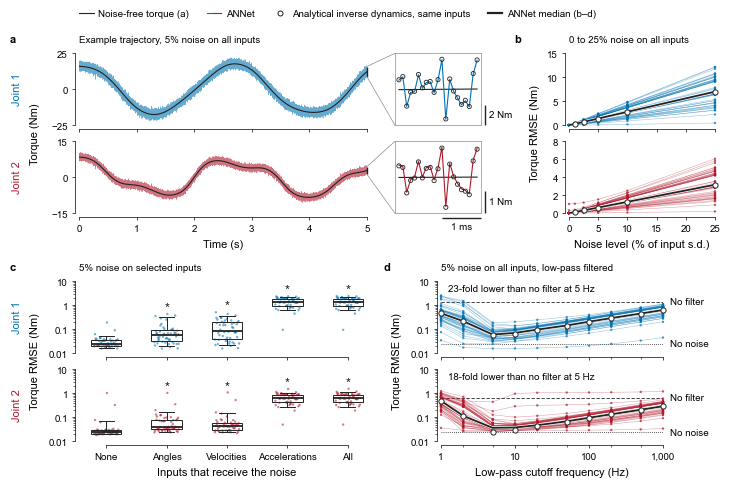

In [76]:
import matplotlib.patheffects as pe
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter
from matplotlib.transforms import blended_transform_factory

# -----------------------------------------------------------------------------
# Fig. 7 plotting code (the same drawing in MAIN_RUN_ME_NEW.ipynb and FIG7.ipynb).
# Two tiers, each with joint 1 (blue) above joint 2 (red).
# Upper tier, the example and the dependence on the noise level
# a: torques of the example trajectory over time. Noise-free torque (black) and torque
#    of ANNet for the noisy inputs (colour). The final 2 ms are expanded in the framed
#    view on the right, in which the line joins the ANNet torques of consecutive samples
#    and the open circles are the analytical inverse dynamics for the same noisy inputs.
# b: torque RMSE against the level of noise on all six inputs. Each thin line is one
#    test trajectory of ANNet, the heavy line joins the ANNet medians and open circles
#    are the medians of the analytical inverse dynamics on the same noisy inputs.
# Lower tier, the origin of the error and its remedy (one noise level, shared RMSE axis)
# c: box plots of the torque RMSE of ANNet when no input, one group of inputs, or all
#    inputs receive the noise, with every trajectory as a dot. An asterisk marks a
#    condition that differs from no noise (FDR q < 0.05), 'ns' one that does not.
# d: torque RMSE when the noisy inputs are low-pass filtered, against the cutoff.
# The axis limits enclose every plotted value.
# -----------------------------------------------------------------------------
FIG7_BLUE = '#0072B2'
FIG7_RED = '#B2182B'
FIG7_NEUTRAL = '#222222'
FIG7_GUIDE = '#8C8C8C'
FIG7_JOINTS = ['J1', 'J2']
FIG7_JOINT_COLORS = {'J1': FIG7_BLUE, 'J2': FIG7_RED}
# Panel c: inputs that receive the noise ('none' is the noise-free network)
FIG7_INPUT_GROUPS = ['none', 'angle', 'velocity', 'acceleration', 'all']
FIG7_INPUT_LABELS = {'none': 'None', 'angle': 'Angles', 'velocity': 'Velocities', 'acceleration': 'Accelerations',
                     'all': 'All'}
# Expanded view of panel a: number of consecutive samples at the end of the trajectory, and its time scale bar
FIG7_ZOOM_SAMPLES = 21
FIG7_ZOOM_BAR_MS = 1.0
# Symmetric limits of the torque axes of panel a (Nm)
FIG7_TORQUE_LIMITS = [1, 2, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100]
FIG7_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.minor.size': 1.4,
    'ytick.minor.size': 1.4,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def fig7_axis_top(maximum):
    # Smallest axis end on a 1-2-5 x 10^k tick step that encloses the data with at most four intervals
    for step in (0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0):
        intervals = int(np.ceil(maximum / step - 1e-9))
        if intervals <= 4:
            return intervals * step, step
    raise ValueError('value outside the supported range')


def fig7_decade_range(values):
    # Powers of ten that enclose the values
    return 10.0 ** np.floor(np.log10(np.min(values))), 10.0 ** np.ceil(np.log10(np.max(values)))


def fig7_number(value, _=None):
    return f"{value:,g}".replace('-', '−')


def draw_fig7(rmse_table, group_stats_table, filter_table, traces_table, figure_percent):
    """
    rmse_table:     long-form table with columns model, noise_target, noise_percent, joint, trajectory, rmse_nm.
    group_stats_table: one row per joint, noise level and noise condition with the columns noise_target and
                    significant_fdr_0_05 (ANNet errors under that condition against the noise-free ANNet errors).
    filter_table:   long-form table with columns model, noise_percent, cutoff_hz, joint, trajectory, rmse_nm
                    (noisy inputs low-pass filtered before they enter the model).
    traces_table:   one row per time point of the example trajectory with the columns time_s and, per joint,
                    noise_free_*_nm, annet_noisy_*_nm and analytical_noisy_*_nm.
    figure_percent: noise level (%) of the example trajectory and of panels c and d.
    Returns the matplotlib figure (four panels in two tiers, joint 1 above joint 2, double-column width).
    """
    levels = sorted(float(percent) for percent in
                    rmse_table.loc[rmse_table['noise_target'].isin(['none', 'all']), 'noise_percent'].unique())
    assert levels[0] == 0.0 and figure_percent in levels
    x_levels = np.asarray(levels)

    def select(model_name, noise_target, joint, percent):
        mask = ((rmse_table['model'] == model_name) & (rmse_table['noise_target'] == noise_target)
                & (rmse_table['joint'] == joint) & (rmse_table['noise_percent'] == percent))
        return rmse_table.loc[mask].sort_values('trajectory')['rmse_nm'].to_numpy(dtype=float)

    def select_filtered(model_name, joint, cutoff_hz):
        mask = ((filter_table['model'] == model_name) & (filter_table['noise_percent'] == figure_percent)
                & (filter_table['joint'] == joint) & (filter_table['cutoff_hz'] == cutoff_hz))
        return filter_table.loc[mask].sort_values('trajectory')['rmse_nm'].to_numpy(dtype=float)

    clean = {joint: select('ANNet', 'none', joint, 0.0) for joint in FIG7_JOINTS}
    annet = {joint: np.stack([clean[joint]] + [select('ANNet', 'all', joint, percent) for percent in levels[1:]])
             for joint in FIG7_JOINTS}
    analytical = {joint: np.stack([select('analytical', 'all', joint, percent) for percent in levels[1:]])
                  for joint in FIG7_JOINTS}
    cutoffs = np.asarray(sorted(float(cutoff) for cutoff in filter_table['cutoff_hz'].unique()))
    filtered = {joint: np.stack([select_filtered('ANNet', joint, cutoff) for cutoff in cutoffs]) for joint in FIG7_JOINTS}
    filtered_reference = {joint: np.asarray([np.median(select_filtered('analytical', joint, cutoff)) for cutoff in cutoffs])
                          for joint in FIG7_JOINTS}
    unfiltered = {joint: np.median(select('ANNet', 'all', joint, figure_percent)) for joint in FIG7_JOINTS}
    group_values = {(joint, group): clean[joint] if group == 'none' else select('ANNet', group, joint, figure_percent)
                    for joint in FIG7_JOINTS for group in FIG7_INPUT_GROUPS}

    # ---- geometry in inches, measured from the left and from the top of the canvas ----
    width, height = 7.2, 4.8
    fig = plt.figure(figsize=(width, height))
    row_height = 0.72
    row_top = {('upper', 'J1'): 0.50, ('upper', 'J2'): 1.38, ('lower', 'J1'): 2.78, ('lower', 'J2'): 3.66}
    columns = {'trace': ('upper', 0.72, 2.88), 'zoom': ('upper', 3.88, 0.86), 'fan': ('upper', 5.62, 1.46),
               'group': ('lower', 0.72, 2.96), 'filter': ('lower', 4.34, 2.22)}
    axes = {(name, joint): fig.add_axes([left / width, 1.0 - (row_top[(tier, joint)] + row_height) / height,
                                         span / width, row_height / height])
            for name, (tier, left, span) in columns.items() for joint in FIG7_JOINTS}
    for (name, joint), ax in axes.items():
        if name == 'zoom':
            continue
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_position(('outward', 3))
        ax.spines['bottom'].set_position(('outward', 3))
    median_style = dict(color=FIG7_NEUTRAL, lw=1.3, solid_capstyle='butt',
                        path_effects=[pe.withStroke(linewidth=2.3, foreground='white')])
    circle_style = dict(facecolors='white', edgecolors=FIG7_NEUTRAL, linewidths=0.7)
    trajectory_line = dict(lw=0.4, alpha=0.4, zorder=2, clip_on=False)
    trajectory_dot = dict(s=3, edgecolors='none', alpha=0.7, zorder=3, clip_on=False)

    # ---- a: torques of the example trajectory over time, and its final samples on expanded scales ----
    time = traces_table['time_s'].to_numpy(dtype=float)
    zoom = slice(len(time) - FIG7_ZOOM_SAMPLES, len(time))
    step_s = time[1] - time[0]
    for joint in FIG7_JOINTS:
        color = FIG7_JOINT_COLORS[joint]
        # The traces are stored in single precision
        trace = {name: traces_table[f"{name}_{joint.lower()}_nm"].to_numpy(dtype=np.float32).astype(float)
                 for name in ('noise_free', 'annet_noisy', 'analytical_noisy')}
        ax = axes[('trace', joint)]
        ax.plot(time, trace['annet_noisy'], color=color, lw=0.3, alpha=0.6, zorder=2, rasterized=True)
        ax.plot(time, trace['noise_free'], color=FIG7_NEUTRAL, lw=0.8, zorder=3)
        largest = max(np.abs(trace['annet_noisy']).max(), np.abs(trace['noise_free']).max())
        limit = min(value for value in FIG7_TORQUE_LIMITS if value >= largest)
        assert largest <= limit
        ax.set_xlim(time[0], time[-1])
        ax.set_ylim(-limit, limit)
        ax.set_xticks(np.arange(time[0], time[-1] + 0.5, 1.0))
        ax.set_yticks([-limit, 0, limit])

        # Expanded view: a frame without axes that encloses the samples with a margin, scale bars for time and torque
        ax_zoom = axes[('zoom', joint)]
        drawn = np.concatenate([trace[name][zoom] for name in trace])
        z_pad = 0.1 * (drawn.max() - drawn.min())
        z_low, z_high = drawn.min() - z_pad, drawn.max() + z_pad
        assert (drawn > z_low).all() and (drawn < z_high).all()
        ax_zoom.plot(time[zoom], trace['noise_free'][zoom], color=FIG7_NEUTRAL, lw=0.8, zorder=2)
        ax_zoom.plot(time[zoom], trace['annet_noisy'][zoom], color=color, lw=0.8, zorder=3)
        ax_zoom.scatter(time[zoom], trace['analytical_noisy'][zoom], s=9, facecolors='none', edgecolors=FIG7_NEUTRAL,
                        linewidths=0.6, zorder=4)
        ax_zoom.set_xlim(time[zoom][0] - step_s, time[zoom][-1] + step_s)
        ax_zoom.set_ylim(z_low, z_high)
        ax_zoom.set_xticks([])
        ax_zoom.set_yticks([])
        for spine in ax_zoom.spines.values():
            spine.set_color(FIG7_GUIDE)
            spine.set_linewidth(0.5)
        # The expanded window on the full trace, joined to the frame
        ax.plot([time[-1]] * 2, [z_low, z_high], color=FIG7_NEUTRAL, lw=1.0, solid_capstyle='butt', zorder=6, clip_on=False)
        for y_trace, y_frame in ((z_low, 0.0), (z_high, 1.0)):
            fig.add_artist(ConnectionPatch(xyA=(time[-1], y_trace), coordsA=ax.transData, xyB=(0.0, y_frame),
                                           coordsB=ax_zoom.transAxes, color=FIG7_GUIDE, lw=0.5))
        bar_nm = max(value for value in (0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0) if value <= 0.4 * (z_high - z_low))
        beside = blended_transform_factory(ax_zoom.transAxes, ax_zoom.transData)
        ax_zoom.plot([1.05, 1.05], [z_low, z_low + bar_nm], transform=beside, color=FIG7_NEUTRAL, lw=1.0,
                     solid_capstyle='butt', clip_on=False)
        ax_zoom.text(1.09, z_low + 0.5 * bar_nm, f"{bar_nm:g} Nm", transform=beside, ha='left', va='center', fontsize=7)
    below = blended_transform_factory(axes[('zoom', 'J2')].transData, axes[('zoom', 'J2')].transAxes)
    bar_end = time[zoom][-1] + step_s
    axes[('zoom', 'J2')].plot([bar_end - FIG7_ZOOM_BAR_MS * 1e-3, bar_end], [-0.07, -0.07], transform=below,
                              color=FIG7_NEUTRAL, lw=1.0, solid_capstyle='butt', clip_on=False)
    axes[('zoom', 'J2')].text(bar_end - 0.5 * FIG7_ZOOM_BAR_MS * 1e-3, -0.12, f"{FIG7_ZOOM_BAR_MS:g} ms", transform=below,
                              ha='center', va='top', fontsize=7)
    axes[('trace', 'J2')].set_xlabel('Time (s)')

    # ---- b: every trajectory against the noise level, linear axes ----
    for joint in FIG7_JOINTS:
        ax = axes[('fan', joint)]
        color = FIG7_JOINT_COLORS[joint]
        y_top, y_step = fig7_axis_top(annet[joint].max())
        assert (annet[joint] >= 0.0).all() and (annet[joint] <= y_top).all()
        assert (np.median(analytical[joint], axis=1) <= y_top).all()
        for i in range(annet[joint].shape[1]):
            ax.plot(x_levels, annet[joint][:, i], color=color, **trajectory_line)
        ax.scatter(np.repeat(x_levels, annet[joint].shape[1]), annet[joint].ravel(), color=color, **trajectory_dot)
        ax.plot(x_levels, np.median(annet[joint], axis=1), zorder=5, clip_on=False, **median_style)
        ax.scatter(x_levels[1:], np.median(analytical[joint], axis=1), s=14, zorder=7, clip_on=False, **circle_style)
        ax.set_xlim(0.0, x_levels[-1])
        ax.set_ylim(0.0, y_top)
        ax.set_xticks(np.arange(0.0, x_levels[-1] + 2.5, 5.0))
        ax.set_yticks(np.arange(0.0, y_top + 0.5 * y_step, y_step))
    axes[('fan', 'J2')].set_xlabel('Noise level (% of input s.d.)')

    # ---- c and d share one logarithmic RMSE axis, bounded by powers of ten ----
    lower_values = np.hstack([values for values in group_values.values()]
                             + [filtered[joint].ravel() for joint in FIG7_JOINTS]
                             + [filtered_reference[joint] for joint in FIG7_JOINTS])
    y_low, y_high = fig7_decade_range(lower_values)
    assert (lower_values >= y_low).all() and (lower_values <= y_high).all()
    decades = 10.0 ** np.arange(np.log10(y_low), np.log10(y_high) + 0.5)
    between_decades = np.concatenate([decade * np.arange(2, 10) for decade in decades[:-1]])

    # ---- c: noise on no input, on one group of inputs or on all inputs, as box plots of the ANNet errors ----
    group_positions = np.arange(len(FIG7_INPUT_GROUPS), dtype=float)
    for joint in FIG7_JOINTS:
        ax = axes[('group', joint)]
        color = FIG7_JOINT_COLORS[joint]
        # Centre line, median; box, quartiles; whiskers, 5th and 95th percentiles (the same on linear and logarithmic axes)
        boxes = []
        for group in FIG7_INPUT_GROUPS:
            low, q1, median, q3, high = np.percentile(group_values[(joint, group)], [5, 25, 50, 75, 95])
            boxes.append(dict(whislo=low, q1=q1, med=median, q3=q3, whishi=high, fliers=[]))
        ax.bxp(boxes, positions=group_positions, widths=0.5, showfliers=False, patch_artist=True, manage_ticks=False, zorder=4,
               boxprops=dict(facecolor='none', edgecolor=FIG7_NEUTRAL, linewidth=0.7),
               whiskerprops=dict(color=FIG7_NEUTRAL, linewidth=0.7), capprops=dict(color=FIG7_NEUTRAL, linewidth=0.7),
               medianprops=dict(color=FIG7_NEUTRAL, linewidth=1.3, solid_capstyle='butt'))
        for position, group in zip(group_positions, FIG7_INPUT_GROUPS):
            values = group_values[(joint, group)]
            # Every trajectory, spread horizontally inside the box in the order of the test set
            offsets = (np.arange(len(values)) / (len(values) - 1) - 0.5) * 0.4
            ax.scatter(position + offsets, values, color=color, s=3, edgecolors='none', alpha=0.55, zorder=3, clip_on=False)
            if group != 'none':
                # Difference from the noise-free errors: one asterisk if significant after FDR correction, 'ns' otherwise
                row = group_stats_table[(group_stats_table['joint'] == joint) & (group_stats_table['noise_target'] == group)
                                        & (group_stats_table['noise_percent'] == figure_percent)]
                assert len(row) == 1
                significant = bool(row['significant_fdr_0_05'].iloc[0])
                mark_y = 1.7 * values.max()
                assert mark_y < y_high, 'the significance mark of panel c leaves the axes'
                ax.text(position, mark_y, '*' if significant else 'ns', ha='center', va='center',
                        fontsize=9 if significant else 7, color=FIG7_NEUTRAL)
        ax.set_yscale('log')
        ax.set_xlim(group_positions[0] - 0.45, group_positions[-1] + 0.45)
        ax.set_ylim(y_low, y_high)
        ax.set_xticks(group_positions)
        ax.spines['bottom'].set_bounds(group_positions[0], group_positions[-1])
    axes[('group', 'J2')].set_xticklabels([FIG7_INPUT_LABELS[group] for group in FIG7_INPUT_GROUPS])
    axes[('group', 'J2')].set_xlabel('Inputs that receive the noise')

    # ---- d: low-pass filtered noisy inputs against the cutoff frequency ----
    reference_labels = {}
    for joint in FIG7_JOINTS:
        ax = axes[('filter', joint)]
        color = FIG7_JOINT_COLORS[joint]
        for i in range(filtered[joint].shape[1]):
            ax.plot(cutoffs, filtered[joint][:, i], color=color, **trajectory_line)
        ax.scatter(np.repeat(cutoffs, filtered[joint].shape[1]), filtered[joint].ravel(), color=color, **trajectory_dot)
        ax.plot(cutoffs, np.median(filtered[joint], axis=1), zorder=5, clip_on=False, **median_style)
        ax.scatter(cutoffs, filtered_reference[joint], s=14, zorder=7, clip_on=False, **circle_style)
        # Reference levels: ANNet median without filtering (dashed) and without noise (dotted)
        ax.axhline(unfiltered[joint], color=FIG7_NEUTRAL, lw=0.6, linestyle=(0, (4, 2)), zorder=1)
        ax.axhline(np.median(clean[joint]), color=FIG7_NEUTRAL, lw=0.6, linestyle=(0, (1, 1.5)), zorder=1)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(cutoffs[0], cutoffs[-1])
        ax.set_ylim(y_low, y_high)
        ax.xaxis.set_major_locator(FixedLocator([tick for tick in (1, 10, 100, 1000, 10000) if cutoffs[0] <= tick <= cutoffs[-1]]))
        # Minor ticks mark the remaining cutoffs
        ax.xaxis.set_minor_locator(FixedLocator([cutoff for cutoff in cutoffs if np.log10(cutoff) % 1 > 1e-9]))
        ax.xaxis.set_minor_formatter(NullFormatter())
        beside = blended_transform_factory(ax.transAxes, ax.transData)
        reference_labels[joint] = [
            ax.text(1.03, unfiltered[joint], 'No filter', transform=beside, ha='left', va='center', fontsize=7),
            ax.text(1.03, np.median(clean[joint]), 'No noise', transform=beside, ha='left', va='center', fontsize=7)]
        # Largest reduction of the median error by the filter
        best = int(np.argmin(np.median(filtered[joint], axis=1)))
        fold = unfiltered[joint] / np.median(filtered[joint][best])
        reference_labels[joint].append(
            ax.text(1.25 * cutoffs[0], 0.72 * y_high, f"{fold:.0f}-fold lower than no filter at {cutoffs[best]:g} Hz",
                    ha='left', va='top', fontsize=7))
    axes[('filter', 'J2')].set_xlabel('Low-pass cutoff frequency (Hz)')

    # ---- shared styling ----
    for (name, joint), ax in axes.items():
        if name in ('group', 'filter'):
            ax.yaxis.set_major_locator(FixedLocator(decades))
            ax.yaxis.set_minor_locator(FixedLocator(between_decades))
            ax.yaxis.set_minor_formatter(NullFormatter())
        if name != 'zoom':
            ax.yaxis.set_major_formatter(FuncFormatter(fig7_number))
        if name not in ('group', 'zoom'):
            ax.xaxis.set_major_formatter(FuncFormatter(fig7_number))
        if joint == 'J1':
            ax.tick_params(labelbottom=False)

    # ---- axis labels shared by the two joints, joint tags, titles and panel letters ----
    def row_middle(tier, joint=None):
        top = row_top[(tier, joint or 'J1')]
        bottom = row_top[(tier, joint or 'J2')] + row_height
        return 1.0 - 0.5 * (top + bottom) / height

    for name, label, offset in (('trace', 'Torque (Nm)', 0.44), ('fan', 'Torque RMSE (Nm)', 0.34),
                                ('group', 'Torque RMSE (Nm)', 0.44), ('filter', 'Torque RMSE (Nm)', 0.44)):
        tier, left, _ = columns[name]
        fig.text((left - offset) / width, row_middle(tier), label, rotation=90, ha='center', va='center', fontsize=8)
    for tier in ('upper', 'lower'):
        for joint in FIG7_JOINTS:
            fig.text(0.10 / width, row_middle(tier, joint), f"Joint {joint[1]}", rotation=90, ha='center', va='center',
                     fontsize=8, color=FIG7_JOINT_COLORS[joint])
    titles = {
        'a': ('trace', 0.72, f"Example trajectory, {figure_percent:g}% noise on all inputs"),
        'b': ('fan', 0.58, f"{x_levels[0]:g} to {x_levels[-1]:g}% noise on all inputs"),
        'c': ('group', 0.72, f"{figure_percent:g}% noise on selected inputs"),
        'd': ('filter', 0.60, f"{figure_percent:g}% noise on all inputs, low-pass filtered"),
    }
    for letter, (name, offset, title) in titles.items():
        tier, left, _ = columns[name]
        title_y = 1.0 - (row_top[(tier, 'J1')] - 0.09) / height
        fig.text((left - offset + 0.03) / width, title_y, letter, fontsize=8, fontweight='bold', ha='left', va='bottom')
        fig.text(left / width, title_y, title, fontsize=7, ha='left', va='bottom')

    # ---- one key for the four panels ----
    handles = [
        Line2D([0], [0], color=FIG7_NEUTRAL, lw=0.8),
        (Line2D([0], [0], color=FIG7_BLUE, lw=0.8), Line2D([0], [0], color=FIG7_RED, lw=0.8)),
        Line2D([0], [0], marker='o', linestyle='None', markersize=3.6, markerfacecolor='white',
               markeredgecolor=FIG7_NEUTRAL, markeredgewidth=0.7),
        Line2D([0], [0], color=FIG7_NEUTRAL, lw=1.6),
    ]
    labels = ['Noise-free torque (a)', 'ANNet', 'Analytical inverse dynamics, same inputs', 'ANNet median (b\u2013d)']
    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.72 / width, 1.0 - 0.06 / height), ncol=len(handles),
               frameon=False, handlelength=1.5, handletextpad=0.5, columnspacing=1.8, borderaxespad=0.0, borderpad=0.0,
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.0)})

    # The annotations of panel d must not cover a plotted value
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for joint in FIG7_JOINTS:
        ax = axes[('filter', joint)]
        box = reference_labels[joint][2].get_window_extent(renderer).transformed(ax.transData.inverted())
        x_all = np.repeat(cutoffs, filtered[joint].shape[1])
        y_all = filtered[joint].ravel()
        covered = (x_all >= box.x0) & (x_all <= box.x1) & (y_all >= box.y0) & (y_all <= box.y1)
        assert not covered.any(), 'the text of panel d covers a plotted value'
        assert box.y0 > unfiltered[joint], 'the text of panel d meets the dashed line'
    return fig


def save_fig7(fig, directory, name):
    # PDF (vector, editable text) and 600-dpi PNG at the canvas size, as in FIG7.ipynb
    for ext in ('pdf', 'png'):
        figure_path = os.path.join(directory, f"{name}.{ext}")
        fig.savefig(figure_path, facecolor='white')
        print(f"Saved {figure_path}")


# Draw Fig. 7 and save the PDF and PNG to the submission folder
with mpl.rc_context():
    mpl.rc_file_defaults()        # same starting point as the standalone notebook, whatever this kernel has set
    mpl.rcParams.update(FIG7_RC)
    nse_fig = draw_fig7(nse_rmse_df, nse_group_stats_df, nse_filter_df, nse_traces_df, nse_figure_percent)
    save_fig7(nse_fig, NSE_FIGURE_DIR, NSE_FIGURE_NAME)
    plt.show()

### Data package for Fig. 7

Following the packaging used for the other figures, the trajectory-wise RMSE values, the two statistics tables, the scaling table, the RMSE values and statistics after low-pass filtering, the torques of the example trajectory, provenance metadata (source-file hashes, noise model, filter, test-set description, statistical settings) and a README are written into `FIG7.zip` in `SUBMISSION/FIGURES/DATA AND SCRIPTS/`. The standalone notebook `FIG7.ipynb` in the same folder regenerates the figure from this archive alone.

In [77]:
import json
import zipfile
from datetime import datetime, timezone

nse_package_path = os.path.join(NSE_PACKAGE_DIR, f"{NSE_FIGURE_NAME}.zip")

# Provenance: hashes of every artifact the figure and statistics were derived from
nse_source_paths = [NSE_MODEL_PATH, NSE_STATS_PATH, NSE_TEST_SET_PATH, NSE_CLEAN_RESULTS_PATH,
                    NSE_RESULTS_PATH, NSE_RMSE_CSV_PATH, NSE_STATS_CSV_PATH, NSE_GROUP_STATS_CSV_PATH, NSE_SCALING_CSV_PATH,
                    NSE_FILTER_RESULTS_PATH, NSE_FILTER_CSV_PATH, NSE_FILTER_STATS_CSV_PATH, NSE_TRACES_CSV_PATH]
nse_source_files = {
    os.path.basename(path): {'sha256': nse_sha256_of_file(path), 'bytes': os.path.getsize(path)}
    for path in nse_source_paths if os.path.exists(path)
}

nse_metadata = {
    'created_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'description': ('Data package for manuscript Figure 7: torque accuracy of the ANNet inverse dynamics '
                    'when Gaussian noise is added to its inputs, with and without low-pass filtering of the noisy inputs.'),
    'purpose': ('Measures how measurement noise on the angles, velocities and accelerations affects the torques '
                'predicted by the ANNet inverse dynamics.'),
    'data_derivation': (
        'Trajectory-wise torque RMSE values were produced by MAIN_RUN_ME_NEW.ipynb, Section 11, from the '
        'fixed test set test_set_50_traj_5s.pt (50 RK4 reference trajectories, 5 s, 0.1 ms step) and the ANNet '
        'trained on 16,000 samples (model_16000.pth, stats_16000.pt). The noise is generated from the stated seed. '
        'The noise-free ANNet errors equal those of results_model_16000.pt. '
        'Statistics were computed from the archived RMSE values.'
    ),
    'source_files': nse_source_files,
    'noise_model': {
        'distribution': 'zero-mean Gaussian, independent across inputs and time points',
        'standard_deviation': ('noise level times the standard deviation of that input over the trajectory '
                               '(unbiased estimate over the 50,001 time points)'),
        'noise_levels_percent': [float(100.0 * level) for level in NSE_NOISE_LEVELS],
        'inputs': ['q1', 'q2', 'dq1', 'dq2', 'ddq1', 'ddq2'],
        'input_groups': {name: [int(column) for column in columns] for name, columns in NSE_INPUT_GROUPS.items()},
        'seed': int(NSE_SEED),
        'seed_rule': 'trajectory i uses torch.Generator().manual_seed(seed + i); one standard-normal draw per '
                     'trajectory is reused for every noise level and input group',
        'error_reference': 'noise-free analytical torques of the same trajectory',
    },
    'models': {
        'ANNet': ('network trained on 16,000 samples; torques obtained as the scaled gradient of the standardized '
                  'energy with respect to the standardized accelerations, as in Section 4'),
        'analytical': ('analytical inverse dynamics of the double pendulum (the kernel that generated the '
                       'ground-truth torques) evaluated on the same noisy inputs; exact without noise'),
    },
    'physical_parameters': {key: float(value) for key, value in PARAMS.items()},
    'test_set': {
        'file': os.path.basename(NSE_TEST_SET_PATH),
        'num_trajectories': int(nse_rmse_df['trajectory'].nunique()),
        'samples_per_trajectory': 50001,
        'duration_s': 5.0,
        'reference_integrator': 'fixed-step RK4',
        'step_s': float(NSE_TEST_STEP_KEY),
    },
    'statistics': {
        'alpha': NSE_ALPHA,
        'normality_test': 'Shapiro-Wilk on each group',
        'primary_test_rule': 'one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test',
        'multiple_comparison_correction': 'Benjamini-Hochberg FDR across the ten joint-by-noise-level comparisons',
        'secondary_tests': ['two-sided Mann-Whitney U (unpaired; ANNet vs analytical)',
                            'two-sided Wilcoxon signed-rank (paired by trajectory; ANNet vs analytical)'],
        'effect_sizes': ['median ratio ANNet/analytical', "Cliff's delta (ANNet vs analytical)"],
        'primary_test_used': {f"{row['joint']}_{row['noise_percent']:g}": row['test_name'] for _, row in nse_stats_df.iterrows()},
        'fdr_q_values': {f"{row['joint']}_{row['noise_percent']:g}": float(row['fdr_q_value']) for _, row in nse_stats_df.iterrows()},
        'noise_conditions_against_no_noise': {
            'comparison': ('ANNet errors with noise on the angles, velocities, accelerations or all inputs against the '
                           'noise-free ANNet errors of the same trajectories, per joint and noise level'),
            'primary_test_rule': 'one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test',
            'multiple_comparison_correction': 'Benjamini-Hochberg FDR across the 40 joint-by-condition-by-level comparisons',
            'secondary_test': 'two-sided Wilcoxon signed-rank (paired by trajectory)',
            'num_significant': int(nse_group_stats_df['significant_fdr_0_05'].sum()),
            'num_comparisons': int(len(nse_group_stats_df)),
        },
    },
    'scaling_law': {
        'proportional_law': ('RMSE_i(p) = k_i p for an exact model, with p the noise level and the first-order gain '
                             'k_i = sqrt(mean over time of sum_j (d tau_i / d x_j)^2 sigma_j^2), sigma_j the standard '
                             'deviation of input j over the trajectory'),
        'quadrature_law': 'RMSE_i(p) = sqrt(RMSE_i(0)^2 + (k_i p)^2) for a model with a noise-free error RMSE_i(0)',
        'gain_first_order': 'from the Jacobian of the analytical inverse dynamics on the noise-free inputs (automatic differentiation)',
        'gain_annet_jacobian': 'the same quantity from the Jacobian of the ANNet torque, i.e. the second derivative of the learned energy',
        'gain_fitted_analytical': 'least-squares slope through the origin of the analytical error against the noise level',
        'exponents': 'slope of log(RMSE) against log(noise level) over the noise levels, per trajectory and joint',
        'gain_units': 'Nm per percent of input noise',
    },
    'filtering': {
        'filter': ('low-pass Butterworth filter of order 2 applied forward and backward to each of the six noisy inputs '
                   '(zero phase lag, fourth order overall), scipy.signal.sosfiltfilt'),
        'cutoff_definition': '-3 dB frequency of the two passes',
        'cutoffs_hz': [float(cutoff) for cutoff in NSE_FILTER_CUTOFFS_HZ],
        'sampling_rate_hz': float(NSE_SAMPLING_RATE_HZ),
        'end_extension': (f'mirror reflection at both ends over {NSE_FILTER_PAD_CYCLES:g} cutoff periods '
                          '(at most the length of the trajectory)'),
        'inputs': 'the noisy inputs of the main analysis (noise on all six inputs, same draws); level 0 is the noise-free input',
        'error_reference': 'noise-free analytical torques of the same trajectory, whole trajectory',
        'white_noise_sd_fraction': ('fraction of the standard deviation of white noise that the two passes transmit, '
                                    'from the frequency response of the filter'),
        'first_order_prediction': ('sqrt(filter-only error^2 + (white-noise fraction x unfiltered error)^2), per '
                                   'trajectory, for the analytical inverse dynamics'),
        'test': 'two-sided Wilcoxon signed-rank test of the ANNet error with filtered against unfiltered inputs, paired by trajectory',
        'scipy_version': __import__('scipy').__version__,
    },
    'example_trajectory': {
        'index': int(nse_example_trajectory),
        'noise_percent': float(nse_figure_percent),
        'selection_rule': ('trajectory whose ANNet errors at this noise level (noise on all inputs) lie closest to the '
                           'medians of both joints: smallest sum over the joints of |log(error / median error)|'),
        'traces': 'noise-free torques and the torques of ANNet and of the analytical inverse dynamics for the noisy inputs, at every time point',
    },
    'figure': {
        'noise_percent': float(nse_figure_percent),
        'content': ('four panels in two tiers, joint 1 above joint 2 in each, double-column width, one key for all panels. '
                    'a: torques of the example trajectory over time at the stated noise level (noise-free torque as a black '
                    'line, ANNet torque for the noisy inputs at every time point in colour); the frame magnifies the final '
                    '2 ms, with scale bars, the coloured line joining the ANNet torques of consecutive samples and open circles '
                    'marking the torques of the analytical inverse dynamics for the same noisy inputs. b, linear axes: '
                    'trajectory-wise torque RMSE of ANNet against the noise level with noise on all inputs, one thin line per '
                    'test trajectory; the heavy line joins the ANNet medians and open circles mark the medians of the '
                    'analytical inverse dynamics on the same noisy inputs. c, logarithmic axis: errors at the stated noise '
                    'level with noise on no input, on the angles, velocities or accelerations alone, or on all inputs, as box '
                    'plots of the ANNet errors (centre line at the median, box from the first to the third quartile, whiskers '
                    'at the 5th and 95th percentiles) with one dot per trajectory; an asterisk marks a condition that differs '
                    'from no noise (FDR q < 0.05) and ns one that does not. d, logarithmic axes: errors at the stated noise level after low-pass filtering of the noisy '
                    'inputs, against the cutoff frequency, with the conventions of b; dashed line, median ANNet error without '
                    'filtering; dotted line, median ANNet error without noise; text, ratio of the unfiltered median to the '
                    'lowest filtered median and its cutoff'),
        'axis_limits': 'every numeric axis ends on a labelled tick that encloses all plotted values',
    },
    'num_rmse_rows': int(len(nse_rmse_df)),
    'num_filter_rmse_rows': int(len(nse_filter_df)),
}

nse_readme_text = f"""{NSE_FIGURE_NAME} data package
=================

This archive contains the data required by {NSE_FIGURE_NAME}.ipynb to regenerate manuscript Figure 7.

Files:
- fig7_rmse_values.csv: trajectory-wise torque RMSE of ANNet (trained on 16,000 samples) and of the analytical inverse dynamics when both receive the same noisy inputs, per joint, on the 50-trajectory fixed test set. Columns: model, noise_target (none, all, angle, velocity or acceleration), noise_percent, joint, trajectory, rmse_nm, torque_sd_nm (standard deviation of the noise-free torque over the trajectory).
- fig7_statistics.csv: per joint and noise level (noise on all inputs), Shapiro-Wilk normality tests, primary comparison of ANNet and the analytical model (one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test) with Benjamini-Hochberg FDR correction across the ten comparisons, secondary two-sided Mann-Whitney U and paired Wilcoxon signed-rank tests, descriptive statistics, effect sizes, and the median ANNet error when the noise is applied to one input group only. The column median_added_by_annet_nm is the median over trajectories of the square root of the difference between the squared ANNet error and the squared analytical error, set to zero for a trajectory where the analytical error is the larger.
- fig7_input_group_statistics.csv: per joint, noise level and noise condition (noise on the angles, velocities, accelerations or all inputs), the comparison of the ANNet errors with the noise-free ANNet errors of the same trajectories: Shapiro-Wilk normality tests, primary test (one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test) with Benjamini-Hochberg FDR correction across the 40 comparisons, two-sided paired Wilcoxon signed-rank test, medians, ratio of the median to the noise-free median, Cliff's delta and the number of trajectories whose error rose.
- fig7_scaling.csv: per joint and trajectory, the first-order gain of the torque error in Nm per percent of input noise from the Jacobian of the analytical inverse dynamics (gain_first_order_nm_per_percent) and from the Jacobian of ANNet (gain_annet_jacobian_nm_per_percent), the gain fitted to the analytical errors, the power-law exponents of the analytical and ANNet errors over the noise levels, and the largest relative deviation of the analytical errors from the proportional law gain x noise level and of the ANNet errors from the quadrature law sqrt(noise-free error^2 + (gain x noise level)^2).
- fig7_filter_rmse.csv: trajectory-wise torque RMSE of ANNet and of the analytical inverse dynamics when the noisy inputs (noise on all six inputs, same draws) are low-pass filtered before they enter the model. Columns: model, noise_percent (0 for noise-free inputs), cutoff_hz, joint, trajectory, rmse_nm.
- fig7_filter_statistics.csv: per joint, noise level and cutoff frequency, the medians of ANNet and of the analytical model after filtering, the median ANNet error without filtering, their ratio (reduction_factor_of_median_annet), the two-sided paired Wilcoxon signed-rank test of filtered against unfiltered ANNet errors, the fraction of the standard deviation of white noise that the filter transmits, the error that the filter alone causes on noise-free inputs, and the measured analytical error relative to the first-order prediction. The column lowest_median_annet_of_level marks the cutoff with the lowest median ANNet error at that noise level.
- fig7_example_traces.csv: torques of the example trajectory at every time point (single precision). Columns: sample, time_s and, for each joint, the noise-free torque and the torques of ANNet and of the analytical inverse dynamics for the noisy inputs.
- fig7_metadata.json: source hashes, noise model, scaling laws, filter, example trajectory, test-set description, statistical settings, figure conventions, and provenance metadata.

The noise is zero-mean Gaussian, independent across inputs and time points, with a standard deviation equal to the stated percentage of the standard deviation of each input over the trajectory. Errors are measured against the noise-free torques. The figure has four panels in two tiers, with joint 1 above joint 2 in each. Panel a shows the torques of the example trajectory over time at {nse_figure_percent:g}% noise (noise-free torque and ANNet torque for the noisy inputs); the frame magnifies the final {1e3 * (FIG7_ZOOM_SAMPLES - 1) / NSE_SAMPLING_RATE_HZ:g} ms, where the coloured line joins the ANNet torques of consecutive samples and open circles mark the torques of the analytical inverse dynamics for the same noisy inputs. Panel b shows the torque RMSE of ANNet against the noise level on linear axes; each thin line is one trajectory, the heavy line joins the ANNet medians, and open circles mark the medians of the analytical inverse dynamics on the same noisy inputs. Panel c shows box plots of the ANNet errors at {nse_figure_percent:g}% noise on no input, on the angles, velocities or accelerations alone, or on all inputs (median, quartiles, whiskers at the 5th and 95th percentiles), with every trajectory as a dot; an asterisk marks a condition that differs from no noise after FDR correction. Panel d shows the errors at {nse_figure_percent:g}% noise after zero-phase low-pass filtering of the noisy inputs (Butterworth, fourth order overall) against the cutoff frequency, with the median errors without filtering (dashed) and without noise (dotted).
"""


def write_fig7_package(package_path):
    with zipfile.ZipFile(package_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
        archive.writestr('fig7_rmse_values.csv', nse_rmse_df.to_csv(index=False))
        archive.writestr('fig7_statistics.csv', nse_stats_df.to_csv(index=False))
        archive.writestr('fig7_input_group_statistics.csv', nse_group_stats_df.to_csv(index=False))
        archive.writestr('fig7_scaling.csv', nse_scaling_df.to_csv(index=False))
        archive.writestr('fig7_filter_rmse.csv', nse_filter_df.to_csv(index=False))
        archive.writestr('fig7_filter_statistics.csv', nse_filter_stats_df.to_csv(index=False))
        archive.writestr('fig7_example_traces.csv', nse_traces_df.to_csv(index=False))
        archive.writestr('fig7_metadata.json', json.dumps(nse_metadata, indent=2, allow_nan=False))
        archive.writestr(f'{NSE_FIGURE_NAME}_README.txt', nse_readme_text)
    print(f"Saved data package to {package_path}")
    with zipfile.ZipFile(package_path) as archive:
        for info in archive.infolist():
            print(f"  {info.filename:<28} {info.file_size:>9,} bytes")


write_fig7_package(nse_package_path)

Saved data package to ../SUBMISSION/FIGURES/DATA AND SCRIPTS/FIG7.zip
  fig7_rmse_values.csv           264,452 bytes
  fig7_statistics.csv              5,034 bytes
  fig7_input_group_statistics.csv    10,755 bytes
  fig7_scaling.csv                16,865 bytes
  fig7_filter_rmse.csv           524,853 bytes
  fig7_filter_statistics.csv      25,484 bytes
  fig7_example_traces.csv      3,699,532 bytes
  fig7_metadata.json              10,919 bytes
  FIG7_README.txt                  5,313 bytes


# Section 12: Robustness of the forward dynamics to noise in the gravitational torques

Section 11 measured how noise on the inputs of the inverse model affects its torque predictions. This section does the same for the forward solver of Section 6. In forward dynamics the input is the generalized force, here the gravitational torque $\mathbf{G}(\mathbf{q})$ that enters the objective $S_{\text{net}}(\mathbf{q}, \dot{\mathbf{q}}, \ddot{\mathbf{q}}) + \mathbf{G}(\mathbf{q})^\top \ddot{\mathbf{q}} + \lambda \|\ddot{\mathbf{q}} - \ddot{\mathbf{q}}_{\text{prev}}\|^2$ at every time step, and the outputs are the accelerations, velocities and angles of the closed-loop simulation. Zero-mean Gaussian noise is therefore added to the gravitational torque of each joint at every solver step, with a standard deviation of 1, 2.5, 5 or 10% of the standard deviation of that torque over the trajectory. The initial angles and velocities are not perturbed, so every rollout starts from the exact initial state of Section 6.

The protocol of Section 6 is otherwise unchanged (50 trajectories, 5 s, 2 ms step, $N = 16$ candidate accelerations within $\pm 15$ rad/s$^2$, 10 Adam refinement steps, $\lambda = 0.1$, five-step stabilization at $t = 0$, semi-implicit Euler, seed 23), and the errors are measured against the same noise-free Runge-Kutta reference trajectories. The same noise is also passed to the solver that uses the analytical Appell energy (Section 7). Its error is the error that the noise causes when the energy is exact, so the comparison of the two solvers isolates the contribution of the learned energy. The noise-free simulation of each solver is recomputed here with the same code, so that every noise level is compared with a simulation that uses the same candidate accelerations. The result is exported as Fig. 8 together with its data package.

The section requires the library import cell and the definition cells of Sections 1 to 4 and reads the cached files `model_16000.pth`, `stats_16000.pt`, `simulation_results_50trials_N16_B15_A10.pt` and `simulation_results_50trials_analyticalS_N16_B15_A10.pt`. The names of its output files start with `forward_noise_`. The simulations are skipped when their output file already exists and was produced from the current model, reference trajectories, solver configuration and noise settings.

### Constants

In [78]:
# Noise robustness of the forward dynamics: dependencies, constants and file paths.

_fns_required_names = [
    # imports (Libraries import cell)
    'os', 'time', 'np', 'pd', 'torch', 'scipy_stats', 'multipletests', 'mpl', 'plt', 'Line2D',
    # analytical kernels and numeric helpers (Sections 1 and 4)
    'TORCH_DTYPE', 'TORCH_EPS', 'as_f32_tensor', 'compute_S_ground_truth_eager', '_gravity_vector_torch',
    '_compute_accelerations_torch',
    # physical parameters and device (Section 2)
    'PARAMS', 'device',
    # network architecture (Section 3)
    'NUM_NODE_L1', 'NUM_NODE_L2', 'NUM_NODE_L3', 'NUM_NODE_L4', 'GibbsAppellNet',
]
_fns_missing_names = [name for name in _fns_required_names if name not in globals()]
if _fns_missing_names:
    raise RuntimeError(
        "Run the library import cell and the definition cells of Sections 1 to 4 first (analytical kernels, physical "
        f"parameters, device, network architecture, forward-dynamics kernels). Missing names: {_fns_missing_names}"
    )

# Training-set size of the ANNet used for all downstream analyses
FNS_N_SAMPLES = 16000

# Simulation protocol of Section 6 (closed-loop simulation with the learned energy)
FNS_SEED = 23
FNS_NUM_TRAJS = 50
FNS_DT_SIM = 0.002
FNS_DURATION = 5.0
FNS_STEPS = int(FNS_DURATION / FNS_DT_SIM)
FNS_GRAVITY = 9.81

# Solver configuration selected for the learned energy (Section 6 / Fig. 6)
FNS_SAMPLED_ACCELERATION_VECTORS = 16
FNS_BOUND = 15.0
FNS_ADAM_STEPS = 10
FNS_ADAM_LR = 0.1
FNS_LAMBDA_REG = 0.1
FNS_WARMUP_STEPS = 5
FNS_CONFIG_TAG = f"N{FNS_SAMPLED_ACCELERATION_VECTORS}_B{FNS_BOUND:g}_A{FNS_ADAM_STEPS}"

# Guard against silent divergence from Section 6 if its constants are defined in this kernel
for _fns_name, _fns_value in (
    ('BEST_REALTIME_SAMPLED_ACCELERATION_VECTORS', FNS_SAMPLED_ACCELERATION_VECTORS),
    ('BEST_REALTIME_BOUND', FNS_BOUND),
    ('BEST_REALTIME_ADAM_STEPS', FNS_ADAM_STEPS),
    ('DT_SIM', FNS_DT_SIM),
    ('NUM_TRAJS', FNS_NUM_TRAJS),
    ('LAMBDA_REG', FNS_LAMBDA_REG),
    ('WARMUP_STEPS', FNS_WARMUP_STEPS),
    ('DURATION', FNS_DURATION),
    ('STEPS', FNS_STEPS),
):
    if _fns_name in globals() and globals()[_fns_name] != _fns_value:
        raise RuntimeError(f"{_fns_name} = {globals()[_fns_name]} in this kernel, but this section uses {_fns_value}.")

# Noise levels: standard deviation of the Gaussian noise added to the gravitational torque of each joint,
# as a fraction of the standard deviation of that torque over the trajectory (1, 2.5, 5 and 10%).
# The level 0 is the noise-free simulation, run with the same code and the same random candidate accelerations.
FNS_NOISE_LEVELS = (0.01, 0.025, 0.05, 0.10)
FNS_ALL_LEVELS = (0.0,) + FNS_NOISE_LEVELS

# Seed of the noise; trajectory i uses the generator seeded with FNS_NOISE_SEED + i
FNS_NOISE_SEED = 37

# The two forward solvers: learned Appell energy (ANNet) and analytical Appell energy
FNS_MODELS = ('ANNet', 'analytical')

# Noise level of the example trajectory of Fig. 8
FNS_FIGURE_NOISE_LEVEL = 0.10

# Input files (produced in Sections 3, 6 and 7) and output files of this section
FNS_BASE_PATH = output_dir if 'output_dir' in globals() else '.'
FNS_MODEL_PATH           = os.path.join(FNS_BASE_PATH, f"model_{FNS_N_SAMPLES}.pth")
FNS_STATS_PATH           = os.path.join(FNS_BASE_PATH, f"stats_{FNS_N_SAMPLES}.pt")
FNS_REFERENCE_PATH       = os.path.join(FNS_BASE_PATH, f"simulation_results_50trials_{FNS_CONFIG_TAG}.pt")
FNS_ANALYTICAL_PATH      = os.path.join(FNS_BASE_PATH, f"simulation_results_50trials_analyticalS_{FNS_CONFIG_TAG}.pt")
FNS_RESULTS_PATH         = os.path.join(FNS_BASE_PATH, f"forward_noise_results_{FNS_CONFIG_TAG}.pt")
FNS_RMSE_CSV_PATH        = os.path.join(FNS_BASE_PATH, f"forward_noise_rmse_{FNS_CONFIG_TAG}.csv")
FNS_STATS_CSV_PATH       = os.path.join(FNS_BASE_PATH, f"forward_noise_statistics_{FNS_CONFIG_TAG}.csv")
FNS_LEVEL_STATS_CSV_PATH = os.path.join(FNS_BASE_PATH, f"forward_noise_level_statistics_{FNS_CONFIG_TAG}.csv")
FNS_TRACES_CSV_PATH      = os.path.join(FNS_BASE_PATH, f"forward_noise_example_traces_{FNS_CONFIG_TAG}.csv")

# Destinations of the figure and its data package (SUBMISSION tree).
# The notebook is expected to run from SIMULATIONS/; if the tree is not found,
# the files are written next to the notebook instead.
FNS_FIGURE_NAME = 'FIG8'
_fns_repo_root = os.path.normpath(os.path.join(FNS_BASE_PATH, os.pardir))
FNS_FIGURE_DIR  = os.path.join(_fns_repo_root, 'SUBMISSION', 'FIGURES', 'PDF AND PNG')
FNS_PACKAGE_DIR = os.path.join(_fns_repo_root, 'SUBMISSION', 'FIGURES', 'DATA AND SCRIPTS')
for _fns_dir_name in ('FNS_FIGURE_DIR', 'FNS_PACKAGE_DIR'):
    if not os.path.isdir(globals()[_fns_dir_name]):
        print(f"Warning: {globals()[_fns_dir_name]} not found; {_fns_dir_name} falls back to '{FNS_BASE_PATH}'.")
        globals()[_fns_dir_name] = FNS_BASE_PATH

print(f"ANNet model:               {FNS_MODEL_PATH}")
print(f"Reference trajectories:    {FNS_REFERENCE_PATH}")
print(f"Solver configuration:      {FNS_CONFIG_TAG}, lr {FNS_ADAM_LR}, lambda {FNS_LAMBDA_REG}, "
      f"warm-up {FNS_WARMUP_STEPS}, dt {FNS_DT_SIM} s, {FNS_STEPS} steps")
print(f"Noise levels (% of s.d.):  {[100 * level for level in FNS_NOISE_LEVELS]}")
print(f"Noise results:             {FNS_RESULTS_PATH}")
print(f"Figure directory:          {FNS_FIGURE_DIR}")
print(f"Data package directory:    {FNS_PACKAGE_DIR}")

ANNet model:               ./model_16000.pth
Reference trajectories:    ./simulation_results_50trials_N16_B15_A10.pt
Solver configuration:      N16_B15_A10, lr 0.1, lambda 0.1, warm-up 5, dt 0.002 s, 2500 steps
Noise levels (% of s.d.):  [1.0, 2.5, 5.0, 10.0]
Noise results:             ./forward_noise_results_N16_B15_A10.pt
Figure directory:          ../SUBMISSION/FIGURES/PDF AND PNG
Data package directory:    ../SUBMISSION/FIGURES/DATA AND SCRIPTS


### Noise model and forward solvers

At every time step the solver receives the gravitational torque of the current simulated state plus noise, $\mathbf{G}(\mathbf{q}_k) + p\, \boldsymbol{\sigma}_G \odot \boldsymbol{\varepsilon}_k$, where $p$ is the noise level, $\boldsymbol{\sigma}_G$ holds the standard deviation of the gravitational torque of each joint over the noise-free reference trajectory, and $\boldsymbol{\varepsilon}_k$ is a pair of independent standard-normal values. One draw of $\boldsymbol{\varepsilon}$ is made per trajectory for all 2,500 steps and reused for every noise level and for both solvers, so that the conditions differ only in the scale of the noise. The noise comes from its own random generator, so the candidate accelerations that the solver samples are identical in every condition as well.

The functions below reproduce the two-stage solver of Sections 6 and 7 step by step (candidate search over $N = 16$ accelerations, 10 Adam refinement steps, temporal regularizer, semi-implicit Euler update), with the gravitational torque passed in as an argument. With the learned energy the objective uses the de-standardized network output, as in Section 6; with the analytical energy it uses the Gibbs-Appell function of Section 1, as in Section 7. Without noise, the analytical-energy rollouts must therefore reproduce the stored results of Section 7, which the simulation cell below checks. The cell that follows this text defines the solvers and checks that the gradient of both objectives vanishes at the true acceleration of a state.

In [79]:
_fns_m1 = as_f32_tensor(PARAMS['m1'], device=device)
_fns_m2 = as_f32_tensor(PARAMS['m2'], device=device)
_fns_l1 = as_f32_tensor(PARAMS['l1'], device=device)
_fns_l2 = as_f32_tensor(PARAMS['l2'], device=device)
_fns_g = as_f32_tensor(FNS_GRAVITY, device=device)


def fns_load_annet():
    """Trained ANNet with the statistics that standardize its inputs and de-standardize its output."""
    model_stats = torch.load(FNS_STATS_PATH, map_location='cpu')
    x_mean = torch.as_tensor(model_stats['X_mean'], dtype=TORCH_DTYPE, device=device)
    x_std = torch.as_tensor(model_stats['X_std'], dtype=TORCH_DTYPE, device=device)
    s_mean = torch.as_tensor(model_stats['S_mean'], dtype=TORCH_DTYPE, device=device)
    s_std = torch.as_tensor(model_stats['S_std'], dtype=TORCH_DTYPE, device=device)

    model = GibbsAppellNet().to(device)
    model.load_state_dict(torch.load(FNS_MODEL_PATH, map_location=device))
    model.eval()
    for param in model.parameters():
        param.requires_grad_(False)
    return model, x_mean, 1.0 / (x_std + TORCH_EPS), s_mean, s_std


def fns_gravitational_torque(q):
    """Gravitational torque G(q) of both joints for one state or a batch of states (q: [..., 2])."""
    return _gravity_vector_torch(q[..., 0], q[..., 1], _fns_m1, _fns_m2, _fns_l1, _fns_l2, _fns_g)


def fns_make_objective(model_name):
    """
    Objective J = S + G . ddq + lambda ||ddq - ddq_prev||^2 for one state, batched over the leading dimension of
    ddq, with the learned energy ('ANNet', Section 6) or the analytical energy ('analytical', Section 7).
    """
    if model_name == 'ANNet':
        model, x_mean, inv_x_std, s_mean, s_std = fns_load_annet()

        def energy(q_t, dq_t, ddq):
            if ddq.dim() == 1:
                x_in = torch.cat((q_t, dq_t, ddq))
                return model(((x_in - x_mean) * inv_x_std).unsqueeze(0)).squeeze() * s_std + s_mean
            q_batch = q_t.unsqueeze(0).expand(ddq.shape[0], -1)
            dq_batch = dq_t.unsqueeze(0).expand(ddq.shape[0], -1)
            x_batch = torch.cat((q_batch, dq_batch, ddq), dim=1)
            return model((x_batch - x_mean) * inv_x_std).squeeze(-1) * s_std + s_mean
    elif model_name == 'analytical':
        def energy(q_t, dq_t, ddq):
            return compute_S_ground_truth_eager(
                q_t[0], q_t[1], dq_t[0], dq_t[1], ddq[..., 0], ddq[..., 1], _fns_m1, _fns_m2, _fns_l1, _fns_l2,
            )
    else:
        raise ValueError(f"unknown model '{model_name}'")

    def objective(q_t, dq_t, ddq, prev_ddq_t, g_vec_t):
        work_term = (ddq * g_vec_t).sum(dim=-1)
        reg_term = FNS_LAMBDA_REG * ((ddq - prev_ddq_t) ** 2).sum(dim=-1)
        return energy(q_t, dq_t, ddq) + work_term + reg_term

    return objective


def fns_solve_acceleration(objective, q_t, dq_t, prev_ddq_t, g_vec_t, candidate_buffer):
    """Two-stage solver of Section 6 (coarse candidate search, then Adam refinement) for a given gravitational torque."""
    with torch.no_grad():
        candidate_buffer.uniform_(-FNS_BOUND, FNS_BOUND)
        candidate_buffer[0].zero_()
        candidate_buffer[1].copy_(prev_ddq_t)
        costs = objective(q_t, dq_t, candidate_buffer, prev_ddq_t, g_vec_t)
        best_guess = candidate_buffer[torch.argmin(costs)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([ddq_opt], lr=FNS_ADAM_LR)
    for _ in range(FNS_ADAM_STEPS):
        optimizer.zero_grad(set_to_none=True)
        loss = objective(q_t, dq_t, ddq_opt, prev_ddq_t, g_vec_t)
        loss.backward()
        optimizer.step()
    return ddq_opt.detach()


def fns_rollout(objective, q_init, dq_init, torque_noise):
    """
    Closed-loop rollout from one exact initial state. `torque_noise` [FNS_STEPS, 2] is added to the gravitational
    torque of the current state at every step (zeros for the noise-free simulation). Returns q, dq, ddq and the
    gravitational torque that entered the solver, each [FNS_STEPS, 2].
    """
    candidate_buffer = torch.empty(FNS_SAMPLED_ACCELERATION_VECTORS, 2, dtype=TORCH_DTYPE, device=device)
    q_sim = torch.empty(FNS_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    dq_sim = torch.empty(FNS_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    ddq_sim = torch.empty(FNS_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    g_sim = torch.empty(FNS_STEPS, 2, dtype=TORCH_DTYPE, device=device)

    q_curr = q_init.clone()
    dq_curr = dq_init.clone()
    prev_acc = torch.zeros(2, dtype=TORCH_DTYPE, device=device)
    q_sim[0].copy_(q_curr)
    dq_sim[0].copy_(dq_curr)

    for i in range(FNS_STEPS):
        g_vec = fns_gravitational_torque(q_curr) + torque_noise[i]
        g_sim[i].copy_(g_vec)
        if i == 0:
            # Stabilization loop for the temporal regularizer at t = 0 (as in Section 6)
            for _ in range(FNS_WARMUP_STEPS):
                prev_acc = fns_solve_acceleration(objective, q_curr, dq_curr, prev_acc, g_vec, candidate_buffer)

        ddq_curr = fns_solve_acceleration(objective, q_curr, dq_curr, prev_acc, g_vec, candidate_buffer)
        ddq_sim[i].copy_(ddq_curr)
        prev_acc = ddq_curr

        # Semi-implicit Euler update
        dq_curr = dq_curr + FNS_DT_SIM * ddq_curr
        q_curr = q_curr + FNS_DT_SIM * dq_curr
        if i + 1 < FNS_STEPS:
            q_sim[i + 1].copy_(q_curr)
            dq_sim[i + 1].copy_(dq_curr)
    return q_sim, dq_sim, ddq_sim, g_sim


# Sanity check of both objectives: at the true acceleration of a state, the gradient of S + G . ddq
# must vanish (Gibbs-Appell equation), exactly for the analytical energy and closely for the learned one.
_fns_q = torch.tensor([0.3, -0.4], dtype=TORCH_DTYPE, device=device)
_fns_dq = torch.tensor([0.5, -0.2], dtype=TORCH_DTYPE, device=device)
_fns_g_vec = fns_gravitational_torque(_fns_q)
_fns_true_ddq = torch.stack(_compute_accelerations_torch(
    _fns_q[0], _fns_q[1], _fns_dq[0], _fns_dq[1], _fns_m1, _fns_m2, _fns_l1, _fns_l2, _fns_g))
for _fns_model_name in FNS_MODELS:
    _fns_objective = fns_make_objective(_fns_model_name)
    _fns_ddq = _fns_true_ddq.clone().requires_grad_(True)
    _fns_value = _fns_objective(_fns_q, _fns_dq, _fns_ddq, _fns_ddq.detach(), _fns_g_vec)
    _fns_grad = torch.autograd.grad(_fns_value, _fns_ddq)[0]
    print(f"{_fns_model_name:<10}: gradient norm of S + G.ddq at the true acceleration = {float(_fns_grad.norm()):.2e}")

ANNet     : gradient norm of S + G.ddq at the true acceleration = 1.59e-02
analytical: gradient norm of S + G.ddq at the true acceleration = 6.74e-07


### Closed-loop simulations

The initial states and the Runge-Kutta reference trajectories are read from the saved results of Section 6, so that every condition starts from the exact initial state of its trajectory and is scored against the same noise-free reference. For each trajectory the standard deviation of the gravitational torque of each joint is taken over the reference trajectory, and one draw of standard-normal values is made for all steps. Each solver is then run without noise and at the four noise levels, with the same candidate accelerations in every condition. The RMSE of angle, velocity and acceleration is computed over the 2,500 states of each trajectory, exactly as in Section 6.

Two comparisons follow the simulations. The noise-free rollouts with the analytical energy are compared with the stored rollouts of Section 7, which used the same solver and seed. The noise-free rollouts with the learned energy are recomputed here with the current model, so that all five levels come from the same code and the same candidate accelerations; their median errors are printed next to those of the stored rollouts of Section 6, from which they differ trajectory by trajectory. The trajectory shown in Fig. 8 is chosen by rule, as the one whose errors with the learned energy at the noise level of the figure (10%) lie closest to the medians of the six combinations of quantity and joint (smallest sum of the absolute logarithms of the ratio of its error to the median).

In [80]:
import hashlib


def fns_sha256_of_file(path, chunk_size=1 << 20):
    digest = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


FNS_QUANTITIES = (('angle', 'q', 'rad'), ('velocity', 'dq', 'rad/s'), ('acceleration', 'ddq', 'rad/s^2'))
# Every tenth step of the absolute error of each trajectory is kept for the time course of the error
FNS_ERROR_STRIDE = 10


def fns_current_provenance():
    """Hashes of the input files and the settings; cached results are reused only if all of them match."""
    return {
        'model_sha256': fns_sha256_of_file(FNS_MODEL_PATH),
        'stats_sha256': fns_sha256_of_file(FNS_STATS_PATH),
        'reference_sha256': fns_sha256_of_file(FNS_REFERENCE_PATH),
        'analytical_rollouts_sha256': fns_sha256_of_file(FNS_ANALYTICAL_PATH) if os.path.exists(FNS_ANALYTICAL_PATH) else None,
        'noise_levels': [float(level) for level in FNS_ALL_LEVELS],
        'noise_seed': int(FNS_NOISE_SEED),
        'figure_noise_level': float(FNS_FIGURE_NOISE_LEVEL),
        'config': {
            'sampled_acceleration_vectors_N': FNS_SAMPLED_ACCELERATION_VECTORS,
            'uniform_acceleration_bound_B_rad_s2': float(FNS_BOUND),
            'adam_refinement_steps_A': FNS_ADAM_STEPS,
            'adam_learning_rate': float(FNS_ADAM_LR),
            'lambda_regularization': float(FNS_LAMBDA_REG),
            'warmup_steps': FNS_WARMUP_STEPS,
            'simulation_dt_s': float(FNS_DT_SIM),
            'steps': FNS_STEPS,
            'num_trajectories': FNS_NUM_TRAJS,
            'seed': FNS_SEED,
            'gravity_m_s2': float(FNS_GRAVITY),
            'params': {key: float(value) for key, value in PARAMS.items()},
            'integrator': 'semi-implicit Euler',
        },
    }


if not os.path.exists(FNS_REFERENCE_PATH):
    raise FileNotFoundError(f"Results of Section 6 '{FNS_REFERENCE_PATH}' not found. Run the closed-loop simulation of Section 6 first.")
print(f"Loading the reference trajectories from '{FNS_REFERENCE_PATH}'...")
fns_reference = torch.load(FNS_REFERENCE_PATH, map_location='cpu')
fns_true = {'q': fns_reference['all_true_q'].to(dtype=TORCH_DTYPE),
            'dq': fns_reference['all_true_dq'].to(dtype=TORCH_DTYPE),
            'ddq': fns_reference['all_true_ddq'].to(dtype=TORCH_DTYPE)}
if tuple(fns_true['q'].shape) != (FNS_NUM_TRAJS, FNS_STEPS, 2):
    raise RuntimeError(f"Unexpected reference shape {tuple(fns_true['q'].shape)}; expected {(FNS_NUM_TRAJS, FNS_STEPS, 2)}.")
# Exact initial states: the first sample of every reference trajectory
fns_init_q = fns_true['q'][:, 0, :].clone()
fns_init_dq = fns_true['dq'][:, 0, :].clone()
fns_time = fns_reference['trial_time'].to(dtype=torch.float64)

# Standard deviation of the gravitational torque of each joint over each noise-free reference trajectory
fns_torque_sd = fns_gravitational_torque(fns_true['q'].to(device)).std(dim=1).cpu()
_fns_torque_sd_median = fns_torque_sd.quantile(0.5, dim=0)
print(f"Gravitational torque s.d. over the trajectory (Nm), median over {FNS_NUM_TRAJS} trajectories: "
      f"joint 1 {float(_fns_torque_sd_median[0]):.3f}, joint 2 {float(_fns_torque_sd_median[1]):.3f}")


def fns_unit_noise(trajectory_idx):
    """One standard-normal draw per trajectory for all steps and both joints, reused for every level and solver."""
    generator = torch.Generator().manual_seed(FNS_NOISE_SEED + trajectory_idx)
    return torch.randn((FNS_STEPS, 2), generator=generator, dtype=TORCH_DTYPE)


def fns_run_simulations():
    """
    Closed-loop rollouts of both solvers from the exact initial states, without noise and at every noise level.
    Returns the trajectory-wise RMSE, the decimated absolute errors and the traces of the example trajectory.
    """
    predictions = {}
    rmse = {}
    global_start = time.perf_counter()
    for model_name in FNS_MODELS:
        objective = fns_make_objective(model_name)
        for level in FNS_ALL_LEVELS:
            # The same seed in every condition, so that the solver samples the same candidate accelerations
            torch.manual_seed(FNS_SEED)
            pred = {name: torch.empty(FNS_NUM_TRAJS, FNS_STEPS, 2, dtype=TORCH_DTYPE) for name in ('q', 'dq', 'ddq', 'g')}
            for k in range(FNS_NUM_TRAJS):
                torque_noise = (level * fns_torque_sd[k] * fns_unit_noise(k)).to(device)
                q_sim, dq_sim, ddq_sim, g_sim = fns_rollout(objective, fns_init_q[k].to(device), fns_init_dq[k].to(device), torque_noise)
                for name, values in (('q', q_sim), ('dq', dq_sim), ('ddq', ddq_sim), ('g', g_sim)):
                    pred[name][k].copy_(values)
            key = (model_name, float(100.0 * level))
            predictions[key] = pred
            rmse[key] = {name: torch.sqrt(torch.mean((fns_true[name] - pred[name]).square(), dim=1)) for _, name, _ in FNS_QUANTITIES}
            print(f"  {model_name:<10} {100.0 * level:>4g}% noise done ({time.perf_counter() - global_start:.0f} s elapsed); "
                  f"median angle RMSE (rad): joint 1 {float(rmse[key]['q'][:, 0].quantile(0.5)):.5f}, "
                  f"joint 2 {float(rmse[key]['q'][:, 1].quantile(0.5)):.5f}")
    print(f"Simulations complete in {time.perf_counter() - global_start:.0f} s.")

    # Example trajectory: errors with the learned energy at the noise level of the figure closest to the medians
    figure_key = ('ANNet', float(100.0 * FNS_FIGURE_NOISE_LEVEL))
    distance = torch.zeros(FNS_NUM_TRAJS, dtype=torch.float64)
    for _, name, _ in FNS_QUANTITIES:
        values = rmse[figure_key][name].to(dtype=torch.float64)
        distance += (values / values.quantile(0.5, dim=0)).log().abs().sum(dim=1)
    example = int(torch.argmin(distance))

    # Without noise, the analytical-energy rollouts must equal the stored rollouts of Section 7
    section_7_difference = None
    if os.path.exists(FNS_ANALYTICAL_PATH):
        stored = torch.load(FNS_ANALYTICAL_PATH, map_location='cpu')
        section_7_difference = max(
            float((predictions[('analytical', 0.0)][name] - stored[key].to(TORCH_DTYPE)).abs().max())
            for name, key in (('q', 'all_pred_q'), ('dq', 'all_pred_dq'), ('ddq', 'all_pred_ddq')))

    return {
        'rmse': {f"{model_name}|{percent:g}": {name: values.cpu() for name, values in entry.items()}
                 for (model_name, percent), entry in rmse.items()},
        'abs_error': {f"{model_name}|{percent:g}": {name: (pred[name] - fns_true[name]).abs()[:, ::FNS_ERROR_STRIDE, :].clone()
                                                    for _, name, _ in FNS_QUANTITIES}
                      for (model_name, percent), pred in predictions.items()},
        'abs_error_time': fns_time[::FNS_ERROR_STRIDE].clone(),
        'example_trajectory': example,
        'example_traces': {f"{model_name}|{percent:g}": {name: pred[name][example].clone() for name in ('q', 'dq', 'ddq', 'g')}
                           for (model_name, percent), pred in predictions.items()},
        'noise_free_analytical_largest_difference_from_section_7': section_7_difference,
        'torque_sd': fns_torque_sd.clone(),
        'provenance': fns_current_provenance(),
        'reference_file': os.path.basename(FNS_REFERENCE_PATH),
    }


def fns_load_cached_results():
    """Returns the cached results only if they were computed from the current input files and settings."""
    if not os.path.exists(FNS_RESULTS_PATH):
        return None
    cached = torch.load(FNS_RESULTS_PATH, map_location='cpu')
    if cached.get('provenance') == fns_current_provenance():
        return cached
    print(f"Existing results '{FNS_RESULTS_PATH}' were computed from different input files or settings; re-running.")
    return None


fns_results = fns_load_cached_results()
if fns_results is not None:
    print(f"Found existing results: '{FNS_RESULTS_PATH}' (matching the current inputs and settings) -- loading instead of re-simulating.")
else:
    print(f"Running {len(FNS_MODELS) * len(FNS_ALL_LEVELS)} conditions on {FNS_NUM_TRAJS} trajectories ({FNS_STEPS} steps each)...")
    fns_results = fns_run_simulations()
    torch.save(fns_results, FNS_RESULTS_PATH)
    print(f"Saved results to '{FNS_RESULTS_PATH}'.")

# Check 1: without noise, the analytical-energy rollouts against the stored rollouts of Section 7 (same solver and seed)
_fns_difference = fns_results['noise_free_analytical_largest_difference_from_section_7']
if _fns_difference is None:
    print(f"'{FNS_ANALYTICAL_PATH}' was not available; the comparison with Section 7 was skipped.")
else:
    print(f"Noise-free analytical-energy rollouts against those of Section 7: largest difference {_fns_difference:.1e} "
          f"({'identical' if _fns_difference == 0.0 else 'not identical'}).")

# Check 2: the noise-free learned-energy rollouts, recomputed here, against the stored rollouts of Section 6 (medians of the RMSE)
print("Noise-free learned-energy rollouts, median RMSE recomputed here / stored in Section 6:")
for _fns_label, _fns_name, _fns_stored_key in (('angle', 'q', 'rmse_pos'), ('velocity', 'dq', 'rmse_vel'), ('acceleration', 'ddq', 'rmse_acc')):
    _fns_here = fns_results['rmse']['ANNet|0'][_fns_name].quantile(0.5, dim=0)
    _fns_there = fns_reference[_fns_stored_key].to(TORCH_DTYPE).quantile(0.5, dim=0)
    print(f"  {_fns_label:<13} joint 1 {float(_fns_here[0]):.5f} / {float(_fns_there[0]):.5f}, joint 2 {float(_fns_here[1]):.5f} / {float(_fns_there[1]):.5f}")

Loading the reference trajectories from './simulation_results_50trials_N16_B15_A10.pt'...
Gravitational torque s.d. over the trajectory (Nm), median over 50 trajectories: joint 1 6.103, joint 2 2.708
Running 10 conditions on 50 trajectories (2500 steps each)...
  ANNet         0% noise done (239 s elapsed); median angle RMSE (rad): joint 1 0.00805, joint 2 0.01310
  ANNet         1% noise done (492 s elapsed); median angle RMSE (rad): joint 1 0.00569, joint 2 0.01218
  ANNet       2.5% noise done (743 s elapsed); median angle RMSE (rad): joint 1 0.00545, joint 2 0.01227
  ANNet         5% noise done (980 s elapsed); median angle RMSE (rad): joint 1 0.00800, joint 2 0.01885
  ANNet        10% noise done (1184 s elapsed); median angle RMSE (rad): joint 1 0.01549, joint 2 0.03559
  analytical    0% noise done (1394 s elapsed); median angle RMSE (rad): joint 1 0.00728, joint 2 0.01184
  analytical    1% noise done (1604 s elapsed); median angle RMSE (rad): joint 1 0.00520, joint 2 0.01080


### Error tables and example trajectory

The trajectory-wise RMSE of every condition is written as one long table, and the medians of the two solvers are listed side by side for every quantity, joint and noise level. For the example trajectory, the cell stores the noise-free reference (gravitational torque, acceleration, velocity and angle) and, for both solvers at every noise level, the gravitational torque that entered the solver and the simulated acceleration, velocity and angle at every time step.

In [81]:
# Long-form table of trajectory-wise RMSEs
_fns_records = []
for _fns_key, _fns_entry in fns_results['rmse'].items():
    _fns_model, _fns_percent = _fns_key.split('|')
    for _fns_quantity, _fns_name, _fns_unit in FNS_QUANTITIES:
        _fns_values = _fns_entry[_fns_name].to(dtype=torch.float64).numpy()
        for _fns_joint_idx, _fns_joint in enumerate(('J1', 'J2')):
            for _fns_trajectory in range(_fns_values.shape[0]):
                _fns_records.append({
                    'model': _fns_model, 'noise_percent': float(_fns_percent), 'quantity': _fns_quantity, 'unit': _fns_unit,
                    'joint': _fns_joint, 'trajectory': _fns_trajectory, 'rmse': float(_fns_values[_fns_trajectory, _fns_joint_idx]),
                    'torque_sd_nm': float(fns_results['torque_sd'][_fns_trajectory, _fns_joint_idx]),
                })
fns_rmse_df = pd.DataFrame(_fns_records)
fns_rmse_df.to_csv(FNS_RMSE_CSV_PATH, index=False)
print(f"RMSE table ({len(fns_rmse_df)} rows) saved to '{FNS_RMSE_CSV_PATH}'.")


def fns_select(rmse_df, model_name, percent, quantity, joint):
    mask = ((rmse_df['model'] == model_name) & (rmse_df['noise_percent'] == percent)
            & (rmse_df['quantity'] == quantity) & (rmse_df['joint'] == joint))
    return rmse_df.loc[mask].sort_values('trajectory')['rmse'].to_numpy(dtype=float)


def fns_print_descriptives(rmse_df):
    print(f"\n--- Median trajectory-wise RMSE of the closed-loop simulation ({FNS_NUM_TRAJS} trajectories) ---")
    print(f"{'Quantity':<13} | {'Joint':<5} | {'Noise (%)':<9} | {'ANNet':<10} | {'Analytical':<10} | {'ANNet / analytical'}")
    print('-' * 80)
    for quantity, _, unit in FNS_QUANTITIES:
        for joint in ('J1', 'J2'):
            for level in FNS_ALL_LEVELS:
                percent = float(100.0 * level)
                annet = np.median(fns_select(rmse_df, 'ANNet', percent, quantity, joint))
                analytical = np.median(fns_select(rmse_df, 'analytical', percent, quantity, joint))
                print(f"{quantity:<13} | {joint:<5} | {percent:<9g} | {annet:<10.5f} | {analytical:<10.5f} | {annet / analytical:.3f}   ({unit})")
    print('-' * 80)


fns_print_descriptives(fns_rmse_df)

# Traces of the example trajectory: reference (with its gravitational torque), and both solvers at every noise level
fns_example_trajectory = int(fns_results['example_trajectory'])
_fns_traces = {'time_s': fns_time.numpy()}
_fns_reference_torque = fns_gravitational_torque(fns_true['q'][fns_example_trajectory].to(device)).cpu()
for _fns_joint_idx, _fns_joint in enumerate(('j1', 'j2')):
    _fns_traces[f"reference_g_{_fns_joint}"] = _fns_reference_torque[:, _fns_joint_idx].numpy()
for _fns_name in ('q', 'dq', 'ddq'):
    for _fns_joint_idx, _fns_joint in enumerate(('j1', 'j2')):
        _fns_traces[f"reference_{_fns_name}_{_fns_joint}"] = fns_true[_fns_name][fns_example_trajectory, :, _fns_joint_idx].numpy()
for _fns_key, _fns_entry in fns_results['example_traces'].items():
    _fns_model, _fns_percent = _fns_key.split('|')
    for _fns_name in ('g', 'q', 'dq', 'ddq'):
        for _fns_joint_idx, _fns_joint in enumerate(('j1', 'j2')):
            _fns_traces[f"{_fns_model.lower()}_{_fns_percent}pct_{_fns_name}_{_fns_joint}"] = _fns_entry[_fns_name][:, _fns_joint_idx].numpy()
fns_traces_df = pd.DataFrame(_fns_traces)
fns_traces_df.to_csv(FNS_TRACES_CSV_PATH, index=False)
print(f"\nExample trajectory: index {fns_example_trajectory} of the {FNS_NUM_TRAJS} trajectories; traces ({len(fns_traces_df)} time points, "
      f"{fns_traces_df.shape[1]} columns) saved to '{FNS_TRACES_CSV_PATH}'.")

RMSE table (3000 rows) saved to './forward_noise_rmse_N16_B15_A10.csv'.

--- Median trajectory-wise RMSE of the closed-loop simulation (50 trajectories) ---
Quantity      | Joint | Noise (%) | ANNet      | Analytical | ANNet / analytical
--------------------------------------------------------------------------------
angle         | J1    | 0         | 0.00805    | 0.00728    | 1.106   (rad)
angle         | J1    | 1         | 0.00569    | 0.00520    | 1.093   (rad)
angle         | J1    | 2.5       | 0.00545    | 0.00490    | 1.114   (rad)
angle         | J1    | 5         | 0.00800    | 0.00778    | 1.028   (rad)
angle         | J1    | 10        | 0.01549    | 0.01669    | 0.928   (rad)
angle         | J2    | 0         | 0.01310    | 0.01184    | 1.107   (rad)
angle         | J2    | 1         | 0.01218    | 0.01080    | 1.128   (rad)
angle         | J2    | 2.5       | 0.01227    | 0.01171    | 1.048   (rad)
angle         | J2    | 5         | 0.01885    | 0.01820    | 1.035   (ra

### Statistical comparison

Two families of comparisons use the rule of the rest of the notebook, that is Shapiro-Wilk normality of each group, one-way ANOVA if both are normal and the Kruskal-Wallis H-test otherwise, with Benjamini-Hochberg correction within the family. The first family compares the learned energy with the analytical energy for each quantity, joint and noise level, including no noise (30 comparisons). The second compares each noise level with no noise for each quantity and joint, separately for each solver (24 comparisons per solver). Because every condition uses the same trajectories, noise draws and candidate accelerations, the paired Wilcoxon signed-rank test is reported as well, with the same correction within the family, together with the ratio of medians, the median of the paired differences, Cliff's delta and the number of trajectories with the larger error. A comparison can therefore be significant because the error fell, which the sign of the paired difference shows. For the second family the table also gives the error that the noise adds to the noise-free error (root of the difference of the squared errors, set to zero for a trajectory whose error with noise is the smaller one) and that error per percent of noise, which is constant when the added error is proportional to the noise.

In [82]:
FNS_ALPHA = 0.05


def fns_cliffs_delta(values_a, values_b):
    """Cliff's delta = P(a > b) - P(a < b) over all pairs; positive when `values_a` tends to be larger."""
    a = np.asarray(values_a, dtype=float)[:, None]
    b = np.asarray(values_b, dtype=float)[None, :]
    return float(np.mean(np.sign(a - b)))


def fns_compare(values_a, values_b, alpha):
    """Rule of the notebook for two groups, plus the paired Wilcoxon signed-rank test (same trajectories in both groups)."""
    shapiro_a = scipy_stats.shapiro(values_a)
    shapiro_b = scipy_stats.shapiro(values_b)
    both_normal = (shapiro_a.pvalue > alpha) and (shapiro_b.pvalue > alpha)
    if both_normal:
        test_name = 'One-way ANOVA'
        primary = scipy_stats.f_oneway(values_a, values_b)
    else:
        test_name = 'Kruskal-Wallis H-test'
        primary = scipy_stats.kruskal(values_a, values_b)
    wilcoxon = scipy_stats.wilcoxon(values_a, values_b, alternative='two-sided')
    return {
        'shapiro_p_a': float(shapiro_a.pvalue),
        'shapiro_p_b': float(shapiro_b.pvalue),
        'both_normal': bool(both_normal),
        'test_name': test_name,
        'statistic': float(primary.statistic),
        'p_value': float(primary.pvalue),
        'wilcoxon_paired_statistic': float(wilcoxon.statistic),
        'wilcoxon_paired_p_two_sided': float(wilcoxon.pvalue),
    }


def fns_add_fdr(table, alpha):
    # Benjamini-Hochberg correction within the family, for the primary test and for the paired test
    table = table.copy()
    table['fdr_q_value'] = multipletests(table['p_value'].to_numpy(), method='fdr_bh')[1]
    table['significant_fdr_0_05'] = table['fdr_q_value'] < alpha
    table['wilcoxon_paired_fdr_q_value'] = multipletests(table['wilcoxon_paired_p_two_sided'].to_numpy(), method='fdr_bh')[1]
    return table


def fns_compute_solver_statistics(rmse_df, alpha=FNS_ALPHA):
    """Learned energy against analytical energy for each quantity, joint and noise level (a = ANNet, b = analytical)."""
    rows = []
    for quantity, _, unit in FNS_QUANTITIES:
        for joint in ('J1', 'J2'):
            for level in FNS_ALL_LEVELS:
                percent = float(100.0 * level)
                annet = fns_select(rmse_df, 'ANNet', percent, quantity, joint)
                analytical = fns_select(rmse_df, 'analytical', percent, quantity, joint)
                row = {'quantity': quantity, 'unit': unit, 'joint': joint, 'joint_label': f"Joint {joint[1]}",
                       'noise_percent': percent, 'n_trajectories': int(annet.size)}
                row.update(fns_compare(annet, analytical, alpha))
                row.update({
                    'median_annet': float(np.median(annet)),
                    'median_analytical': float(np.median(analytical)),
                    'median_ratio_annet_over_analytical': float(np.median(annet) / np.median(analytical)),
                    'median_paired_difference_annet_minus_analytical': float(np.median(annet - analytical)),
                    'cliffs_delta_annet_vs_analytical': fns_cliffs_delta(annet, analytical),
                    'n_annet_higher': int((annet > analytical).sum()),
                })
                rows.append(row)
    # Benjamini-Hochberg correction across the quantity-by-joint-by-level comparisons
    return fns_add_fdr(pd.DataFrame(rows), alpha)


def fns_compute_level_statistics(rmse_df, alpha=FNS_ALPHA):
    """Each noise level against no noise for each solver, quantity and joint (a = with noise, b = without noise)."""
    tables = []
    for model_name in FNS_MODELS:
        rows = []
        for quantity, _, unit in FNS_QUANTITIES:
            for joint in ('J1', 'J2'):
                noise_free = fns_select(rmse_df, model_name, 0.0, quantity, joint)
                for level in FNS_NOISE_LEVELS:
                    percent = float(100.0 * level)
                    noisy = fns_select(rmse_df, model_name, percent, quantity, joint)
                    added = np.sqrt(np.clip(noisy ** 2 - noise_free ** 2, 0.0, None))
                    row = {'model': model_name, 'quantity': quantity, 'unit': unit, 'joint': joint,
                           'joint_label': f"Joint {joint[1]}", 'noise_percent': percent, 'n_trajectories': int(noisy.size)}
                    row.update(fns_compare(noisy, noise_free, alpha))
                    row.update({
                        'median_noise_free': float(np.median(noise_free)),
                        'median_noisy': float(np.median(noisy)),
                        'median_ratio_noisy_over_noise_free': float(np.median(noisy) / np.median(noise_free)),
                        'median_paired_difference_noisy_minus_noise_free': float(np.median(noisy - noise_free)),
                        'direction': 'higher' if np.median(noisy) > np.median(noise_free) else 'lower',
                        'cliffs_delta_noisy_vs_noise_free': fns_cliffs_delta(noisy, noise_free),
                        'n_higher_than_noise_free': int((noisy > noise_free).sum()),
                        'median_added_by_noise': float(np.median(added)),
                        'median_added_by_noise_per_percent': float(np.median(added) / percent),
                    })
                    rows.append(row)
        # Benjamini-Hochberg correction across the quantity-by-joint-by-level comparisons of this solver
        tables.append(fns_add_fdr(pd.DataFrame(rows), alpha))
    return pd.concat(tables, ignore_index=True)


def fns_print_statistics(solver_stats_df, level_stats_df, alpha=FNS_ALPHA):
    print(f"{'='*20} Learned energy vs analytical energy under the same noise {'='*20}")
    print(f"{'Quantity':<13} | {'Joint':<5} | {'Noise (%)':<9} | {'ANNet / analytical':<18} | {'Test':<21} | {'p':<9} | {'FDR q':<9} | "
          f"{'Verdict':<15} | {'Wilcoxon p':<10} | {'Wilcoxon q':<10} | ANNet higher in")
    print('-' * 150)
    for _, row in solver_stats_df.iterrows():
        verdict = 'significant' if row['significant_fdr_0_05'] else 'not significant'
        print(f"{row['quantity']:<13} | {row['joint']:<5} | {row['noise_percent']:<9g} | {row['median_ratio_annet_over_analytical']:<18.3f} | "
              f"{row['test_name']:<21} | {row['p_value']:<9.2e} | {row['fdr_q_value']:<9.2e} | {verdict:<15} | "
              f"{row['wilcoxon_paired_p_two_sided']:<10.2e} | {row['wilcoxon_paired_fdr_q_value']:<10.2e} | "
              f"{row['n_annet_higher']}/{row['n_trajectories']}")
    print('-' * 150)
    print(f"{int(solver_stats_df['significant_fdr_0_05'].sum())} of {len(solver_stats_df)} comparisons are significant at alpha = {alpha} "
          f"after Benjamini-Hochberg correction (primary test); "
          f"{int((solver_stats_df['wilcoxon_paired_fdr_q_value'] < alpha).sum())} with the paired Wilcoxon test.")

    for model_name in FNS_MODELS:
        table = level_stats_df[level_stats_df['model'] == model_name]
        print(f"\n{'='*20} {model_name}: each noise level vs no noise {'='*20}")
        print(f"{'Quantity':<13} | {'Joint':<5} | {'Noise (%)':<9} | {'Median':<9} | {'x noise-free':<12} | {'Added':<9} | {'Added per %':<11} | "
              f"{'Test':<21} | {'p':<9} | {'FDR q':<9} | {'Verdict':<22} | {'Wilcoxon q':<10} | Higher in")
        print('-' * 170)
        for _, row in table.iterrows():
            verdict = f"significant, {row['direction']}" if row['significant_fdr_0_05'] else 'not significant'
            print(f"{row['quantity']:<13} | {row['joint']:<5} | {row['noise_percent']:<9g} | {row['median_noisy']:<9.5f} | "
                  f"{row['median_ratio_noisy_over_noise_free']:<12.2f} | {row['median_added_by_noise']:<9.5f} | "
                  f"{row['median_added_by_noise_per_percent']:<11.5f} | {row['test_name']:<21} | {row['p_value']:<9.2e} | "
                  f"{row['fdr_q_value']:<9.2e} | {verdict:<22} | {row['wilcoxon_paired_fdr_q_value']:<10.2e} | "
                  f"{row['n_higher_than_noise_free']}/{row['n_trajectories']}")
        print('-' * 170)
        print(f"{int(table['significant_fdr_0_05'].sum())} of {len(table)} comparisons are significant at alpha = {alpha} "
              f"after Benjamini-Hochberg correction, {int((table['significant_fdr_0_05'] & (table['direction'] == 'lower')).sum())} of them "
              "with a lower error than without noise.")


fns_solver_stats_df = fns_compute_solver_statistics(fns_rmse_df)
fns_level_stats_df = fns_compute_level_statistics(fns_rmse_df)
fns_print_statistics(fns_solver_stats_df, fns_level_stats_df)

fns_solver_stats_df.to_csv(FNS_STATS_CSV_PATH, index=False)
fns_level_stats_df.to_csv(FNS_LEVEL_STATS_CSV_PATH, index=False)
print(f"\nStatistics tables saved to '{FNS_STATS_CSV_PATH}' and '{FNS_LEVEL_STATS_CSV_PATH}'.")

==================== Learned energy vs analytical energy under the same noise ====================
Quantity      | Joint | Noise (%) | ANNet / analytical | Test                  | p         | FDR q     | Verdict         | Wilcoxon p | Wilcoxon q | ANNet higher in
------------------------------------------------------------------------------------------------------------------------------------------------------
angle         | J1    | 0         | 1.106              | Kruskal-Wallis H-test | 1.33e-02  | 4.00e-01  | not significant | 1.66e-01   | 4.52e-01   | 33/50
angle         | J1    | 1         | 1.093              | Kruskal-Wallis H-test | 3.41e-01  | 9.89e-01  | not significant | 1.00e+00   | 1.00e+00   | 28/50
angle         | J1    | 2.5       | 1.114              | Kruskal-Wallis H-test | 4.61e-01  | 9.89e-01  | not significant | 9.16e-01   | 9.56e-01   | 28/50
angle         | J1    | 5         | 1.028              | Kruskal-Wallis H-test | 9.78e-01  | 9.89e-01  | not significant


Statistics tables saved to './forward_noise_statistics_N16_B15_A10.csv' and './forward_noise_level_statistics_N16_B15_A10.csv'.


### Fig. 8

The figure has two panels. Panel a shows the example trajectory at 10% noise, with joint 1 (blue) on the left and joint 2 (red) on the right. From top to bottom it shows the gravitational torque that entered the solver at every step and the acceleration, velocity and angle that the solver with the learned energy returned (colour), each with the noise-free reference (dark line). Panel b shows the trajectory-wise RMSE of acceleration, velocity and angle against the noise level on linear axes, with joint 1 above joint 2. Each thin line is one trajectory of the solver with the learned energy through its five values (noise-free and four noise levels), the heavy line joins its medians, and open circles mark the medians of the solver with the analytical energy under the same noise. Above each noise level, an asterisk marks errors that are higher than the noise-free errors of the same solver and a dagger errors that are lower (both FDR q < 0.05 in the table of the previous cell), and `ns` marks errors that do not differ. Every numeric axis ends on a labelled tick that encloses all plotted values, so that no value is clipped. The exact statistics are in the CSV tables of the previous cells. The drawing is the same as in the standalone `FIG8.ipynb`. The PDF and PNG are written to `SUBMISSION/FIGURES/PDF AND PNG/`.

Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG8.pdf


Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG8.png


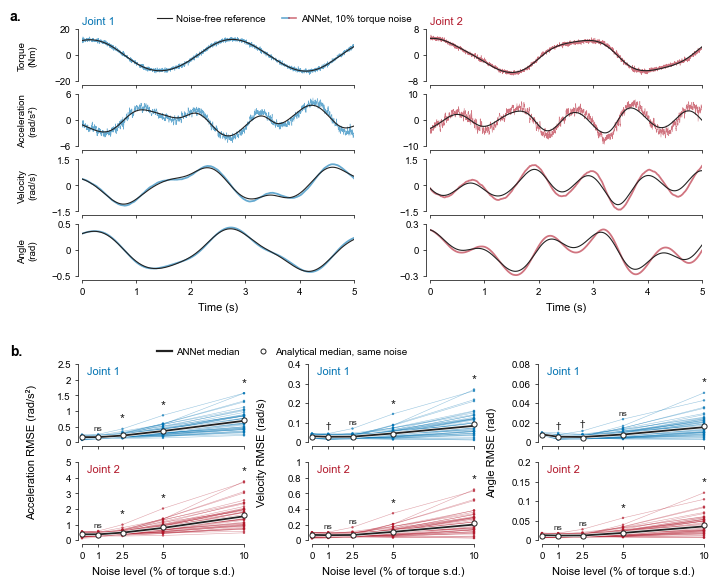

In [83]:
import matplotlib.patheffects as pe
from matplotlib.legend_handler import HandlerTuple
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# Fig. 8 plotting code (the same drawing in MAIN_RUN_ME_NEW.ipynb and FIG8.ipynb).
# a: example trajectory at one noise level, joint 1 (blue) on the left and joint 2
#    (red) on the right. From top to bottom: the gravitational torque that entered
#    the solver and the acceleration, velocity and angle that the solver with the
#    learned energy returned (colour), each with the noise-free reference (dark line).
# b: trajectory-wise RMSE of acceleration, velocity and angle against the level of
#    noise on the gravitational torques, joint 1 above joint 2. Each thin line is one
#    trajectory of the solver with the learned energy, the heavy line joins its
#    medians and open circles are the medians of the solver with the analytical
#    energy under the same noise. An asterisk marks a noise level whose errors are
#    higher than the noise-free errors and a dagger one whose errors are lower (both
#    FDR q < 0.05); 'ns' marks a level whose errors do not differ.
# The axis limits enclose every plotted value.
# -----------------------------------------------------------------------------
FIG8_BLUE = '#0072B2'
FIG8_RED = '#B2182B'
FIG8_NEUTRAL = '#222222'
FIG8_JOINTS = ['J1', 'J2']
FIG8_JOINT_COLORS = {'J1': FIG8_BLUE, 'J2': FIG8_RED}
# Rows of panel a: column suffix in the traces table, axis label
FIG8_TRACE_ROWS = [('g', 'Torque\n(Nm)'), ('ddq', 'Acceleration\n(rad/s\u00b2)'), ('dq', 'Velocity\n(rad/s)'), ('q', 'Angle\n(rad)')]
# Columns of panel b: quantity in the RMSE table, axis label
FIG8_QUANTITIES = [('acceleration', 'Acceleration RMSE (rad/s\u00b2)'), ('velocity', 'Velocity RMSE (rad/s)'), ('angle', 'Angle RMSE (rad)')]
FIG8_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def fig8_symmetric_limit(largest):
    # Smallest symmetric axis limit of the form 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8 x 10^k that encloses the data
    for exponent in range(-4, 4):
        for mantissa in (1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0):
            if mantissa * 10.0 ** exponent >= largest:
                return mantissa * 10.0 ** exponent
    raise ValueError('value outside the supported range')


def fig8_axis_top(maximum):
    # Smallest axis end on a 1-2-5 x 10^k tick step that encloses the data with at most five intervals
    for exponent in range(-5, 4):
        for mantissa in (1.0, 2.0, 5.0):
            step = mantissa * 10.0 ** exponent
            intervals = int(np.ceil(maximum / step - 1e-9))
            if intervals <= 5:
                return intervals * step, step
    raise ValueError('value outside the supported range')


def fig8_number(value, _=None):
    return f"{value:,g}".replace('-', '−')


def draw_fig8(rmse_table, level_stats_table, traces_table, figure_percent):
    """
    rmse_table:        long-form table with columns model, noise_percent, quantity, joint, trajectory, rmse.
    level_stats_table: one row per model, quantity, joint and noise level with the columns significant_fdr_0_05
                       and direction (errors at that level against the noise-free errors of the same solver).
    traces_table:      one row per time point of the example trajectory with the columns time_s, reference_*_j*
                       and, per solver and noise level, <solver>_<level>pct_<g, q, dq, ddq>_j*.
    figure_percent:    noise level (%) of the example trajectory of panel a.
    Returns the matplotlib figure (two panels, double-column width).
    """
    levels = np.asarray(sorted(float(percent) for percent in rmse_table['noise_percent'].unique()))
    assert levels[0] == 0.0 and figure_percent in levels

    def select(model_name, quantity, joint, percent):
        mask = ((rmse_table['model'] == model_name) & (rmse_table['quantity'] == quantity)
                & (rmse_table['joint'] == joint) & (rmse_table['noise_percent'] == percent))
        return rmse_table.loc[mask].sort_values('trajectory')['rmse'].to_numpy(dtype=float)

    # ---- geometry in inches, measured from the left and from the top of the canvas ----
    width, height = 7.2, 6.05
    fig = plt.figure(figsize=(width, height))

    def add_axes(left, top, span, tall):
        ax = fig.add_axes([left / width, 1.0 - (top + tall) / height, span / width, tall / height])
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_position(('outward', 3))
        ax.spines['bottom'].set_position(('outward', 3))
        ax.yaxis.set_major_formatter(FuncFormatter(fig8_number))
        ax.xaxis.set_major_formatter(FuncFormatter(fig8_number))
        return ax

    median_style = dict(color=FIG8_NEUTRAL, lw=1.3, solid_capstyle='butt',
                        path_effects=[pe.withStroke(linewidth=2.3, foreground='white')])
    circle_style = dict(facecolors='white', edgecolors=FIG8_NEUTRAL, linewidths=0.7)

    # ---- a: example trajectory, joint 1 on the left and joint 2 on the right ----
    time = traces_table['time_s'].to_numpy(dtype=float)
    a_top, a_row, a_gap = 0.42, 0.52, 0.13
    a_left = {'J1': 0.80, 'J2': 4.28}
    a_span = 2.72
    trace_axes = {}
    for joint in FIG8_JOINTS:
        color = FIG8_JOINT_COLORS[joint]
        for row, (name, label) in enumerate(FIG8_TRACE_ROWS):
            ax = add_axes(a_left[joint], a_top + row * (a_row + a_gap), a_span, a_row)
            trace_axes[(joint, name)] = ax
            # The traces are stored in single precision
            reference = traces_table[f"reference_{name}_{joint.lower()}"].to_numpy(dtype=np.float32).astype(float)
            noisy = traces_table[f"annet_{figure_percent:g}pct_{name}_{joint.lower()}"].to_numpy(dtype=np.float32).astype(float)
            ax.plot(time, noisy, color=color, lw=0.35 if name in ('g', 'ddq') else 1.3, alpha=0.6, zorder=2,
                    rasterized=name in ('g', 'ddq'))
            ax.plot(time, reference, color=FIG8_NEUTRAL, lw=0.8, zorder=3)
            limit = fig8_symmetric_limit(max(np.abs(noisy).max(), np.abs(reference).max()))
            assert max(np.abs(noisy).max(), np.abs(reference).max()) <= limit
            ax.set_xlim(time[0], 5.0)
            ax.set_ylim(-limit, limit)
            ax.set_xticks(np.arange(0.0, 5.5, 1.0))
            ax.set_yticks([-limit, 0, limit])
            if row < len(FIG8_TRACE_ROWS) - 1:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel('Time (s)')
            if joint == 'J1':
                ax.set_ylabel(label, fontsize=7, labelpad=3)
                ax.yaxis.set_label_coords(-0.165, 0.5)
        trace_axes[(joint, 'g')].text(0.0, 1.06, f"Joint {joint[1]}", transform=trace_axes[(joint, 'g')].transAxes, ha='left',
                                     va='bottom', fontsize=8, color=color)
    fig.legend(handles=[Line2D([0], [0], color=FIG8_NEUTRAL, lw=0.8),
                        (Line2D([0], [0], color=FIG8_BLUE, lw=1.2, alpha=0.6), Line2D([0], [0], color=FIG8_RED, lw=1.2, alpha=0.6))],
               labels=['Noise-free reference', f"ANNet, {figure_percent:g}% torque noise"],
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.0)}, loc='lower left',
               bbox_to_anchor=((a_left['J1'] + 0.75) / width, 1.0 - (a_top - 0.06) / height), ncol=2, frameon=False,
               handlelength=1.5, handletextpad=0.5, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- b: errors against the noise level, quantities in columns, joint 1 above joint 2 ----
    b_top = a_top + 4 * a_row + 3 * a_gap + 0.88
    b_row, b_gap = 0.78, 0.2
    b_left = [0.80, 3.10, 5.40]
    b_span = 1.62
    fan_axes = {}
    marks = []
    for column, (quantity, label) in enumerate(FIG8_QUANTITIES):
        for row, joint in enumerate(FIG8_JOINTS):
            color = FIG8_JOINT_COLORS[joint]
            ax = add_axes(b_left[column], b_top + row * (b_row + b_gap), b_span, b_row)
            fan_axes[(quantity, joint)] = ax
            annet = np.stack([select('ANNet', quantity, joint, percent) for percent in levels])
            analytical = np.asarray([np.median(select('analytical', quantity, joint, percent)) for percent in levels])
            # Head room above the data for the significance marks
            y_top, y_step = fig8_axis_top(1.3 * annet.max())
            assert (annet >= 0.0).all() and (annet <= y_top).all() and (analytical <= y_top).all()
            for i in range(annet.shape[1]):
                ax.plot(levels, annet[:, i], color=color, lw=0.4, alpha=0.4, zorder=2, clip_on=False)
            ax.scatter(np.repeat(levels, annet.shape[1]), annet.ravel(), color=color, s=3, edgecolors='none', alpha=0.7,
                       zorder=3, clip_on=False)
            ax.plot(levels, np.median(annet, axis=1), zorder=5, clip_on=False, **median_style)
            ax.scatter(levels, analytical, s=14, zorder=7, clip_on=False, **circle_style)
            # Difference from the noise-free errors after FDR correction: asterisk if higher, dagger if lower, 'ns' otherwise
            for k, percent in enumerate(levels[1:], start=1):
                stats_row = level_stats_table[(level_stats_table['model'] == 'ANNet') & (level_stats_table['quantity'] == quantity)
                                              & (level_stats_table['joint'] == joint) & (level_stats_table['noise_percent'] == percent)]
                assert len(stats_row) == 1
                significant = bool(stats_row['significant_fdr_0_05'].iloc[0])
                lower = str(stats_row['direction'].iloc[0]) == 'lower'
                mark = ('\u2020' if lower else '*') if significant else 'ns'
                marks.append((ax, annet[k], ax.text(percent, annet[k].max() + 0.04 * y_top, mark, ha='center', va='bottom',
                                                    fontsize={'*': 9, '\u2020': 7, 'ns': 6}[mark], color=FIG8_NEUTRAL)))
            ax.set_xlim(0.0, levels[-1])
            ax.set_ylim(0.0, y_top)
            ax.set_xticks(levels)
            ax.set_yticks(np.arange(0.0, y_top + 0.5 * y_step, y_step))
            if row == 0:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel('Noise level (% of torque s.d.)')
            ax.text(0.03, 0.97, f"Joint {joint[1]}", transform=ax.transAxes, ha='left', va='top', fontsize=8, color=color)
        fig.text((b_left[column] - 0.50) / width, 1.0 - (b_top + b_row + 0.5 * b_gap) / height, label, rotation=90,
                 ha='center', va='center', fontsize=8)
    fig.legend(handles=[Line2D([0], [0], color=FIG8_NEUTRAL, lw=1.6),
                        Line2D([0], [0], marker='o', linestyle='None', markersize=3.6, markerfacecolor='white',
                               markeredgecolor=FIG8_NEUTRAL, markeredgewidth=0.7)],
               labels=['ANNet median', 'Analytical median, same noise'], loc='lower left',
               bbox_to_anchor=((b_left[0] + 0.75) / width, 1.0 - (b_top - 0.08) / height), ncol=2, frameon=False,
               handlelength=1.5, handletextpad=0.5, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- panel labels ----
    for letter, top in (('a.', a_top), ('b.', b_top)):
        fig.text(0.08 / width, 1.0 - (top - 0.06) / height, letter, fontsize=10, fontweight='bold', ha='left', va='bottom')

    # The significance marks must stay inside the axes
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, values, mark in marks:
        box = mark.get_window_extent(renderer).transformed(ax.transData.inverted())
        assert box.y1 <= ax.get_ylim()[1], 'a significance mark of panel b leaves the axes'
        assert box.y0 >= values.max(), 'a significance mark of panel b meets the data'
    return fig


def save_fig8(fig, directory, name):
    # PDF (vector, editable text) and 600-dpi PNG at the canvas size, as in FIG8.ipynb
    for ext in ('pdf', 'png'):
        figure_path = os.path.join(directory, f"{name}.{ext}")
        fig.savefig(figure_path, facecolor='white')
        print(f"Saved {figure_path}")


# Draw Fig. 8 and save the PDF and PNG to the submission folder
fns_figure_percent = float(100.0 * FNS_FIGURE_NOISE_LEVEL)
with mpl.rc_context():
    mpl.rc_file_defaults()        # same starting point as the standalone notebook, whatever this kernel has set
    mpl.rcParams.update(FIG8_RC)
    fns_fig = draw_fig8(fns_rmse_df, fns_level_stats_df, fns_traces_df, fns_figure_percent)
    save_fig8(fns_fig, FNS_FIGURE_DIR, FNS_FIGURE_NAME)
    plt.show()

### Data package for Fig. 8

Following the packaging used for the other figures, the trajectory-wise RMSE values, the two statistics tables, the traces of the example trajectory, provenance metadata (source-file hashes, noise model, solver configuration, statistical settings) and a README are written into `FIG8.zip` in `SUBMISSION/FIGURES/DATA AND SCRIPTS/`. The standalone notebook `FIG8.ipynb` in the same folder regenerates the figure from this archive alone.

In [84]:
import json
import zipfile
from datetime import datetime, timezone

fns_package_path = os.path.join(FNS_PACKAGE_DIR, f"{FNS_FIGURE_NAME}.zip")

# Provenance: hashes of every artifact the figure and statistics were derived from
fns_source_paths = [FNS_MODEL_PATH, FNS_STATS_PATH, FNS_REFERENCE_PATH, FNS_ANALYTICAL_PATH, FNS_RESULTS_PATH,
                    FNS_RMSE_CSV_PATH, FNS_STATS_CSV_PATH, FNS_LEVEL_STATS_CSV_PATH, FNS_TRACES_CSV_PATH]
fns_source_files = {
    os.path.basename(path): {'sha256': fns_sha256_of_file(path), 'bytes': os.path.getsize(path)}
    for path in fns_source_paths if os.path.exists(path)
}

fns_metadata = {
    'created_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'description': ('Data package for manuscript Figure 8: accuracy of the closed-loop forward simulation '
                    'when Gaussian noise is added to the gravitational torques that enter the forward solver.'),
    'purpose': ('Measures how noise in the gravitational torques that enter the forward solver affects the simulated '
                'accelerations, velocities and angles.'),
    'data_derivation': (
        'Trajectory-wise RMSE values were produced by MAIN_RUN_ME_NEW.ipynb, Section 12, from the 50 initial states and '
        'Runge-Kutta reference trajectories of Section 6 (simulation_results_50trials_N16_B15_A10.pt) and the ANNet '
        'trained on 16,000 samples (model_16000.pth, stats_16000.pt). The noise is generated from the stated seed. '
        'Statistics were computed from the archived RMSE values.'
    ),
    'source_files': fns_source_files,
    'noise_model': {
        'distribution': 'zero-mean Gaussian, independent across the two joints and across solver steps',
        'perturbed_input': 'gravitational torque G(q) of the current simulated state, at every solver step',
        'standard_deviation': ('noise level times the standard deviation of the gravitational torque of that joint over '
                               'the noise-free reference trajectory (unbiased estimate over the 2,500 steps)'),
        'noise_levels_percent': [float(100.0 * level) for level in FNS_NOISE_LEVELS],
        'seed': int(FNS_NOISE_SEED),
        'seed_rule': 'trajectory i uses torch.Generator().manual_seed(seed + i); one standard-normal draw per '
                     'trajectory is reused for every noise level and for both solvers',
        'initial_conditions': 'exact initial angles and velocities of the reference trajectories (not perturbed)',
        'error_reference': 'noise-free fourth-order Runge-Kutta reference trajectories of Section 6',
    },
    'solver': fns_results['provenance']['config'],
    'solver_note': ('two-stage solver of Section 6 at every step: best of N candidate accelerations (zero, previous, and '
                    'uniform random within the bound), then Adam refinement of S + G . ddq + lambda ||ddq - ddq_prev||^2; '
                    'the random candidates are identical in every condition (same seed)'),
    'models': {
        'ANNet': 'forward solver with the learned Appell energy (network trained on 16,000 samples), as in Section 6',
        'analytical': ('the same solver with the analytical Appell energy, as in Section 7, under the same noise '
                       'realizations and the same candidate accelerations'),
    },
    'noise_free_analytical_largest_difference_from_section_7': fns_results['noise_free_analytical_largest_difference_from_section_7'],
    'test_set': {
        'file': os.path.basename(FNS_REFERENCE_PATH),
        'num_trajectories': int(fns_rmse_df['trajectory'].nunique()),
        'steps_per_trajectory': int(FNS_STEPS),
        'duration_s': float(FNS_DURATION),
        'reference': 'fourth-order Runge-Kutta solution of Section 6 at 2,500 equally spaced times over 5 s',
        'solver_step_s': float(FNS_DT_SIM),
    },
    'statistics': {
        'alpha': FNS_ALPHA,
        'normality_test': 'Shapiro-Wilk on each group',
        'primary_test_rule': 'one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test',
        'secondary_test': 'two-sided Wilcoxon signed-rank (paired by trajectory), with the same correction within each family',
        'solver_comparison': {
            'comparison': 'ANNet against the analytical energy for each quantity, joint and noise level (including no noise)',
            'multiple_comparison_correction': f"Benjamini-Hochberg FDR across the {len(fns_solver_stats_df)} comparisons",
            'num_significant': int(fns_solver_stats_df['significant_fdr_0_05'].sum()),
        },
        'noise_levels_against_no_noise': {
            'comparison': 'each noise level against no noise for each solver, quantity and joint',
            'multiple_comparison_correction': 'Benjamini-Hochberg FDR across the 24 comparisons of each solver',
            'num_significant': {model_name: int(fns_level_stats_df.loc[fns_level_stats_df['model'] == model_name, 'significant_fdr_0_05'].sum())
                                for model_name in FNS_MODELS},
            'num_significant_with_lower_error': {
                model_name: int(((fns_level_stats_df['model'] == model_name) & fns_level_stats_df['significant_fdr_0_05']
                                 & (fns_level_stats_df['direction'] == 'lower')).sum()) for model_name in FNS_MODELS},
        },
    },
    'example_trajectory': {
        'index': int(fns_example_trajectory),
        'noise_percent': float(fns_figure_percent),
        'selection_rule': ('trajectory whose errors with the learned energy at this noise level lie closest to the medians '
                           'of the six combinations of quantity and joint: smallest sum of |log(error / median error)|'),
    },
    'figure': {
        'noise_percent_of_panel_a': float(fns_figure_percent),
        'content': ('two panels, double-column width. a: example trajectory at the stated noise level, joint 1 on the left '
                    'and joint 2 on the right; from top to bottom, the gravitational torque that entered the solver and the '
                    'acceleration, velocity and angle returned by the solver with the learned energy (colour), each with the '
                    'noise-free reference (dark line). b, linear axes: trajectory-wise RMSE of acceleration, velocity and '
                    'angle against the noise level, joint 1 above joint 2; one thin line per trajectory of the solver with '
                    'the learned energy, the heavy line joins its medians and open circles mark the medians of the solver '
                    'with the analytical energy under the same noise; an asterisk marks a noise level whose errors are higher '
                    'than the noise-free errors of ANNet, a dagger one whose errors are lower (both FDR q < 0.05), and ns one '
                    'whose errors do not differ'),
        'axis_limits': 'every numeric axis ends on a labelled tick that encloses all plotted values',
    },
    'num_rmse_rows': int(len(fns_rmse_df)),
}

fns_readme_text = f"""{FNS_FIGURE_NAME} data package
=================

This archive contains the data required by {FNS_FIGURE_NAME}.ipynb to regenerate manuscript Figure 8.

Files:
- fig8_rmse_values.csv: trajectory-wise RMSE of the closed-loop forward simulation with the learned Appell energy (ANNet, trained on 16,000 samples) and with the analytical Appell energy, when both receive the same noise on the gravitational torques, on the 50 trajectories of the forward-dynamics test. Columns: model, noise_percent (0 for the noise-free simulation), quantity (angle, velocity or acceleration), unit, joint, trajectory, rmse, torque_sd_nm (standard deviation of the gravitational torque of that joint over the noise-free reference trajectory).
- fig8_solver_statistics.csv: per quantity, joint and noise level, the comparison of ANNet with the analytical energy: Shapiro-Wilk normality tests, primary test (one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test) with Benjamini-Hochberg FDR correction across the {len(fns_solver_stats_df)} comparisons, two-sided paired Wilcoxon signed-rank test with the same correction, medians, ratio of medians, median paired difference, Cliff's delta and the number of trajectories on which ANNet has the larger error.
- fig8_level_statistics.csv: per solver, quantity, joint and noise level, the comparison of the errors at that noise level with the noise-free errors of the same solver: the same tests with Benjamini-Hochberg FDR correction across the 24 comparisons of each solver, medians, ratio of medians, median paired difference, the direction of the change (higher or lower than without noise), Cliff's delta, the number of trajectories whose error rose, the error added by the noise (root of the difference of the squared errors, set to zero for a trajectory whose error with noise is the smaller one) and that error per percent of noise.
- fig8_example_traces.csv: the example trajectory at every time step (single precision). Columns: time_s; reference_g, reference_q, reference_dq and reference_ddq of both joints (noise-free gravitational torque, angle, velocity and acceleration); and, for each solver and noise level, the gravitational torque that entered the solver (g) and the simulated angle (q), velocity (dq) and acceleration (ddq) of both joints.
- fig8_metadata.json: source hashes, noise model, solver configuration, statistical settings, figure conventions, and provenance metadata.

The noise is zero-mean Gaussian, independent across joints and solver steps, added to the gravitational torque at every step of the solver, with a standard deviation equal to the stated percentage of the standard deviation of that torque over the noise-free reference trajectory. The initial angles and velocities are exact. Errors are measured against the noise-free Runge-Kutta reference. Panel a of the figure shows the example trajectory at {fns_figure_percent:g}% noise (joint 1 on the left, joint 2 on the right): the gravitational torque that entered the solver and the acceleration, velocity and angle that the solver with the learned energy returned, each with the noise-free reference. Panel b shows the RMSE of acceleration, velocity and angle against the noise level; each thin line is one trajectory of ANNet, the heavy line joins the ANNet medians, open circles mark the medians of the solver with the analytical energy under the same noise, an asterisk marks a noise level whose errors are higher than the noise-free errors after FDR correction, and a dagger one whose errors are lower.
"""


def write_fig8_package(package_path):
    with zipfile.ZipFile(package_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
        archive.writestr('fig8_rmse_values.csv', fns_rmse_df.to_csv(index=False))
        archive.writestr('fig8_solver_statistics.csv', fns_solver_stats_df.to_csv(index=False))
        archive.writestr('fig8_level_statistics.csv', fns_level_stats_df.to_csv(index=False))
        archive.writestr('fig8_example_traces.csv', fns_traces_df.to_csv(index=False))
        archive.writestr('fig8_metadata.json', json.dumps(fns_metadata, indent=2, allow_nan=False))
        archive.writestr(f'{FNS_FIGURE_NAME}_README.txt', fns_readme_text)
    print(f"Saved data package to {package_path}")
    with zipfile.ZipFile(package_path) as archive:
        for info in archive.infolist():
            print(f"  {info.filename:<28} {info.file_size:>9,} bytes")


write_fig8_package(fns_package_path)

Saved data package to ../SUBMISSION/FIGURES/DATA AND SCRIPTS/FIG8.zip
  fig8_rmse_values.csv           216,685 bytes
  fig8_solver_statistics.csv       9,508 bytes
  fig8_level_statistics.csv       17,453 bytes
  fig8_example_traces.csv      2,433,520 bytes
  fig8_metadata.json               6,930 bytes
  FIG8_README.txt                  3,475 bytes


# Section 13: Transfer of inverse-dynamics learning to forward dynamics

ANNet represents the dynamics by one function, the Appell energy, and uses it in both directions. Its gradient with respect to the accelerations gives the torques (inverse dynamics, Section 4), and its minimization gives the accelerations (forward dynamics, Section 6). If both computations rest on the same learned function, learning in one direction must carry over to the other. This section tests that prediction. The pendulum is perturbed by changing the masses of the segments, their lengths, or both. The network trained on the original pendulum is then adapted to the perturbed pendulum with the inverse-dynamics loss of Section 3 alone, that is, with the error between the gradient of the network and the torques of the perturbed pendulum. No forward simulation, acceleration target or forward loss enters the adaptation. The forward solver of Section 6 is run on the perturbed pendulum with the network before the adaptation, at the stored epochs of the adaptation and after it. As a control, the network receives the same training on fresh samples of the unchanged pendulum, which shows what the continued training alone does to both computations.

The network architecture, the optimizer, the learning rate, the batch size and the sampling ranges are those of Sections 2 and 3, and the forward solver uses the configuration selected in Section 6 ($N = 16$ candidate accelerations within $\pm 15$ rad/s$^2$, 10 Adam refinement steps, $\lambda = 0.1$, five-step stabilization at $t = 0$, semi-implicit Euler, 2 ms step, seed 23). The 50 simulations start from the initial states of Section 6 and last 5 s. The errors are measured against Runge-Kutta reference trajectories of the simulated pendulum, and the same solver with the analytical Appell energy of that pendulum gives the error that remains when the energy is exact (as in Section 7). The gravitational torque that enters the solver is that of the simulated pendulum in every condition, because the generalized force is an input of forward dynamics; the network learns the inertial and velocity-dependent terms only. The result is exported as Fig. 9 together with its data package.

The section requires the library import cell and the definition cells of Sections 1 to 4 and reads the cached files `model_16000.pth`, `stats_16000.pt` and `simulation_results_50trials_N16_B15_A10.pt`. The names of its output files start with `transfer_`. The adaptation and the simulations are skipped when their output files already exist and were produced from the current model, pendulums and settings.

### Constants

In [85]:
# Transfer of inverse-dynamics learning to forward dynamics: dependencies, constants and file paths.

_tl_required_names = [
    # imports (Libraries import cell)
    'os', 'time', 'np', 'pd', 'torch', 'optim', 'autograd', 'DataLoader', 'scipy_stats', 'multipletests', 'mpl', 'plt', 'Line2D',
    # analytical kernels and numeric helpers (Sections 1 and 4)
    'TORCH_DTYPE', 'TORCH_EPS', 'as_f32_tensor', 'compute_S_ground_truth_eager', 'compute_tau_ground_truth_eager',
    '_gravity_vector_torch', '_bias_vector_torch',
    # physical parameters, batch size and device (Section 2)
    'PARAMS', 'BATCH_SIZE', 'device',
    # training hyperparameters, network architecture and physics-informed loss (Section 3)
    'LR', 'NUM_NODE_L1', 'NUM_NODE_L2', 'NUM_NODE_L3', 'NUM_NODE_L4', 'GibbsAppellNet', 'compute_force_loss',
]
_tl_missing_names = [name for name in _tl_required_names if name not in globals()]
if _tl_missing_names:
    raise RuntimeError(
        "Run the library import cell and the definition cells of Sections 1 to 4 first (analytical kernels, physical "
        "parameters, device, training hyperparameters, network architecture, physics-informed loss, forward-dynamics "
        f"kernels). Missing names: {_tl_missing_names}"
    )

# Training-set size of the ANNet used for all downstream analyses; adaptation starts from its weights
TL_N_SAMPLES = 16000

# Plants. The original plant is the one of Section 2; each perturbed plant changes the masses (kg), the
# lengths (m) or both. The last entry repeats the original plant: the network receives the same adaptation on
# fresh samples of the unchanged plant, which shows the effect of the continued training alone (control).
# The keys are used in file contents and tables, the labels in the figure.
TL_ORIGINAL_PLANT = {key: float(PARAMS[key]) for key in ('m1', 'm2', 'l1', 'l2')}
TL_PLANTS = {
    'mass':        {'m1': 1.2, 'm2': 0.8, 'l1': 1.0, 'l2': 1.0},
    'length':      {'m1': 1.0, 'm2': 1.0, 'l1': 0.9, 'l2': 1.1},
    'mass_length': {'m1': 1.2, 'm2': 0.8, 'l1': 0.9, 'l2': 1.1},
    'unchanged':   dict(TL_ORIGINAL_PLANT),
}
TL_CONTROL_PLANT = 'unchanged'
TL_PERTURBED_PLANTS = tuple(key for key in TL_PLANTS if key != TL_CONTROL_PLANT)
# Order and labels of the plants in the figure
TL_PLANT_LABELS = {'unchanged': 'None', 'mass': 'Mass', 'length': 'Length', 'mass_length': 'Mass and length'}

# Adaptation: the inverse-dynamics loss of Section 3 on samples of the perturbed plant, with the optimizer,
# learning rate and batch size of Section 3 and the sampling ranges of Section 2. No forward simulation enters.
TL_ADAPT_SAMPLES = 16000
TL_ADAPT_EPOCHS = 300
TL_ADAPT_LR = LR
TL_ADAPT_BATCH_SIZE = BATCH_SIZE
TL_TRAIN_FRACTION = 0.8
# Epochs at which the weights are stored (0 = the network before adaptation)
TL_CHECKPOINT_EPOCHS = (0, 1, 3, 10, 30, 100, 300)
# Seeds of the adaptation data and of the mini-batch order; plant i uses seed + i
TL_DATA_SEED = 41
TL_TRAIN_SEED = 43
# Sampling ranges of the training states (Section 2)
TL_RANGE_Q = float(torch.pi / 2)
TL_RANGE_DQ = 5.0
TL_RANGE_DDQ = 20.0

# Simulation protocol of Section 6 (closed-loop simulation with the learned energy)
TL_SEED = 23
TL_NUM_TRAJS = 50
TL_DT_SIM = 0.002
TL_DURATION = 5.0
TL_STEPS = int(TL_DURATION / TL_DT_SIM)
TL_GRAVITY = 9.81

# Solver configuration selected for the learned energy (Section 6 / Fig. 6)
TL_SAMPLED_ACCELERATION_VECTORS = 16
TL_BOUND = 15.0
TL_ADAM_STEPS = 10
TL_ADAM_LR = 0.1
TL_LAMBDA_REG = 0.1
TL_WARMUP_STEPS = 5
TL_CONFIG_TAG = f"N{TL_SAMPLED_ACCELERATION_VECTORS}_B{TL_BOUND:g}_A{TL_ADAM_STEPS}"

# Guard against silent divergence from Section 6 if its constants are defined in this kernel
for _tl_name, _tl_value in (
    ('BEST_REALTIME_SAMPLED_ACCELERATION_VECTORS', TL_SAMPLED_ACCELERATION_VECTORS),
    ('BEST_REALTIME_BOUND', TL_BOUND),
    ('BEST_REALTIME_ADAM_STEPS', TL_ADAM_STEPS),
    ('DT_SIM', TL_DT_SIM),
    ('NUM_TRAJS', TL_NUM_TRAJS),
    ('LAMBDA_REG', TL_LAMBDA_REG),
    ('WARMUP_STEPS', TL_WARMUP_STEPS),
    ('DURATION', TL_DURATION),
    ('STEPS', TL_STEPS),
):
    if _tl_name in globals() and globals()[_tl_name] != _tl_value:
        raise RuntimeError(f"{_tl_name} = {globals()[_tl_name]} in this kernel, but this section uses {_tl_value}.")

# Forward simulations. Every plant is simulated with the network at every stored epoch (epoch 0 is the
# network before adaptation, the last epoch the adapted network) and with the analytical Appell energy of that plant.
# The plant below is the one shown in panels a and b of the figure.
TL_FIGURE_PLANT = 'mass_length'

# Input files (produced in Sections 3 and 6) and output files of this section
TL_BASE_PATH = output_dir if 'output_dir' in globals() else '.'
TL_MODEL_PATH           = os.path.join(TL_BASE_PATH, f"model_{TL_N_SAMPLES}.pth")
TL_STATS_PATH           = os.path.join(TL_BASE_PATH, f"stats_{TL_N_SAMPLES}.pt")
TL_REFERENCE_PATH       = os.path.join(TL_BASE_PATH, f"simulation_results_50trials_{TL_CONFIG_TAG}.pt")
TL_CHECKPOINTS_PATH     = os.path.join(TL_BASE_PATH, f"transfer_checkpoints_model_{TL_N_SAMPLES}.pt")
TL_RESULTS_PATH         = os.path.join(TL_BASE_PATH, f"transfer_results_{TL_CONFIG_TAG}.pt")
TL_RMSE_CSV_PATH        = os.path.join(TL_BASE_PATH, f"transfer_rmse_{TL_CONFIG_TAG}.csv")
TL_HISTORY_CSV_PATH     = os.path.join(TL_BASE_PATH, f"transfer_adaptation_history_model_{TL_N_SAMPLES}.csv")
TL_STATS_CSV_PATH       = os.path.join(TL_BASE_PATH, f"transfer_statistics_{TL_CONFIG_TAG}.csv")
TL_TRACES_CSV_PATH      = os.path.join(TL_BASE_PATH, f"transfer_example_traces_{TL_CONFIG_TAG}.csv")

# Destinations of the figure and its data package (SUBMISSION tree).
# The notebook is expected to run from SIMULATIONS/; if the tree is not found,
# the files are written next to the notebook instead.
TL_FIGURE_NAME = 'FIG9'
_tl_repo_root = os.path.normpath(os.path.join(TL_BASE_PATH, os.pardir))
TL_FIGURE_DIR  = os.path.join(_tl_repo_root, 'SUBMISSION', 'FIGURES', 'PDF AND PNG')
TL_PACKAGE_DIR = os.path.join(_tl_repo_root, 'SUBMISSION', 'FIGURES', 'DATA AND SCRIPTS')
for _tl_dir_name in ('TL_FIGURE_DIR', 'TL_PACKAGE_DIR'):
    if not os.path.isdir(globals()[_tl_dir_name]):
        print(f"Warning: {globals()[_tl_dir_name]} not found; {_tl_dir_name} falls back to '{TL_BASE_PATH}'.")
        globals()[_tl_dir_name] = TL_BASE_PATH

print(f"ANNet model:               {TL_MODEL_PATH}")
print(f"Initial states:            {TL_REFERENCE_PATH}")
print(f"Original plant:            {TL_ORIGINAL_PLANT}")
for _tl_key in TL_PERTURBED_PLANTS:
    print(f"Perturbed plant {_tl_key + ':':<12} {TL_PLANTS[_tl_key]}")
print(f"Control {(TL_CONTROL_PLANT + ':'):<20} {TL_PLANTS[TL_CONTROL_PLANT]} (original plant, same adaptation)")
print(f"Adaptation:                {TL_ADAPT_SAMPLES} samples, {TL_ADAPT_EPOCHS} epochs, learning rate {TL_ADAPT_LR:.6g}, "
      f"batch size {TL_ADAPT_BATCH_SIZE}, weights stored at epochs {list(TL_CHECKPOINT_EPOCHS)}")
print(f"Solver configuration:      {TL_CONFIG_TAG}, lr {TL_ADAM_LR}, lambda {TL_LAMBDA_REG}, "
      f"warm-up {TL_WARMUP_STEPS}, dt {TL_DT_SIM} s, {TL_STEPS} steps")
print(f"Adapted weights:           {TL_CHECKPOINTS_PATH}")
print(f"Simulation results:        {TL_RESULTS_PATH}")
print(f"Figure directory:          {TL_FIGURE_DIR}")
print(f"Data package directory:    {TL_PACKAGE_DIR}")

ANNet model:               ./model_16000.pth
Initial states:            ./simulation_results_50trials_N16_B15_A10.pt
Original plant:            {'m1': 1.0, 'm2': 1.0, 'l1': 1.0, 'l2': 1.0}
Perturbed plant mass:        {'m1': 1.2, 'm2': 0.8, 'l1': 1.0, 'l2': 1.0}
Perturbed plant length:      {'m1': 1.0, 'm2': 1.0, 'l1': 0.9, 'l2': 1.1}
Perturbed plant mass_length: {'m1': 1.2, 'm2': 0.8, 'l1': 0.9, 'l2': 1.1}
Control unchanged:           {'m1': 1.0, 'm2': 1.0, 'l1': 1.0, 'l2': 1.0} (original plant, same adaptation)
Adaptation:                16000 samples, 300 epochs, learning rate 0.00113165, batch size 64, weights stored at epochs [0, 1, 3, 10, 30, 100, 300]
Solver configuration:      N16_B15_A10, lr 0.1, lambda 0.1, warm-up 5, dt 0.002 s, 2500 steps
Adapted weights:           ./transfer_checkpoints_model_16000.pt
Simulation results:        ./transfer_results_N16_B15_A10.pt
Figure directory:          ../SUBMISSION/FIGURES/PDF AND PNG
Data package directory:    ../SUBMISSION/FIGURES/DAT

### Pendulums, adaptation and forward solver

Three perturbed pendulums are used. The first changes the masses (1.2 and 0.8 kg instead of 1 and 1 kg), the second the lengths (0.9 and 1.1 m instead of 1 and 1 m), and the third both. A fourth entry repeats the original pendulum and serves as the control. It goes through the same adaptation and the same simulations. The training states of each pendulum are drawn uniformly from the ranges of Section 2, and their torques follow from the analytical inverse dynamics of that pendulum. The constants that standardize the inputs of the network and de-standardize its output are those of the pretrained network and stay fixed, so that the adaptation changes the weights only.

The adaptation minimizes the physics-informed loss of Section 3 (mean squared error between the gradient of the network with respect to the accelerations and the torques of the perturbed pendulum) with Adam, the learning rate and the batch size of Section 3, starting from the weights of the network trained on 16,000 samples. The weights are stored before the adaptation and after 1, 3, 10, 30, 100 and 300 epochs. No weights are selected by their validation error; the network after adaptation is the one of the last epoch.

The forward solver reproduces the two-stage solver of Sections 6 and 7 step by step (candidate search over $N = 16$ accelerations, 10 Adam refinement steps, temporal regularizer, semi-implicit Euler update). The gravitational torque that enters the objective is that of the simulated pendulum, as the generalized force is an input of forward dynamics. The energy in the objective is either the learned energy (the network with a given set of weights) or the analytical Appell energy of the pendulum.

In [86]:
_tl_g = as_f32_tensor(TL_GRAVITY, device=device)

# Standardization constants of the pretrained network. They stay fixed during adaptation,
# so that only the weights of the network change.
_tl_model_stats = torch.load(TL_STATS_PATH, map_location='cpu')
tl_x_mean = torch.as_tensor(_tl_model_stats['X_mean'], dtype=TORCH_DTYPE, device=device)
tl_x_std = torch.as_tensor(_tl_model_stats['X_std'], dtype=TORCH_DTYPE, device=device)
tl_s_mean = torch.as_tensor(_tl_model_stats['S_mean'], dtype=TORCH_DTYPE, device=device)
tl_s_std = torch.as_tensor(_tl_model_stats['S_std'], dtype=TORCH_DTYPE, device=device)
tl_inv_x_std = 1.0 / (tl_x_std + TORCH_EPS)
tl_chain_scale = tl_s_std / (tl_x_std[4:6] + TORCH_EPS)


def tl_plant_tensors(plant):
    """Masses and lengths of a plant as tensors, in the argument order of the analytical kernels."""
    return tuple(as_f32_tensor(plant[key], device=device) for key in ('m1', 'm2', 'l1', 'l2'))


def tl_gravitational_torque(q, plant_t):
    """Gravitational torque G(q) of both joints of a plant for one state or a batch of states (q: [..., 2])."""
    return _gravity_vector_torch(q[..., 0], q[..., 1], *plant_t, _tl_g)


def tl_true_acceleration(q, dq, plant_t):
    """
    Accelerations of a plant under gravity alone, M(q) ddq = -(C(q, dq) + G(q)), with the mass matrix, bias vector
    and gravity vector of Section 4, for one state or a batch of states (q, dq: [..., 2]).
    """
    m1, m2, l1, l2 = plant_t
    cos_q2 = torch.cos(q[..., 1])
    m11 = l1.square() * (m1 + m2) + 2.0 * l1 * l2 * m2 * cos_q2 + l2.square() * m2
    m12 = l2 * m2 * (l1 * cos_q2 + l2)
    m22 = (l2.square() * m2).expand_as(m11)
    mass_matrix = torch.stack((torch.stack((m11, m12), dim=-1), torch.stack((m12, m22), dim=-1)), dim=-2)
    bias = _bias_vector_torch(q[..., 0], q[..., 1], dq[..., 0], dq[..., 1], m1, m2, l1, l2)
    rhs = -(bias + tl_gravitational_torque(q, plant_t))
    return torch.linalg.solve(mass_matrix, rhs.unsqueeze(-1)).squeeze(-1)


def tl_true_torque(q, dq, ddq, plant_t):
    """Analytical inverse dynamics of a plant: torque of both joints for the given motion."""
    return torch.stack(compute_tau_ground_truth_eager(q[..., 0], q[..., 1], dq[..., 0], dq[..., 1],
                                                      ddq[..., 0], ddq[..., 1], *plant_t), dim=-1)


def tl_reference_trajectories(init_q, init_dq, time_grid, plant_t):
    """
    Fourth-order Runge-Kutta solution of a plant from the given initial states on the time grid of Section 6,
    for all trajectories at once (init_q, init_dq: [n, 2]). Returns q, dq and ddq, each [n, steps, 2].
    """
    def derivative(state):
        return torch.cat((state[:, 2:], tl_true_acceleration(state[:, :2], state[:, 2:], plant_t)), dim=1)

    state = torch.cat((init_q, init_dq), dim=1).to(device=device, dtype=TORCH_DTYPE)
    time_grid = time_grid.to(device=device, dtype=TORCH_DTYPE)
    states = torch.empty(time_grid.numel(), *state.shape, dtype=TORCH_DTYPE, device=device)
    states[0] = state
    for i in range(time_grid.numel() - 1):
        dt = time_grid[i + 1] - time_grid[i]
        k1 = derivative(state)
        k2 = derivative(state + 0.5 * dt * k1)
        k3 = derivative(state + 0.5 * dt * k2)
        k4 = derivative(state + dt * k3)
        state = state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        states[i + 1] = state
    states = states.transpose(0, 1).contiguous()
    q, dq = states[..., :2], states[..., 2:]
    return q, dq, tl_true_acceleration(q, dq, plant_t)


def tl_new_network(state_dict):
    """Network of Section 3 with the given weights."""
    model = GibbsAppellNet().to(device)
    model.load_state_dict(state_dict)
    return model


def tl_frozen_network(state_dict):
    """Network with the given weights for inference only."""
    model = tl_new_network(state_dict)
    model.eval()
    for param in model.parameters():
        param.requires_grad_(False)
    return model


def tl_copy_state(model):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def tl_predict_torque(model, q, dq, ddq):
    """Inverse dynamics of the network: gradient of the learned energy with respect to the accelerations."""
    x = ((torch.cat((q, dq, ddq), dim=-1) - tl_x_mean) * tl_inv_x_std).detach().requires_grad_(True)
    grads = autograd.grad(model(x).sum(), x)[0]
    return (grads[..., 4:6] * tl_chain_scale).detach()


class TLAdaptationData(torch.utils.data.Dataset):
    """
    Uniform samples of angle, velocity and acceleration within the ranges of Section 2 with the torques that the
    given plant requires for them. The inputs are standardized with the constants of the pretrained network.
    """
    def __init__(self, n_samples, plant_t, seed):
        generator = torch.Generator().manual_seed(seed)
        q = (2.0 * torch.rand((n_samples, 2), generator=generator, dtype=TORCH_DTYPE) - 1.0) * TL_RANGE_Q
        dq = (2.0 * torch.rand((n_samples, 2), generator=generator, dtype=TORCH_DTYPE) - 1.0) * TL_RANGE_DQ
        ddq = (2.0 * torch.rand((n_samples, 2), generator=generator, dtype=TORCH_DTYPE) - 1.0) * TL_RANGE_DDQ
        q, dq, ddq = q.to(device), dq.to(device), ddq.to(device)
        self.tau = tl_true_torque(q, dq, ddq, plant_t)
        self.X = (torch.cat((q, dq, ddq), dim=1) - tl_x_mean) * tl_inv_x_std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.tau[idx]


def tl_validation_loss(model, loader):
    """Mean of the physics-informed loss over the batches of a loader (as in Section 3)."""
    model.eval()
    total = 0.0
    for X_batch, tau_batch in loader:
        total += compute_force_loss(model, X_batch.to(device).requires_grad_(True), tau_batch.to(device), tl_chain_scale).item()
    return total / len(loader)


def tl_adapt(pretrained_state, plant, data_seed, train_seed):
    """
    Adaptation to one plant with the inverse-dynamics loss only. Returns the weights at the stored epochs and the
    history of the training and validation losses (mean squared torque error, Nm^2).
    """
    dataset = TLAdaptationData(TL_ADAPT_SAMPLES, tl_plant_tensors(plant), data_seed)
    split = int(TL_TRAIN_FRACTION * len(dataset))
    torch.manual_seed(train_seed)
    train_loader = DataLoader(torch.utils.data.Subset(dataset, range(0, split)), batch_size=TL_ADAPT_BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(torch.utils.data.Subset(dataset, range(split, len(dataset))), batch_size=TL_ADAPT_BATCH_SIZE, shuffle=False, num_workers=0)

    model = tl_new_network(pretrained_state)
    optimizer = optim.Adam(model.parameters(), lr=TL_ADAPT_LR)
    checkpoints = {0: tl_copy_state(model)}
    history = [{'epoch': 0, 'train_loss': float('nan'), 'validation_loss': tl_validation_loss(model, test_loader)}]
    start = time.perf_counter()
    for epoch in range(1, TL_ADAPT_EPOCHS + 1):
        model.train()
        total = 0.0
        for X_batch, tau_batch in train_loader:
            optimizer.zero_grad()
            loss = compute_force_loss(model, X_batch.to(device).requires_grad_(True), tau_batch.to(device), tl_chain_scale)
            loss.backward()
            optimizer.step()
            total += loss.item()
        history.append({'epoch': epoch, 'train_loss': total / len(train_loader), 'validation_loss': tl_validation_loss(model, test_loader)})
        if epoch in TL_CHECKPOINT_EPOCHS:
            checkpoints[epoch] = tl_copy_state(model)
            print(f"    epoch {epoch:4d} | train {history[-1]['train_loss']:.6f} | validation {history[-1]['validation_loss']:.6f} "
                  f"| {time.perf_counter() - start:.0f} s")
    return checkpoints, history, time.perf_counter() - start


def tl_network_energy(model):
    """Learned Appell energy in physical units for one state and one or several accelerations (as in Section 6)."""
    def energy(q_t, dq_t, ddq):
        if ddq.dim() == 1:
            x_in = torch.cat((q_t, dq_t, ddq))
            return model(((x_in - tl_x_mean) * tl_inv_x_std).unsqueeze(0)).squeeze() * tl_s_std + tl_s_mean
        q_batch = q_t.unsqueeze(0).expand(ddq.shape[0], -1)
        dq_batch = dq_t.unsqueeze(0).expand(ddq.shape[0], -1)
        x_batch = torch.cat((q_batch, dq_batch, ddq), dim=1)
        return model((x_batch - tl_x_mean) * tl_inv_x_std).squeeze(-1) * tl_s_std + tl_s_mean
    return energy


def tl_analytical_energy(plant_t):
    """Analytical Appell energy of a plant (as in Section 7)."""
    def energy(q_t, dq_t, ddq):
        return compute_S_ground_truth_eager(q_t[0], q_t[1], dq_t[0], dq_t[1], ddq[..., 0], ddq[..., 1], *plant_t)
    return energy


def tl_make_objective(energy):
    """Objective J = S + G . ddq + lambda ||ddq - ddq_prev||^2 of the forward solver for a given energy."""
    def objective(q_t, dq_t, ddq, prev_ddq_t, g_vec_t):
        work_term = (ddq * g_vec_t).sum(dim=-1)
        reg_term = TL_LAMBDA_REG * ((ddq - prev_ddq_t) ** 2).sum(dim=-1)
        return energy(q_t, dq_t, ddq) + work_term + reg_term
    return objective


def tl_solve_acceleration(objective, q_t, dq_t, prev_ddq_t, g_vec_t, candidate_buffer):
    """Two-stage solver of Section 6: coarse candidate search, then Adam refinement."""
    with torch.no_grad():
        candidate_buffer.uniform_(-TL_BOUND, TL_BOUND)
        candidate_buffer[0].zero_()
        candidate_buffer[1].copy_(prev_ddq_t)
        costs = objective(q_t, dq_t, candidate_buffer, prev_ddq_t, g_vec_t)
        best_guess = candidate_buffer[torch.argmin(costs)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([ddq_opt], lr=TL_ADAM_LR)
    for _ in range(TL_ADAM_STEPS):
        optimizer.zero_grad(set_to_none=True)
        loss = objective(q_t, dq_t, ddq_opt, prev_ddq_t, g_vec_t)
        loss.backward()
        optimizer.step()
    return ddq_opt.detach()


def tl_rollout(objective, q_init, dq_init, plant_t):
    """
    Closed-loop rollout from one initial state. The solver receives the gravitational torque of the given plant
    at the current simulated state. Returns q, dq and ddq, each [TL_STEPS, 2].
    """
    candidate_buffer = torch.empty(TL_SAMPLED_ACCELERATION_VECTORS, 2, dtype=TORCH_DTYPE, device=device)
    q_sim = torch.empty(TL_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    dq_sim = torch.empty(TL_STEPS, 2, dtype=TORCH_DTYPE, device=device)
    ddq_sim = torch.empty(TL_STEPS, 2, dtype=TORCH_DTYPE, device=device)

    q_curr = q_init.clone()
    dq_curr = dq_init.clone()
    prev_acc = torch.zeros(2, dtype=TORCH_DTYPE, device=device)
    q_sim[0].copy_(q_curr)
    dq_sim[0].copy_(dq_curr)

    for i in range(TL_STEPS):
        g_vec = tl_gravitational_torque(q_curr, plant_t)
        if i == 0:
            # Stabilization loop for the temporal regularizer at t = 0 (as in Section 6)
            for _ in range(TL_WARMUP_STEPS):
                prev_acc = tl_solve_acceleration(objective, q_curr, dq_curr, prev_acc, g_vec, candidate_buffer)

        ddq_curr = tl_solve_acceleration(objective, q_curr, dq_curr, prev_acc, g_vec, candidate_buffer)
        ddq_sim[i].copy_(ddq_curr)
        prev_acc = ddq_curr

        # Semi-implicit Euler update
        dq_curr = dq_curr + TL_DT_SIM * ddq_curr
        q_curr = q_curr + TL_DT_SIM * dq_curr
        if i + 1 < TL_STEPS:
            q_sim[i + 1].copy_(q_curr)
            dq_sim[i + 1].copy_(dq_curr)
    return q_sim, dq_sim, ddq_sim

### Adaptation with the inverse-dynamics loss

For each pendulum, 16,000 states are sampled (80% for training, 20% for validation) and the pretrained network is trained for 300 epochs on the torques of that pendulum. The validation loss is the same loss on the held-out samples. While the adaptation runs, the cell prints the training and validation losses at the stored epochs. It then prints the root of the validation loss at every stored epoch, which is the root-mean-square torque error on the held-out samples in Nm.

In [87]:
import hashlib


def tl_sha256_of_file(path, chunk_size=1 << 20):
    digest = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


def tl_adaptation_provenance():
    """Hashes of the input files and the settings; stored weights are reused only if all of them match."""
    return {
        'model_sha256': tl_sha256_of_file(TL_MODEL_PATH),
        'stats_sha256': tl_sha256_of_file(TL_STATS_PATH),
        'plants': {key: dict(plant) for key, plant in TL_PLANTS.items()},
        'adapt_samples': TL_ADAPT_SAMPLES,
        'adapt_epochs': TL_ADAPT_EPOCHS,
        'adapt_lr': float(TL_ADAPT_LR),
        'adapt_batch_size': TL_ADAPT_BATCH_SIZE,
        'train_fraction': float(TL_TRAIN_FRACTION),
        'checkpoint_epochs': list(TL_CHECKPOINT_EPOCHS),
        'data_seed': TL_DATA_SEED,
        'train_seed': TL_TRAIN_SEED,
        'sampling_ranges': [TL_RANGE_Q, TL_RANGE_DQ, TL_RANGE_DDQ],
    }


def tl_run_adaptation():
    pretrained_state = torch.load(TL_MODEL_PATH, map_location='cpu')
    adaptation = {'checkpoints': {}, 'history': {}, 'seconds': {}, 'provenance': tl_adaptation_provenance()}
    for index, (key, plant) in enumerate(TL_PLANTS.items()):
        print(f"  Plant '{key}' {plant}: {TL_ADAPT_SAMPLES} samples, {TL_ADAPT_EPOCHS} epochs")
        checkpoints, history, seconds = tl_adapt(pretrained_state, plant, TL_DATA_SEED + index, TL_TRAIN_SEED + index)
        adaptation['checkpoints'][key] = checkpoints
        adaptation['history'][key] = history
        adaptation['seconds'][key] = seconds
        print(f"    done in {seconds:.0f} s; validation loss {history[0]['validation_loss']:.4f} before adaptation, "
              f"{history[-1]['validation_loss']:.6f} after {TL_ADAPT_EPOCHS} epochs (Nm^2)")
    return adaptation


def tl_load_cached_adaptation():
    """Returns the stored weights only if they were computed from the current input files and settings."""
    if not os.path.exists(TL_CHECKPOINTS_PATH):
        return None
    cached = torch.load(TL_CHECKPOINTS_PATH, map_location='cpu')
    if cached.get('provenance') == tl_adaptation_provenance():
        return cached
    print(f"Existing weights '{TL_CHECKPOINTS_PATH}' were computed from different input files or settings; adapting again.")
    return None


tl_adaptation = tl_load_cached_adaptation()
if tl_adaptation is not None:
    print(f"Found existing adapted weights: '{TL_CHECKPOINTS_PATH}' (matching the current inputs and settings) -- loading instead of adapting again.")
else:
    print(f"Adapting the network trained on {TL_N_SAMPLES} samples to {len(TL_PERTURBED_PLANTS)} perturbed plants and to the unchanged "
          "plant (inverse-dynamics loss only)...")
    tl_adaptation = tl_run_adaptation()
    torch.save(tl_adaptation, TL_CHECKPOINTS_PATH)
    print(f"Saved the adapted weights to '{TL_CHECKPOINTS_PATH}'.")

# Validation error (root of the mean squared torque error over held-out samples of each plant) at the stored epochs
print("Validation RMSE of the torque (Nm) at the stored epochs:")
for _tl_key in TL_PLANTS:
    _tl_history = {row['epoch']: row['validation_loss'] for row in tl_adaptation['history'][_tl_key]}
    print(f"  {_tl_key:<12} " + ", ".join(f"epoch {epoch}: {_tl_history[epoch] ** 0.5:.4f}" for epoch in TL_CHECKPOINT_EPOCHS))

Adapting the network trained on 16000 samples to 3 perturbed plants and to the unchanged plant (inverse-dynamics loss only)...
  Plant 'mass' {'m1': 1.2, 'm2': 0.8, 'l1': 1.0, 'l2': 1.0}: 16000 samples, 300 epochs
    epoch    1 | train 0.828647 | validation 0.007314 | 0 s
    epoch    3 | train 0.003085 | validation 0.002468 | 1 s
    epoch   10 | train 0.002513 | validation 0.002075 | 2 s
    epoch   30 | train 0.022866 | validation 0.020025 | 5 s
    epoch  100 | train 0.007351 | validation 0.005191 | 18 s
    epoch  300 | train 0.016640 | validation 0.017961 | 54 s
    done in 54 s; validation loss 37.7029 before adaptation, 0.017961 after 300 epochs (Nm^2)
  Plant 'length' {'m1': 1.0, 'm2': 1.0, 'l1': 0.9, 'l2': 1.1}: 16000 samples, 300 epochs
    epoch    1 | train 0.358410 | validation 0.018130 | 0 s
    epoch    3 | train 0.010916 | validation 0.012860 | 1 s
    epoch   10 | train 0.018296 | validation 0.012224 | 2 s
    epoch   30 | train 0.025755 | validation 0.027401 | 6 s
 

### Closed-loop simulations

The initial states and the time grid are read from the saved results of Section 6. For every pendulum, the Runge-Kutta reference trajectories are computed from those initial states with the equations of motion of that pendulum (when the simulations run, the cell prints the largest angle, velocity and acceleration of each pendulum, which lie inside the sampling ranges of Section 2 and inside the acceleration bound of the solver). The torque error of the network is then measured on the reference trajectories of each pendulum at every stored epoch, against the analytical inverse dynamics of that pendulum.

The forward solver is run on each of the four pendulums with the network at every stored epoch of the adaptation, from the pretrained weights (epoch 0, before adaptation) to the weights after 300 epochs (after adaptation), which gives the time course of the forward error during the adaptation, and with the analytical energy of that pendulum. Every condition uses the 50 trajectories and the same candidate accelerations (same seed). For the unchanged pendulum, epoch 0 is the forward simulation of the original pendulum with the pretrained network, recomputed here with the protocol of Section 6. Its Runge-Kutta reference equals the stored reference of Section 6, and its errors differ trajectory by trajectory from the stored rollouts of Section 6, as in Section 12. Those rollouts are also scored against the reference of each perturbed pendulum, which gives the error of a model that is not updated at all (pretrained network and gravitational torque of the original pendulum). The RMSE of angle, velocity and acceleration is computed over the 2,500 states of each trajectory, as in Section 6. The 32 conditions take about two and a half hours on the hardware of Section 10.

In [88]:
def tl_simulation_provenance():
    """Hashes of the input files and the settings; cached simulations are reused only if all of them match."""
    return {
        'adaptation': tl_adaptation['provenance'],
        'checkpoints_sha256': tl_sha256_of_file(TL_CHECKPOINTS_PATH),
        'reference_sha256': tl_sha256_of_file(TL_REFERENCE_PATH),
        'torch_version': str(torch.__version__),
        'control_plant': TL_CONTROL_PLANT,
        'figure_plant': TL_FIGURE_PLANT,
        'config': {
            'sampled_acceleration_vectors_N': TL_SAMPLED_ACCELERATION_VECTORS,
            'uniform_acceleration_bound_B_rad_s2': float(TL_BOUND),
            'adam_refinement_steps_A': TL_ADAM_STEPS,
            'adam_learning_rate': float(TL_ADAM_LR),
            'lambda_regularization': float(TL_LAMBDA_REG),
            'warmup_steps': TL_WARMUP_STEPS,
            'simulation_dt_s': float(TL_DT_SIM),
            'steps': TL_STEPS,
            'num_trajectories': TL_NUM_TRAJS,
            'seed': TL_SEED,
            'gravity_m_s2': float(TL_GRAVITY),
            'integrator': 'semi-implicit Euler',
        },
    }


if not os.path.exists(TL_REFERENCE_PATH):
    raise FileNotFoundError(f"Results of Section 6 '{TL_REFERENCE_PATH}' not found. Run the closed-loop simulation of Section 6 first.")
print(f"Loading the initial states and the time grid from '{TL_REFERENCE_PATH}'...")
_tl_section_6 = torch.load(TL_REFERENCE_PATH, map_location='cpu')
if tuple(_tl_section_6['all_true_q'].shape) != (TL_NUM_TRAJS, TL_STEPS, 2):
    raise RuntimeError(f"Unexpected reference shape {tuple(_tl_section_6['all_true_q'].shape)}; expected {(TL_NUM_TRAJS, TL_STEPS, 2)}.")
# Initial states of Section 6: the first sample of every reference trajectory
tl_init_q = _tl_section_6['all_true_q'][:, 0, :].to(dtype=TORCH_DTYPE).clone()
tl_init_dq = _tl_section_6['all_true_dq'][:, 0, :].to(dtype=TORCH_DTYPE).clone()
tl_time = _tl_section_6['trial_time'].clone()

# Conditions of the forward simulation: (plant, energy, epoch). 'network' is the solver with the learned energy
# at the given adaptation epoch (0 = before adaptation), 'analytical' the solver with the analytical energy.
TL_CONDITIONS = []
for _tl_key in TL_PLANTS:
    TL_CONDITIONS += [(_tl_key, 'network', epoch) for epoch in TL_CHECKPOINT_EPOCHS] + [(_tl_key, 'analytical', None)]


def tl_condition_name(plant_key, energy, epoch):
    return f"{plant_key}|{energy}" + ('' if epoch is None else f"|{epoch}")


def tl_trajectory_rmse(predicted, reference):
    """Root-mean-square error over the time steps of each trajectory, per joint ([trajectories, steps, 2] -> [trajectories, 2])."""
    return torch.sqrt(torch.mean((reference - predicted).square(), dim=1))


def tl_simulate_condition(plant_key, energy, epoch):
    """Closed-loop rollouts of one condition from the initial states of Section 6 (q, dq, ddq: [trajectories, steps, 2])."""
    plant_t = tl_plant_tensors(TL_PLANTS[plant_key])
    if energy == 'network':
        objective = tl_make_objective(tl_network_energy(tl_frozen_network(tl_adaptation['checkpoints'][plant_key][epoch])))
    else:
        objective = tl_make_objective(tl_analytical_energy(plant_t))
    # The same seed in every condition, so that the solver samples the same candidate accelerations
    torch.manual_seed(TL_SEED)
    pred = {name: torch.empty(TL_NUM_TRAJS, TL_STEPS, 2, dtype=TORCH_DTYPE) for name in ('q', 'dq', 'ddq')}
    for k in range(TL_NUM_TRAJS):
        q_sim, dq_sim, ddq_sim = tl_rollout(objective, tl_init_q[k].to(device), tl_init_dq[k].to(device), plant_t)
        for name, values in (('q', q_sim), ('dq', dq_sim), ('ddq', ddq_sim)):
            pred[name][k].copy_(values)
    return pred


def tl_run_simulations():
    """
    Reference trajectories of every plant, torque error of the network at every stored epoch on those
    trajectories, and closed-loop rollouts of every condition from the same initial states.
    """
    results = {'reference_range': {}, 'torque_rmse': {}, 'rmse': {}, 'not_updated_rmse': {}, 'seconds': {}, 'figure_prediction': {}}
    reference = {}
    global_start = time.perf_counter()

    # Reference trajectories (Runge-Kutta) and analytical torques of every plant
    for plant_key, plant in TL_PLANTS.items():
        plant_t = tl_plant_tensors(plant)
        q, dq, ddq = tl_reference_trajectories(tl_init_q, tl_init_dq, tl_time, plant_t)
        reference[plant_key] = {'q': q.cpu(), 'dq': dq.cpu(), 'ddq': ddq.cpu(), 'tau': tl_true_torque(q, dq, ddq, plant_t).cpu()}
        results['reference_range'][plant_key] = {name: float(reference[plant_key][name].abs().max()) for name in ('q', 'dq', 'ddq')}
        print(f"  reference of plant '{plant_key}': largest |angle| {float(q.abs().max()):.3f} rad, "
              f"|velocity| {float(dq.abs().max()):.3f} rad/s, |acceleration| {float(ddq.abs().max()):.3f} rad/s^2")

    # Inverse dynamics of the network on the reference trajectories of each plant, at every stored epoch
    for plant_key in TL_PLANTS:
        ref = reference[plant_key]
        for epoch in TL_CHECKPOINT_EPOCHS:
            model = tl_frozen_network(tl_adaptation['checkpoints'][plant_key][epoch])
            torque = tl_predict_torque(model, ref['q'].to(device), ref['dq'].to(device), ref['ddq'].to(device)).cpu()
            results['torque_rmse'][f"{plant_key}|{epoch}"] = tl_trajectory_rmse(torque, ref['tau'])

    # Closed-loop rollouts
    for plant_key, energy, epoch in TL_CONDITIONS:
        condition_start = time.perf_counter()
        pred = tl_simulate_condition(plant_key, energy, epoch)
        name = tl_condition_name(plant_key, energy, epoch)
        results['rmse'][name] = {quantity: tl_trajectory_rmse(pred[quantity], reference[plant_key][quantity]) for quantity in ('q', 'dq', 'ddq')}
        results['seconds'][name] = time.perf_counter() - condition_start
        if plant_key == TL_FIGURE_PLANT and epoch in (None, 0, TL_ADAPT_EPOCHS):
            # Full rollouts of the plant shown in the figure: before adaptation, after adaptation, analytical energy
            results['figure_prediction'][name] = pred
        if (plant_key, energy, epoch) == (TL_CONTROL_PLANT, 'network', 0):
            # Model that is not updated at all: the pretrained network with the gravitational torque of the original
            # plant, that is, the rollouts of the original plant, scored against the reference of each perturbed plant
            for perturbed_key in TL_PERTURBED_PLANTS:
                results['not_updated_rmse'][perturbed_key] = {
                    quantity: tl_trajectory_rmse(pred[quantity], reference[perturbed_key][quantity]) for quantity in ('q', 'dq', 'ddq')}
        print(f"  {name:<28} done ({time.perf_counter() - global_start:.0f} s elapsed); median angle RMSE (rad): "
              f"joint 1 {float(results['rmse'][name]['q'][:, 0].quantile(0.5)):.5f}, joint 2 {float(results['rmse'][name]['q'][:, 1].quantile(0.5)):.5f}")
    print(f"Simulations complete in {time.perf_counter() - global_start:.0f} s.")
    results['figure_reference'] = {name: reference[TL_FIGURE_PLANT][name] for name in ('q', 'dq', 'ddq')}
    results['time'] = tl_time.clone()
    results['conditions'] = [tl_condition_name(*condition) for condition in TL_CONDITIONS]
    results['provenance'] = tl_simulation_provenance()
    return results


def tl_load_cached_results():
    """Returns the cached simulations only if they were computed from the current input files and settings."""
    if not os.path.exists(TL_RESULTS_PATH):
        return None
    cached = torch.load(TL_RESULTS_PATH, map_location='cpu')
    if cached.get('provenance') == tl_simulation_provenance():
        return cached
    print(f"Existing results '{TL_RESULTS_PATH}' were computed from different input files or settings; re-running.")
    return None


tl_results = tl_load_cached_results()
if tl_results is not None:
    print(f"Found existing results: '{TL_RESULTS_PATH}' (matching the current inputs and settings) -- loading instead of re-simulating.")
else:
    print(f"Running {len(TL_CONDITIONS)} conditions on {TL_NUM_TRAJS} trajectories ({TL_STEPS} steps each)...")
    tl_results = tl_run_simulations()
    torch.save(tl_results, TL_RESULTS_PATH)
    print(f"Saved results to '{TL_RESULTS_PATH}'.")

Loading the initial states and the time grid from './simulation_results_50trials_N16_B15_A10.pt'...
Running 32 conditions on 50 trajectories (2500 steps each)...
  reference of plant 'mass': largest |angle| 0.766 rad, |velocity| 3.540 rad/s, |acceleration| 13.147 rad/s^2
  reference of plant 'length': largest |angle| 0.673 rad, |velocity| 3.620 rad/s, |acceleration| 14.734 rad/s^2
  reference of plant 'mass_length': largest |angle| 0.760 rad, |velocity| 3.515 rad/s, |acceleration| 13.120 rad/s^2
  reference of plant 'unchanged': largest |angle| 0.674 rad, |velocity| 3.617 rad/s, |acceleration| 14.716 rad/s^2
  mass|network|0               done (942 s elapsed); median angle RMSE (rad): joint 1 0.11107, joint 2 0.15926
  mass|network|1               done (1220 s elapsed); median angle RMSE (rad): joint 1 0.01956, joint 2 0.04895
  mass|network|3               done (1447 s elapsed); median angle RMSE (rad): joint 1 0.00861, joint 2 0.01276
  mass|network|10              done (1681 s elaps

### Error tables and example trajectory

The trajectory-wise errors of the forward simulations (angle, velocity, acceleration) and of the inverse dynamics (torque) are written to one long-form table, and the losses of the adaptation to a second table. The trajectory shown in Fig. 9 is chosen by rule, as the one whose forward errors on the pendulum with changed masses and lengths, before and after adaptation, lie closest to the medians of the twelve combinations of stage, quantity and joint (smallest sum of the absolute logarithms of the ratio of its error to the median). The traces of that trajectory (reference, network before and after adaptation, analytical energy) are written to a third table, and the cell prints the median errors of every pendulum at every stored epoch.

In [89]:
TL_QUANTITIES = (('angle', 'q', 'rad'), ('velocity', 'dq', 'rad/s'), ('acceleration', 'ddq', 'rad/s^2'))


def tl_stage(energy, epoch):
    """Label of a condition: analytical energy, or network before (epoch 0), during or after (last epoch) the adaptation."""
    if energy == 'analytical':
        return 'analytical'
    return {0: 'before', TL_ADAPT_EPOCHS: 'after'}.get(epoch, 'intermediate')


# Long-form table of trajectory-wise RMSEs: forward simulation (angle, velocity, acceleration) and inverse dynamics (torque)
_tl_records = []


def _tl_add_records(values_by_quantity, **columns):
    for _quantity, _unit, _values in values_by_quantity:
        _values = _values.to(dtype=torch.float64).numpy()
        for _joint_idx, _joint in enumerate(('J1', 'J2')):
            for _trajectory in range(_values.shape[0]):
                _tl_records.append({**columns, 'quantity': _quantity, 'unit': _unit, 'joint': _joint,
                                    'trajectory': _trajectory, 'rmse': float(_values[_trajectory, _joint_idx])})


for _tl_name, _tl_entry in tl_results['rmse'].items():
    _tl_parts = _tl_name.split('|')
    _tl_plant, _tl_energy = _tl_parts[0], _tl_parts[1]
    _tl_epoch = int(_tl_parts[2]) if len(_tl_parts) == 3 else None
    _tl_add_records([(quantity, unit, _tl_entry[key]) for quantity, key, unit in TL_QUANTITIES],
                    task='forward', plant=_tl_plant, energy=_tl_energy, epoch=_tl_epoch, stage=tl_stage(_tl_energy, _tl_epoch))
# Model that is not updated: the pretrained network with the gravitational torque of the original plant (the rollouts
# of the unchanged plant at epoch 0), scored against the reference of each perturbed plant
for _tl_plant, _tl_entry in tl_results['not_updated_rmse'].items():
    _tl_add_records([(quantity, unit, _tl_entry[key]) for quantity, key, unit in TL_QUANTITIES],
                    task='forward', plant=_tl_plant, energy='network', epoch=None, stage='not_updated')
for _tl_name, _tl_entry in tl_results['torque_rmse'].items():
    _tl_plant, _tl_epoch = _tl_name.split('|')[0], int(_tl_name.split('|')[1])
    _tl_add_records([('torque', 'Nm', _tl_entry)], task='inverse', plant=_tl_plant, energy='network', epoch=_tl_epoch,
                    stage=tl_stage('network', _tl_epoch))
tl_rmse_df = pd.DataFrame(_tl_records)
tl_rmse_df['epoch'] = tl_rmse_df['epoch'].astype('Int64')
tl_rmse_df.to_csv(TL_RMSE_CSV_PATH, index=False)
print(f"RMSE table ({len(tl_rmse_df)} rows) saved to '{TL_RMSE_CSV_PATH}'.")

# History of the adaptation: training and validation loss (mean squared torque error) per epoch and plant
tl_history_df = pd.DataFrame([
    {'plant': _tl_plant, 'epoch': int(_tl_row['epoch']), 'train_loss_nm2': _tl_row['train_loss'],
     'validation_loss_nm2': _tl_row['validation_loss'], 'validation_rmse_nm': _tl_row['validation_loss'] ** 0.5}
    for _tl_plant in TL_PLANTS for _tl_row in tl_adaptation['history'][_tl_plant]
])
tl_history_df.to_csv(TL_HISTORY_CSV_PATH, index=False)
print(f"Adaptation history ({len(tl_history_df)} rows) saved to '{TL_HISTORY_CSV_PATH}'.")


def tl_select(rmse_df, plant, stage, quantity, joint, epoch=None):
    """Trajectory-wise RMSEs of one condition, ordered by trajectory. `epoch` selects one stored epoch of the network."""
    mask = (rmse_df['plant'] == plant) & (rmse_df['quantity'] == quantity) & (rmse_df['joint'] == joint)
    if epoch is not None:
        mask &= (rmse_df['energy'] == 'network') & (rmse_df['epoch'] == epoch)
    else:
        mask &= (rmse_df['stage'] == stage)
    values = rmse_df.loc[mask].sort_values('trajectory')['rmse'].to_numpy(dtype=float)
    if values.size != TL_NUM_TRAJS:
        raise RuntimeError(f"{values.size} values for {(plant, stage, quantity, joint, epoch)}; expected {TL_NUM_TRAJS}.")
    return values


def tl_print_descriptives(rmse_df):
    print(f"\n--- Median trajectory-wise RMSE ({TL_NUM_TRAJS} trajectories) ---")
    print("'Not updated' is the pretrained network with the gravitational torque of the original plant, scored against the perturbed plant.")
    print(f"{'Plant':<12} | {'Quantity':<13} | {'Joint':<5} | {'Not updated':<11} | {'Before':<9} | {'After':<9} | {'Analytical':<10} | "
          f"{'Before / after':<14} | {'After / analytical'}")
    print('-' * 122)
    for plant in TL_PLANTS:
        for quantity, unit in [(name, unit) for name, _, unit in TL_QUANTITIES] + [('torque', 'Nm')]:
            for joint in ('J1', 'J2'):
                before = np.median(tl_select(rmse_df, plant, 'before', quantity, joint))
                after = np.median(tl_select(rmse_df, plant, 'after', quantity, joint))
                if quantity == 'torque':
                    print(f"{plant:<12} | {quantity:<13} | {joint:<5} | {'':<11} | {before:<9.5f} | {after:<9.5f} | {'':<10} | {before / after:<14.2f} |   ({unit})")
                    continue
                analytical = np.median(tl_select(rmse_df, plant, 'analytical', quantity, joint))
                stale = f"{np.median(tl_select(rmse_df, plant, 'not_updated', quantity, joint)):.5f}" if plant in TL_PERTURBED_PLANTS else ''
                print(f"{plant:<12} | {quantity:<13} | {joint:<5} | {stale:<11} | {before:<9.5f} | {after:<9.5f} | {analytical:<10.5f} | "
                      f"{before / after:<14.2f} | {after / analytical:.2f}   ({unit})")
    print('-' * 122)
    print("\nTime course of the adaptation (median RMSE at the stored epochs):")
    print(f"{'Plant':<12} | {'Epoch':<6} | {'Torque J1':<10} | {'Torque J2':<10} | {'Angle J1':<10} | {'Angle J2':<10} | {'Velocity J1':<11} | "
          f"{'Velocity J2':<11} | {'Accel. J1':<10} | {'Accel. J2':<10}")
    for plant in TL_PLANTS:
        for epoch in TL_CHECKPOINT_EPOCHS:
            cells = [np.median(tl_select(rmse_df, plant, None, quantity, joint, epoch=epoch))
                     for quantity in ('torque', 'angle', 'velocity', 'acceleration') for joint in ('J1', 'J2')]
            print(f"{plant:<12} | {epoch:<6} | {cells[0]:<10.5f} | {cells[1]:<10.5f} | {cells[2]:<10.5f} | {cells[3]:<10.5f} | {cells[4]:<11.5f} | "
                  f"{cells[5]:<11.5f} | {cells[6]:<10.5f} | {cells[7]:<10.5f}")


tl_print_descriptives(tl_rmse_df)

# Example trajectory of the figure, chosen by rule: forward errors of the figure plant before and after adaptation
# closest to the medians of the twelve combinations of stage, quantity and joint (smallest sum of |log(error / median)|)
_tl_distance = np.zeros(TL_NUM_TRAJS)
for _tl_stage_name in ('before', 'after'):
    for _tl_quantity, _, _ in TL_QUANTITIES:
        for _tl_joint in ('J1', 'J2'):
            _tl_values = tl_select(tl_rmse_df, TL_FIGURE_PLANT, _tl_stage_name, _tl_quantity, _tl_joint)
            _tl_distance += np.abs(np.log(_tl_values / np.median(_tl_values)))
tl_example_trajectory = int(np.argmin(_tl_distance))

# Traces of the example trajectory: reference, network before and after adaptation, analytical energy
_tl_traces = {'time_s': tl_results['time'].to(dtype=torch.float64).numpy()}
_tl_trace_sources = {'reference': tl_results['figure_reference'],
                     'before': tl_results['figure_prediction'][tl_condition_name(TL_FIGURE_PLANT, 'network', 0)],
                     'after': tl_results['figure_prediction'][tl_condition_name(TL_FIGURE_PLANT, 'network', TL_ADAPT_EPOCHS)],
                     'analytical': tl_results['figure_prediction'][tl_condition_name(TL_FIGURE_PLANT, 'analytical', None)]}
for _tl_source, _tl_entry in _tl_trace_sources.items():
    for _tl_key in ('q', 'dq', 'ddq'):
        for _tl_joint_idx, _tl_joint in enumerate(('j1', 'j2')):
            _tl_traces[f"{_tl_source}_{_tl_key}_{_tl_joint}"] = _tl_entry[_tl_key][tl_example_trajectory, :, _tl_joint_idx].numpy()
tl_traces_df = pd.DataFrame(_tl_traces)
tl_traces_df.to_csv(TL_TRACES_CSV_PATH, index=False)
print(f"\nExample trajectory of the plant '{TL_FIGURE_PLANT}': index {tl_example_trajectory} of the {TL_NUM_TRAJS} trajectories; "
      f"traces ({len(tl_traces_df)} time points, {tl_traces_df.shape[1]} columns) saved to '{TL_TRACES_CSV_PATH}'.")

RMSE table (13300 rows) saved to './transfer_rmse_N16_B15_A10.csv'.
Adaptation history (1204 rows) saved to './transfer_adaptation_history_model_16000.csv'.

--- Median trajectory-wise RMSE (50 trajectories) ---
'Not updated' is the pretrained network with the gravitational torque of the original plant, scored against the perturbed plant.
Plant        | Quantity      | Joint | Not updated | Before    | After     | Analytical | Before / after | After / analytical
--------------------------------------------------------------------------------------------------------------------------
mass         | angle         | J1    | 0.09868     | 0.11107   | 0.01359   | 0.00599    | 8.17           | 2.27   (rad)
mass         | angle         | J2    | 0.20838     | 0.15926   | 0.03292   | 0.00625    | 4.84           | 5.27   (rad)
mass         | velocity      | J1    | 0.47035     | 0.36449   | 0.06790   | 0.01779    | 5.37           | 3.82   (rad/s)
mass         | velocity      | J2    | 1.11575  

unchanged    | velocity      | J1    |             | 0.03105   | 0.08272   | 0.02851    | 0.38           | 2.90   (rad/s)


unchanged    | velocity      | J2    |             | 0.06933   | 0.19588   | 0.06605    | 0.35           | 2.97   (rad/s)
unchanged    | acceleration  | J1    |             | 0.16613   | 0.45760   | 0.16463    | 0.36           | 2.78   (rad/s^2)
unchanged    | acceleration  | J2    |             | 0.38561   | 1.10230   | 0.38621    | 0.35           | 2.85   (rad/s^2)
unchanged    | torque        | J1    |             | 0.02123   | 0.04114   |            | 0.52           |   (Nm)
unchanged    | torque        | J2    |             | 0.02808   | 0.03142   |            | 0.89           |   (Nm)
--------------------------------------------------------------------------------------------------------------------------

Time course of the adaptation (median RMSE at the stored epochs):
Plant        | Epoch  | Torque J1  | Torque J2  | Angle J1   | Angle J2   | Velocity J1 | Velocity J2 | Accel. J1  | Accel. J2 


mass         | 0      | 1.26740    | 0.57933    | 0.11107    | 0.15926    | 0.36449     | 0.65057     | 1.50246    | 3.34488   


mass         | 1      | 0.05894    | 0.05494    | 0.01956    | 0.04895    | 0.09663     | 0.25261     | 0.48083    | 1.25448   
mass         | 3      | 0.03810    | 0.03739    | 0.00861    | 0.01276    | 0.03043     | 0.06077     | 0.13795    | 0.31209   
mass         | 10     | 0.02597    | 0.02227    | 0.00833    | 0.01140    | 0.02649     | 0.05300     | 0.12808    | 0.29537   
mass         | 30     | 0.05108    | 0.03733    | 0.00867    | 0.01838    | 0.03749     | 0.09305     | 0.17865    | 0.45709   


mass         | 100    | 0.03199    | 0.02634    | 0.00690    | 0.01040    | 0.02302     | 0.04420     | 0.10216    | 0.23473   
mass         | 300    | 0.05138    | 0.01598    | 0.01359    | 0.03292    | 0.06790     | 0.17431     | 0.33574    | 0.86019   
length       | 0      | 1.40266    | 0.69610    | 0.04999    | 0.10309    | 0.20846     | 0.44445     | 1.08943    | 2.33177   
length       | 1      | 0.06338    | 0.03655    | 0.01563    | 0.02821    | 0.07582     | 0.15967     | 0.41590    | 0.87897   
length       | 3      | 0.06403    | 0.03085    | 0.01689    | 0.03331    | 0.09633     | 0.20181     | 0.53775    | 1.12650   
length       | 10     | 0.04211    | 0.02037    | 0.01000    | 0.01880    | 0.05057     | 0.10404     | 0.30108    | 0.62414   
length       | 30     | 0.12285    | 0.03409    | 0.01128    | 0.01828    | 0.04786     | 0.09868     | 0.27494    | 0.58259   
length       | 100    | 0.03934    | 0.02610    | 0.00879    | 0.01515    | 0.04366     | 0.08625     | 

mass_length  | 30     | 0.02088    | 0.02547    | 0.00837    | 0.01323    | 0.03460     | 0.06672     | 0.15672    | 0.32772   
mass_length  | 100    | 0.02010    | 0.03802    | 0.00647    | 0.01075    | 0.02144     | 0.03844     | 0.09907    | 0.19571   


mass_length  | 300    | 0.07157    | 0.02563    | 0.00956    | 0.01363    | 0.02935     | 0.05805     | 0.13757    | 0.28513   


unchanged    | 0      | 0.02123    | 0.02808    | 0.00805    | 0.01310    | 0.03105     | 0.06933     | 0.16613    | 0.38561   
unchanged    | 1      | 0.02705    | 0.02249    | 0.00852    | 0.01333    | 0.03450     | 0.07463     | 0.18171    | 0.41713   
unchanged    | 3      | 0.09385    | 0.03848    | 0.01615    | 0.03157    | 0.07707     | 0.18422     | 0.42801    | 1.02810   
unchanged    | 10     | 0.02374    | 0.02363    | 0.00966    | 0.01482    | 0.03750     | 0.08553     | 0.19157    | 0.46324   


unchanged    | 30     | 0.05098    | 0.05662    | 0.00908    | 0.01391    | 0.03409     | 0.06557     | 0.17679    | 0.38650   
unchanged    | 100    | 0.09879    | 0.03362    | 0.02156    | 0.05122    | 0.12700     | 0.30577     | 0.72120    | 1.75443   
unchanged    | 300    | 0.04114    | 0.03142    | 0.01325    | 0.03157    | 0.08272     | 0.19588     | 0.45760    | 1.10230   

Example trajectory of the plant 'mass_length': index 10 of the 50 trajectories; traces (2500 time points, 25 columns) saved to './transfer_example_traces_N16_B15_A10.csv'.


### Statistical comparison

The comparisons follow the rule used throughout the notebook, that is, the Shapiro-Wilk test on each group, then one-way ANOVA if both groups are normal and the Kruskal-Wallis H-test otherwise, with Benjamini-Hochberg correction within each family of comparisons ($\alpha = 0.05$). Because every condition starts from the same 50 initial states, the two-sided Wilcoxon signed-rank test paired by trajectory is reported as well, with the same correction. Eight families are tested. Four of them compare every stored epoch with epoch 0, for the forward errors and for the torque errors, on the perturbed pendulums and, separately, on the unchanged pendulum. The other four compare the forward errors of the network after adaptation (last epoch) with those of the analytical energy of the same pendulum, of the network after the same training on the unchanged pendulum, of the pretrained network on the original pendulum, and of the model that is not updated.

In [90]:
TL_ALPHA = 0.05


def tl_cliffs_delta(values_a, values_b):
    """Cliff's delta = P(a > b) - P(a < b) over all pairs; positive when `values_a` tends to be larger."""
    a = np.asarray(values_a, dtype=float)[:, None]
    b = np.asarray(values_b, dtype=float)[None, :]
    return float(np.mean(np.sign(a - b)))


def tl_compare(values_a, values_b, alpha):
    """Rule of the notebook for two groups, plus the paired Wilcoxon signed-rank test (same initial states in both groups)."""
    shapiro_a = scipy_stats.shapiro(values_a)
    shapiro_b = scipy_stats.shapiro(values_b)
    both_normal = (shapiro_a.pvalue > alpha) and (shapiro_b.pvalue > alpha)
    if both_normal:
        test_name = 'One-way ANOVA'
        primary = scipy_stats.f_oneway(values_a, values_b)
    else:
        test_name = 'Kruskal-Wallis H-test'
        primary = scipy_stats.kruskal(values_a, values_b)
    wilcoxon = scipy_stats.wilcoxon(values_a, values_b, alternative='two-sided')
    return {
        'shapiro_p_a': float(shapiro_a.pvalue),
        'shapiro_p_b': float(shapiro_b.pvalue),
        'both_normal': bool(both_normal),
        'test_name': test_name,
        'statistic': float(primary.statistic),
        'p_value': float(primary.pvalue),
        'wilcoxon_paired_statistic': float(wilcoxon.statistic),
        'wilcoxon_paired_p_two_sided': float(wilcoxon.pvalue),
    }


def tl_comparison_row(family, plant, quantity, unit, joint, label_a, label_b, values_a, values_b, alpha, epoch_a=None):
    row = {'family': family, 'plant': plant, 'quantity': quantity, 'unit': unit, 'joint': joint, 'joint_label': f"Joint {joint[1]}",
           'group_a': label_a, 'group_b': label_b, 'epoch_a': epoch_a, 'n_trajectories': int(values_a.size)}
    row.update(tl_compare(values_a, values_b, alpha))
    row.update({
        'median_a': float(np.median(values_a)),
        'median_b': float(np.median(values_b)),
        'median_ratio_a_over_b': float(np.median(values_a) / np.median(values_b)),
        'median_paired_difference_a_minus_b': float(np.median(values_a - values_b)),
        'direction': 'higher' if np.median(values_a) > np.median(values_b) else 'lower',
        'cliffs_delta_a_vs_b': tl_cliffs_delta(values_a, values_b),
        'n_a_lower': int((values_a < values_b).sum()),
    })
    return row


TL_FAMILY_TITLES = {
    'epoch_vs_before': 'Forward simulation, perturbed plants: network at each stored epoch (a) vs network before adaptation (b)',
    'torque_epoch_vs_before': 'Inverse dynamics, perturbed plants: network at each stored epoch (a) vs network before adaptation (b)',
    'control_epoch_vs_before': 'Forward simulation, unchanged plant: network at each stored epoch (a) vs pretrained network (b)',
    'control_torque_epoch_vs_before': 'Inverse dynamics, unchanged plant: network at each stored epoch (a) vs pretrained network (b)',
    'after_vs_analytical': 'Forward simulation: network after adaptation (a) vs analytical energy of the same plant (b)',
    'after_vs_control': 'Forward simulation: adapted network on the perturbed plant (a) vs network after the same training on the unchanged plant (b)',
    'after_vs_original': 'Forward simulation: adapted network on the perturbed plant (a) vs pretrained network on the original plant (b)',
    'after_vs_not_updated': 'Forward simulation of the perturbed plant: adapted network (a) vs model that is not updated (b)',
}


def tl_compute_statistics(rmse_df, alpha=TL_ALPHA):
    """
    Families of comparisons (Benjamini-Hochberg correction within each family); the keys are those of TL_FAMILY_TITLES.
    The epochs are compared with epoch 0 of the same plant. 'After' is the last stored epoch. The unchanged plant is the
    control: its epoch 0 is the pretrained network on the original plant, its later epochs the same training on fresh
    samples of the original plant.
    """
    forward = [(quantity, unit) for quantity, _, unit in TL_QUANTITIES]
    families = {name: [] for name in TL_FAMILY_TITLES}
    for plant in TL_PLANTS:
        prefix = 'control_' if plant == TL_CONTROL_PLANT else ''
        for epoch in TL_CHECKPOINT_EPOCHS[1:]:
            for quantity, unit in forward:
                for joint in ('J1', 'J2'):
                    families[prefix + 'epoch_vs_before'].append(tl_comparison_row(
                        prefix + 'epoch_vs_before', plant, quantity, unit, joint, f"epoch {epoch}", 'before',
                        tl_select(rmse_df, plant, None, quantity, joint, epoch=epoch),
                        tl_select(rmse_df, plant, 'before', quantity, joint), alpha, epoch_a=epoch))
            for joint in ('J1', 'J2'):
                families[prefix + 'torque_epoch_vs_before'].append(tl_comparison_row(
                    prefix + 'torque_epoch_vs_before', plant, 'torque', 'Nm', joint, f"epoch {epoch}", 'before',
                    tl_select(rmse_df, plant, None, 'torque', joint, epoch=epoch),
                    tl_select(rmse_df, plant, 'before', 'torque', joint), alpha, epoch_a=epoch))
        for quantity, unit in forward:
            for joint in ('J1', 'J2'):
                after = tl_select(rmse_df, plant, 'after', quantity, joint)
                families['after_vs_analytical'].append(tl_comparison_row(
                    'after_vs_analytical', plant, quantity, unit, joint, 'after', 'analytical', after,
                    tl_select(rmse_df, plant, 'analytical', quantity, joint), alpha, epoch_a=TL_ADAPT_EPOCHS))
                if plant == TL_CONTROL_PLANT:
                    continue
                families['after_vs_control'].append(tl_comparison_row(
                    'after_vs_control', plant, quantity, unit, joint, 'after', 'unchanged plant, after', after,
                    tl_select(rmse_df, TL_CONTROL_PLANT, 'after', quantity, joint), alpha, epoch_a=TL_ADAPT_EPOCHS))
                families['after_vs_original'].append(tl_comparison_row(
                    'after_vs_original', plant, quantity, unit, joint, 'after', 'original plant, pretrained', after,
                    tl_select(rmse_df, TL_CONTROL_PLANT, 'before', quantity, joint), alpha, epoch_a=TL_ADAPT_EPOCHS))
                families['after_vs_not_updated'].append(tl_comparison_row(
                    'after_vs_not_updated', plant, quantity, unit, joint, 'after', 'not updated', after,
                    tl_select(rmse_df, plant, 'not_updated', quantity, joint), alpha, epoch_a=TL_ADAPT_EPOCHS))
    tables = []
    for rows in families.values():
        # Benjamini-Hochberg correction within the family, for the primary test and for the paired test
        table = pd.DataFrame(rows)
        table['fdr_q_value'] = multipletests(table['p_value'].to_numpy(), method='fdr_bh')[1]
        table['significant_fdr_0_05'] = table['fdr_q_value'] < alpha
        table['wilcoxon_paired_fdr_q_value'] = multipletests(table['wilcoxon_paired_p_two_sided'].to_numpy(), method='fdr_bh')[1]
        table['wilcoxon_paired_significant_fdr_0_05'] = table['wilcoxon_paired_fdr_q_value'] < alpha
        tables.append(table)
    return pd.concat(tables, ignore_index=True)


def tl_print_statistics(stats_df, alpha=TL_ALPHA):
    for family, title in TL_FAMILY_TITLES.items():
        table = stats_df[stats_df['family'] == family]
        print(f"\n{'='*12} {title} {'='*12}")
        print(f"{'Plant':<12} | {'Quantity':<13} | {'Joint':<5} | {'a':<10} | {'Median a':<9} | {'Median b':<9} | {'a / b':<7} | {'Test':<21} | "
              f"{'p':<9} | {'FDR q':<9} | {'Verdict':<22} | {'Wilcoxon q':<10} | a lower in")
        print('-' * 170)
        for _, row in table.iterrows():
            verdict = f"significant, {row['direction']}" if row['significant_fdr_0_05'] else 'not significant'
            print(f"{row['plant']:<12} | {row['quantity']:<13} | {row['joint']:<5} | {row['group_a']:<10} | {row['median_a']:<9.5f} | "
                  f"{row['median_b']:<9.5f} | {row['median_ratio_a_over_b']:<7.3f} | {row['test_name']:<21} | {row['p_value']:<9.2e} | "
                  f"{row['fdr_q_value']:<9.2e} | {verdict:<22} | {row['wilcoxon_paired_fdr_q_value']:<10.2e} | "
                  f"{row['n_a_lower']}/{row['n_trajectories']}")
        print('-' * 170)
        print(f"{int(table['significant_fdr_0_05'].sum())} of {len(table)} comparisons are significant at alpha = {alpha} after "
              f"Benjamini-Hochberg correction (primary test); {int(table['wilcoxon_paired_significant_fdr_0_05'].sum())} with the paired Wilcoxon test.")


tl_stats_df = tl_compute_statistics(tl_rmse_df)
tl_print_statistics(tl_stats_df)
tl_stats_df.to_csv(TL_STATS_CSV_PATH, index=False)
print(f"\nStatistics table ({len(tl_stats_df)} rows) saved to '{TL_STATS_CSV_PATH}'.")


============ Forward simulation, perturbed plants: network at each stored epoch (a) vs network before adaptation (b) ============
Plant        | Quantity      | Joint | a          | Median a  | Median b  | a / b   | Test                  | p         | FDR q     | Verdict                | Wilcoxon q | a lower in
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
mass         | angle         | J1    | epoch 1    | 0.01956   | 0.11107   | 0.176   | Kruskal-Wallis H-test | 6.86e-18  | 1.71e-17  | significant, lower     | 2.82e-15   | 50/50
mass         | angle         | J2    | epoch 1    | 0.04895   | 0.15926   | 0.307   | Kruskal-Wallis H-test | 1.39e-16  | 1.83e-16  | significant, lower     | 1.21e-14   | 49/50
mass         | velocity      | J1    | epoch 1    | 0.09663   | 0.36449   | 0.265   | Kruskal-Wallis H-test | 1.18e-17  | 2.15e-17  | significant, lower     | 

### Fig. 9

The figure has three panels, each with joint 1 (blue) on the left and joint 2 (red) on the right. Panel a shows the example trajectory on the pendulum with changed masses and lengths, with the angle and the velocity of the Runge-Kutta reference (dark line) and of the forward simulation with the network before adaptation (grey) and after adaptation (colour). Panel b shows the time course of the adaptation to that pendulum on logarithmic axes, as the trajectory-wise RMSE of the torque (inverse dynamics, the quantity that the adaptation trains) and of the angle of the forward simulation (which the adaptation never sees) at the stored epochs. Each thin line is one trajectory, the heavy line joins the medians and the dashed line joins the medians of the unchanged pendulum, whose network received the same training. Panel c shows the angle RMSE of the forward simulation of every pendulum before adaptation (epoch 0), after adaptation (epoch 300) and with the analytical energy as box plots (median, quartiles, whiskers at the 5th and 95th percentiles, every trajectory as a dot). In panel b an asterisk marks an epoch whose errors differ from those at epoch 0, and in panel c a bracket with an asterisk joins a condition to the adapted network when their errors differ, both at FDR q < 0.05 of the primary test in the table of the previous cell. On the pendulum with no parameter changed, the bracket between the network before and after the training marks an increase of the error, and on the perturbed pendulums a decrease. Every numeric axis ends on a labelled tick that encloses all plotted values, so that no value is clipped. The exact statistics are in the CSV table of the previous cell. The drawing is the same as in the standalone `FIG9.ipynb`. The PDF and PNG are written to `SUBMISSION/FIGURES/PDF AND PNG/`.

Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG9.pdf


Saved ../SUBMISSION/FIGURES/PDF AND PNG/FIG9.png


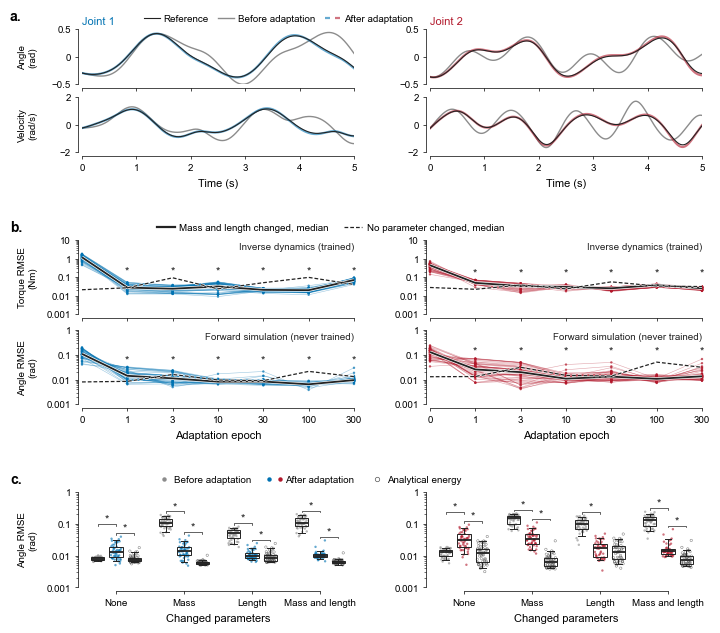

In [91]:
import matplotlib.patheffects as pe
from matplotlib.legend_handler import HandlerTuple
from matplotlib.ticker import FuncFormatter, NullFormatter

# -----------------------------------------------------------------------------
# Fig. 9 plotting code (the same drawing in MAIN_RUN_ME_NEW.ipynb and FIG9.ipynb).
# Joint 1 (blue) is on the left and joint 2 (red) on the right in every panel.
# a: example trajectory of the plant with changed masses and lengths: angle and
#    velocity of the reference (dark line) and of the forward simulation with the
#    network before adaptation (grey) and after adaptation (colour).
# b: time course of the adaptation to that plant: trajectory-wise RMSE of the
#    torque (inverse dynamics, the trained quantity) and of the angle (forward
#    simulation, never trained) at the stored epochs. Each thin line is one
#    trajectory, the heavy line joins the medians, and the dashed line joins the
#    medians of the plant with no parameter changed under the same training (control). An asterisk
#    marks an epoch whose errors differ from those at epoch 0 (FDR q < 0.05).
# c: angle RMSE of the forward simulation of every plant before adaptation, after
#    adaptation (last stored epoch) and with the analytical energy, as box plots
#    (median, quartiles, whiskers at the 5th and 95th percentiles, every
#    trajectory as a dot). A bracket with an asterisk joins a condition to the
#    adapted network when their errors differ (FDR q < 0.05).
# The axis limits enclose every plotted value.
# -----------------------------------------------------------------------------
FIG9_BLUE = '#0072B2'
FIG9_RED = '#B2182B'
FIG9_NEUTRAL = '#222222'
FIG9_BEFORE = '#8C8C8C'
FIG9_ANALYTICAL = '#555555'
FIG9_JOINTS = ['J1', 'J2']
FIG9_JOINT_COLORS = {'J1': FIG9_BLUE, 'J2': FIG9_RED}
# Rows of panel a: column infix in the traces table, axis label
FIG9_TRACE_ROWS = [('q', 'Angle\n(rad)'), ('dq', 'Velocity\n(rad/s)')]
# Rows of panel b: quantity in the RMSE table, axis label, tag, family of comparisons in the statistics table
FIG9_CURVE_ROWS = [('torque', 'Torque RMSE\n(Nm)', 'Inverse dynamics (trained)', 'torque_epoch_vs_before'),
                   ('angle', 'Angle RMSE\n(rad)', 'Forward simulation (never trained)', 'epoch_vs_before')]
# Conditions of panel c: stage in the RMSE table, key label, family of the comparison with the adapted network
FIG9_STAGES = [('before', 'Before adaptation', 'epoch_vs_before'), ('after', 'After adaptation', None),
               ('analytical', 'Analytical energy', 'after_vs_analytical')]
FIG9_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'ytick.minor.size': 1.5,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def fig9_symmetric_limit(largest):
    # Smallest symmetric axis limit of the form 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8 x 10^k that encloses the data
    for exponent in range(-4, 4):
        for mantissa in (1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0):
            if mantissa * 10.0 ** exponent >= largest:
                return mantissa * 10.0 ** exponent
    raise ValueError('value outside the supported range')


def fig9_decade_range(lowest, highest):
    # Powers of ten that enclose the values
    return 10.0 ** np.floor(np.log10(lowest)), 10.0 ** np.ceil(np.log10(highest))


def fig9_number(value, _=None):
    return f"{value:,g}".replace('-', '−')


def draw_fig9(rmse_table, stats_table, traces_table, figure_plant, control_plant, plant_labels):
    """
    rmse_table:    long-form table with columns task, plant, energy, epoch, stage, quantity, joint, trajectory, rmse.
    stats_table:   one row per comparison with the columns family, plant, quantity, joint, epoch_a and significant_fdr_0_05.
    traces_table:  one row per time point of the example trajectory with the columns time_s and
                   <reference, before, after>_<q, dq>_<j1, j2>.
    figure_plant:  plant of panels a and b (key in the column `plant`).
    control_plant: unchanged plant that received the same training (its comparisons are in the families with the prefix
                   `control_`).
    plant_labels:  ordered mapping from the plant keys of panel c to their axis labels.
    Returns the matplotlib figure (three panels, double-column width).
    """
    def select(plant, quantity, joint, stage=None, epoch=None):
        mask = (rmse_table['plant'] == plant) & (rmse_table['quantity'] == quantity) & (rmse_table['joint'] == joint)
        mask &= (rmse_table['stage'] == stage) if epoch is None else ((rmse_table['energy'] == 'network') & (rmse_table['epoch'] == epoch))
        values = rmse_table.loc[mask].sort_values('trajectory')['rmse'].to_numpy(dtype=float)
        assert values.size == rmse_table['trajectory'].nunique(), (plant, quantity, joint, stage, epoch)
        return values

    def significant(family, plant, quantity, joint, epoch=None):
        if plant == control_plant and family.endswith('epoch_vs_before'):
            family = 'control_' + family
        mask = ((stats_table['family'] == family) & (stats_table['plant'] == plant) & (stats_table['quantity'] == quantity)
                & (stats_table['joint'] == joint))
        if epoch is not None:
            mask &= (stats_table['epoch_a'] == epoch)
        assert int(mask.sum()) == 1, (family, plant, quantity, joint, epoch)
        return bool(stats_table.loc[mask, 'significant_fdr_0_05'].iloc[0])

    # ---- geometry in inches, measured from the left and from the top of the canvas ----
    width, height = 7.2, 6.5
    left = {'J1': 0.80, 'J2': 4.28}
    span = 2.72
    fig = plt.figure(figsize=(width, height))

    def add_axes(joint, top, tall):
        ax = fig.add_axes([left[joint] / width, 1.0 - (top + tall) / height, span / width, tall / height])
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_position(('outward', 3))
        ax.spines['bottom'].set_position(('outward', 3))
        ax.yaxis.set_major_formatter(FuncFormatter(fig9_number))
        ax.xaxis.set_major_formatter(FuncFormatter(fig9_number))
        return ax

    def log_axis(ax, low, high):
        decades = 10.0 ** np.arange(np.log10(low), np.log10(high) + 0.5)
        ax.set_yscale('log')
        ax.set_ylim(low, high)
        ax.set_yticks(decades)
        ax.set_yticks(np.concatenate([decade * np.arange(2, 10) for decade in decades[:-1]]), minor=True)
        ax.yaxis.set_major_formatter(FuncFormatter(fig9_number))
        ax.yaxis.set_minor_formatter(NullFormatter())

    def joint_tag(ax, joint, inside=True):
        ax.text(0.0 if not inside else 0.02, 1.06 if not inside else 0.97, f"Joint {joint[1]}", transform=ax.transAxes, ha='left',
                va='bottom' if not inside else 'top', fontsize=8, color=FIG9_JOINT_COLORS[joint])

    def y_label(ax, label):
        ax.set_ylabel(label, fontsize=7, labelpad=3)
        ax.yaxis.set_label_coords(-0.165, 0.5)

    median_style = dict(color=FIG9_NEUTRAL, lw=1.3, solid_capstyle='butt',
                        path_effects=[pe.withStroke(linewidth=2.3, foreground='white')])
    marks = []

    # ---- a: example trajectory, reference and forward simulation before and after adaptation ----
    time = traces_table['time_s'].to_numpy(dtype=float)
    a_top, a_row, a_gap = 0.42, 0.55, 0.13
    for row, (name, label) in enumerate(FIG9_TRACE_ROWS):
        # The traces are stored in single precision; one axis range for both joints
        traces = {(joint, source): traces_table[f"{source}_{name}_{joint.lower()}"].to_numpy(dtype=np.float32).astype(float)
                  for joint in FIG9_JOINTS for source in ('reference', 'before', 'after')}
        largest = max(np.abs(values).max() for values in traces.values())
        limit = fig9_symmetric_limit(largest)
        assert largest <= limit
        for joint in FIG9_JOINTS:
            ax = add_axes(joint, a_top + row * (a_row + a_gap), a_row)
            ax.plot(time, traces[(joint, 'before')], color=FIG9_BEFORE, lw=1.0, zorder=2)
            ax.plot(time, traces[(joint, 'after')], color=FIG9_JOINT_COLORS[joint], lw=1.6, alpha=0.6, zorder=3)
            ax.plot(time, traces[(joint, 'reference')], color=FIG9_NEUTRAL, lw=0.8, zorder=4)
            ax.set_xlim(time[0], 5.0)
            ax.set_ylim(-limit, limit)
            ax.set_xticks(np.arange(0.0, 5.5, 1.0))
            ax.set_yticks([-limit, 0, limit])
            if row < len(FIG9_TRACE_ROWS) - 1:
                ax.tick_params(labelbottom=False)
                joint_tag(ax, joint, inside=False)
            else:
                ax.set_xlabel('Time (s)')
            if joint == 'J1':
                y_label(ax, label)
    fig.legend(handles=[Line2D([0], [0], color=FIG9_NEUTRAL, lw=0.8), Line2D([0], [0], color=FIG9_BEFORE, lw=1.0),
                        (Line2D([0], [0], color=FIG9_BLUE, lw=1.6, alpha=0.6, solid_capstyle='butt'),
                         Line2D([0], [0], color=FIG9_RED, lw=1.6, alpha=0.6, solid_capstyle='butt'))],
               labels=['Reference', 'Before adaptation', 'After adaptation'],
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)}, loc='lower left',
               bbox_to_anchor=((left['J1'] + 0.62) / width, 1.0 - (a_top - 0.06) / height), ncol=3, frameon=False,
               handlelength=1.6, handletextpad=0.4, columnspacing=1.0, borderaxespad=0.0, borderpad=0.0)

    # ---- b: torque error (trained) and forward angle error (never trained) against the adaptation epoch ----
    epochs = sorted(int(epoch) for epoch in rmse_table.loc[(rmse_table['plant'] == figure_plant) & (rmse_table['task'] == 'forward')
                                                           & (rmse_table['energy'] == 'network'), 'epoch'].dropna().unique())
    x_epochs = np.arange(len(epochs), dtype=float)
    final_epoch = epochs[-1]
    b_top = a_top + len(FIG9_TRACE_ROWS) * a_row + (len(FIG9_TRACE_ROWS) - 1) * a_gap + 0.88
    b_row, b_gap = 0.74, 0.16
    for row, (quantity, label, tag, family) in enumerate(FIG9_CURVE_ROWS):
        fans = {joint: np.stack([select(figure_plant, quantity, joint, epoch=epoch) for epoch in epochs]) for joint in FIG9_JOINTS}
        control = {joint: np.asarray([np.median(select(control_plant, quantity, joint, epoch=epoch)) for epoch in epochs]) for joint in FIG9_JOINTS}
        # One axis range for both joints, with head room above the data for the significance marks
        y_low, y_high = fig9_decade_range(min(min(fan.min() for fan in fans.values()), min(line.min() for line in control.values())),
                                          2.6 * max(fan[1:].max() for fan in fans.values()))
        y_high = max(y_high, fig9_decade_range(1.0, max(fan.max() for fan in fans.values()))[1])
        for joint in FIG9_JOINTS:
            color = FIG9_JOINT_COLORS[joint]
            ax = add_axes(joint, b_top + row * (b_row + b_gap), b_row)
            fan = fans[joint]
            assert (fan >= y_low).all() and (fan <= y_high).all() and (control[joint] >= y_low).all() and (control[joint] <= y_high).all()
            for i in range(fan.shape[1]):
                ax.plot(x_epochs, fan[:, i], color=color, lw=0.4, alpha=0.4, zorder=2, clip_on=False)
            ax.scatter(np.repeat(x_epochs, fan.shape[1]), fan.ravel(), color=color, s=3, edgecolors='none', alpha=0.7, zorder=3, clip_on=False)
            ax.plot(x_epochs, np.median(fan, axis=1), zorder=5, clip_on=False, **median_style)
            ax.plot(x_epochs, control[joint], color=FIG9_NEUTRAL, lw=0.9, ls=(0, (3, 1.6)), zorder=6, clip_on=False,
                    path_effects=[pe.withStroke(linewidth=1.9, foreground='white')])
            # Difference from epoch 0 after FDR correction: asterisks on one line above the data of the later epochs
            y_mark = 1.25 * fan[1:].max()
            for k, epoch in enumerate(epochs[1:], start=1):
                if significant(family, figure_plant, quantity, joint, epoch=epoch):
                    marks.append((ax, fan[1:], ax.text(x_epochs[k], y_mark, '*', ha='center', va='bottom', fontsize=8, color=FIG9_NEUTRAL)))
            log_axis(ax, y_low, y_high)
            ax.set_xlim(x_epochs[0], x_epochs[-1])
            ax.set_xticks(x_epochs)
            ax.set_xticklabels([str(epoch) for epoch in epochs])
            if row < len(FIG9_CURVE_ROWS) - 1:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel('Adaptation epoch')
            if joint == 'J1':
                y_label(ax, label)
            ax.text(1.0, 0.97, tag, transform=ax.transAxes, ha='right', va='top', fontsize=7, color=FIG9_NEUTRAL)
    fig.legend(handles=[Line2D([0], [0], color=FIG9_NEUTRAL, lw=1.6), Line2D([0], [0], color=FIG9_NEUTRAL, lw=0.9, ls=(0, (3, 1.6)))],
               labels=['Mass and length changed, median', 'No parameter changed, median'], loc='lower left',
               bbox_to_anchor=((left['J1'] + 0.75) / width, 1.0 - (b_top - 0.08) / height), ncol=2, frameon=False,
               handlelength=1.8, handletextpad=0.5, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- c: forward angle error of every plant before adaptation, after adaptation and with the analytical energy ----
    c_top = b_top + len(FIG9_CURVE_ROWS) * b_row + (len(FIG9_CURVE_ROWS) - 1) * b_gap + 0.88
    c_row = 0.95
    plants = list(plant_labels)
    offsets = dict(zip([stage for stage, _, _ in FIG9_STAGES], np.linspace(-0.27, 0.27, len(FIG9_STAGES))))
    boxes_values = {(joint, plant, stage): select(plant, 'angle', joint, stage=stage)
                    for joint in FIG9_JOINTS for plant in plants for stage, _, _ in FIG9_STAGES}
    y_low, y_high = fig9_decade_range(min(values.min() for values in boxes_values.values()),
                                      4.0 * max(values.max() for values in boxes_values.values()))
    for joint in FIG9_JOINTS:
        color = FIG9_JOINT_COLORS[joint]
        ax = add_axes(joint, c_top, c_row)
        stage_colors = {'before': FIG9_BEFORE, 'after': color, 'analytical': FIG9_ANALYTICAL}
        for p, plant in enumerate(plants):
            for stage, _, _ in FIG9_STAGES:
                values = boxes_values[(joint, plant, stage)]
                assert (values >= y_low).all() and (values <= y_high).all()
                # Centre line, median; box, quartiles; whiskers, 5th and 95th percentiles
                low, q1, median, q3, high = np.percentile(values, [5, 25, 50, 75, 95])
                ax.bxp([dict(whislo=low, q1=q1, med=median, q3=q3, whishi=high, fliers=[])], positions=[p + offsets[stage]], widths=0.2,
                       showfliers=False, patch_artist=True, manage_ticks=False, zorder=4,
                       boxprops=dict(facecolor='none', edgecolor=FIG9_NEUTRAL, linewidth=0.7),
                       whiskerprops=dict(color=FIG9_NEUTRAL, linewidth=0.7), capprops=dict(color=FIG9_NEUTRAL, linewidth=0.7),
                       medianprops=dict(color=FIG9_NEUTRAL, linewidth=1.3, solid_capstyle='butt'))
                # Every trajectory, spread horizontally inside the box in the order of the test set
                spread = (np.arange(len(values)) / (len(values) - 1) - 0.5) * 0.15
                if stage == 'analytical':
                    # Open circles, so that the analytical energy is told apart from the grey of the network before adaptation
                    ax.scatter(p + offsets[stage] + spread, values, facecolors='none', edgecolors=stage_colors[stage], linewidths=0.35, s=3,
                               alpha=0.8, zorder=3, clip_on=False)
                else:
                    ax.scatter(p + offsets[stage] + spread, values, color=stage_colors[stage], s=3, edgecolors='none', alpha=0.6, zorder=3, clip_on=False)
            # Difference from the adapted network after FDR correction: a bracket with an asterisk to the compared condition
            after = boxes_values[(joint, plant, 'after')]
            bracket_y = {}
            for stage, _, family in FIG9_STAGES:
                if family is not None and significant(family, plant, 'angle', joint, epoch=final_epoch):
                    bracket_y[stage] = 1.3 * max(boxes_values[(joint, plant, stage)].max(), after.max())
            if len(bracket_y) == 2:
                # Two brackets end above the adapted network: keep the higher one clear of the lower one
                higher = max(bracket_y, key=bracket_y.get)
                lower = min(bracket_y, key=bracket_y.get)
                bracket_y[higher] = max(bracket_y[higher], 1.9 * bracket_y[lower])
            for stage, y in bracket_y.items():
                x_from, x_to = sorted((p + offsets[stage], p + offsets['after']))
                ax.plot([x_from, x_from, x_to, x_to], [y / 1.12, y, y, y / 1.12], color=FIG9_NEUTRAL, lw=0.5, zorder=5, clip_on=False)
                data_below = np.concatenate((boxes_values[(joint, plant, stage)], after))
                marks.append((ax, data_below, ax.text(0.5 * (x_from + x_to), y, '*', ha='center', va='bottom', fontsize=8, color=FIG9_NEUTRAL)))
        log_axis(ax, y_low, y_high)
        ax.set_xlim(-0.5, len(plants) - 0.5)
        ax.set_xticks(np.arange(len(plants)))
        ax.set_xticklabels([plant_labels[plant] for plant in plants])
        ax.spines['bottom'].set_bounds(0, len(plants) - 1)
        ax.set_xlabel('Changed parameters')
        if joint == 'J1':
            y_label(ax, 'Angle RMSE\n(rad)')
    fig.legend(handles=[Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor=FIG9_BEFORE, markeredgecolor='none'),
                        (Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor=FIG9_BLUE, markeredgecolor='none'),
                         Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor=FIG9_RED, markeredgecolor='none')),
                        Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor='none', markeredgecolor=FIG9_ANALYTICAL,
                               markeredgewidth=0.5)],
               labels=[label for _, label, _ in FIG9_STAGES], handler_map={tuple: HandlerTuple(ndivide=None, pad=0.6)}, loc='lower left',
               bbox_to_anchor=((left['J1'] + 0.75) / width, 1.0 - (c_top - 0.08) / height), ncol=3, frameon=False,
               handlelength=1.5, handletextpad=0.3, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- panel labels ----
    for letter, top in (('a.', a_top), ('b.', b_top), ('c.', c_top)):
        fig.text(0.08 / width, 1.0 - (top - 0.06) / height, letter, fontsize=10, fontweight='bold', ha='left', va='bottom')

    # The significance marks must stay inside the axes and above the data
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, values, mark in marks:
        box = mark.get_window_extent(renderer).transformed(ax.transData.inverted())
        assert box.y1 <= ax.get_ylim()[1], 'a significance mark leaves the axes'
        assert box.y0 >= values.max(), 'a significance mark meets the data'
    return fig


def save_fig9(fig, directory, name):
    # PDF (vector, editable text) and 600-dpi PNG at the canvas size, as in FIG9.ipynb
    for ext in ('pdf', 'png'):
        figure_path = os.path.join(directory, f"{name}.{ext}")
        fig.savefig(figure_path, facecolor='white')
        print(f"Saved {figure_path}")


# Draw Fig. 9 and save the PDF and PNG to the submission folder
with mpl.rc_context():
    mpl.rc_file_defaults()        # same starting point as the standalone notebook, whatever this kernel has set
    mpl.rcParams.update(FIG9_RC)
    tl_fig = draw_fig9(tl_rmse_df, tl_stats_df, tl_traces_df, TL_FIGURE_PLANT, TL_CONTROL_PLANT, TL_PLANT_LABELS)
    save_fig9(tl_fig, TL_FIGURE_DIR, TL_FIGURE_NAME)
    plt.show()

### Data package for Fig. 9

Following the packaging used for the other figures, the trajectory-wise RMSE values, the statistics table, the losses of the adaptation, the traces of the example trajectory, provenance metadata (source-file hashes, pendulums, adaptation settings, solver configuration, statistical settings) and a README are written into `FIG9.zip` in `SUBMISSION/FIGURES/DATA AND SCRIPTS/`. The standalone notebook `FIG9.ipynb` in the same folder regenerates the figure from this archive alone.

In [92]:
import json
import zipfile
from datetime import datetime, timezone

tl_package_path = os.path.join(TL_PACKAGE_DIR, f"{TL_FIGURE_NAME}.zip")

# Provenance: hashes of every artifact the figure and statistics were derived from
tl_source_paths = [TL_MODEL_PATH, TL_STATS_PATH, TL_REFERENCE_PATH, TL_CHECKPOINTS_PATH, TL_RESULTS_PATH,
                   TL_RMSE_CSV_PATH, TL_HISTORY_CSV_PATH, TL_STATS_CSV_PATH, TL_TRACES_CSV_PATH]
tl_source_files = {
    os.path.basename(path): {'sha256': tl_sha256_of_file(path), 'bytes': os.path.getsize(path)}
    for path in tl_source_paths if os.path.exists(path)
}
tl_family_counts = {family: {'num_comparisons': int(len(table)), 'num_significant': int(table['significant_fdr_0_05'].sum())}
                    for family, table in tl_stats_df.groupby('family', sort=False)}

tl_metadata = {
    'created_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'description': ('Data package for manuscript Figure 9: accuracy of the closed-loop forward simulation on perturbed plants '
                    'before and after the network is adapted to them with the inverse-dynamics loss alone.'),
    'purpose': ('Tests whether learning with the inverse-dynamics loss alone transfers to the forward simulation when '
                'the masses and lengths of the plant change.'),
    'data_derivation': (
        'Trajectory-wise RMSE values were produced by MAIN_RUN_ME_NEW.ipynb, Section 13, from the ANNet trained on 16,000 '
        'samples (model_16000.pth, stats_16000.pt) and the 50 initial states of Section 6 '
        '(simulation_results_50trials_N16_B15_A10.pt). Statistics were computed from the archived RMSE values.'
    ),
    'source_files': tl_source_files,
    'plants': {key: dict(plant) for key, plant in TL_PLANTS.items()},
    'control_plant': TL_CONTROL_PLANT,
    'control_plant_note': ('the original plant of the paper; the network received the same adaptation on fresh samples of this '
                           'plant, which shows the effect of the continued training alone'),
    'plant_labels': dict(TL_PLANT_LABELS),
    'plant_units': 'm1 and m2 in kg, l1 and l2 in m',
    'adaptation': {
        'initial_weights': 'ANNet trained on 16,000 samples of the original plant (Section 3)',
        'loss': ('physics-informed loss of Section 3: mean squared error between the gradient of the network with respect to '
                 'the accelerations and the torques of the perturbed plant; no forward simulation or acceleration target is used'),
        'samples': int(TL_ADAPT_SAMPLES),
        'train_fraction': float(TL_TRAIN_FRACTION),
        'sampling_ranges': {'angle_rad': TL_RANGE_Q, 'velocity_rad_s': TL_RANGE_DQ, 'acceleration_rad_s2': TL_RANGE_DDQ},
        'optimizer': 'Adam',
        'learning_rate': float(TL_ADAPT_LR),
        'batch_size': int(TL_ADAPT_BATCH_SIZE),
        'epochs': int(TL_ADAPT_EPOCHS),
        'stored_epochs': [int(epoch) for epoch in TL_CHECKPOINT_EPOCHS],
        'standardization': 'constants of the pretrained network, fixed during adaptation',
        'data_seed_rule': f"plant i uses torch.Generator().manual_seed({TL_DATA_SEED} + i)",
        'train_seed_rule': f"plant i uses torch.manual_seed({TL_TRAIN_SEED} + i) before the first epoch",
        'seconds_per_plant': {key: float(value) for key, value in tl_adaptation['seconds'].items()},
    },
    'solver': tl_results['provenance']['config'],
    'solver_note': ('two-stage solver of Section 6 at every step: best of N candidate accelerations (zero, previous, and '
                    'uniform random within the bound), then Adam refinement of S + G . ddq + lambda ||ddq - ddq_prev||^2, with the '
                    'gravitational torque G of the simulated plant; the random candidates are identical in every condition (same seed)'),
    'conditions': {
        'before': ('forward solver with the pretrained network (epoch 0, before adaptation) and the gravitational torque of the '
                   'simulated plant; for the unchanged plant this is the forward simulation of the original plant'),
        'after': f"forward solver with the network after {TL_ADAPT_EPOCHS} epochs of adaptation to the simulated plant (last epoch, no selection)",
        'intermediate': 'forward solver with the network at the other stored epochs of the adaptation',
        'analytical': 'the same solver with the analytical Appell energy of the simulated plant',
        'not_updated': ('model that is not updated: the pretrained network with the gravitational torque of the original plant, '
                        'that is, the rollouts of the original plant, scored against the reference of the perturbed plant'),
    },
    'test_set': {
        'initial_states_file': os.path.basename(TL_REFERENCE_PATH),
        'num_trajectories': int(TL_NUM_TRAJS),
        'steps_per_trajectory': int(TL_STEPS),
        'duration_s': float(TL_DURATION),
        'reference': ('fourth-order Runge-Kutta solution of each plant from the initial states of Section 6 on the time grid '
                      'of Section 6 (2,500 equally spaced times over 5 s)'),
        'largest_reference_values': tl_results['reference_range'],
        'solver_step_s': float(TL_DT_SIM),
    },
    'statistics': {
        'alpha': TL_ALPHA,
        'normality_test': 'Shapiro-Wilk on each group',
        'primary_test_rule': 'one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test',
        'secondary_test': 'two-sided Wilcoxon signed-rank (paired by trajectory), with the same correction within each family',
        'multiple_comparison_correction': 'Benjamini-Hochberg FDR within each family of comparisons',
        'families': tl_family_counts,
        'family_descriptions': dict(TL_FAMILY_TITLES),
    },
    'example_trajectory': {
        'index': int(tl_example_trajectory),
        'plant': TL_FIGURE_PLANT,
        'selection_rule': ('trajectory whose forward errors before and after adaptation lie closest to the medians of the '
                           'twelve combinations of stage, quantity and joint: smallest sum of |log(error / median error)|'),
    },
    'figure': {
        'plant_of_panels_a_and_b': TL_FIGURE_PLANT,
        'content': ('three panels, double-column width, joint 1 on the left and joint 2 on the right. a: example trajectory, '
                    'angle and velocity of the reference (dark line) and of the forward simulation before adaptation (grey) and '
                    'after adaptation (colour). b, logarithmic axes: trajectory-wise RMSE of the torque (inverse dynamics, trained) '
                    'and of the angle (forward simulation, never trained) at the stored epochs; one thin line per trajectory, the '
                    'heavy line joins the medians, the dashed line joins the medians of the unchanged plant under the same training, '
                    'and an asterisk marks an epoch whose errors differ from those at epoch 0. c, logarithmic axes: angle RMSE of '
                    'the forward simulation of every plant before adaptation, after adaptation (last epoch) and with the analytical '
                    'energy as box plots (median, quartiles, whiskers at the 5th and 95th percentiles, every trajectory as a dot); '
                    'a bracket with an asterisk joins a condition to the adapted network when their errors differ. The asterisks '
                    'follow the primary test (FDR q < 0.05); the paired Wilcoxon test is in the statistics table'),
        'axis_limits': 'every numeric axis ends on a labelled tick that encloses all plotted values',
    },
    'num_rmse_rows': int(len(tl_rmse_df)),
}

tl_readme_text = f"""{TL_FIGURE_NAME} data package
=================

This archive contains the data required by {TL_FIGURE_NAME}.ipynb to regenerate manuscript Figure 9.

Files:
- fig9_rmse_values.csv: trajectory-wise RMSE on the 50 trajectories of the forward-dynamics test. Columns: task (forward: closed-loop simulation; inverse: torque prediction on the reference trajectories), plant (mass, length, mass_length, or unchanged for the original plant), energy (network or analytical), epoch (adaptation epoch of the network; empty for the analytical energy and for the model that is not updated), stage (before adaptation, epoch 0; intermediate, the other stored epochs; after adaptation, the last epoch; analytical; not_updated for the pretrained network with the gravitational torque of the original plant, scored against the perturbed plant), quantity (angle, velocity, acceleration or torque), unit, joint, trajectory, rmse.
- fig9_statistics.csv: the comparisons of {len(tl_family_counts)} families (column family; described under statistics in fig9_metadata.json): group a against group b with Shapiro-Wilk normality tests, primary test (one-way ANOVA if both groups are normal, otherwise Kruskal-Wallis H-test) with Benjamini-Hochberg FDR correction within the family, two-sided paired Wilcoxon signed-rank test with the same correction, medians, ratio of medians, median paired difference, direction of the difference, Cliff's delta and the number of trajectories on which group a has the smaller error.
- fig9_adaptation_history.csv: training and validation loss (mean squared torque error, Nm^2) and the root of the validation loss (Nm) at every epoch of the adaptation to each plant; epoch 0 is the pretrained network.
- fig9_example_traces.csv: the example trajectory at every time step (single precision). Columns: time_s and, for the reference, the network before adaptation, the network after adaptation and the analytical energy, the angle (q), velocity (dq) and acceleration (ddq) of both joints.
- fig9_metadata.json: source hashes, plants, adaptation settings, solver configuration, statistical settings, figure conventions, and provenance metadata.

The network trained on the original plant (masses 1 and 1 kg, lengths 1 and 1 m) was adapted to each perturbed plant for {TL_ADAPT_EPOCHS} epochs with the inverse-dynamics loss only (error between the gradient of the network and the torques of the perturbed plant); no forward simulation entered the adaptation. As a control, the network received the same training on fresh samples of the unchanged plant. The forward solver then simulated each plant from the 50 initial states with the network at every stored epoch of the adaptation (epoch 0 is the network before adaptation) and with the analytical Appell energy of that plant, always with the gravitational torque of the simulated plant, and the errors were measured against Runge-Kutta reference trajectories of the same plant. Panel a of the figure shows the example trajectory on the plant with changed masses and lengths, panel b the torque error and the forward angle error of that plant at the stored epochs of the adaptation together with the medians of the unchanged plant, and panel c the forward angle error of every plant before adaptation, after adaptation and with the analytical energy.
"""


def write_fig9_package(package_path):
    with zipfile.ZipFile(package_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
        archive.writestr('fig9_rmse_values.csv', tl_rmse_df.to_csv(index=False))
        archive.writestr('fig9_statistics.csv', tl_stats_df.to_csv(index=False))
        archive.writestr('fig9_adaptation_history.csv', tl_history_df.to_csv(index=False))
        archive.writestr('fig9_example_traces.csv', tl_traces_df.to_csv(index=False))
        archive.writestr('fig9_metadata.json', json.dumps(tl_metadata, indent=2, allow_nan=False))
        archive.writestr(f'{TL_FIGURE_NAME}_README.txt', tl_readme_text)
    print(f"Saved data package to {package_path}")
    with zipfile.ZipFile(package_path) as archive:
        for info in archive.infolist():
            print(f"  {info.filename:<30} {info.file_size:>9,} bytes")


write_fig9_package(tl_package_path)

Saved data package to ../SUBMISSION/FIGURES/DATA AND SCRIPTS/FIG9.zip
  fig9_rmse_values.csv           1,044,065 bytes
  fig9_statistics.csv               98,353 bytes
  fig9_adaptation_history.csv       88,418 bytes
  fig9_example_traces.csv          703,729 bytes
  fig9_metadata.json                10,516 bytes
  FIG9_README.txt                    3,247 bytes


End of the notebook.